# FPL Predictor v1.0

A complete Fantasy Premier League forecasting and decision-support notebook.

## Operating modes

**First setup or model rebuild**

Run the notebook from the beginning. Sections 1–10 build the live forecasts, optimisers and chip model. Section 11 performs optional walk-forward policy validation. Section 12 is the weekly production interface.

**Before each Gameweek deadline**

1. Restart the kernel and run Sections 1–10.
2. Update the live team-state cell in Section 12.
3. Run Section 12 and execute only its primary current-Gameweek action.
4. Treat the later transfer path as provisional; rerun next week.

Section 11 is not required every week. Run it after material model or policy changes to update the historically preferred transfer policy.

## 1. Data collection and preparation

### Imports


In [1]:
from datetime import datetime, timezone
from io import StringIO
from pathlib import Path
import gzip
import json

import numpy as np
import pandas as pd
import requests


BASE_URL = "https://fantasy.premierleague.com/api/"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

### Environment preflight

The notebook targets Python 3.10+ and requires:

```bash
pip install numpy pandas requests scipy scikit-learn
```

The next cell fails early with a clear message when a required package is missing.


In [2]:
import importlib.util
import platform
import sys

PROJECT_VERSION = "1.0.0"
MINIMUM_PYTHON = (3, 10)

if sys.version_info < MINIMUM_PYTHON:
    raise RuntimeError(
        "FPL Predictor requires Python 3.10 or newer. "
        f"Detected: {platform.python_version()}"
    )

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "requests": "requests",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}
missing_packages = [
    install_name
    for import_name, install_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]
if missing_packages:
    raise RuntimeError(
        "Missing required packages. Install them with: pip install "
        + " ".join(missing_packages)
    )

required_runtime_objects = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "requests": requests.__version__,
}

Path("data").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)

print(f"FPL Predictor v{PROJECT_VERSION}")
print(f"Python: {platform.python_version()}")
print("Runtime packages:", required_runtime_objects)


FPL Predictor v1.0.0
Python: 3.12.3
Runtime packages: {'numpy': '2.5.1', 'pandas': '3.0.5', 'requests': '2.34.2'}


### Data


In [3]:
session = requests.Session()

session.headers.update({
    "User-Agent": "FPL-Predictor/1.0"
})


def get_fpl_data(endpoint: str) -> dict | list:
    """
    Download JSON data from an FPL API endpoint.

    Parameters
    ----------
    endpoint:
        Endpoint relative to the FPL API base URL,
        for example 'bootstrap-static/'.

    Returns
    -------
    dict or list
        Parsed JSON response.
    """
    url = f"{BASE_URL}{endpoint}"

    try:
        response = session.get(url, timeout=30)
        response.raise_for_status()
    except requests.RequestException as exc:
        raise RuntimeError(
            f"Unable to download FPL data from {url}"
        ) from exc

    try:
        return response.json()
    except requests.JSONDecodeError as exc:
        raise RuntimeError(
            f"FPL returned an invalid JSON response from {url}"
        ) from exc

In [4]:
bootstrap = get_fpl_data("bootstrap-static/")
fixtures_raw = get_fpl_data("fixtures/")

print("Bootstrap sections:")
print(list(bootstrap.keys()))

print(f"\nNumber of fixtures: {len(fixtures_raw)}")

Bootstrap sections:
['chips', 'events', 'game_settings', 'game_config', 'phases', 'teams', 'total_players', 'element_stats', 'element_types', 'elements']

Number of fixtures: 380


In [5]:
teams = (
    pd.DataFrame(bootstrap["teams"])
    .rename(columns={
        "id": "team_id",
        "name": "team_name",
        "short_name": "team_short_name",
    })
)

positions = (
    pd.DataFrame(bootstrap["element_types"])
    .rename(columns={
        "id": "element_type",
        "singular_name": "position_name",
        "singular_name_short": "position",
    })
)

display(
    teams[
        [
            "team_id",
            "team_name",
            "team_short_name",
            "strength",
            "strength_attack_home",
            "strength_attack_away",
            "strength_defence_home",
            "strength_defence_away",
        ]
    ]
)

display(
    positions[
        [
            "element_type",
            "position_name",
            "position",
            "squad_select",
            "squad_min_play",
            "squad_max_play",
        ]
    ]
)

,team_id,team_name,team_short_name,strength,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away
0,1,Arsenal,ARS,None,0,0,0,0
1,2,Aston Villa,AVL,None,0,0,0,0
2,3,Bournemouth,BOU,None,0,0,0,0
3,4,Brentford,BRE,None,0,0,0,0
4,5,Brighton,BHA,None,0,0,0,0
5,6,Chelsea,CHE,None,0,0,0,0
6,7,Coventry City,COV,None,0,0,0,0
7,8,Crystal Palace,CRY,None,0,0,0,0
8,9,Everton,EVE,None,0,0,0,0
9,10,Fulham,FUL,None,0,0,0,0


,element_type,position_name,position,squad_select,squad_min_play,squad_max_play
0,1,Goalkeeper,GKP,2,1,1
1,2,Defender,DEF,5,3,5
2,3,Midfielder,MID,5,2,5
3,4,Forward,FWD,3,1,3


In [6]:
players = pd.DataFrame(bootstrap["elements"])

players = (
    players
    .merge(
        teams[
            [
                "team_id",
                "team_name",
                "team_short_name",
            ]
        ],
        left_on="team",
        right_on="team_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        positions[
            [
                "element_type",
                "position_name",
                "position",
            ]
        ],
        on="element_type",
        how="left",
        validate="many_to_one",
    )
)

# FPL stores prices as integer tenths of a million:
# 45 means £4.5m, 100 means £10.0m, etc.
players["price"] = players["now_cost"] / 10

players["full_name"] = (
    players["first_name"].str.strip()
    + " "
    + players["second_name"].str.strip()
)
# FPL's player code is substantially more stable across seasons than the
# season-specific element ID. It is used to connect current players to the
# historical archive.
if "code" in players.columns:
    players["player_code"] = pd.to_numeric(
        players["code"],
        errors="coerce",
    ).astype("Int64")
else:
    players["player_code"] = pd.Series(
        pd.NA,
        index=players.index,
        dtype="Int64",
    )

players["player_key"] = (
    "current:element:"
    + players["id"].astype("Int64").astype(str)
)

has_player_code = players["player_code"].notna()
players.loc[has_player_code, "player_key"] = (
    "code:"
    + players.loc[
        has_player_code,
        "player_code",
    ].astype(str)
)


In [7]:
numeric_columns = [
    "selected_by_percent",
    "form",
    "points_per_game",
    "value_form",
    "value_season",
    "influence",
    "creativity",
    "threat",
    "ict_index",
    "expected_goals",
    "expected_assists",
    "expected_goal_involvements",
    "expected_goals_conceded",
]

for column in numeric_columns:
    if column in players.columns:
        players[column] = pd.to_numeric(
            players[column],
            errors="coerce",
        )

In [8]:
preferred_player_columns = [
    # Stable identifiers retained for later joins
    "id",
    "player_code",
    "player_key",
    "team_id",
    "element_type",

    # Player information
    "full_name",
    "web_name",
    "team_name",
    "team_short_name",
    "position",
    "price",

    # Availability information
    "status",
    "chance_of_playing_next_round",
    "news",

    # Current-season FPL information
    "selected_by_percent",
    "total_points",
    "points_per_game",
    "form",
    "minutes",
    "starts",
    "goals_scored",
    "assists",
    "clean_sheets",
    "goals_conceded",
    "saves",
    "bonus",
    "bps",

    # Current-season underlying statistics
    "expected_goals",
    "expected_assists",
    "expected_goal_involvements",
    "expected_goals_conceded",
]

available_player_columns = [
    column
    for column in preferred_player_columns
    if column in players.columns
]

players = players[available_player_columns].copy()

display(players.head(10))


,id,player_code,player_key,team_id,element_type,full_name,web_name,team_name,team_short_name,position,price,status,chance_of_playing_next_round,news,selected_by_percent,total_points,points_per_game,form,minutes,starts,goals_scored,assists,clean_sheets,goals_conceded,saves,bonus,bps,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded
0,1,154561,code:154561,1,1,David Raya Martín,Raya,Arsenal,ARS,GKP,6.0,a,NaN,,29.8,162,4.4,0.0,3330,37,0,0,19,26,60,11,633,0.00,0.07,0.07,27.56
1,2,109745,code:109745,1,1,Kepa Arrizabalaga Revuelta,Arrizabalaga,Arsenal,ARS,GKP,5.0,a,NaN,,0.2,2,2.0,0.0,90,1,0,0,0,1,2,0,11,0.00,0.00,0.00,0.98
2,3,437495,code:437495,1,1,Illan Meslier,Meslier,Arsenal,ARS,GKP,5.0,a,NaN,,0.1,0,0.0,0.0,0,0,11,0,0,0,0,0,11,0.00,0.00,0.00,0.00
3,4,226597,code:226597,1,2,Gabriel dos Santos Magalhães,Gabriel,Arsenal,ARS,DEF,8.0,a,NaN,,25.3,209,6.5,0.0,2750,30,3,5,18,20,0,30,724,2.94,1.75,4.69,22.01
4,5,445122,code:445122,1,2,Jurriën Timber,J.Timber,Arsenal,ARS,DEF,6.5,i,0.0,Groin injury - Expected back 21 Aug,0.7,149,5.0,0.0,2452,28,3,6,13,20,0,9,532,4.71,1.53,6.24,17.45
5,6,462424,code:462424,1,2,William Saliba,Saliba,Arsenal,ARS,DEF,6.0,i,0.0,Back injury - Unknown return date,0.5,137,4.4,0.0,2614,30,1,0,15,20,0,12,581,0.88,1.21,2.09,20.41
6,7,499169,code:499169,1,3,Myles Lewis-Skelly,Lewis-Skelly,Arsenal,ARS,MID,5.5,a,NaN,,0.3,29,1.4,0.0,697,5,0,0,2,8,0,0,110,0.10,0.20,0.30,9.01
7,8,466075,code:466075,1,2,Riccardo Calafiori,Calafiori,Arsenal,ARS,DEF,5.5,a,NaN,,12.5,109,4.2,0.0,1697,22,1,2,13,8,0,6,389,3.36,0.76,4.12,9.72
8,9,448104,code:448104,1,2,Piero Hincapié,Hincapie,Arsenal,ARS,DEF,5.5,a,NaN,,5.5,87,3.5,0.0,1787,20,1,2,5,19,0,7,335,0.36,1.67,2.03,17.53
9,10,198869,code:198869,1,2,Benjamin White,White,Arsenal,ARS,DEF,5.5,i,0.0,Knee injury - Expected back 21 Aug,0.0,45,3.8,0.0,699,9,0,1,5,6,0,3,181,0.45,0.69,1.14,8.68


### Fixtures

In [9]:
fixtures = pd.DataFrame(fixtures_raw)

home_teams = teams[
    ["team_id", "team_name", "team_short_name"]
].rename(columns={
    "team_id": "team_h",
    "team_name": "home_team",
    "team_short_name": "home_team_short",
})

away_teams = teams[
    ["team_id", "team_name", "team_short_name"]
].rename(columns={
    "team_id": "team_a",
    "team_name": "away_team",
    "team_short_name": "away_team_short",
})

fixtures = (
    fixtures
    .merge(
        home_teams,
        on="team_h",
        how="left",
        validate="many_to_one",
    )
    .merge(
        away_teams,
        on="team_a",
        how="left",
        validate="many_to_one",
    )
)

fixtures["kickoff_time"] = pd.to_datetime(
    fixtures["kickoff_time"],
    utc=True,
    errors="coerce",
)

# Convert UTC fixture times to mainland Spain time.
fixtures["kickoff_time_spain"] = (
    fixtures["kickoff_time"]
    .dt.tz_convert("Europe/Madrid")
)

In [10]:
preferred_fixture_columns = [
    # Stable identifiers retained for later joins
    "id",
    "event",
    "team_h",
    "team_a",

    # Fixture information
    "kickoff_time",
    "kickoff_time_spain",
    "home_team",
    "home_team_short",
    "away_team",
    "away_team_short",
    "team_h_score",
    "team_a_score",
    "team_h_difficulty",
    "team_a_difficulty",
    "started",
    "finished",
]

available_fixture_columns = [
    column
    for column in preferred_fixture_columns
    if column in fixtures.columns
]

fixtures = fixtures[available_fixture_columns].copy()

display(
    fixtures
    .sort_values("kickoff_time_spain")
    .head(20)
)


,id,event,team_h,team_a,kickoff_time,kickoff_time_spain,home_team,home_team_short,away_team,away_team_short,team_h_score,team_a_score,team_h_difficulty,team_a_difficulty,started,finished
0,1,1,1,7,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,Arsenal,ARS,Coventry City,COV,None,None,2,5,False,False
1,4,1,11,16,2026-08-22 11:30:00+00:00,2026-08-22 13:30:00+02:00,Hull City,HUL,Man Utd,MUN,None,None,4,2,False,False
2,3,1,9,8,2026-08-22 14:00:00+00:00,2026-08-22 16:00:00+02:00,Everton,EVE,Crystal Palace,CRY,None,None,3,3,False,False
3,5,1,12,20,2026-08-22 14:00:00+00:00,2026-08-22 16:00:00+02:00,Ipswich Town,IPS,Sunderland,SUN,None,None,2,2,False,False
4,6,1,18,13,2026-08-22 14:00:00+00:00,2026-08-22 16:00:00+02:00,Nott'm Forest,NFO,Leeds,LEE,None,None,2,3,False,False
5,2,1,4,19,2026-08-22 16:30:00+00:00,2026-08-22 18:30:00+02:00,Brentford,BRE,Spurs,TOT,None,None,3,3,False,False
6,7,1,5,2,2026-08-23 13:00:00+00:00,2026-08-23 15:00:00+02:00,Brighton,BHA,Aston Villa,AVL,None,None,3,3,False,False
7,8,1,15,3,2026-08-23 13:00:00+00:00,2026-08-23 15:00:00+02:00,Man City,MCI,Bournemouth,BOU,None,None,3,5,False,False
8,9,1,17,14,2026-08-23 15:30:00+00:00,2026-08-23 17:30:00+02:00,Newcastle,NEW,Liverpool,LIV,None,None,4,3,False,False
9,10,1,10,6,2026-08-24 19:00:00+00:00,2026-08-24 21:00:00+02:00,Fulham,FUL,Chelsea,CHE,None,None,4,3,False,False


### Gameweeks

In [11]:
gameweeks = pd.DataFrame(bootstrap["events"])

gameweeks["deadline_time"] = pd.to_datetime(
    gameweeks["deadline_time"],
    utc=True,
    errors="coerce",
)

gameweeks["deadline_time_spain"] = (
    gameweeks["deadline_time"]
    .dt.tz_convert("Europe/Madrid")
)

gameweek_columns = [
    "id",
    "name",
    "deadline_time_spain",
    "finished",
    "is_previous",
    "is_current",
    "is_next",
    "average_entry_score",
    "highest_score",
]

gameweek_columns = [
    column
    for column in gameweek_columns
    if column in gameweeks.columns
]

display(gameweeks[gameweek_columns])

,id,name,deadline_time_spain,finished,is_previous,is_current,is_next,average_entry_score,highest_score
0,1,Gameweek 1,2026-08-21 19:30:00+02:00,False,False,False,True,0,None
1,2,Gameweek 2,2026-08-28 19:30:00+02:00,False,False,False,False,0,None
2,3,Gameweek 3,2026-09-04 19:30:00+02:00,False,False,False,False,0,None
3,4,Gameweek 4,2026-09-12 14:30:00+02:00,False,False,False,False,0,None
4,5,Gameweek 5,2026-09-18 19:30:00+02:00,False,False,False,False,0,None
5,6,Gameweek 6,2026-10-10 14:30:00+02:00,False,False,False,False,0,None
6,7,Gameweek 7,2026-10-17 14:30:00+02:00,False,False,False,False,0,None
7,8,Gameweek 8,2026-10-24 14:30:00+02:00,False,False,False,False,0,None
8,9,Gameweek 9,2026-10-31 14:30:00+01:00,False,False,False,False,0,None
9,10,Gameweek 10,2026-11-07 14:30:00+01:00,False,False,False,False,0,None


### Validation

In [12]:
assert not players.empty, "The player table is empty."
assert not fixtures.empty, "The fixture table is empty."
assert players["id"].is_unique, "Player IDs are not unique."
assert players["team_name"].notna().all(), "Some players have no mapped team."
assert players["position"].notna().all(), "Some players have no mapped position."

assert players["price"].between(3.0, 20.0).all(), (
    "At least one player price appears invalid."
)

print(f"Players loaded: {len(players):,}")
print(f"Teams loaded: {len(teams):,}")
print(f"Fixtures loaded: {len(fixtures):,}")
print(f"Gameweeks loaded: {len(gameweeks):,}")

print("\nPlayers by position:")
print(players["position"].value_counts())

print("\nPlayers by team:")
print(
    players["team_short_name"]
    .value_counts()
    .sort_index()
)

Players loaded: 558
Teams loaded: 20
Fixtures loaded: 380
Gameweeks loaded: 38

Players by position:
position
MID    246
DEF    184
FWD     68
GKP     60
Name: count, dtype: int64

Players by team:
team_short_name
ARS    28
AVL    28
BHA    32
BOU    25
BRE    26
CHE    30
COV    28
CRY    29
EVE    23
FUL    21
HUL    28
IPS    27
LEE    24
LIV    34
MCI    30
MUN    33
NEW    24
NFO    27
SUN    25
TOT    36
Name: count, dtype: int64


## 2. Player–fixture modelling table

The forecasting unit is **one player in one fixture**.

This is preferable to one row per player per Gameweek because a player may have:

- one fixture in a normal Gameweek;
- no fixture in a blank Gameweek;
- multiple fixtures in a double Gameweek.

The table built below is the common input for the minutes model, expected-points model, line-up selection, transfers and chip evaluation.

### Planning horizon

For live use, the first Gameweek in the analysis is taken from FPL's `is_next` flag.  
`CURRENT_GAMEWEEK_OVERRIDE` can later be used for historical backtesting or manual testing.

In [13]:
PLANNING_HORIZON = 6
CURRENT_GAMEWEEK_OVERRIDE = None


def get_first_planning_gameweek(
    gameweek_table: pd.DataFrame,
    override: int | None = None,
) -> int:
    """
    Return the first Gameweek to include in the current analysis.

    For a live pre-deadline run, FPL marks the upcoming Gameweek with
    `is_next=True`. An explicit override is useful for historical tests.
    """
    if override is not None:
        valid_gameweeks = set(gameweek_table["id"].astype(int))
        if override not in valid_gameweeks:
            raise ValueError(
                f"Gameweek {override} is outside the available schedule."
            )
        return int(override)

    next_gameweeks = gameweek_table.loc[
        gameweek_table["is_next"].fillna(False),
        "id",
    ]

    if len(next_gameweeks) == 1:
        return int(next_gameweeks.iloc[0])

    if len(next_gameweeks) > 1:
        raise ValueError("More than one Gameweek is marked as next.")

    unfinished_gameweeks = gameweek_table.loc[
        ~gameweek_table["finished"].fillna(False),
        "id",
    ]

    if unfinished_gameweeks.empty:
        raise RuntimeError("The FPL season appears to be finished.")

    # Fallback for unusual API states.
    return int(unfinished_gameweeks.min())


first_planning_gameweek = get_first_planning_gameweek(
    gameweeks,
    CURRENT_GAMEWEEK_OVERRIDE,
)

last_planning_gameweek = min(
    int(gameweeks["id"].max()),
    first_planning_gameweek + PLANNING_HORIZON - 1,
)

planning_gameweeks = list(
    range(first_planning_gameweek, last_planning_gameweek + 1)
)

print(
    f"Planning Gameweeks {first_planning_gameweek}–"
    f"{last_planning_gameweek}"
)


Planning Gameweeks 1–6


### Convert fixtures to the perspective of each team

The official fixture table stores separate home-team and away-team fields.  
For modelling, each fixture is converted into two rows:

- one from the home team's perspective;
- one from the away team's perspective.

This gives every team–fixture row a consistent `team_id`, `opponent_id`, venue and fixture difficulty.

In [14]:
home_fixtures = (
    fixtures
    .rename(columns={
        "id": "fixture_id",
        "event": "gameweek",
        "team_h": "team_id",
        "team_a": "opponent_id",
        "away_team": "opponent_name",
        "away_team_short": "opponent_short_name",
        "team_h_difficulty": "fixture_difficulty",
    })
    [
        [
            "fixture_id",
            "gameweek",
            "team_id",
            "opponent_id",
            "opponent_name",
            "opponent_short_name",
            "kickoff_time",
            "kickoff_time_spain",
            "fixture_difficulty",
            "started",
            "finished",
        ]
    ]
    .copy()
)

home_fixtures["is_home"] = True
home_fixtures["venue"] = "H"


away_fixtures = (
    fixtures
    .rename(columns={
        "id": "fixture_id",
        "event": "gameweek",
        "team_a": "team_id",
        "team_h": "opponent_id",
        "home_team": "opponent_name",
        "home_team_short": "opponent_short_name",
        "team_a_difficulty": "fixture_difficulty",
    })
    [
        [
            "fixture_id",
            "gameweek",
            "team_id",
            "opponent_id",
            "opponent_name",
            "opponent_short_name",
            "kickoff_time",
            "kickoff_time_spain",
            "fixture_difficulty",
            "started",
            "finished",
        ]
    ]
    .copy()
)

away_fixtures["is_home"] = False
away_fixtures["venue"] = "A"


team_fixtures = (
    pd.concat(
        [home_fixtures, away_fixtures],
        ignore_index=True,
    )
    .sort_values(
        ["team_id", "kickoff_time", "fixture_id"]
    )
    .reset_index(drop=True)
)

# This uses Premier League fixtures only. Cup and European matches will
# later be added separately when modelling rotation and recovery time.
team_fixtures["previous_league_kickoff"] = (
    team_fixtures
    .groupby("team_id")["kickoff_time"]
    .shift(1)
)

team_fixtures["days_since_previous_league_fixture"] = (
    (
        team_fixtures["kickoff_time"]
        - team_fixtures["previous_league_kickoff"]
    )
    .dt.total_seconds()
    .div(86_400)
)

display(team_fixtures.head(10))


,fixture_id,gameweek,team_id,opponent_id,opponent_name,opponent_short_name,kickoff_time,kickoff_time_spain,fixture_difficulty,started,finished,is_home,venue,previous_league_kickoff,days_since_previous_league_fixture
0,1,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
1,20,2,1,2,Aston Villa,AVL,2026-08-31 19:00:00+00:00,2026-08-31 21:00:00+02:00,4,False,False,False,A,2026-08-21 19:00:00+00:00,10.000000
2,29,3,1,6,Chelsea,CHE,2026-09-06 15:30:00+00:00,2026-09-06 17:30:00+02:00,4,False,False,True,H,2026-08-31 19:00:00+00:00,5.854167
3,36,4,1,20,Sunderland,SUN,2026-09-12 19:00:00+00:00,2026-09-12 21:00:00+02:00,3,False,False,False,A,2026-09-06 15:30:00+00:00,6.145833
4,42,5,1,5,Brighton,BHA,2026-09-19 14:00:00+00:00,2026-09-19 16:00:00+02:00,3,False,False,False,A,2026-09-12 19:00:00+00:00,6.791667
5,51,6,1,13,Leeds,LEE,2026-10-10 14:00:00+00:00,2026-10-10 16:00:00+02:00,2,False,False,True,H,2026-09-19 14:00:00+00:00,21.000000
6,69,7,1,18,Nott'm Forest,NFO,2026-10-17 14:00:00+00:00,2026-10-17 16:00:00+02:00,3,False,False,False,A,2026-10-10 14:00:00+00:00,7.000000
7,71,8,1,9,Everton,EVE,2026-10-24 14:00:00+00:00,2026-10-24 16:00:00+02:00,3,False,False,True,H,2026-10-17 14:00:00+00:00,7.000000
8,87,9,1,14,Liverpool,LIV,2026-10-31 15:00:00+00:00,2026-10-31 16:00:00+01:00,4,False,False,False,A,2026-10-24 14:00:00+00:00,7.041667
9,91,10,1,11,Hull City,HUL,2026-11-07 15:00:00+00:00,2026-11-07 16:00:00+01:00,2,False,False,True,H,2026-10-31 15:00:00+00:00,7.000000


### Restrict the schedule to the current planning horizon

Fixtures without an assigned Gameweek are excluded for now. They can be restored automatically after FPL assigns them to a later Gameweek.

In [15]:
planning_team_fixtures = (
    team_fixtures.loc[
        team_fixtures["gameweek"].isin(planning_gameweeks)
    ]
    .copy()
    .sort_values(
        ["gameweek", "kickoff_time", "team_id"]
    )
    .reset_index(drop=True)
)

print(
    f"Team–fixture rows in horizon: "
    f"{len(planning_team_fixtures):,}"
)
print(
    f"Unique Premier League fixtures in horizon: "
    f"{planning_team_fixtures['fixture_id'].nunique():,}"
)


Team–fixture rows in horizon: 120
Unique Premier League fixtures in horizon: 60


### Join every player to their team's fixtures

The result contains one row for each FPL-listed player in each fixture played by that player's club.

In [16]:
player_feature_columns = [
    "id",
    "player_code",
    "player_key",
    "team_id",
    "element_type",
    "full_name",
    "web_name",
    "team_name",
    "team_short_name",
    "position",
    "price",
    "status",
    "chance_of_playing_next_round",
    "news",
    "selected_by_percent",
    "total_points",
    "points_per_game",
    "form",
    "minutes",
    "starts",
    "goals_scored",
    "assists",
    "clean_sheets",
    "goals_conceded",
    "saves",
    "bonus",
    "bps",
    "expected_goals",
    "expected_assists",
    "expected_goal_involvements",
    "expected_goals_conceded",
]

player_feature_columns = [
    column
    for column in player_feature_columns
    if column in players.columns
]

player_base = (
    players[player_feature_columns]
    .rename(columns={"id": "player_id"})
    .copy()
)

player_fixtures = (
    player_base
    .merge(
        planning_team_fixtures,
        on="team_id",
        how="inner",
        validate="many_to_many",
    )
    .sort_values(
        [
            "gameweek",
            "kickoff_time",
            "team_id",
            "position",
            "player_id",
        ]
    )
    .reset_index(drop=True)
)

display(player_fixtures.head(20))


,player_id,player_code,player_key,team_id,element_type,full_name,web_name,team_name,team_short_name,position,price,status,chance_of_playing_next_round,news,selected_by_percent,total_points,points_per_game,form,minutes,starts,goals_scored,assists,clean_sheets,goals_conceded,saves,bonus,bps,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded,fixture_id,gameweek,opponent_id,opponent_name,opponent_short_name,kickoff_time,kickoff_time_spain,fixture_difficulty,started,finished,is_home,venue,previous_league_kickoff,days_since_previous_league_fixture
0,4,226597,code:226597,1,2,Gabriel dos Santos Magalhães,Gabriel,Arsenal,ARS,DEF,8.0,a,NaN,,25.3,209,6.5,0.0,2750,30,3,5,18,20,0,30,724,2.94,1.75,4.69,22.01,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
1,5,445122,code:445122,1,2,Jurriën Timber,J.Timber,Arsenal,ARS,DEF,6.5,i,0.0,Groin injury - Expected back 21 Aug,0.7,149,5.0,0.0,2452,28,3,6,13,20,0,9,532,4.71,1.53,6.24,17.45,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
2,6,462424,code:462424,1,2,William Saliba,Saliba,Arsenal,ARS,DEF,6.0,i,0.0,Back injury - Unknown return date,0.5,137,4.4,0.0,2614,30,1,0,15,20,0,12,581,0.88,1.21,2.09,20.41,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
3,8,466075,code:466075,1,2,Riccardo Calafiori,Calafiori,Arsenal,ARS,DEF,5.5,a,NaN,,12.5,109,4.2,0.0,1697,22,1,2,13,8,0,6,389,3.36,0.76,4.12,9.72,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
4,9,448104,code:448104,1,2,Piero Hincapié,Hincapie,Arsenal,ARS,DEF,5.5,a,NaN,,5.5,87,3.5,0.0,1787,20,1,2,5,19,0,7,335,0.36,1.67,2.03,17.53,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
5,10,198869,code:198869,1,2,Benjamin White,White,Arsenal,ARS,DEF,5.5,i,0.0,Knee injury - Expected back 21 Aug,0.0,45,3.8,0.0,699,9,0,1,5,6,0,3,181,0.45,0.69,1.14,8.68,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
6,11,500040,code:500040,1,2,Cristhian Mosquera,Mosquera,Arsenal,ARS,DEF,5.5,a,NaN,,16.5,40,2.0,0.0,986,9,0,0,3,8,0,1,195,0.10,0.63,0.73,9.04,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
7,25,224117,code:224117,1,4,Viktor Gyökeres,Gyökeres,Arsenal,ARS,FWD,7.5,a,NaN,,14.1,128,3.6,0.0,2217,26,14,1,12,14,0,16,474,12.26,1.94,14.19,17.81,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
8,26,219847,code:219847,1,4,Kai Havertz,Havertz,Arsenal,ARS,FWD,7.5,a,NaN,,4.4,36,3.0,0.0,577,7,2,3,4,4,0,3,143,3.31,0.64,3.95,6.68,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN
9,27,205651,code:205651,1,4,Gabriel Fernando de Jesus,G.Jesus,Arsenal,ARS,FWD,6.0,a,NaN,,0.3,24,1.7,0.0,418,3,3,0,1,6,0,0,92,2.71,0.26,2.97,3.97,1,1,7,Coventry City,COV,2026-08-21 19:00:00+00:00,2026-08-21 21:00:00+02:00,2,False,False,True,H,NaT,NaN


### Validate the modelling table

These checks catch common data problems early, especially accidental duplicate joins and missing team mappings.

In [17]:
assert not player_fixtures.empty, (
    "The player–fixture table is empty."
)

assert not player_fixtures.duplicated(
    ["player_id", "fixture_id"]
).any(), (
    "A player appears more than once in the same fixture."
)

assert player_fixtures["gameweek"].notna().all(), (
    "Some planning fixtures have no Gameweek."
)

assert player_fixtures["opponent_id"].notna().all(), (
    "Some player–fixture rows have no opponent."
)

assert player_fixtures["position"].notna().all(), (
    "Some player–fixture rows have no FPL position."
)

players_per_team = (
    players
    .groupby("team_id")
    .size()
    .rename("listed_players")
)

expected_rows = (
    planning_team_fixtures
    .merge(
        players_per_team,
        left_on="team_id",
        right_index=True,
        how="left",
        validate="many_to_one",
    )["listed_players"]
    .sum()
)

assert len(player_fixtures) == expected_rows, (
    "The player–fixture row count does not match the schedule."
)

print(f"Player–fixture rows: {len(player_fixtures):,}")
print(
    "Unique players represented: "
    f"{player_fixtures['player_id'].nunique():,}"
)
print(
    "Unique fixtures represented: "
    f"{player_fixtures['fixture_id'].nunique():,}"
)


Player–fixture rows: 3,348
Unique players represented: 558
Unique fixtures represented: 60


### Inspect blanks and doubles

A count of zero represents a blank Gameweek; a count above one represents a double or larger Gameweek.

In [18]:
schedule_index = pd.MultiIndex.from_product(
    [
        sorted(teams["team_id"].unique()),
        planning_gameweeks,
    ],
    names=["team_id", "gameweek"],
)

team_gameweek_counts = (
    planning_team_fixtures
    .groupby(["team_id", "gameweek"])
    .size()
    .reindex(schedule_index, fill_value=0)
    .rename("fixture_count")
    .reset_index()
    .merge(
        teams[
            [
                "team_id",
                "team_name",
                "team_short_name",
            ]
        ],
        on="team_id",
        how="left",
        validate="many_to_one",
    )
)

unusual_gameweeks = (
    team_gameweek_counts.loc[
        team_gameweek_counts["fixture_count"] != 1
    ]
    [
        [
            "gameweek",
            "team_short_name",
            "team_name",
            "fixture_count",
        ]
    ]
    .sort_values(["gameweek", "team_short_name"])
)

if unusual_gameweeks.empty:
    print(
        "No blank or double Gameweeks are currently assigned "
        "inside the planning horizon."
    )
else:
    display(unusual_gameweeks)


No blank or double Gameweeks are currently assigned inside the planning horizon.


### Summary by Gameweek

The number of player–fixture rows can exceed the number of unique players when a club has multiple fixtures in the same Gameweek.

In [19]:
gameweek_summary = (
    player_fixtures
    .groupby("gameweek")
    .agg(
        fixtures=("fixture_id", "nunique"),
        teams_with_fixture=("team_id", "nunique"),
        unique_players=("player_id", "nunique"),
        player_fixture_rows=("player_id", "size"),
    )
    .reset_index()
)

display(gameweek_summary)


,gameweek,fixtures,teams_with_fixture,unique_players,player_fixture_rows
0,1,10,20,558,558
1,2,10,20,558,558
2,3,10,20,558,558
3,4,10,20,558,558
4,5,10,20,558,558
5,6,10,20,558,558


### Current live-table limitations

The current player–fixture table correctly represents the official 2026/27 player list and Premier League schedule, but it does **not** yet produce forecasts.

In particular:

- FPL's pre-season player statistics contain little or no current-season information;
- the official team-strength fields are currently uninformative;
- European and domestic cup fixtures are not yet included;
- injury news has not yet been converted into probabilities;
- rotation, expected minutes and expected points have not yet been modelled.

The historical section below provides the training outcomes and leakage-safe rolling features needed for the first expected-minutes baseline.

## 3. Historical data and leakage-safe features

The live 2026/27 analysis uses the official FPL API. Historical match outcomes are loaded from the public
[`vaastav/Fantasy-Premier-League`](https://github.com/vaastav/Fantasy-Premier-League) archive.

### Design choices

- **Seasons:** start with 2022/23–2025/26. These seasons reflect the modern five-substitution environment and provide enough recent observations without giving very old seasons equal influence.
- **Unit of observation:** retain one row per player per fixture.
- **Stable player identity:** use FPL's player `code` where available because the season-specific `element` ID changes between seasons.
- **No same-Gameweek leakage:** historical rolling features are calculated at player–Gameweek level and shifted by one complete Gameweek before being merged back to fixture rows. Both fixtures in a double Gameweek therefore receive the same pre-deadline player-history features.
- **No archived `xP`:** the source repository warns that this field may have been scraped after matches and can therefore contain information unavailable at the deadline. It is deliberately discarded.
- **Market variables:** same-row price, ownership and transfer counts are not treated as pre-deadline features. Only values observed in a previous archived Gameweek are retained.
- **Scoring changes:** historical `total_points` is kept as a useful benchmark target, but the final model will predict scoring components separately and apply the current 2026/27 scoring rules.
- **Current-season history:** one compressed archive stores the official pre-deadline bootstrap and fixture snapshots for each Gameweek. This will give us exact point-in-time live data without creating dozens of separate files.

In [20]:
CURRENT_SEASON = "2026-27"

# Recent seasons are deliberately prioritised. Older seasons can be added
# later when testing whether the extra sample size improves validation results.
HISTORICAL_SEASONS = [
    "2022-23",
    "2023-24",
    "2024-25",
    "2025-26",
]

HISTORICAL_GITHUB_ROOT = (
    "https://raw.githubusercontent.com/"
    "vaastav/Fantasy-Premier-League/master/data"
)

DATA_DIRECTORY = Path("data")
HISTORICAL_CACHE_PATH = DATA_DIRECTORY / "historical_fpl.csv.gz"
LIVE_SNAPSHOT_PATH = DATA_DIRECTORY / "fpl_weekly_snapshots.json.gz"

# Set this to True only when the source data has changed or the list of
# historical seasons has been modified.
REFRESH_HISTORICAL_CACHE = False

POSITION_ID_TO_NAME = {
    1: "GK",
    2: "DEF",
    3: "MID",
    4: "FWD",
    5: "AM",
}

### Download and normalise completed seasons

For each season, the notebook downloads only three files:

- `gws/merged_gw.csv`: one player–fixture outcome row;
- `players_raw.csv`: stable player codes and position metadata;
- `teams.csv`: team IDs, codes and names.

They are combined into one local compressed cache, `data/historical_fpl.csv.gz`. The source files do not need to be
kept separately.

### Archive-quality handling

The merged historical files are external archives rather than formally versioned tables. The loader therefore removes rows without a fixture ID and resolves repeated player–fixture records by preferring completed, more complete match records. It still validates uniqueness after cleaning and reports any unresolved records with a diagnostic sample.


In [21]:
def get_remote_csv(url: str) -> pd.DataFrame:
    """Download a CSV with the shared HTTP session."""
    try:
        response = session.get(url, timeout=90)
        response.raise_for_status()
    except requests.RequestException as exc:
        raise RuntimeError(
            f"Unable to download historical FPL data from {url}"
        ) from exc

    return pd.read_csv(
        StringIO(response.text),
        low_memory=False,
    )


def normalise_boolean(series: pd.Series) -> pd.Series:
    """Convert common boolean encodings into pandas' nullable Boolean type."""
    mapping = {
        True: True,
        False: False,
        1: True,
        0: False,
        "1": True,
        "0": False,
        "True": True,
        "False": False,
        "true": True,
        "false": False,
    }
    return series.map(mapping).astype("boolean")


def resolve_historical_player_fixture_duplicates(
    gameweeks: pd.DataFrame,
    season: str,
) -> pd.DataFrame:
    """
    Return one reliable row per player and Premier League fixture.

    Some archived merged Gameweek files contain rows with no fixture and,
    occasionally, repeated records for the same player–fixture pair. Rows
    without a fixture are not valid observations for a fixture-level model.

    For repeated fixture records, prefer rows that contain completed-match
    scores and the greatest amount of recorded match data. Source order is
    used only as the final tie-breaker because rescheduled fixtures can appear
    again in a later Gameweek extract.
    """
    data = gameweeks.copy()

    data["player_id_season"] = pd.to_numeric(
        data["player_id_season"],
        errors="coerce",
    ).astype("Int64")
    data["fixture_id"] = pd.to_numeric(
        data["fixture_id"],
        errors="coerce",
    ).astype("Int64")

    missing_fixture = data["fixture_id"].isna()
    if missing_fixture.any():
        print(
            f"Season {season}: excluding "
            f"{int(missing_fixture.sum()):,} rows without a fixture ID."
        )
        data = data.loc[~missing_fixture].copy()

    key_columns = ["player_id_season", "fixture_id"]
    duplicate_mask = data.duplicated(key_columns, keep=False)

    if not duplicate_mask.any():
        return data.reset_index(drop=True)

    duplicate_groups = (
        data.loc[duplicate_mask, key_columns]
        .drop_duplicates()
        .shape[0]
    )

    data["_source_order"] = np.arange(len(data))

    if {"team_h_score", "team_a_score"}.issubset(data.columns):
        data["_completed_fixture"] = (
            data["team_h_score"].notna()
            & data["team_a_score"].notna()
        )
    else:
        data["_completed_fixture"] = False

    outcome_columns = [
        column
        for column in [
            "kickoff_time",
            "team_h_score",
            "team_a_score",
            "total_points",
            "minutes",
            "starts",
            "goals_scored",
            "assists",
            "clean_sheets",
            "goals_conceded",
            "saves",
            "bonus",
            "bps",
            "expected_goals",
            "expected_assists",
            "expected_goal_involvements",
            "expected_goals_conceded",
        ]
        if column in data.columns
    ]

    data["_outcome_fields_present"] = (
        data[outcome_columns].notna().sum(axis=1)
        if outcome_columns
        else 0
    )

    # Prefer the most complete completed-match record. The later source row
    # is only a final tie-breaker for otherwise equivalent archive records.
    data = (
        data
        .sort_values(
            key_columns
            + [
                "_completed_fixture",
                "_outcome_fields_present",
                "_source_order",
            ],
            ascending=[True, True, False, False, False],
        )
        .drop_duplicates(key_columns, keep="first")
        .drop(
            columns=[
                "_source_order",
                "_completed_fixture",
                "_outcome_fields_present",
            ]
        )
        .reset_index(drop=True)
    )

    if data.duplicated(key_columns).any():
        raise ValueError(
            f"Season {season} still contains ambiguous duplicate "
            "player–fixture rows after archive cleaning."
        )

    print(
        f"Season {season}: resolved "
        f"{duplicate_groups:,} duplicated player–fixture groups."
    )

    return data


def load_historical_season(season: str) -> pd.DataFrame:
    """
    Download and normalise one completed FPL season.

    The output is one row per player per Premier League fixture.
    """
    season_root = f"{HISTORICAL_GITHUB_ROOT}/{season}"

    gameweeks = get_remote_csv(
        f"{season_root}/gws/merged_gw.csv"
    )
    player_metadata = get_remote_csv(
        f"{season_root}/players_raw.csv"
    )
    team_metadata = get_remote_csv(
        f"{season_root}/teams.csv"
    )

    gameweeks = gameweeks.rename(columns={
        "element": "player_id_season",
        "fixture": "fixture_id",
        "opponent_team": "opponent_id",
    })

    if "GW" in gameweeks.columns:
        gameweeks["gameweek"] = pd.to_numeric(
            gameweeks["GW"],
            errors="coerce",
        )
    elif "round" in gameweeks.columns:
        gameweeks["gameweek"] = pd.to_numeric(
            gameweeks["round"],
            errors="coerce",
        )
    else:
        raise KeyError(
            f"No Gameweek column was found for season {season}."
        )

    required_gameweek_columns = {
        "player_id_season",
        "fixture_id",
        "opponent_id",
        "gameweek",
    }
    missing_gameweek_columns = (
        required_gameweek_columns - set(gameweeks.columns)
    )
    if missing_gameweek_columns:
        raise KeyError(
            f"Season {season} is missing required columns: "
            f"{sorted(missing_gameweek_columns)}"
        )

    gameweeks = resolve_historical_player_fixture_duplicates(
        gameweeks,
        season,
    )

    player_lookup_columns = [
        column
        for column in [
            "id",
            "code",
            "element_type",
            "team",
            "web_name",
            "first_name",
            "second_name",
        ]
        if column in player_metadata.columns
    ]

    player_lookup = (
        player_metadata[player_lookup_columns]
        .rename(columns={
            "id": "player_id_season",
            "code": "player_code",
            "element_type": "position_id_metadata",
            "team": "team_id_end_season",
            "web_name": "web_name_metadata",
            "first_name": "first_name_metadata",
            "second_name": "second_name_metadata",
        })
        .drop_duplicates("player_id_season")
    )

    gameweeks = gameweeks.merge(
        player_lookup,
        on="player_id_season",
        how="left",
        validate="many_to_one",
    )

    team_lookup_columns = [
        column
        for column in ["id", "code", "name", "short_name"]
        if column in team_metadata.columns
    ]

    team_lookup = (
        team_metadata[team_lookup_columns]
        .rename(columns={
            "id": "team_id",
            "code": "team_code",
            "name": "team_name",
            "short_name": "team_short_name",
        })
        .drop_duplicates("team_id")
    )

    # The historical GW file contains the player's team name at that
    # particular Gameweek. This is safer than using the end-of-season team
    # from players_raw.csv for players who transferred during the season.
    if "team" in gameweeks.columns:
        if pd.api.types.is_numeric_dtype(gameweeks["team"]):
            gameweeks = gameweeks.merge(
                team_lookup,
                left_on="team",
                right_on="team_id",
                how="left",
                validate="many_to_one",
            )
        else:
            gameweeks = gameweeks.merge(
                team_lookup,
                left_on="team",
                right_on="team_name",
                how="left",
                validate="many_to_one",
            )
    else:
        gameweeks = gameweeks.merge(
            team_lookup,
            left_on="team_id_end_season",
            right_on="team_id",
            how="left",
            validate="many_to_one",
        )

    # Fill rare unmapped team rows from the end-of-season player metadata.
    fallback_team_lookup = team_lookup.set_index("team_id")
    for column in [
        "team_code",
        "team_name",
        "team_short_name",
    ]:
        if column not in gameweeks.columns:
            gameweeks[column] = pd.NA
        gameweeks[column] = gameweeks[column].fillna(
            gameweeks["team_id_end_season"].map(
                fallback_team_lookup[column]
            )
        )

    if "team_id" not in gameweeks.columns:
        gameweeks["team_id"] = gameweeks["team_id_end_season"]
    else:
        gameweeks["team_id"] = gameweeks["team_id"].fillna(
            gameweeks["team_id_end_season"]
        )

    opponent_lookup = team_lookup.rename(columns={
        "team_id": "opponent_id",
        "team_code": "opponent_code",
        "team_name": "opponent_name",
        "team_short_name": "opponent_short_name",
    })

    gameweeks = gameweeks.merge(
        opponent_lookup,
        on="opponent_id",
        how="left",
        validate="many_to_one",
    )

    gameweeks["season"] = season
    gameweeks["season_start_year"] = int(season[:4])

    gameweeks["kickoff_time"] = pd.to_datetime(
        gameweeks.get("kickoff_time"),
        utc=True,
        errors="coerce",
    )

    if "was_home" in gameweeks.columns:
        gameweeks["was_home"] = normalise_boolean(
            gameweeks["was_home"]
        )
    else:
        gameweeks["was_home"] = pd.Series(
            pd.NA,
            index=gameweeks.index,
            dtype="boolean",
        )

    if "name" in gameweeks.columns:
        gameweeks["player_name"] = gameweeks["name"]
    else:
        full_name = (
            gameweeks.get(
                "first_name_metadata",
                pd.Series("", index=gameweeks.index),
            )
            .fillna("")
            .astype(str)
            .str.strip()
            + " "
            + gameweeks.get(
                "second_name_metadata",
                pd.Series("", index=gameweeks.index),
            )
            .fillna("")
            .astype(str)
            .str.strip()
        ).str.strip()

        gameweeks["player_name"] = (
            gameweeks.get(
                "web_name_metadata",
                pd.Series(pd.NA, index=gameweeks.index),
            )
            .fillna(full_name)
        )

    if "position" not in gameweeks.columns:
        gameweeks["position"] = pd.NA

    gameweeks["position"] = gameweeks["position"].fillna(
        pd.to_numeric(
            gameweeks.get("position_id_metadata"),
            errors="coerce",
        ).map(POSITION_ID_TO_NAME)
    )

    gameweeks["player_code"] = pd.to_numeric(
        gameweeks.get("player_code"),
        errors="coerce",
    ).astype("Int64")

    gameweeks["player_id_season"] = pd.to_numeric(
        gameweeks["player_id_season"],
        errors="coerce",
    ).astype("Int64")

    # Season-specific fallback is used only when a stable FPL player code
    # is unavailable.
    gameweeks["player_key"] = (
        season
        + ":element:"
        + gameweeks["player_id_season"].astype(str)
    )

    has_player_code = gameweeks["player_code"].notna()
    gameweeks.loc[has_player_code, "player_key"] = (
        "code:"
        + gameweeks.loc[
            has_player_code,
            "player_code",
        ].astype(str)
    )

    gameweeks["team_code"] = pd.to_numeric(
        gameweeks.get("team_code"),
        errors="coerce",
    ).astype("Int64")

    gameweeks["opponent_code"] = pd.to_numeric(
        gameweeks.get("opponent_code"),
        errors="coerce",
    ).astype("Int64")

    gameweeks["team_key"] = (
        season
        + ":team:"
        + pd.to_numeric(
            gameweeks["team_id"],
            errors="coerce",
        )
        .astype("Int64")
        .astype(str)
    )

    has_team_code = gameweeks["team_code"].notna()
    gameweeks.loc[has_team_code, "team_key"] = (
        "code:"
        + gameweeks.loc[
            has_team_code,
            "team_code",
        ].astype(str)
    )

    # Archived xP is deliberately removed because it may contain
    # post-match information according to the source repository.
    gameweeks = gameweeks.drop(
        columns=["xP"],
        errors="ignore",
    )

    numeric_columns = [
        "gameweek",
        "fixture_id",
        "opponent_id",
        "team_id",
        "total_points",
        "minutes",
        "starts",
        "goals_scored",
        "assists",
        "clean_sheets",
        "goals_conceded",
        "own_goals",
        "penalties_saved",
        "penalties_missed",
        "yellow_cards",
        "red_cards",
        "saves",
        "bonus",
        "bps",
        "influence",
        "creativity",
        "threat",
        "ict_index",
        "expected_goals",
        "expected_assists",
        "expected_goal_involvements",
        "expected_goals_conceded",
        "tackles",
        "recoveries",
        "clearances_blocks_interceptions",
        "defensive_contribution",
        "value",
        "selected",
        "transfers_in",
        "transfers_out",
        "transfers_balance",
        "team_h_score",
        "team_a_score",
    ]

    for column in numeric_columns:
        if column in gameweeks.columns:
            gameweeks[column] = pd.to_numeric(
                gameweeks[column],
                errors="coerce",
            )

    if "value" in gameweeks.columns:
        gameweeks["price_at_collection"] = (
            gameweeks["value"] / 10
        )
    else:
        gameweeks["price_at_collection"] = np.nan

    if {
        "team_h_score",
        "team_a_score",
    }.issubset(gameweeks.columns):
        gameweeks["team_goals"] = np.where(
            gameweeks["was_home"].eq(True),
            gameweeks["team_h_score"],
            gameweeks["team_a_score"],
        )
        gameweeks["opponent_goals"] = np.where(
            gameweeks["was_home"].eq(True),
            gameweeks["team_a_score"],
            gameweeks["team_h_score"],
        )

    preferred_columns = [
        "season",
        "season_start_year",
        "gameweek",
        "fixture_id",
        "kickoff_time",
        "player_key",
        "player_code",
        "player_id_season",
        "player_name",
        "position",
        "team_key",
        "team_id",
        "team_code",
        "team_name",
        "team_short_name",
        "opponent_id",
        "opponent_code",
        "opponent_name",
        "opponent_short_name",
        "was_home",
        "price_at_collection",
        "selected",
        "transfers_in",
        "transfers_out",
        "transfers_balance",
        "total_points",
        "minutes",
        "starts",
        "goals_scored",
        "assists",
        "clean_sheets",
        "goals_conceded",
        "own_goals",
        "penalties_saved",
        "penalties_missed",
        "yellow_cards",
        "red_cards",
        "saves",
        "bonus",
        "bps",
        "influence",
        "creativity",
        "threat",
        "ict_index",
        "expected_goals",
        "expected_assists",
        "expected_goal_involvements",
        "expected_goals_conceded",
        "tackles",
        "recoveries",
        "clearances_blocks_interceptions",
        "defensive_contribution",
        "team_h_score",
        "team_a_score",
        "team_goals",
        "opponent_goals",
    ]

    available_columns = [
        column
        for column in preferred_columns
        if column in gameweeks.columns
    ]

    season_data = (
        gameweeks[available_columns]
        .copy()
        .sort_values(
            [
                "kickoff_time",
                "fixture_id",
                "player_key",
            ]
        )
        .reset_index(drop=True)
    )

    duplicate_key = [
        "season",
        "player_id_season",
        "fixture_id",
    ]
    duplicates = season_data.duplicated(
        duplicate_key,
        keep=False,
    )
    if duplicates.any():
        duplicate_preview = (
            season_data.loc[
                duplicates,
                [
                    column
                    for column in [
                        "season",
                        "gameweek",
                        "fixture_id",
                        "player_id_season",
                        "player_name",
                        "team_name",
                        "opponent_name",
                        "kickoff_time",
                        "minutes",
                        "total_points",
                    ]
                    if column in season_data.columns
                ],
            ]
            .head(10)
            .to_dict("records")
        )
        raise ValueError(
            f"Season {season} contains unresolved duplicate "
            f"player–fixture rows. Sample: {duplicate_preview}"
        )

    return season_data


def load_historical_fpl_data(
    seasons: list[str],
    cache_path: Path = HISTORICAL_CACHE_PATH,
    refresh: bool = REFRESH_HISTORICAL_CACHE,
) -> pd.DataFrame:
    """Load the requested seasons from one cache or rebuild it."""
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists() and not refresh:
        cached = pd.read_csv(
            cache_path,
            compression="gzip",
            low_memory=False,
        )
        cached["kickoff_time"] = pd.to_datetime(
            cached["kickoff_time"],
            utc=True,
            errors="coerce",
        )

        cached_seasons = set(cached["season"].dropna())
        requested_seasons = set(seasons)

        if requested_seasons.issubset(cached_seasons):
            print(
                "Loaded historical data from "
                f"{cache_path}."
            )
            return (
                cached.loc[cached["season"].isin(seasons)]
                .copy()
                .reset_index(drop=True)
            )

        print(
            "The historical cache does not contain every requested "
            "season, so it will be rebuilt."
        )

    season_frames = []

    for season in seasons:
        print(f"Downloading historical season {season}...")
        season_frames.append(
            load_historical_season(season)
        )

    historical = (
        pd.concat(
            season_frames,
            ignore_index=True,
            sort=False,
        )
        .sort_values(
            [
                "kickoff_time",
                "fixture_id",
                "player_key",
            ]
        )
        .reset_index(drop=True)
    )

    historical.to_csv(
        cache_path,
        index=False,
        compression="gzip",
    )

    print(
        f"Saved {len(historical):,} historical rows to "
        f"{cache_path}."
    )

    return historical

In [22]:
historical_fpl = load_historical_fpl_data(
    HISTORICAL_SEASONS
)

print(f"Historical player–fixture rows: {len(historical_fpl):,}")
print(
    "Historical players: "
    f"{historical_fpl['player_key'].nunique():,}"
)
print(
    "Historical fixtures: "
    f"{historical_fpl[['season', 'fixture_id']].drop_duplicates().shape[0]:,}"
)

Loaded historical data from data\historical_fpl.csv.gz.
Historical player–fixture rows: 113,582
Historical players: 1,593
Historical fixtures: 1,520


### Historical-data audit

The table below checks schema coverage before any model is trained. A missing value does not necessarily mean the row is
unusable: some statistics were introduced by FPL only in later seasons.

In [23]:
def non_missing_rate(
    data: pd.DataFrame,
    column: str,
) -> float:
    if column not in data.columns:
        return 0.0
    return float(data[column].notna().mean())


historical_summary_rows = []

for season, season_data in historical_fpl.groupby("season"):
    historical_summary_rows.append({
        "season": season,
        "gameweeks": season_data["gameweek"].nunique(),
        "fixtures": season_data["fixture_id"].nunique(),
        "players": season_data["player_key"].nunique(),
        "player_fixture_rows": len(season_data),
        "starts_coverage": non_missing_rate(
            season_data,
            "starts",
        ),
        "xg_coverage": non_missing_rate(
            season_data,
            "expected_goals",
        ),
        "xa_coverage": non_missing_rate(
            season_data,
            "expected_assists",
        ),
        "defensive_data_coverage": non_missing_rate(
            season_data,
            "defensive_contribution",
        ),
    })

historical_summary = pd.DataFrame(
    historical_summary_rows
).sort_values("season")

display(historical_summary)

assert "xP" not in historical_fpl.columns, (
    "The archived xP field must not enter the modelling table."
)

assert not historical_fpl.duplicated(
    [
        "season",
        "player_id_season",
        "fixture_id",
    ]
).any(), (
    "Historical data contains duplicate player–fixture rows."
)

assert historical_fpl["kickoff_time"].notna().all(), (
    "Some historical player–fixture rows have no kickoff time."
)

,season,gameweeks,fixtures,players,player_fixture_rows,starts_coverage,xg_coverage,xa_coverage,defensive_data_coverage
0,2022-23,37,380,778,26505,1.0,1.0,1.0,0.0
1,2023-24,38,380,865,29725,1.0,1.0,1.0,0.0
2,2024-25,38,380,804,27605,1.0,1.0,1.0,0.0
3,2025-26,38,380,841,29747,1.0,1.0,1.0,1.0


### Save one pre-deadline archive for the live season

Historical archives tell us what happened. For exact future backtests, we also need to preserve what the official API
showed **before** each deadline.

The function below stores all weekly snapshots inside one compressed JSON file. It refuses to save after the relevant
deadline, preventing accidental post-deadline contamination.

In [24]:
SAVE_PREDEADLINE_SNAPSHOT = True


def save_predeadline_snapshot(
    season: str,
    gameweek: int,
    bootstrap_data: dict,
    fixture_data: list,
    event_table: pd.DataFrame,
    path: Path = LIVE_SNAPSHOT_PATH,
) -> bool:
    """Save or refresh one Gameweek's snapshot before its deadline."""
    event_row = event_table.loc[
        event_table["id"].eq(gameweek)
    ]

    if len(event_row) != 1:
        raise ValueError(
            f"Could not identify Gameweek {gameweek} uniquely."
        )

    deadline = pd.to_datetime(
        event_row.iloc[0]["deadline_time"],
        utc=True,
        errors="coerce",
    )

    if pd.isna(deadline):
        raise ValueError(
            f"Gameweek {gameweek} has no valid deadline."
        )

    captured_at = datetime.now(timezone.utc)

    if captured_at >= deadline.to_pydatetime():
        print(
            "Snapshot not saved: the Gameweek "
            f"{gameweek} deadline has already passed."
        )
        return False

    path.parent.mkdir(parents=True, exist_ok=True)

    if path.exists():
        with gzip.open(
            path,
            "rt",
            encoding="utf-8",
        ) as file:
            archive = json.load(file)
    else:
        archive = {
            "format_version": 1,
            "snapshots": {},
        }

    snapshot_key = f"{season}_GW{gameweek:02d}"

    archive["snapshots"][snapshot_key] = {
        "season": season,
        "gameweek": gameweek,
        "captured_at_utc": captured_at.isoformat(),
        "deadline_time_utc": deadline.isoformat(),
        "bootstrap": bootstrap_data,
        "fixtures": fixture_data,
    }

    with gzip.open(
        path,
        "wt",
        encoding="utf-8",
    ) as file:
        json.dump(archive, file)

    print(
        f"Saved pre-deadline snapshot {snapshot_key} "
        f"to {path}."
    )

    return True


if SAVE_PREDEADLINE_SNAPSHOT:
    save_predeadline_snapshot(
        season=CURRENT_SEASON,
        gameweek=first_planning_gameweek,
        bootstrap_data=bootstrap,
        fixture_data=fixtures_raw,
        event_table=gameweeks,
    )

Saved pre-deadline snapshot 2026-27_GW01 to data\fpl_weekly_snapshots.json.gz.


### Build leakage-safe player-history features

The historical outcome table is fixture-level, but all rolling player features are calculated from **completed prior
Gameweeks**.

This distinction matters in double Gameweeks. Suppose a player has two fixtures in Gameweek 25. The second fixture must
not use minutes, goals or points from the first fixture because both line-up decisions were made at the same deadline.
The aggregation-and-shift procedure below prevents that leakage.

In [25]:
ROLLING_GAMEWEEK_WINDOWS = [3, 5, 10]

PLAYER_OUTCOME_COLUMNS = [
    "minutes",
    "starts",
    "total_points",
    "goals_scored",
    "assists",
    "clean_sheets",
    "goals_conceded",
    "saves",
    "bonus",
    "bps",
    "expected_goals",
    "expected_assists",
    "expected_goal_involvements",
    "expected_goals_conceded",
    "influence",
    "creativity",
    "threat",
    "ict_index",
    "yellow_cards",
    "red_cards",
    "tackles",
    "recoveries",
    "clearances_blocks_interceptions",
    "defensive_contribution",
    "defensive_return",
]

MARKET_COLUMNS = [
    "price_at_collection",
    "selected",
    "transfers_in",
    "transfers_out",
    "transfers_balance",
]


def add_historical_player_features(
    historical_data: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Create shifted player-history features and merge them to fixture rows.

    Returns
    -------
    historical_model_data:
        One row per player per fixture with targets and pre-Gameweek
        features.
    player_gameweek_features:
        One row per player per Gameweek containing the intermediate
        aggregated history.
    """
    data = historical_data.copy()

    # Defensive-contribution points are threshold events, not a linear
    # function of the action total. Derive the historical award indicator
    # before aggregating to Gameweek level so all rolling rates remain shifted.
    raw_position = (
        data.get("position", pd.Series(pd.NA, index=data.index))
        .astype("string")
        .replace({"GKP": "GK"})
    )
    tackles = pd.to_numeric(
        data.get(
            "tackles",
            pd.Series(np.nan, index=data.index),
        ),
        errors="coerce",
    )
    recoveries = pd.to_numeric(
        data.get(
            "recoveries",
            pd.Series(np.nan, index=data.index),
        ),
        errors="coerce",
    )
    cbi = pd.to_numeric(
        data.get(
            "clearances_blocks_interceptions",
            pd.Series(np.nan, index=data.index),
        ),
        errors="coerce",
    )
    has_defensive_data = tackles.notna() | recoveries.notna() | cbi.notna()
    defensive_actions = tackles.fillna(0.0) + cbi.fillna(0.0)
    defensive_actions = defensive_actions + np.where(
        raw_position.isin(["MID", "FWD"]),
        recoveries.fillna(0.0),
        0.0,
    )
    defensive_threshold = raw_position.map({
        "DEF": 10.0,
        "MID": 12.0,
        "FWD": 12.0,
    })
    data["defensive_return"] = np.where(
        has_defensive_data & defensive_threshold.notna(),
        defensive_actions.ge(defensive_threshold).astype(float),
        np.nan,
    )

    for column in PLAYER_OUTCOME_COLUMNS + MARKET_COLUMNS:
        if column not in data.columns:
            data[column] = np.nan

    for column in PLAYER_OUTCOME_COLUMNS + MARKET_COLUMNS:
        data[column] = pd.to_numeric(
            data[column],
            errors="coerce",
        )

    data["target_minutes"] = data["minutes"]
    data["target_started"] = data["starts"]
    data["target_appeared"] = (
        data["minutes"].fillna(0).gt(0).astype(int)
    )
    data["target_60_plus"] = (
        data["minutes"].fillna(0).ge(60).astype(int)
    )
    data["target_fpl_points"] = data["total_points"]

    player_gameweek_keys = [
        "season",
        "season_start_year",
        "player_key",
        "gameweek",
    ]

    grouped = data.groupby(
        player_gameweek_keys,
        dropna=False,
        sort=False,
    )

    fixture_counts = (
        grouped["fixture_id"]
        .nunique()
        .rename("gw_fixture_count")
    )

    outcome_sums = (
        grouped[PLAYER_OUTCOME_COLUMNS]
        .sum(min_count=1)
        .add_prefix("gw_")
    )

    derived_counts = (
        grouped[
            [
                "target_appeared",
                "target_60_plus",
            ]
        ]
        .sum(min_count=1)
        .rename(columns={
            "target_appeared": "gw_appearance_count",
            "target_60_plus": "gw_60_plus_count",
        })
    )

    market_last = (
        grouped[MARKET_COLUMNS]
        .last()
        .add_prefix("observed_")
    )

    kickoff_bounds = grouped["kickoff_time"].agg(
        gw_first_kickoff="min",
        gw_last_kickoff="max",
    )

    player_gameweeks = (
        pd.concat(
            [
                fixture_counts,
                outcome_sums,
                derived_counts,
                market_last,
                kickoff_bounds,
            ],
            axis=1,
        )
        .reset_index()
        .sort_values(
            [
                "player_key",
                "season_start_year",
                "gameweek",
            ]
        )
        .reset_index(drop=True)
    )

    player_group = player_gameweeks.groupby(
        "player_key",
        group_keys=False,
        sort=False,
    )

    player_season_group = player_gameweeks.groupby(
        ["season", "player_key"],
        group_keys=False,
        sort=False,
    )

    feature_series: dict[str, pd.Series] = {}

    feature_series["prior_gameweek_count"] = (
        player_group.cumcount()
    )

    prior_season_fixture_count = (
        player_season_group["gw_fixture_count"].cumsum()
        - player_gameweeks["gw_fixture_count"]
    )
    feature_series[
        "prior_season_fixture_count"
    ] = prior_season_fixture_count

    prior_career_fixture_count = (
        player_group["gw_fixture_count"].cumsum()
        - player_gameweeks["gw_fixture_count"]
    )
    feature_series[
        "prior_career_fixture_count"
    ] = prior_career_fixture_count

    last_fixture_count = player_group[
        "gw_fixture_count"
    ].shift(1)

    for source_column, output_name in {
        "gw_minutes": "minutes_per_fixture_last_gw",
        "gw_starts": "start_rate_last_gw",
        "gw_appearance_count": "appearance_rate_last_gw",
        "gw_60_plus_count": "sixty_plus_rate_last_gw",
        "gw_total_points": "points_per_fixture_last_gw",
        "gw_expected_goals": "xg_per_fixture_last_gw",
        "gw_expected_assists": "xa_per_fixture_last_gw",
    }.items():
        feature_series[output_name] = (
            player_group[source_column].shift(1)
            / last_fixture_count
        )

    rate_sources = {
        "gw_minutes": "minutes_per_fixture",
        "gw_starts": "start_rate",
        "gw_appearance_count": "appearance_rate",
        "gw_60_plus_count": "sixty_plus_rate",
        "gw_total_points": "points_per_fixture",
        "gw_goals_scored": "goals_per_fixture",
        "gw_assists": "assists_per_fixture",
        "gw_clean_sheets": "clean_sheets_per_fixture",
        "gw_goals_conceded": "goals_conceded_per_fixture",
        "gw_saves": "saves_per_fixture",
        "gw_bonus": "bonus_per_fixture",
        "gw_bps": "bps_per_fixture",
        "gw_expected_goals": "xg_per_fixture",
        "gw_expected_assists": "xa_per_fixture",
        "gw_expected_goal_involvements": "xgi_per_fixture",
        "gw_expected_goals_conceded": "xgc_per_fixture",
        "gw_influence": "influence_per_fixture",
        "gw_creativity": "creativity_per_fixture",
        "gw_threat": "threat_per_fixture",
        "gw_ict_index": "ict_per_fixture",
        "gw_yellow_cards": "yellow_cards_per_fixture",
        "gw_red_cards": "red_cards_per_fixture",
        "gw_tackles": "tackles_per_fixture",
        "gw_recoveries": "recoveries_per_fixture",
        "gw_clearances_blocks_interceptions": (
            "cbi_per_fixture"
        ),
        "gw_defensive_contribution": (
            "defensive_contribution_per_fixture"
        ),
        "gw_defensive_return": "defensive_return_rate",
    }

    for window in ROLLING_GAMEWEEK_WINDOWS:
        prior_fixture_count = player_group[
            "gw_fixture_count"
        ].transform(
            lambda series: (
                series.shift(1)
                .rolling(
                    window=window,
                    min_periods=1,
                )
                .sum()
            )
        )

        for source_column, feature_name in rate_sources.items():
            prior_sum = player_group[
                source_column
            ].transform(
                lambda series: (
                    series.shift(1)
                    .rolling(
                        window=window,
                        min_periods=1,
                    )
                    .sum()
                )
            )

            feature_series[
                f"{feature_name}_last_{window}_gws"
            ] = prior_sum / prior_fixture_count

    # Career-to-date rates provide a stable fallback when recent windows
    # contain little information.
    prior_career_fixtures = (
        prior_career_fixture_count.replace(0, np.nan)
    )

    for source_column, feature_name in rate_sources.items():
        prior_career_total = (
            player_group[source_column].cumsum()
            - player_gameweeks[source_column]
        )
        feature_series[
            f"career_{feature_name}"
        ] = (
            prior_career_total
            / prior_career_fixtures
        )

    # These are explicitly previous archived observations, not same-row
    # pre-deadline values.
    for column in MARKET_COLUMNS:
        observed_column = f"observed_{column}"
        feature_series[
            f"previous_{column}"
        ] = player_group[observed_column].shift(1)

    feature_series[
        "days_since_previous_player_gameweek"
    ] = (
        player_gameweeks["gw_first_kickoff"]
        - player_group["gw_last_kickoff"].shift(1)
    ).dt.total_seconds().div(86_400)

    feature_frame = pd.DataFrame(
        feature_series,
        index=player_gameweeks.index,
    )

    player_gameweeks = pd.concat(
        [
            player_gameweeks,
            feature_frame,
        ],
        axis=1,
    )

    feature_columns = list(feature_frame.columns)

    fixture_features = data.merge(
        player_gameweeks[
            player_gameweek_keys + feature_columns
        ],
        on=player_gameweek_keys,
        how="left",
        validate="many_to_one",
    )

    # Premier League rest information is fixture-specific and known before
    # kickoff. It does not yet include cups or European competitions.
    team_schedule = (
        fixture_features[
            [
                "season",
                "team_key",
                "fixture_id",
                "kickoff_time",
            ]
        ]
        .drop_duplicates(
            [
                "season",
                "team_key",
                "fixture_id",
            ]
        )
        .sort_values(
            [
                "team_key",
                "kickoff_time",
                "fixture_id",
            ]
        )
        .reset_index(drop=True)
    )

    team_schedule["previous_league_kickoff"] = (
        team_schedule
        .groupby("team_key")["kickoff_time"]
        .shift(1)
    )

    team_schedule[
        "days_since_previous_league_fixture"
    ] = (
        (
            team_schedule["kickoff_time"]
            - team_schedule["previous_league_kickoff"]
        )
        .dt.total_seconds()
        .div(86_400)
    )

    fixture_features = fixture_features.merge(
        team_schedule[
            [
                "season",
                "team_key",
                "fixture_id",
                "days_since_previous_league_fixture",
            ]
        ],
        on=[
            "season",
            "team_key",
            "fixture_id",
        ],
        how="left",
        validate="many_to_one",
    )

    fixture_features["short_league_rest"] = (
        fixture_features[
            "days_since_previous_league_fixture"
        ].le(4)
    ).astype("boolean")

    return fixture_features, player_gameweeks

In [26]:
historical_model_data, historical_player_gameweeks = (
    add_historical_player_features(
        historical_fpl
    )
)

print(
    "Historical modelling rows: "
    f"{len(historical_model_data):,}"
)
print(
    "Player–Gameweek history rows: "
    f"{len(historical_player_gameweeks):,}"
)

historical_preview_columns = [
    "season",
    "gameweek",
    "player_name",
    "team_short_name",
    "opponent_short_name",
    "was_home",
    "target_minutes",
    "target_started",
    "minutes_per_fixture_last_3_gws",
    "start_rate_last_5_gws",
    "xg_per_fixture_last_5_gws",
    "days_since_previous_league_fixture",
]

historical_preview = (
    historical_model_data
    .sort_values(
        [
            "kickoff_time",
            "player_name",
        ]
    )
    .loc[:, historical_preview_columns]
    .head(20)
)

display(historical_preview)


Historical modelling rows: 113,582
Player–Gameweek history rows: 110,268


,season,gameweek,player_name,team_short_name,opponent_short_name,was_home,target_minutes,target_started,minutes_per_fixture_last_3_gws,start_rate_last_5_gws,xg_per_fixture_last_5_gws,days_since_previous_league_fixture
25,2022-23,1,Aaron Ramsdale,ARS,CRY,False,90,0,NaN,NaN,NaN,NaN
4,2022-23,1,Ainsley Maitland-Niles,ARS,CRY,False,0,0,NaN,NaN,NaN,NaN
34,2022-23,1,Albert Sambi Lokonga,ARS,CRY,False,1,0,NaN,NaN,NaN,NaN
14,2022-23,1,Benjamin White,ARS,CRY,False,90,0,NaN,NaN,NaN,NaN
22,2022-23,1,Bukayo Saka,ARS,CRY,False,90,0,NaN,NaN,NaN,NaN
36,2022-23,1,Cheick Doucouré,CRY,ARS,True,74,0,NaN,NaN,NaN,NaN
32,2022-23,1,Chris Richards,CRY,ARS,True,0,0,NaN,NaN,NaN,NaN
46,2022-23,1,Christian Benteke,CRY,ARS,True,0,0,NaN,NaN,NaN,NaN
49,2022-23,1,Cédric Alves Soares,ARS,CRY,False,0,0,NaN,NaN,NaN,NaN
28,2022-23,1,Eberechi Eze,CRY,ARS,True,85,0,NaN,NaN,NaN,NaN


### Leakage audit and chronological holdout

The first modelling experiments will use 2022/23–2024/25 for development and reserve the entire 2025/26 season as an
untouched chronological holdout. Random row splits would allow the same players, teams and adjacent Gameweeks to appear
on both sides of the split and would give an unrealistically optimistic estimate.

After model selection, the final live model can be refitted on all four seasons.

In [27]:
DEVELOPMENT_SEASONS = [
    "2022-23",
    "2023-24",
    "2024-25",
]
HOLDOUT_SEASON = "2025-26"

TARGET_COLUMNS = [
    "target_minutes",
    "target_started",
    "target_appeared",
    "target_60_plus",
    "target_fpl_points",
]

# These are initial, understandable features. Team-strength and competition
# congestion features will be added before the final minutes model.
MINUTES_FEATURE_COLUMNS = [
    "gameweek",
    "was_home",
    "position",
    "days_since_previous_league_fixture",
    "short_league_rest",
    "prior_season_fixture_count",
    "prior_career_fixture_count",
    "minutes_per_fixture_last_gw",
    "start_rate_last_gw",
    "appearance_rate_last_gw",
    "sixty_plus_rate_last_gw",
    "minutes_per_fixture_last_3_gws",
    "minutes_per_fixture_last_5_gws",
    "minutes_per_fixture_last_10_gws",
    "start_rate_last_3_gws",
    "start_rate_last_5_gws",
    "start_rate_last_10_gws",
    "appearance_rate_last_3_gws",
    "appearance_rate_last_5_gws",
    "appearance_rate_last_10_gws",
    "sixty_plus_rate_last_3_gws",
    "sixty_plus_rate_last_5_gws",
    "sixty_plus_rate_last_10_gws",
    "career_minutes_per_fixture",
    "career_start_rate",
    "career_appearance_rate",
    "career_sixty_plus_rate",
]

forbidden_model_features = {
    "xP",
    "minutes",
    "starts",
    "total_points",
    "goals_scored",
    "assists",
    "clean_sheets",
    "expected_goals",
    "expected_assists",
    "price_at_collection",
    "selected",
    "transfers_in",
    "transfers_out",
    "transfers_balance",
}

assert not (
    set(MINUTES_FEATURE_COLUMNS)
    & forbidden_model_features
), (
    "A same-row outcome or market field entered the minutes feature list."
)

missing_minutes_features = (
    set(MINUTES_FEATURE_COLUMNS)
    - set(historical_model_data.columns)
)

assert not missing_minutes_features, (
    "The minutes feature table is missing: "
    f"{sorted(missing_minutes_features)}"
)

development_data = (
    historical_model_data.loc[
        historical_model_data["season"].isin(
            DEVELOPMENT_SEASONS
        )
    ]
    .copy()
)

holdout_data = (
    historical_model_data.loc[
        historical_model_data["season"].eq(
            HOLDOUT_SEASON
        )
    ]
    .copy()
)

print(
    f"Development rows: {len(development_data):,} "
    f"({', '.join(DEVELOPMENT_SEASONS)})"
)
print(
    f"Holdout rows: {len(holdout_data):,} "
    f"({HOLDOUT_SEASON})"
)

target_coverage = (
    historical_model_data[
        ["season"] + TARGET_COLUMNS
    ]
    .groupby("season")
    .agg(
        rows=("season", "size"),
        minutes_coverage=(
            "target_minutes",
            lambda values: values.notna().mean(),
        ),
        starts_coverage=(
            "target_started",
            lambda values: values.notna().mean(),
        ),
        points_coverage=(
            "target_fpl_points",
            lambda values: values.notna().mean(),
        ),
    )
    .reset_index()
)

display(target_coverage)

Development rows: 83,835 (2022-23, 2023-24, 2024-25)
Holdout rows: 29,747 (2025-26)


,season,rows,minutes_coverage,starts_coverage,points_coverage
0,2022-23,26505,1.0,1.0,1.0
1,2023-24,29725,1.0,1.0,1.0
2,2024-25,27605,1.0,1.0,1.0
3,2025-26,29747,1.0,1.0,1.0


### Result of the historical-data stage

The notebook now has two complementary datasets:

- `player_fixtures`: current players and upcoming fixtures;
- `historical_model_data`: completed historical player–fixture outcomes with leakage-safe prior-Gameweek features.

The next section trains and evaluates the first expected-minutes and rotation baseline.


## 4. Expected minutes and rotation baseline

Minutes are modelled as a sequence of related events rather than one opaque regression:

1. probability of making any appearance;
2. probability of starting;
3. probability of reaching 60 minutes;
4. expected minutes conditional on starting;
5. expected minutes conditional on appearing as a substitute.

The final expectation is:

\[
E[\text{minutes}] =
P(\text{start})E[\text{minutes}\mid\text{start}]
+
P(\text{sub appearance})E[\text{minutes}\mid\text{sub appearance}]
\]

The probabilities are reconciled after prediction so that:

```text
P(start) <= P(appearance)
P(60+ minutes) <= P(start)
P(no appearance) + P(start) + P(sub appearance) = 1
```

This is an initial, transparent baseline. It uses only the leakage-safe features defined above and does not yet include European or domestic-cup congestion, press-conference information, or squad-depth features.

### Modelling imports and configuration

The development seasons are used for fitting. The entire 2025/26 season remains untouched until the final holdout evaluation.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


RANDOM_STATE = 42
PROBABILITY_EPSILON = 1e-6

MINUTES_CATEGORICAL_FEATURES = ["position"]
MINUTES_NUMERIC_FEATURES = [
    column
    for column in MINUTES_FEATURE_COLUMNS
    if column not in MINUTES_CATEGORICAL_FEATURES
]


def make_dense_one_hot_encoder() -> OneHotEncoder:
    """Create a dense encoder across recent and older scikit-learn versions."""
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def make_minutes_preprocessor() -> ColumnTransformer:
    """Build a fresh preprocessing pipeline for one model."""
    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        ("one_hot", make_dense_one_hot_encoder()),
    ])

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                MINUTES_NUMERIC_FEATURES,
            ),
            (
                "categorical",
                categorical_pipeline,
                MINUTES_CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
        sparse_threshold=0,
    )


def make_binary_minutes_model() -> Pipeline:
    """Return a regularised probability model."""
    return Pipeline([
        ("preprocess", make_minutes_preprocessor()),
        (
            "model",
            LogisticRegression(
                C=0.5,
                max_iter=2_000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ])


def make_conditional_minutes_model() -> Pipeline:
    """Return a regularised conditional-minutes regression model."""
    return Pipeline([
        ("preprocess", make_minutes_preprocessor()),
        ("model", Ridge(alpha=10.0)),
    ])


### Fit the component models

No hyperparameters are selected using the holdout season. The initial regularisation values are deliberately fixed; tuning can later be performed with chronological validation inside the development seasons.

In [29]:
def fit_minutes_model_bundle(
    training_data: pd.DataFrame,
) -> dict[str, Pipeline]:
    """Fit all component models needed for expected minutes."""
    models: dict[str, Pipeline] = {}

    binary_targets = {
        "appearance": "target_appeared",
        "start": "target_started",
        "sixty_plus": "target_60_plus",
    }

    for model_name, target_column in binary_targets.items():
        model_data = training_data.loc[
            training_data[target_column].notna()
        ].copy()

        target = (
            pd.to_numeric(
                model_data[target_column],
                errors="coerce",
            )
            .clip(0, 1)
            .astype(int)
        )

        if target.nunique() < 2:
            raise ValueError(
                f"Target {target_column} has fewer than two classes."
            )

        model = make_binary_minutes_model()
        model.fit(
            model_data[MINUTES_FEATURE_COLUMNS],
            target,
        )
        models[model_name] = model

    starter_rows = training_data.loc[
        training_data["target_started"].eq(1)
        & training_data["target_minutes"].notna()
    ].copy()

    substitute_rows = training_data.loc[
        training_data["target_started"].eq(0)
        & training_data["target_appeared"].eq(1)
        & training_data["target_minutes"].notna()
    ].copy()

    if starter_rows.empty or substitute_rows.empty:
        raise ValueError(
            "Conditional minutes models require both starter and substitute rows."
        )

    starter_model = make_conditional_minutes_model()
    starter_model.fit(
        starter_rows[MINUTES_FEATURE_COLUMNS],
        starter_rows["target_minutes"],
    )
    models["minutes_if_start"] = starter_model

    substitute_model = make_conditional_minutes_model()
    substitute_model.fit(
        substitute_rows[MINUTES_FEATURE_COLUMNS],
        substitute_rows["target_minutes"],
    )
    models["minutes_if_sub"] = substitute_model

    return models


minutes_models = fit_minutes_model_bundle(development_data)

print("Fitted expected-minutes components:")
for model_name in minutes_models:
    print(f"- {model_name}")


Fitted expected-minutes components:
- appearance
- start
- sixty_plus
- minutes_if_start
- minutes_if_sub


### Generate internally consistent minutes predictions

The three binary models are fitted independently. Their raw probabilities are therefore reconciled into a valid probability decomposition before expected minutes are calculated.

In [30]:
def predict_minutes_components(
    model_bundle: dict[str, Pipeline],
    feature_data: pd.DataFrame,
) -> pd.DataFrame:
    """Predict appearance states and expected minutes for each row."""
    features = feature_data[MINUTES_FEATURE_COLUMNS]

    appearance_probability = model_bundle[
        "appearance"
    ].predict_proba(features)[:, 1]

    raw_start_probability = model_bundle[
        "start"
    ].predict_proba(features)[:, 1]

    raw_sixty_probability = model_bundle[
        "sixty_plus"
    ].predict_proba(features)[:, 1]

    start_probability = np.minimum(
        raw_start_probability,
        appearance_probability,
    )

    substitute_probability = np.maximum(
        appearance_probability - start_probability,
        0.0,
    )

    no_appearance_probability = np.maximum(
        1.0 - appearance_probability,
        0.0,
    )

    sixty_plus_probability = np.minimum(
        raw_sixty_probability,
        start_probability,
    )

    minutes_if_start = np.clip(
        model_bundle["minutes_if_start"].predict(features),
        1.0,
        90.0,
    )

    minutes_if_sub = np.clip(
        model_bundle["minutes_if_sub"].predict(features),
        1.0,
        90.0,
    )

    expected_minutes = (
        start_probability * minutes_if_start
        + substitute_probability * minutes_if_sub
    )

    predictions = pd.DataFrame(
        {
            "appearance_probability": appearance_probability,
            "start_probability": start_probability,
            "substitute_appearance_probability": substitute_probability,
            "no_appearance_probability": no_appearance_probability,
            "sixty_plus_probability": sixty_plus_probability,
            "minutes_if_start": minutes_if_start,
            "minutes_if_sub": minutes_if_sub,
            "expected_minutes": np.clip(
                expected_minutes,
                0.0,
                90.0,
            ),
        },
        index=feature_data.index,
    )

    probability_total = (
        predictions["start_probability"]
        + predictions["substitute_appearance_probability"]
        + predictions["no_appearance_probability"]
    )

    if not np.allclose(probability_total, 1.0, atol=1e-8):
        raise AssertionError(
            "Appearance-state probabilities do not sum to one."
        )

    return predictions


### Holdout evaluation

The learned model is compared with simple rolling-history baselines. This matters because a more complex model is only useful if it improves on recent average minutes and recent appearance rates.

In [31]:
def coalesced_history_baseline(
    data: pd.DataFrame,
    candidate_columns: list[str],
    fallback_by_position: pd.Series,
) -> pd.Series:
    """Use the first available historical rate and then a position prior."""
    available_columns = [
        column
        for column in candidate_columns
        if column in data.columns
    ]

    if not available_columns:
        baseline = pd.Series(
            np.nan,
            index=data.index,
            dtype=float,
        )
    else:
        baseline = data[available_columns].bfill(axis=1).iloc[:, 0]

    position_fallback = data["position"].map(
        fallback_by_position
    )

    return baseline.fillna(position_fallback)


def safe_binary_metrics(
    target: pd.Series,
    probability: pd.Series | np.ndarray,
) -> dict[str, float]:
    """Calculate probability metrics without failing on a single class."""
    target_array = np.asarray(target, dtype=int)
    probability_array = np.clip(
        np.asarray(probability, dtype=float),
        PROBABILITY_EPSILON,
        1.0 - PROBABILITY_EPSILON,
    )

    metrics = {
        "brier": brier_score_loss(
            target_array,
            probability_array,
        ),
        "log_loss": log_loss(
            target_array,
            probability_array,
            labels=[0, 1],
        ),
        "roc_auc": np.nan,
    }

    if np.unique(target_array).size == 2:
        metrics["roc_auc"] = roc_auc_score(
            target_array,
            probability_array,
        )

    return metrics


def evaluate_minutes_holdout(
    training_data: pd.DataFrame,
    evaluation_data: pd.DataFrame,
    model_bundle: dict[str, Pipeline],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return holdout predictions and a model-versus-baseline scorecard."""
    evaluation = evaluation_data.copy()
    component_predictions = predict_minutes_components(
        model_bundle,
        evaluation,
    )

    evaluation = pd.concat(
        [evaluation, component_predictions],
        axis=1,
    )

    binary_specifications = {
        "appearance": {
            "target": "target_appeared",
            "prediction": "appearance_probability",
            "history": [
                "appearance_rate_last_5_gws",
                "appearance_rate_last_10_gws",
                "career_appearance_rate",
            ],
        },
        "start": {
            "target": "target_started",
            "prediction": "start_probability",
            "history": [
                "start_rate_last_5_gws",
                "start_rate_last_10_gws",
                "career_start_rate",
            ],
        },
        "sixty_plus": {
            "target": "target_60_plus",
            "prediction": "sixty_plus_probability",
            "history": [
                "sixty_plus_rate_last_5_gws",
                "sixty_plus_rate_last_10_gws",
                "career_sixty_plus_rate",
            ],
        },
    }

    metric_rows: list[dict[str, object]] = []

    for outcome, specification in binary_specifications.items():
        target_column = specification["target"]
        valid = evaluation[target_column].notna()

        position_prior = (
            training_data.loc[
                training_data[target_column].notna()
            ]
            .groupby("position")[target_column]
            .mean()
        )

        global_prior = training_data[target_column].mean()
        position_prior = position_prior.fillna(global_prior)

        baseline_probability = coalesced_history_baseline(
            evaluation,
            specification["history"],
            position_prior,
        ).fillna(global_prior).clip(0.0, 1.0)

        evaluation[
            f"baseline_{outcome}_probability"
        ] = baseline_probability

        for method, probability_column in [
            ("rolling baseline", f"baseline_{outcome}_probability"),
            ("component model", specification["prediction"]),
        ]:
            metrics = safe_binary_metrics(
                evaluation.loc[valid, target_column],
                evaluation.loc[valid, probability_column],
            )
            metric_rows.append({
                "outcome": outcome,
                "method": method,
                **metrics,
            })

    position_minutes_prior = (
        training_data
        .groupby("position")["target_minutes"]
        .mean()
    )
    global_minutes_prior = training_data["target_minutes"].mean()

    evaluation["baseline_expected_minutes"] = (
        coalesced_history_baseline(
            evaluation,
            [
                "minutes_per_fixture_last_5_gws",
                "minutes_per_fixture_last_10_gws",
                "career_minutes_per_fixture",
            ],
            position_minutes_prior,
        )
        .fillna(global_minutes_prior)
        .clip(0.0, 90.0)
    )

    valid_minutes = evaluation["target_minutes"].notna()

    for method, prediction_column in [
        ("rolling baseline", "baseline_expected_minutes"),
        ("component model", "expected_minutes"),
    ]:
        target = evaluation.loc[valid_minutes, "target_minutes"]
        prediction = evaluation.loc[
            valid_minutes,
            prediction_column,
        ]

        metric_rows.append({
            "outcome": "minutes",
            "method": method,
            "mae": mean_absolute_error(target, prediction),
            "rmse": np.sqrt(
                mean_squared_error(target, prediction)
            ),
        })

    scorecard = pd.DataFrame(metric_rows)

    return evaluation, scorecard


holdout_minutes_predictions, minutes_scorecard = (
    evaluate_minutes_holdout(
        development_data,
        holdout_data,
        minutes_models,
    )
)

display(minutes_scorecard)


,outcome,method,brier,log_loss,roc_auc,mae,rmse
0,appearance,rolling baseline,0.106993,0.731293,0.918767,NaN,NaN
1,appearance,component model,0.089250,0.301026,0.942212,NaN,NaN
2,start,rolling baseline,0.105012,0.699068,0.906006,NaN,NaN
3,start,component model,0.082522,0.271287,0.944902,NaN,NaN
4,sixty_plus,rolling baseline,0.103904,0.688393,0.902117,NaN,NaN
5,sixty_plus,component model,0.083001,0.270627,0.942583,NaN,NaN
6,minutes,rolling baseline,NaN,NaN,NaN,13.138307,24.876708
7,minutes,component model,NaN,NaN,NaN,13.338312,22.176205


### Diagnostics by position and probability calibration

The overall score can hide systematic weaknesses. The following tables show expected-minutes error by FPL position and whether predicted starting probabilities correspond to observed start rates.

In [32]:
minutes_error_by_position = (
    holdout_minutes_predictions.loc[
        holdout_minutes_predictions["target_minutes"].notna()
    ]
    .assign(
        absolute_error=lambda frame: (
            frame["target_minutes"]
            - frame["expected_minutes"]
        ).abs(),
        baseline_absolute_error=lambda frame: (
            frame["target_minutes"]
            - frame["baseline_expected_minutes"]
        ).abs(),
    )
    .groupby("position")
    .agg(
        rows=("target_minutes", "size"),
        model_mae=("absolute_error", "mean"),
        baseline_mae=("baseline_absolute_error", "mean"),
        observed_minutes=("target_minutes", "mean"),
        predicted_minutes=("expected_minutes", "mean"),
    )
    .reset_index()
)

display(minutes_error_by_position)


start_calibration = (
    holdout_minutes_predictions.loc[
        holdout_minutes_predictions["target_started"].notna()
    ]
    .assign(
        probability_bin=lambda frame: pd.cut(
            frame["start_probability"],
            bins=np.linspace(0.0, 1.0, 11),
            include_lowest=True,
        )
    )
    .groupby(
        "probability_bin",
        observed=False,
    )
    .agg(
        rows=("target_started", "size"),
        mean_predicted_probability=("start_probability", "mean"),
        observed_start_rate=("target_started", "mean"),
    )
    .reset_index()
)

display(start_calibration)


,position,rows,model_mae,baseline_mae,observed_minutes,predicted_minutes
0,DEF,9733,15.333254,15.649827,29.294257,29.885273
1,FWD,3278,12.437230,12.201792,23.097315,23.578076
2,GK,3427,7.918684,6.270385,19.957689,19.734895
3,MID,13309,13.496853,13.300726,23.993012,24.867892


,probability_bin,rows,mean_predicted_probability,observed_start_rate
0,"(-0.001, 0.1]",17006,0.031569,0.021992
1,"(0.1, 0.2]",1826,0.141826,0.192771
2,"(0.2, 0.3]",1066,0.246390,0.278612
3,"(0.3, 0.4]",772,0.349044,0.401554
4,"(0.4, 0.5]",656,0.448861,0.463415
5,"(0.5, 0.6]",606,0.549869,0.557756
6,"(0.6, 0.7]",835,0.653375,0.620359
7,"(0.7, 0.8]",1281,0.754615,0.694770
8,"(0.8, 0.9]",2858,0.858910,0.843247
9,"(0.9, 1.0]",2841,0.924992,0.903555


### Interpret the start model

Because the baseline uses regularised logistic regression, its coefficients can be inspected. Coefficients describe associations after preprocessing; they should not be interpreted as causal effects.

In [33]:
def get_linear_model_coefficients(
    fitted_pipeline: Pipeline,
) -> pd.DataFrame:
    """Return transformed feature names and fitted linear coefficients."""
    preprocessor = fitted_pipeline.named_steps["preprocess"]
    estimator = fitted_pipeline.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    coefficients = np.asarray(estimator.coef_).reshape(-1)

    return (
        pd.DataFrame({
            "feature": feature_names,
            "coefficient": coefficients,
            "absolute_coefficient": np.abs(coefficients),
        })
        .sort_values(
            "absolute_coefficient",
            ascending=False,
        )
        .reset_index(drop=True)
    )


start_model_coefficients = get_linear_model_coefficients(
    minutes_models["start"]
)

display(start_model_coefficients.head(20))


,feature,coefficient,absolute_coefficient
0,numeric__minutes_per_fixture_last_gw,0.878705,0.878705
1,categorical__position_AM,-0.562499,0.562499
2,numeric__start_rate_last_3_gws,0.533073,0.533073
3,numeric__career_minutes_per_fixture,0.494022,0.494022
4,numeric__start_rate_last_10_gws,0.484263,0.484263
5,numeric__start_rate_last_5_gws,0.454095,0.454095
6,numeric__minutes_per_fixture_last_5_gws,-0.424458,0.424458
7,numeric__appearance_rate_last_gw,0.381294,0.381294
8,categorical__position_FWD,-0.377591,0.377591
9,numeric__appearance_rate_last_3_gws,0.316423,0.316423


## 5. Apply the minutes model to upcoming fixtures

Historical model evaluation and live prediction are separate operations.

For live use, the notebook builds each current player's latest history from:

- all completed archived seasons;
- completed Gameweeks from the current FPL season, obtained from the official `event/{gameweek}/live/` endpoint;
- the current official injury and availability fields.

The official live endpoint is aggregated at Gameweek level. Its fixture-level `explain` entries are used when available to count appearances in double Gameweeks. If those entries are unavailable, the code uses a conservative fallback.

### Load completed current-season Gameweeks

At the start of the season this function returns an empty table, so the opening projections rely on prior-season history and position-level priors.

In [34]:
CURRENT_SEASON_START_YEAR = int(CURRENT_SEASON.split("-")[0])

CURRENT_GAMEWEEK_RAW_COLUMNS = [
    "gw_fixture_count",
    "gw_minutes",
    "gw_starts",
    "gw_appearance_count",
    "gw_60_plus_count",
    "gw_first_kickoff",
    "gw_last_kickoff",
]


def extract_explain_minutes(
    explain: object,
) -> list[float]:
    """Extract per-fixture minutes from an FPL live `explain` field."""
    if not isinstance(explain, list):
        return []

    fixture_minutes: list[float] = []

    for fixture_explanation in explain:
        if not isinstance(fixture_explanation, dict):
            continue

        minutes_value = None
        for statistic in fixture_explanation.get("stats", []):
            if (
                isinstance(statistic, dict)
                and statistic.get("identifier") == "minutes"
            ):
                minutes_value = pd.to_numeric(
                    statistic.get("value"),
                    errors="coerce",
                )
                break

        if pd.notna(minutes_value):
            fixture_minutes.append(float(minutes_value))

    return fixture_minutes


def load_current_season_player_gameweeks(
    gameweek_table: pd.DataFrame,
    current_players: pd.DataFrame,
    current_team_fixtures: pd.DataFrame,
) -> pd.DataFrame:
    """Load completed current-season player–Gameweek aggregates."""
    completed_gameweeks = (
        gameweek_table.loc[
            gameweek_table["finished"].fillna(False),
            "id",
        ]
        .dropna()
        .astype(int)
        .sort_values()
        .tolist()
    )

    if not completed_gameweeks:
        return pd.DataFrame(
            columns=[
                "season",
                "season_start_year",
                "player_key",
                "gameweek",
            ] + CURRENT_GAMEWEEK_RAW_COLUMNS
        )

    player_lookup = (
        current_players[
            [
                "id",
                "player_key",
                "team_id",
            ]
        ]
        .rename(columns={"id": "player_id"})
        .copy()
    )

    completed_schedule = (
        current_team_fixtures.loc[
            current_team_fixtures["gameweek"].isin(
                completed_gameweeks
            )
            & current_team_fixtures["finished"].fillna(False)
        ]
        .groupby(["gameweek", "team_id"])
        .agg(
            gw_fixture_count=("fixture_id", "nunique"),
            gw_first_kickoff=("kickoff_time", "min"),
            gw_last_kickoff=("kickoff_time", "max"),
        )
        .reset_index()
    )

    rows: list[dict[str, object]] = []

    for gameweek in completed_gameweeks:
        live_payload = get_fpl_data(
            f"event/{gameweek}/live/"
        )

        for element in live_payload.get("elements", []):
            statistics = element.get("stats", {})
            explain_minutes = extract_explain_minutes(
                element.get("explain")
            )

            total_minutes = pd.to_numeric(
                statistics.get("minutes"),
                errors="coerce",
            )
            starts = pd.to_numeric(
                statistics.get("starts"),
                errors="coerce",
            )

            rows.append({
                "player_id": element.get("id"),
                "gameweek": gameweek,
                "gw_minutes": total_minutes,
                "gw_starts": starts,
                "explain_appearance_count": sum(
                    value > 0 for value in explain_minutes
                ),
                "explain_60_plus_count": sum(
                    value >= 60 for value in explain_minutes
                ),
            })

    live = pd.DataFrame(rows)

    if live.empty:
        return pd.DataFrame(
            columns=[
                "season",
                "season_start_year",
                "player_key",
                "gameweek",
            ] + CURRENT_GAMEWEEK_RAW_COLUMNS
        )

    live["player_id"] = pd.to_numeric(
        live["player_id"],
        errors="coerce",
    ).astype("Int64")

    live = (
        live
        .merge(
            player_lookup,
            on="player_id",
            how="left",
            validate="many_to_one",
        )
        .merge(
            completed_schedule,
            on=["gameweek", "team_id"],
            how="left",
            validate="many_to_one",
        )
    )

    # A current-team lookup can be imperfect for players transferred within
    # the league. Keep a usable fallback and flag this limitation for later
    # snapshot-based reconstruction.
    live["gw_fixture_count"] = (
        pd.to_numeric(
            live["gw_fixture_count"],
            errors="coerce",
        )
        .fillna(1)
        .clip(lower=1)
    )

    fallback_appearance_count = (
        pd.to_numeric(
            live["gw_minutes"],
            errors="coerce",
        )
        .fillna(0)
        .gt(0)
        .astype(int)
    )

    live["gw_appearance_count"] = np.where(
        live["explain_appearance_count"].gt(0),
        live["explain_appearance_count"],
        fallback_appearance_count,
    )

    fallback_60_plus_count = (
        pd.to_numeric(
            live["gw_minutes"],
            errors="coerce",
        )
        .fillna(0)
        .ge(60)
        .astype(int)
    )

    live["gw_60_plus_count"] = np.where(
        live["explain_60_plus_count"].gt(0),
        live["explain_60_plus_count"],
        fallback_60_plus_count,
    )

    live["season"] = CURRENT_SEASON
    live["season_start_year"] = CURRENT_SEASON_START_YEAR

    return (
        live[
            [
                "season",
                "season_start_year",
                "player_key",
                "gameweek",
            ] + CURRENT_GAMEWEEK_RAW_COLUMNS
        ]
        .dropna(subset=["player_key"])
        .sort_values(["player_key", "gameweek"])
        .reset_index(drop=True)
    )


current_season_player_gameweeks = (
    load_current_season_player_gameweeks(
        gameweeks,
        players,
        team_fixtures,
    )
)

print(
    "Completed current-season player–Gameweek rows: "
    f"{len(current_season_player_gameweeks):,}"
)


Completed current-season player–Gameweek rows: 0


### Convert all past Gameweeks into current as-of features

For upcoming fixtures, every historical observation is in the past. The function below therefore calculates the latest rolling and career rates without shifting away the most recent completed Gameweek.

In [35]:
LIVE_HISTORY_RATE_COLUMNS = {
    "gw_minutes": "minutes_per_fixture",
    "gw_starts": "start_rate",
    "gw_appearance_count": "appearance_rate",
    "gw_60_plus_count": "sixty_plus_rate",
}


def build_current_as_of_history_features(
    archived_player_gameweeks: pd.DataFrame,
    current_player_gameweeks: pd.DataFrame,
    current_players: pd.DataFrame,
) -> pd.DataFrame:
    """Create one latest pre-deadline history row per current player."""
    archived_columns = [
        "season",
        "season_start_year",
        "player_key",
        "gameweek",
    ] + CURRENT_GAMEWEEK_RAW_COLUMNS

    archived = archived_player_gameweeks.copy()
    for column in archived_columns:
        if column not in archived.columns:
            archived[column] = np.nan
    archived = archived[archived_columns]

    current = current_player_gameweeks.copy()
    for column in archived_columns:
        if column not in current.columns:
            current[column] = np.nan
    current = current[archived_columns]

    history_frames = [archived]
    if not current.empty:
        history_frames.append(current)

    history = (
        pd.concat(
            history_frames,
            ignore_index=True,
        )
        .sort_values(
            [
                "player_key",
                "season_start_year",
                "gameweek",
            ]
        )
        .reset_index(drop=True)
    )

    for column in [
        "gw_fixture_count",
        "gw_minutes",
        "gw_starts",
        "gw_appearance_count",
        "gw_60_plus_count",
    ]:
        history[column] = pd.to_numeric(
            history[column],
            errors="coerce",
        )

    current_keys = current_players[
        ["player_key", "position"]
    ].drop_duplicates("player_key")

    feature_rows: list[dict[str, object]] = []

    history_groups = {
        player_key: group.sort_values(
            ["season_start_year", "gameweek"]
        )
        for player_key, group in history.groupby(
            "player_key",
            sort=False,
        )
    }

    for player_record in current_keys.itertuples(index=False):
        player_key = player_record.player_key
        player_history = history_groups.get(player_key)

        features: dict[str, object] = {
            "player_key": player_key,
            "prior_gameweek_count": 0,
            "prior_season_fixture_count": 0.0,
            "prior_career_fixture_count": 0.0,
        }

        for suffix in [
            "minutes_per_fixture",
            "start_rate",
            "appearance_rate",
            "sixty_plus_rate",
        ]:
            features[f"{suffix}_last_gw"] = np.nan
            for window in ROLLING_GAMEWEEK_WINDOWS:
                features[f"{suffix}_last_{window}_gws"] = np.nan
            features[f"career_{suffix}"] = np.nan

        if player_history is not None and not player_history.empty:
            player_history = player_history.copy()
            fixture_count = player_history[
                "gw_fixture_count"
            ].fillna(0)

            features["prior_gameweek_count"] = len(player_history)
            features["prior_career_fixture_count"] = fixture_count.sum()
            features["prior_season_fixture_count"] = (
                player_history.loc[
                    player_history["season"].eq(CURRENT_SEASON),
                    "gw_fixture_count",
                ]
                .fillna(0)
                .sum()
            )

            last_fixture_count = fixture_count.iloc[-1]

            for raw_column, feature_name in (
                LIVE_HISTORY_RATE_COLUMNS.items()
            ):
                raw_values = player_history[raw_column].fillna(0)

                if last_fixture_count > 0:
                    features[
                        f"{feature_name}_last_gw"
                    ] = raw_values.iloc[-1] / last_fixture_count

                for window in ROLLING_GAMEWEEK_WINDOWS:
                    recent = player_history.tail(window)
                    recent_fixtures = recent[
                        "gw_fixture_count"
                    ].fillna(0).sum()

                    if recent_fixtures > 0:
                        features[
                            f"{feature_name}_last_{window}_gws"
                        ] = (
                            recent[raw_column].fillna(0).sum()
                            / recent_fixtures
                        )

                career_fixtures = fixture_count.sum()
                if career_fixtures > 0:
                    features[f"career_{feature_name}"] = (
                        raw_values.sum() / career_fixtures
                    )

        feature_rows.append(features)

    return pd.DataFrame(feature_rows)


current_as_of_history = build_current_as_of_history_features(
    historical_player_gameweeks,
    current_season_player_gameweeks,
    players,
)

print(
    "Current players with as-of history rows: "
    f"{len(current_as_of_history):,}"
)


Current players with as-of history rows: 558


### Build live feature rows and apply availability information

The statistical model estimates normal selection risk. Official FPL availability information is then applied as a separate, visible adjustment for the next Gameweek.

For later Gameweeks in the six-week horizon, injury recovery is not yet modelled; only players marked permanently unavailable remain at zero. This limitation is preferable to silently assuming a recovery date.

In [36]:
def next_gameweek_availability_multiplier(
    data: pd.DataFrame,
    first_gameweek: int,
) -> pd.Series:
    """Translate official availability fields into a next-GW multiplier."""
    multiplier = pd.Series(
        1.0,
        index=data.index,
        dtype=float,
    )

    status = data["status"].fillna("a").astype(str)
    chance = pd.to_numeric(
        data["chance_of_playing_next_round"],
        errors="coerce",
    ).div(100).clip(0.0, 1.0)

    next_gameweek_rows = data["gameweek"].eq(first_gameweek)

    explicit_chance = next_gameweek_rows & chance.notna()
    multiplier.loc[explicit_chance] = chance.loc[explicit_chance]

    no_chance_and_unavailable = (
        next_gameweek_rows
        & chance.isna()
        & status.isin(["i", "s", "u"])
    )
    multiplier.loc[no_chance_and_unavailable] = 0.0

    # FPL's unavailable status is treated as persistent throughout the
    # planning horizon until the source data changes.
    multiplier.loc[status.eq("u")] = 0.0

    return multiplier


live_minutes_feature_data = (
    player_fixtures
    .merge(
        current_as_of_history,
        on="player_key",
        how="left",
        validate="many_to_one",
    )
    .rename(columns={"is_home": "was_home"})
    .copy()
)

live_minutes_feature_data["short_league_rest"] = (
    live_minutes_feature_data[
        "days_since_previous_league_fixture"
    ].le(4)
)

missing_live_features = (
    set(MINUTES_FEATURE_COLUMNS)
    - set(live_minutes_feature_data.columns)
)
assert not missing_live_features, (
    "Live minutes data is missing model features: "
    f"{sorted(missing_live_features)}"
)

live_component_predictions = predict_minutes_components(
    minutes_models,
    live_minutes_feature_data,
)

live_minutes_predictions = pd.concat(
    [
        live_minutes_feature_data.reset_index(drop=True),
        live_component_predictions.reset_index(drop=True),
    ],
    axis=1,
)

live_minutes_predictions["availability_multiplier"] = (
    next_gameweek_availability_multiplier(
        live_minutes_predictions,
        first_planning_gameweek,
    )
)

live_minutes_predictions["model_appearance_probability"] = (
    live_minutes_predictions["appearance_probability"]
)

live_minutes_predictions["appearance_probability"] = (
    live_minutes_predictions["appearance_probability"]
    * live_minutes_predictions["availability_multiplier"]
)

live_minutes_predictions["start_probability"] = np.minimum(
    live_minutes_predictions["start_probability"]
    * live_minutes_predictions["availability_multiplier"],
    live_minutes_predictions["appearance_probability"],
)

live_minutes_predictions[
    "substitute_appearance_probability"
] = np.maximum(
    live_minutes_predictions["appearance_probability"]
    - live_minutes_predictions["start_probability"],
    0.0,
)

live_minutes_predictions["no_appearance_probability"] = (
    1.0 - live_minutes_predictions["appearance_probability"]
)

live_minutes_predictions["sixty_plus_probability"] = np.minimum(
    live_minutes_predictions["sixty_plus_probability"]
    * live_minutes_predictions["availability_multiplier"],
    live_minutes_predictions["start_probability"],
)

live_minutes_predictions["expected_minutes"] = (
    live_minutes_predictions["start_probability"]
    * live_minutes_predictions["minutes_if_start"]
    + live_minutes_predictions[
        "substitute_appearance_probability"
    ]
    * live_minutes_predictions["minutes_if_sub"]
).clip(0.0, 90.0)

live_minutes_predictions["rotation_risk"] = (
    1.0 - live_minutes_predictions["start_probability"]
)

assert live_minutes_predictions["expected_minutes"].between(
    0.0,
    90.0,
).all()

assert (
    live_minutes_predictions["start_probability"]
    <= live_minutes_predictions["appearance_probability"] + 1e-9
).all()

assert (
    live_minutes_predictions["sixty_plus_probability"]
    <= live_minutes_predictions["start_probability"] + 1e-9
).all()


### Inspect upcoming minutes and rotation projections

`rotation_risk` is currently defined as `1 - P(start)`. It is retained as a continuous value rather than converted into arbitrary labels.

In [37]:
live_minutes_display_columns = [
    "gameweek",
    "kickoff_time_spain",
    "web_name",
    "team_short_name",
    "opponent_short_name",
    "venue",
    "position",
    "status",
    "chance_of_playing_next_round",
    "start_probability",
    "substitute_appearance_probability",
    "appearance_probability",
    "sixty_plus_probability",
    "expected_minutes",
    "rotation_risk",
]

live_minutes_preview = (
    live_minutes_predictions
    .sort_values(
        [
            "gameweek",
            "expected_minutes",
            "web_name",
        ],
        ascending=[True, False, True],
    )
    .loc[:, live_minutes_display_columns]
    .head(40)
)

display(live_minutes_preview)


,gameweek,kickoff_time_spain,web_name,team_short_name,opponent_short_name,venue,position,status,chance_of_playing_next_round,start_probability,substitute_appearance_probability,appearance_probability,sixty_plus_probability,expected_minutes,rotation_risk
363,1,2026-08-23 15:00:00+02:00,Truffert,BOU,MCI,A,DEF,a,NaN,0.915377,0.068247,0.983623,0.915377,87.478435,0.084623
155,1,2026-08-22 16:00:00+02:00,Pickford,EVE,CRY,H,GKP,a,NaN,0.938225,0.042613,0.980838,0.938225,87.323868,0.061775
546,1,2026-08-24 21:00:00+02:00,Leno,FUL,CHE,H,GKP,a,NaN,0.937799,0.042888,0.980687,0.937799,87.303061,0.062201
449,1,2026-08-23 17:30:00+02:00,Virgil,LIV,NEW,A,DEF,a,NaN,0.926918,0.055970,0.982889,0.926918,87.260378,0.073082
222,1,2026-08-22 16:00:00+02:00,Milenković,NFO,LEE,H,DEF,a,NaN,0.906744,0.076488,0.983232,0.906744,87.223877,0.093256
171,1,2026-08-22 16:00:00+02:00,O'Shea,IPS,SUN,H,DEF,a,NaN,0.912390,0.069200,0.981590,0.912390,87.083655,0.087610
235,1,2026-08-22 16:00:00+02:00,Sels,NFO,LEE,H,GKP,a,NaN,0.923523,0.055332,0.978855,0.923523,86.947135,0.076477
146,1,2026-08-22 16:00:00+02:00,Tarkowski,EVE,CRY,H,DEF,a,NaN,0.921955,0.059080,0.981036,0.921955,86.937095,0.078045
300,1,2026-08-22 18:30:00+02:00,Pedro Porro,TOT,BRE,A,DEF,a,NaN,0.913115,0.067800,0.980915,0.913115,86.853505,0.086885
483,1,2026-08-23 17:30:00+02:00,Thiaw,NEW,LIV,H,DEF,a,NaN,0.894851,0.087046,0.981897,0.894851,86.800021,0.105149


### Result of the minutes stage

The notebook now produces, for every player and upcoming fixture:

```text
P(appearance)
P(start)
P(substitute appearance)
P(no appearance)
P(60+ minutes)
Expected minutes if starting
Expected minutes if used as a substitute
Expected minutes
Rotation risk
```

The principal object for the next stage is:

```python
live_minutes_predictions
```

The next stage is the expected-points model. It will combine these minutes projections with player attacking rates, team scoring and clean-sheet probabilities, goalkeeper saves, defensive contributions, bonus potential, and expected deductions.

## 6. Component-level expected-points baseline

This section converts the minutes forecasts into fixture-level expected FPL points.

The first version remains deliberately transparent. It estimates the principal scoring components separately:

1. appearance points;
2. goals;
3. assists;
4. clean sheets;
5. goalkeeper save points;
6. goals-conceded deductions;
7. defensive-contribution points;
8. bonus points;
9. card and rare-event deductions.

The component structure mirrors the official FPL scoring rules. In 2026/27, defenders earn two defensive-contribution points after 10 qualifying actions, while midfielders and forwards require 12. Bonus points remain worth one to three points, although the underlying Bonus Points System changed for 2026/27. The historical bonus model below is therefore a baseline that should be recalibrated as current-season matches accumulate.

Official references:

- https://www.premierleague.com/en/news/2174909/fpl-basics-scoring
- https://www.premierleague.com/en/news/4361991/whats-happening-with-defensive-contribution-points-in-202627-fantasy
- https://www.premierleague.com/en/news/4679946/whats-new-in-202627-fantasy-changes-to-bonus-points-system

The output is produced at player–fixture level and then aggregated to player–Gameweek level, which preserves blank and double Gameweeks.

### Scoring configuration and modelling imports

The model uses Poisson regressions for non-negative event rates. These models are interpretable and ensure that predicted rates cannot become negative.

In [38]:
from scipy.stats import poisson, spearmanr
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_poisson_deviance


PLAYER_SCORING_POSITIONS = ["GK", "DEF", "MID", "FWD"]

GOAL_POINTS_BY_POSITION = {
    "GK": 10.0,
    "DEF": 6.0,
    "MID": 5.0,
    "FWD": 4.0,
}

CLEAN_SHEET_POINTS_BY_POSITION = {
    "GK": 4.0,
    "DEF": 4.0,
    "MID": 1.0,
    "FWD": 0.0,
}

DEFENSIVE_CONTRIBUTION_THRESHOLD = {
    "GK": np.inf,
    "DEF": 10,
    "MID": 12,
    "FWD": 12,
}


def normalise_scoring_position(series: pd.Series) -> pd.Series:
    """Use one position encoding across archived and live FPL data."""
    return (
        series
        .astype("string")
        .replace({"GKP": "GK"})
    )


### Leakage-safe team attack and defence features

Player history alone does not describe the opponent. The following table creates pre-fixture team-strength features from completed scores:

- goals scored per match;
- goals conceded per match;
- clean-sheet rate;
- recent five- and ten-match windows;
- a longer-run career rate.

Every statistic is shifted before rolling, so the fixture being predicted never contributes to its own features. The opponent's corresponding features are then joined to the same row.

In [39]:
TEAM_ROLLING_WINDOWS = [5, 10]


def historical_opponent_team_key(data: pd.DataFrame) -> pd.Series:
    """Construct a stable opponent key from archived team codes."""
    opponent_code = pd.to_numeric(
        data.get("opponent_code"),
        errors="coerce",
    ).astype("Int64")

    fallback = (
        data["season"].astype(str)
        + ":team:"
        + pd.to_numeric(
            data.get("opponent_id"),
            errors="coerce",
        ).astype("Int64").astype(str)
    )

    result = fallback.astype("string")
    has_code = opponent_code.notna()
    result.loc[has_code] = (
        "code:" + opponent_code.loc[has_code].astype(str)
    )
    return result


def build_historical_team_fixture_features(
    historical_data: pd.DataFrame,
) -> pd.DataFrame:
    """Create one leakage-safe team-strength row per team and fixture."""
    required = [
        "season",
        "season_start_year",
        "gameweek",
        "fixture_id",
        "kickoff_time",
        "team_key",
        "team_code",
        "opponent_id",
        "opponent_code",
        "was_home",
        "team_goals",
        "opponent_goals",
    ]

    missing = set(required) - set(historical_data.columns)
    if missing:
        raise KeyError(
            "Historical data is missing team-result columns: "
            f"{sorted(missing)}"
        )

    team_results = (
        historical_data[required]
        .drop_duplicates(
            ["season", "fixture_id", "team_key"]
        )
        .copy()
    )

    for column in [
        "gameweek",
        "team_goals",
        "opponent_goals",
    ]:
        team_results[column] = pd.to_numeric(
            team_results[column],
            errors="coerce",
        )

    team_results["was_home"] = normalise_boolean(
        team_results["was_home"]
    )
    team_results["opponent_team_key"] = (
        historical_opponent_team_key(team_results)
    )
    team_results["team_clean_sheet"] = (
        team_results["opponent_goals"].eq(0).astype(float)
    )

    team_results = (
        team_results
        .sort_values(
            ["team_key", "kickoff_time", "fixture_id"]
        )
        .reset_index(drop=True)
    )

    grouped = team_results.groupby(
        "team_key",
        group_keys=False,
        sort=False,
    )

    source_columns = {
        "team_goals": "goals_for",
        "opponent_goals": "goals_against",
        "team_clean_sheet": "clean_sheet_rate",
    }

    team_feature_columns: list[str] = []

    for window in TEAM_ROLLING_WINDOWS:
        for source, label in source_columns.items():
            output = f"team_{label}_last_{window}"
            team_results[output] = grouped[source].transform(
                lambda values: (
                    values.shift(1)
                    .rolling(window=window, min_periods=1)
                    .mean()
                )
            )
            team_feature_columns.append(output)

    for source, label in source_columns.items():
        output = f"team_career_{label}"
        team_results[output] = grouped[source].transform(
            lambda values: (
                values.shift(1)
                .expanding(min_periods=1)
                .mean()
            )
        )
        team_feature_columns.append(output)

    opponent_features = (
        team_results[
            [
                "season",
                "fixture_id",
                "team_key",
            ] + team_feature_columns
        ]
        .rename(columns={
            "team_key": "opponent_team_key",
            **{
                column: column.replace(
                    "team_",
                    "opponent_",
                    1,
                )
                for column in team_feature_columns
            },
        })
    )

    team_results = team_results.merge(
        opponent_features,
        on=[
            "season",
            "fixture_id",
            "opponent_team_key",
        ],
        how="left",
        validate="one_to_one",
    )

    return team_results


historical_team_fixtures = (
    build_historical_team_fixture_features(historical_fpl)
)

print(
    "Historical team–fixture rows: "
    f"{len(historical_team_fixtures):,}"
)


Historical team–fixture rows: 3,040


### Team scoring models

Two related models are fitted:

- expected goals scored by the player's team;
- expected goals conceded by the player's team.

The holdout season remains 2025/26. A home/away league-average forecast is included as a baseline.

In [40]:
TEAM_FEATURE_COLUMNS = [
    "gameweek",
    "was_home",
    "team_goals_for_last_5",
    "team_goals_against_last_5",
    "team_clean_sheet_rate_last_5",
    "team_goals_for_last_10",
    "team_goals_against_last_10",
    "team_clean_sheet_rate_last_10",
    "team_career_goals_for",
    "team_career_goals_against",
    "team_career_clean_sheet_rate",
    "opponent_goals_for_last_5",
    "opponent_goals_against_last_5",
    "opponent_clean_sheet_rate_last_5",
    "opponent_goals_for_last_10",
    "opponent_goals_against_last_10",
    "opponent_clean_sheet_rate_last_10",
    "opponent_career_goals_for",
    "opponent_career_goals_against",
    "opponent_career_clean_sheet_rate",
]


def make_nonnegative_numeric_preprocessor(
    feature_columns: list[str],
) -> ColumnTransformer:
    """Preprocess an all-numeric feature table."""
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median",
                            add_indicator=True,
                        ),
                    ),
                    ("scaler", StandardScaler()),
                ]),
                feature_columns,
            )
        ],
        remainder="drop",
        sparse_threshold=0,
    )


def make_team_goal_model() -> Pipeline:
    """Return a regularised Poisson model for team goal counts."""
    return Pipeline([
        (
            "preprocess",
            make_nonnegative_numeric_preprocessor(
                TEAM_FEATURE_COLUMNS
            ),
        ),
        (
            "model",
            PoissonRegressor(
                alpha=1.0,
                max_iter=2_000,
            ),
        ),
    ])


def fit_team_goal_models(
    training_team_fixtures: pd.DataFrame,
) -> dict[str, Pipeline]:
    """Fit expected goals-for and goals-against models."""
    training = training_team_fixtures.loc[
        training_team_fixtures["team_goals"].notna()
        & training_team_fixtures["opponent_goals"].notna()
    ].copy()

    if training.empty:
        raise ValueError("No completed team fixtures are available.")

    models: dict[str, Pipeline] = {}

    for name, target in {
        "goals_for": "team_goals",
        "goals_against": "opponent_goals",
    }.items():
        model = make_team_goal_model()
        model.fit(
            training[TEAM_FEATURE_COLUMNS],
            training[target].clip(lower=0),
        )
        models[name] = model

    return models


def predict_team_goal_components(
    model_bundle: dict[str, Pipeline],
    feature_data: pd.DataFrame,
) -> pd.DataFrame:
    """Predict coherent non-negative team scoring expectations."""
    expected_for = np.clip(
        model_bundle["goals_for"].predict(
            feature_data[TEAM_FEATURE_COLUMNS]
        ),
        0.05,
        6.0,
    )
    expected_against = np.clip(
        model_bundle["goals_against"].predict(
            feature_data[TEAM_FEATURE_COLUMNS]
        ),
        0.05,
        6.0,
    )

    return pd.DataFrame(
        {
            "expected_team_goals": expected_for,
            "expected_team_goals_conceded": expected_against,
            "team_clean_sheet_probability": np.exp(
                -expected_against
            ),
        },
        index=feature_data.index,
    )


team_development = historical_team_fixtures.loc[
    historical_team_fixtures["season"].isin(
        DEVELOPMENT_SEASONS
    )
].copy()

team_holdout = historical_team_fixtures.loc[
    historical_team_fixtures["season"].eq(HOLDOUT_SEASON)
].copy()

team_goal_models = fit_team_goal_models(team_development)

team_holdout_predictions = pd.concat(
    [
        team_holdout.reset_index(drop=True),
        predict_team_goal_components(
            team_goal_models,
            team_holdout,
        ).reset_index(drop=True),
    ],
    axis=1,
)

home_away_goal_priors = (
    team_development
    .groupby("was_home")
    .agg(
        baseline_team_goals=("team_goals", "mean"),
        baseline_goals_conceded=("opponent_goals", "mean"),
    )
)

team_holdout_predictions = team_holdout_predictions.join(
    home_away_goal_priors,
    on="was_home",
)

team_metric_rows = []
for target, model_column, baseline_column in [
    (
        "team_goals",
        "expected_team_goals",
        "baseline_team_goals",
    ),
    (
        "opponent_goals",
        "expected_team_goals_conceded",
        "baseline_goals_conceded",
    ),
]:
    valid = team_holdout_predictions[target].notna()
    actual = team_holdout_predictions.loc[valid, target]

    for method, prediction_column in [
        ("home/away baseline", baseline_column),
        ("team-strength model", model_column),
    ]:
        predicted = team_holdout_predictions.loc[
            valid,
            prediction_column,
        ].clip(lower=PROBABILITY_EPSILON)

        team_metric_rows.append({
            "target": target,
            "method": method,
            "mae": mean_absolute_error(actual, predicted),
            "poisson_deviance": mean_poisson_deviance(
                actual,
                predicted,
            ),
        })

team_goal_scorecard = pd.DataFrame(team_metric_rows)
display(team_goal_scorecard)


,target,method,mae,poisson_deviance
0,team_goals,home/away baseline,0.954640,1.132402
1,team_goals,team-strength model,0.919611,1.083904
2,opponent_goals,home/away baseline,0.954640,1.132402
3,opponent_goals,team-strength model,0.919611,1.083904


### Player event-rate features

Attacking and secondary event models predict rates per 90 minutes. The final expected event count is the predicted rate multiplied by expected minutes.

Historical per-90 features use only shifted rolling totals. Very short appearances receive lower training weights, which limits the influence of unstable per-90 values from one- or two-minute cameos.

In [41]:
PLAYER_RATE_SOURCES = {
    "points": "points_per_fixture",
    "goals": "goals_per_fixture",
    "assists": "assists_per_fixture",
    "xg": "xg_per_fixture",
    "xa": "xa_per_fixture",
    "saves": "saves_per_fixture",
    "bonus": "bonus_per_fixture",
    "bps": "bps_per_fixture",
    "yellow_cards": "yellow_cards_per_fixture",
    "red_cards": "red_cards_per_fixture",
    "threat": "threat_per_fixture",
    "creativity": "creativity_per_fixture",
    "influence": "influence_per_fixture",
    "tackles": "tackles_per_fixture",
    "recoveries": "recoveries_per_fixture",
    "cbi": "cbi_per_fixture",
    "defensive_contribution": (
        "defensive_contribution_per_fixture"
    ),
}


def safe_per90(
    event_rate_per_fixture: pd.Series,
    minutes_per_fixture: pd.Series,
) -> pd.Series:
    """Convert a per-fixture rate to a stable per-90 rate."""
    event_rate = pd.to_numeric(
        event_rate_per_fixture,
        errors="coerce",
    )
    minutes_rate = pd.to_numeric(
        minutes_per_fixture,
        errors="coerce",
    )

    result = 90.0 * event_rate / minutes_rate
    return result.where(minutes_rate.gt(0))


def add_player_per90_history_features(
    data: pd.DataFrame,
) -> pd.DataFrame:
    """Derive rolling and career per-90 features without using targets."""
    result = data.copy()

    for output_prefix, source_prefix in PLAYER_RATE_SOURCES.items():
        for window in ROLLING_GAMEWEEK_WINDOWS:
            source = f"{source_prefix}_last_{window}_gws"
            minutes = f"minutes_per_fixture_last_{window}_gws"
            output = f"{output_prefix}_per90_last_{window}_gws"

            if source not in result.columns:
                result[source] = np.nan
            if minutes not in result.columns:
                result[minutes] = np.nan

            result[output] = safe_per90(
                result[source],
                result[minutes],
            )

        career_source = f"career_{source_prefix}"
        career_minutes = "career_minutes_per_fixture"
        career_output = f"career_{output_prefix}_per90"

        if career_source not in result.columns:
            result[career_source] = np.nan
        if career_minutes not in result.columns:
            result[career_minutes] = np.nan

        result[career_output] = safe_per90(
            result[career_source],
            result[career_minutes],
        )

    result["model_position"] = normalise_scoring_position(
        result["position"]
    )

    return result


def add_player_event_targets(
    data: pd.DataFrame,
) -> pd.DataFrame:
    """Create per-90 training targets from completed fixture outcomes."""
    result = data.copy()
    minutes = pd.to_numeric(
        result["target_minutes"],
        errors="coerce",
    )

    event_columns = {
        "xg": "expected_goals",
        "xa": "expected_assists",
        "saves": "saves",
        "bonus": "bonus",
        "yellow_cards": "yellow_cards",
        "red_cards": "red_cards",
    }

    for label, source in event_columns.items():
        if source not in result.columns:
            result[source] = np.nan

        values = pd.to_numeric(
            result[source],
            errors="coerce",
        )
        result[f"target_{label}_per90"] = (
            90.0 * values / minutes
        ).where(minutes.gt(0))

    tackles = pd.to_numeric(
        result.get("tackles"),
        errors="coerce",
    )
    recoveries = pd.to_numeric(
        result.get("recoveries"),
        errors="coerce",
    )
    cbi = pd.to_numeric(
        result.get("clearances_blocks_interceptions"),
        errors="coerce",
    )

    base_actions = tackles.fillna(0) + cbi.fillna(0)
    midfield_forward_actions = (
        base_actions + recoveries.fillna(0)
    )

    has_action_data = (
        tackles.notna() | recoveries.notna() | cbi.notna()
    )

    result["target_defensive_actions"] = np.where(
        result["model_position"].isin(["MID", "FWD"]),
        midfield_forward_actions,
        base_actions,
    )
    result.loc[
        ~has_action_data,
        "target_defensive_actions",
    ] = np.nan

    result["target_defensive_actions_per90"] = (
        90.0 * result["target_defensive_actions"] / minutes
    ).where(minutes.gt(0))

    return result


### Fit player event-rate models

The initial model predicts expected goals, expected assists, saves, bonus and card rates. Expected goals and assists are used instead of realised goals and assists because they provide less noisy training targets.

The bonus model is intentionally labelled a baseline: historical bonus outcomes were produced under older BPS rules.

In [42]:
PLAYER_EVENT_FEATURE_COLUMNS = [
    "gameweek",
    "was_home",
    "model_position",
    "prior_season_fixture_count",
    "prior_career_fixture_count",
    "expected_team_goals",
    "expected_team_goals_conceded",
    "points_per90_last_5_gws",
    "points_per90_last_10_gws",
    "career_points_per90",
    "goals_per90_last_5_gws",
    "goals_per90_last_10_gws",
    "career_goals_per90",
    "assists_per90_last_5_gws",
    "assists_per90_last_10_gws",
    "career_assists_per90",
    "xg_per90_last_3_gws",
    "xg_per90_last_5_gws",
    "xg_per90_last_10_gws",
    "career_xg_per90",
    "xa_per90_last_3_gws",
    "xa_per90_last_5_gws",
    "xa_per90_last_10_gws",
    "career_xa_per90",
    "threat_per90_last_5_gws",
    "threat_per90_last_10_gws",
    "career_threat_per90",
    "creativity_per90_last_5_gws",
    "creativity_per90_last_10_gws",
    "career_creativity_per90",
    "saves_per90_last_5_gws",
    "saves_per90_last_10_gws",
    "career_saves_per90",
    "bonus_per90_last_5_gws",
    "bonus_per90_last_10_gws",
    "career_bonus_per90",
    "bps_per90_last_5_gws",
    "bps_per90_last_10_gws",
    "career_bps_per90",
    "yellow_cards_per90_last_10_gws",
    "career_yellow_cards_per90",
    "red_cards_per90_last_10_gws",
    "career_red_cards_per90",
]

PLAYER_EVENT_CATEGORICAL_FEATURES = ["model_position"]
PLAYER_EVENT_NUMERIC_FEATURES = [
    column
    for column in PLAYER_EVENT_FEATURE_COLUMNS
    if column not in PLAYER_EVENT_CATEGORICAL_FEATURES
]

PLAYER_RATE_MODEL_SPECIFICATIONS = {
    "xg": {
        "target": "target_xg_per90",
        # Goalkeeper attacking returns are too rare to estimate reliably.
        "positions": ["DEF", "MID", "FWD"],
        "alpha": 0.4,
        "upper_clip": 2.0,
        "position_specific": True,
    },
    "xa": {
        "target": "target_xa_per90",
        # Goalkeeper attacking returns are treated as zero in the baseline.
        "positions": ["DEF", "MID", "FWD"],
        "alpha": 0.4,
        "upper_clip": 2.0,
        "position_specific": True,
    },
    "saves": {
        "target": "target_saves_per90",
        "positions": ["GK"],
        "alpha": 2.0,
        "upper_clip": 12.0,
    },
    "bonus": {
        "target": "target_bonus_per90",
        "positions": PLAYER_SCORING_POSITIONS,
        "alpha": 2.0,
        "upper_clip": 3.0,
    },
    "yellow_cards": {
        "target": "target_yellow_cards_per90",
        "positions": PLAYER_SCORING_POSITIONS,
        "alpha": 4.0,
        "upper_clip": 1.5,
    },
    "red_cards": {
        "target": "target_red_cards_per90",
        "positions": PLAYER_SCORING_POSITIONS,
        "alpha": 10.0,
        "upper_clip": 0.5,
    },
}


def make_player_event_preprocessor() -> ColumnTransformer:
    """Build a fresh mixed-type preprocessing pipeline."""
    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        ("one_hot", make_dense_one_hot_encoder()),
    ])

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                PLAYER_EVENT_NUMERIC_FEATURES,
            ),
            (
                "categorical",
                categorical_pipeline,
                PLAYER_EVENT_CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
        sparse_threshold=0,
    )


def _fit_single_player_rate_model(
    model_data: pd.DataFrame,
    target_column: str,
    alpha: float,
    upper_clip: float,
) -> dict[str, object]:
    """Fit one weighted Poisson rate model or return a stable constant."""
    if model_data.empty:
        return {"model": None, "constant": 0.0}

    target = pd.to_numeric(
        model_data[target_column],
        errors="coerce",
    ).clip(lower=0.0, upper=float(upper_clip))

    sample_weight = (
        pd.to_numeric(
            model_data["target_minutes"],
            errors="coerce",
        )
        .div(90.0)
        .clip(lower=0.05, upper=1.0)
    )

    weighted_mean = float(np.average(target, weights=sample_weight))
    if np.isclose(target.sum(), 0.0):
        return {"model": None, "constant": weighted_mean}

    model = Pipeline([
        ("preprocess", make_player_event_preprocessor()),
        (
            "model",
            PoissonRegressor(
                alpha=float(alpha),
                max_iter=2_000,
            ),
        ),
    ])
    model.fit(
        model_data[PLAYER_EVENT_FEATURE_COLUMNS],
        target,
        model__sample_weight=sample_weight,
    )
    return {"model": model, "constant": weighted_mean}


def fit_player_event_rate_models(
    training_data: pd.DataFrame,
) -> dict[str, dict[str, object]]:
    """
    Fit non-negative event-rate models.

    xG and xA are fitted separately by FPL position. A single strongly
    regularised pooled model was shrinking defenders and forwards toward the
    same rate, which inflated defender attacking returns and suppressed
    forwards. Other low-frequency components retain pooled models.
    """
    model_bundle: dict[str, dict[str, object]] = {}

    for name, specification in PLAYER_RATE_MODEL_SPECIFICATIONS.items():
        target_column = specification["target"]
        positions = list(specification["positions"])
        upper_clip = float(specification["upper_clip"])
        alpha = float(specification["alpha"])
        position_specific = bool(
            specification.get("position_specific", False)
        )

        valid = training_data.loc[
            training_data["model_position"].isin(positions)
            & training_data[target_column].notna()
            & training_data["target_minutes"].gt(0)
        ].copy()

        entry: dict[str, object] = {
            "positions": positions,
            "upper_clip": upper_clip,
            "position_specific": position_specific,
        }

        if position_specific:
            models_by_position = {}
            constants_by_position = {}
            for scoring_position in positions:
                position_data = valid.loc[
                    valid["model_position"].eq(scoring_position)
                ].copy()
                fitted = _fit_single_player_rate_model(
                    position_data,
                    target_column,
                    alpha,
                    upper_clip,
                )
                models_by_position[scoring_position] = fitted["model"]
                constants_by_position[scoring_position] = float(
                    fitted["constant"]
                )
            entry["models_by_position"] = models_by_position
            entry["constants_by_position"] = constants_by_position
        else:
            fitted = _fit_single_player_rate_model(
                valid,
                target_column,
                alpha,
                upper_clip,
            )
            entry["model"] = fitted["model"]
            entry["constant"] = float(fitted["constant"])

        model_bundle[name] = entry

    return model_bundle


def predict_player_event_rates(
    model_bundle: dict[str, dict[str, object]],
    feature_data: pd.DataFrame,
) -> pd.DataFrame:
    """Predict one finite, position-aware per-90 rate per component."""
    predictions = pd.DataFrame(index=feature_data.index)

    for name, specification in model_bundle.items():
        positions = list(specification["positions"])
        upper_clip = float(specification["upper_clip"])
        values = np.zeros(len(feature_data), dtype=float)

        if specification.get("position_specific", False):
            for scoring_position in positions:
                allowed = feature_data["model_position"].eq(
                    scoring_position
                )
                if not allowed.any():
                    continue
                model = specification["models_by_position"].get(
                    scoring_position
                )
                constant = float(
                    specification["constants_by_position"].get(
                        scoring_position,
                        0.0,
                    )
                )
                if model is None:
                    raw_prediction = np.full(
                        int(allowed.sum()),
                        constant,
                        dtype=float,
                    )
                else:
                    raw_prediction = model.predict(
                        feature_data.loc[
                            allowed,
                            PLAYER_EVENT_FEATURE_COLUMNS,
                        ]
                    )
                safe_prediction = np.nan_to_num(
                    raw_prediction,
                    nan=constant,
                    posinf=upper_clip,
                    neginf=0.0,
                )
                values[allowed.to_numpy()] = np.clip(
                    safe_prediction,
                    0.0,
                    upper_clip,
                )
        else:
            allowed = feature_data["model_position"].isin(positions)
            model = specification.get("model")
            constant = float(specification.get("constant", 0.0))
            if model is None:
                values[allowed.to_numpy()] = np.clip(
                    constant,
                    0.0,
                    upper_clip,
                )
            elif allowed.any():
                raw_prediction = model.predict(
                    feature_data.loc[
                        allowed,
                        PLAYER_EVENT_FEATURE_COLUMNS,
                    ]
                )
                safe_prediction = np.nan_to_num(
                    raw_prediction,
                    nan=constant,
                    posinf=upper_clip,
                    neginf=0.0,
                )
                values[allowed.to_numpy()] = np.clip(
                    safe_prediction,
                    0.0,
                    upper_clip,
                )

        predictions[f"predicted_{name}_per90"] = values

    return predictions


### Construct the holdout expected-points dataset

Team forecasts are joined to the player rows before fitting the player event models. Expected minutes are generated by the already-fitted minutes model, so the holdout xP calculation does not use realised minutes as an input.

In [43]:
historical_team_model_predictions = pd.concat(
    [
        historical_team_fixtures[
            ["season", "fixture_id", "team_key"]
        ].reset_index(drop=True),
        predict_team_goal_components(
            team_goal_models,
            historical_team_fixtures,
        ).reset_index(drop=True),
    ],
    axis=1,
)

historical_points_data = (
    historical_model_data
    .merge(
        historical_team_model_predictions,
        on=["season", "fixture_id", "team_key"],
        how="left",
        validate="many_to_one",
    )
)

historical_points_data = add_player_per90_history_features(
    historical_points_data
)
historical_points_data = add_player_event_targets(
    historical_points_data
)

historical_points_data = historical_points_data.loc[
    historical_points_data["model_position"].isin(
        PLAYER_SCORING_POSITIONS
    )
].copy()

missing_event_features = (
    set(PLAYER_EVENT_FEATURE_COLUMNS)
    - set(historical_points_data.columns)
)
assert not missing_event_features, (
    "Expected-points data is missing model features: "
    f"{sorted(missing_event_features)}"
)

development_points_data = historical_points_data.loc[
    historical_points_data["season"].isin(
        DEVELOPMENT_SEASONS
    )
].copy()

holdout_points_data = historical_points_data.loc[
    historical_points_data["season"].eq(HOLDOUT_SEASON)
].copy()

player_event_models = fit_player_event_rate_models(
    development_points_data
)

holdout_minutes_for_points = predict_minutes_components(
    minutes_models,
    holdout_points_data,
)

holdout_event_rates = predict_player_event_rates(
    player_event_models,
    holdout_points_data,
)

holdout_xp_inputs = pd.concat(
    [
        holdout_points_data.reset_index(drop=True),
        holdout_minutes_for_points.reset_index(drop=True),
        holdout_event_rates.reset_index(drop=True),
    ],
    axis=1,
)

print(
    "Holdout expected-points rows: "
    f"{len(holdout_xp_inputs):,}"
)


Holdout expected-points rows: 29,747


### Convert component forecasts into FPL points

Some scoring events are nonlinear:

- one save point is awarded for each complete set of three saves;
- one point is deducted for each complete pair of goals conceded;
- defensive-contribution points are awarded only after reaching a threshold.

For these components, the notebook treats the event count as Poisson-distributed and calculates the expected FPL score under the scoring rule rather than applying the rule to a rounded mean.

In [44]:
def expected_poisson_floor_groups(
    expected_count: pd.Series | np.ndarray,
    group_size: int,
    max_count: int = 40,
) -> np.ndarray:
    """Return E[floor(N / group_size)] for Poisson N."""
    rate = np.clip(
        np.asarray(expected_count, dtype=float),
        0.0,
        20.0,
    )
    counts = np.arange(max_count + 1)
    probabilities = poisson.pmf(
        counts[:, None],
        rate[None, :],
    )
    grouped_points = np.floor_divide(
        counts,
        group_size,
    ).astype(float)

    expectation = (
        grouped_points[:, None] * probabilities
    ).sum(axis=0)

    # The remaining tail is tiny for the rates used here. Assigning it the
    # next complete group prevents systematic undercounting.
    tail = poisson.sf(max_count, rate)
    expectation += (
        (max_count + 1) // group_size
    ) * tail

    return expectation


def coalesced_numeric_rate(
    data: pd.DataFrame,
    candidate_columns: list[str],
    fallback_by_position: pd.Series,
) -> pd.Series:
    """Use the first available rate and then a position-level prior."""
    available = [
        column
        for column in candidate_columns
        if column in data.columns
    ]

    if available:
        result = data[available].bfill(axis=1).iloc[:, 0]
    else:
        result = pd.Series(np.nan, index=data.index)

    return result.fillna(
        data["model_position"].map(fallback_by_position)
    )


def defensive_action_position_priors(
    training_data: pd.DataFrame,
) -> pd.Series:
    """Estimate action rates by position from available archived data."""
    valid = training_data.loc[
        training_data["target_defensive_actions"].notna()
        & training_data["target_minutes"].gt(0)
    ].copy()

    if valid.empty:
        return pd.Series(
            0.0,
            index=PLAYER_SCORING_POSITIONS,
            dtype=float,
        )

    totals = valid.groupby("model_position").agg(
        actions=("target_defensive_actions", "sum"),
        minutes=("target_minutes", "sum"),
    )

    rate = 90.0 * totals["actions"] / totals["minutes"]
    return rate.reindex(PLAYER_SCORING_POSITIONS).fillna(0.0)


def defensive_return_position_priors(
    training_data: pd.DataFrame,
) -> pd.Series:
    """Estimate the historical probability of earning DC points by position."""
    if "target_defensive_actions" not in training_data.columns:
        return pd.Series(
            0.0,
            index=PLAYER_SCORING_POSITIONS,
            dtype=float,
        )

    valid = training_data.loc[
        training_data["target_defensive_actions"].notna()
    ].copy()
    if valid.empty:
        return pd.Series(
            0.0,
            index=PLAYER_SCORING_POSITIONS,
            dtype=float,
        )

    threshold = valid["model_position"].map(
        DEFENSIVE_CONTRIBUTION_THRESHOLD
    )
    valid["earned_defensive_return"] = (
        valid["target_defensive_actions"].ge(threshold)
        & threshold.notna()
    ).astype(float)

    return (
        valid.groupby("model_position")[
            "earned_defensive_return"
        ]
        .mean()
        .reindex(PLAYER_SCORING_POSITIONS)
        .fillna(0.0)
    )


def estimate_defensive_return_probability(
    data: pd.DataFrame,
    expected_defensive_actions: pd.Series,
    position_priors: pd.Series,
) -> pd.DataFrame:
    """
    Blend an action-count threshold model with observed award frequencies.

    The previous pure-Poisson calculation treated a stable action mean as if
    match actions were independent Poisson events. That made high-volume
    centre-backs approach a two-point return almost every match. Empirical
    shifted return rates provide calibration while the action model preserves
    fixture/minutes sensitivity.
    """
    position = data["model_position"]
    poisson_probability = pd.Series(0.0, index=data.index, dtype=float)

    for scoring_position, threshold in (
        DEFENSIVE_CONTRIBUTION_THRESHOLD.items()
    ):
        mask = position.eq(scoring_position)
        if not mask.any() or not np.isfinite(threshold):
            continue
        poisson_probability.loc[mask] = poisson.sf(
            int(threshold) - 1,
            expected_defensive_actions.loc[mask],
        )

    empirical_probability = coalesced_numeric_rate(
        data,
        [
            "defensive_return_rate_last_5_gws",
            "defensive_return_rate_last_10_gws",
            "career_defensive_return_rate",
        ],
        position_priors,
    ).clip(0.0, 1.0)

    prior = position.map(position_priors).fillna(0.0)
    history_count = pd.to_numeric(
        data.get(
            "prior_season_fixture_count",
            pd.Series(0.0, index=data.index),
        ),
        errors="coerce",
    ).fillna(0.0).clip(lower=0.0)

    # Shrink sparse empirical records toward the position prior.
    reliability = history_count / (history_count + 8.0)
    empirical_probability = (
        reliability * empirical_probability
        + (1.0 - reliability) * prior
    )

    blended = (
        0.30 * poisson_probability
        + 0.70 * empirical_probability
    ).clip(0.0, 1.0)

    # The award is practically unreachable without substantial minutes.
    minute_scale = (
        pd.to_numeric(data["expected_minutes"], errors="coerce")
        .fillna(0.0)
        .div(90.0)
        .clip(0.0, 1.0)
        .pow(0.65)
    )
    blended = (blended * minute_scale).clip(0.0, 1.0)

    return pd.DataFrame({
        "poisson_defensive_return_probability": poisson_probability,
        "empirical_defensive_return_probability": empirical_probability,
        "defensive_return_probability": blended,
    })


def estimate_defensive_action_rate(
    data: pd.DataFrame,
    position_priors: pd.Series,
) -> pd.Series:
    """Estimate CBIT/CBIRT actions per 90 from shifted player history."""
    estimates = []

    for window in [5, 10]:
        tackles = data.get(
            f"tackles_per90_last_{window}_gws",
            pd.Series(np.nan, index=data.index),
        )
        cbi = data.get(
            f"cbi_per90_last_{window}_gws",
            pd.Series(np.nan, index=data.index),
        )
        recoveries = data.get(
            f"recoveries_per90_last_{window}_gws",
            pd.Series(np.nan, index=data.index),
        )

        has_data = (
            tackles.notna() | cbi.notna() | recoveries.notna()
        )
        base = tackles.fillna(0.0) + cbi.fillna(0.0)
        rate = pd.Series(
            np.where(
                data["model_position"].isin(["MID", "FWD"]),
                base + recoveries.fillna(0.0),
                base,
            ),
            index=data.index,
        ).where(has_data)
        estimates.append(rate)

    career_tackles = data.get(
        "career_tackles_per90",
        pd.Series(np.nan, index=data.index),
    )
    career_cbi = data.get(
        "career_cbi_per90",
        pd.Series(np.nan, index=data.index),
    )
    career_recoveries = data.get(
        "career_recoveries_per90",
        pd.Series(np.nan, index=data.index),
    )
    career_has_data = (
        career_tackles.notna()
        | career_cbi.notna()
        | career_recoveries.notna()
    )
    career_base = (
        career_tackles.fillna(0.0)
        + career_cbi.fillna(0.0)
    )
    career_rate = pd.Series(
        np.where(
            data["model_position"].isin(["MID", "FWD"]),
            career_base + career_recoveries.fillna(0.0),
            career_base,
        ),
        index=data.index,
    ).where(career_has_data)
    estimates.append(career_rate)

    combined = pd.concat(estimates, axis=1).bfill(axis=1).iloc[:, 0]
    return (
        combined
        .fillna(data["model_position"].map(position_priors))
        .fillna(0.0)
        .clip(lower=0.0, upper=30.0)
    )


def rare_event_position_rates(
    training_data: pd.DataFrame,
) -> dict[str, pd.Series]:
    """Estimate very rare event rates rather than fitting unstable models."""
    rates: dict[str, pd.Series] = {}

    for event in [
        "own_goals",
        "penalties_saved",
        "penalties_missed",
    ]:
        if event not in training_data.columns:
            rates[event] = pd.Series(
                0.0,
                index=PLAYER_SCORING_POSITIONS,
                dtype=float,
            )
            continue

        valid = training_data.loc[
            training_data["target_minutes"].gt(0)
            & training_data[event].notna()
        ]

        if valid.empty:
            rates[event] = pd.Series(
                0.0,
                index=PLAYER_SCORING_POSITIONS,
                dtype=float,
            )
            continue

        totals = valid.groupby("model_position").agg(
            events=(event, "sum"),
            minutes=("target_minutes", "sum"),
        )
        rate = 90.0 * totals["events"] / totals["minutes"]
        rates[event] = (
            rate
            .reindex(PLAYER_SCORING_POSITIONS)
            .fillna(0.0)
        )

    return rates


def calculate_component_expected_points(
    data: pd.DataFrame,
    defensive_action_priors: pd.Series,
    rare_event_rates: dict[str, pd.Series],
    defensive_return_priors: pd.Series | None = None,
) -> pd.DataFrame:
    """Calculate expected FPL points from minutes and event forecasts."""
    result = pd.DataFrame(index=data.index)

    position = data["model_position"]
    expected_minutes = pd.to_numeric(
        data["expected_minutes"],
        errors="coerce",
    ).fillna(0.0).clip(0.0, 90.0)
    minute_fraction = expected_minutes / 90.0

    result["xp_appearance"] = (
        data["appearance_probability"].fillna(0.0)
        + data["sixty_plus_probability"].fillna(0.0)
    )

    result["projected_goals"] = (
        data["predicted_xg_per90"].fillna(0.0)
        * minute_fraction
    )
    result["projected_assists"] = (
        data["predicted_xa_per90"].fillna(0.0)
        * minute_fraction
    )

    result["xp_goals"] = (
        result["projected_goals"]
        * position.map(GOAL_POINTS_BY_POSITION).fillna(0.0)
    )
    result["xp_assists"] = 3.0 * result["projected_assists"]

    clean_sheet_probability = pd.to_numeric(
        data["team_clean_sheet_probability"],
        errors="coerce",
    ).fillna(0.0).clip(0.0, 1.0)

    result["clean_sheet_probability"] = clean_sheet_probability
    result["xp_clean_sheet"] = (
        data["sixty_plus_probability"].fillna(0.0)
        * clean_sheet_probability
        * position.map(
            CLEAN_SHEET_POINTS_BY_POSITION
        ).fillna(0.0)
    )

    expected_saves = (
        data["predicted_saves_per90"].fillna(0.0)
        * minute_fraction
    )
    expected_saves = expected_saves.where(
        position.eq("GK"),
        0.0,
    )
    result["projected_saves"] = expected_saves
    result["xp_saves"] = expected_poisson_floor_groups(
        expected_saves,
        group_size=3,
    )

    expected_goals_conceded_on_pitch = (
        pd.to_numeric(
            data["expected_team_goals_conceded"],
            errors="coerce",
        ).fillna(0.0)
        * minute_fraction
    )
    result[
        "projected_goals_conceded_on_pitch"
    ] = expected_goals_conceded_on_pitch

    conceded_deductions = expected_poisson_floor_groups(
        expected_goals_conceded_on_pitch,
        group_size=2,
    )
    result["xp_goals_conceded"] = np.where(
        position.isin(["GK", "DEF"]),
        -conceded_deductions,
        0.0,
    )

    defensive_actions_per90 = estimate_defensive_action_rate(
        data,
        defensive_action_priors,
    )
    expected_defensive_actions = (
        defensive_actions_per90 * minute_fraction
    )
    result[
        "projected_defensive_actions"
    ] = expected_defensive_actions

    if defensive_return_priors is None:
        defensive_return_priors = pd.Series(
            0.0,
            index=PLAYER_SCORING_POSITIONS,
            dtype=float,
        )

    defensive_probability = estimate_defensive_return_probability(
        data,
        expected_defensive_actions,
        defensive_return_priors,
    )
    for column in defensive_probability.columns:
        result[column] = defensive_probability[column]
    result["xp_defensive_contribution"] = (
        2.0 * result["defensive_return_probability"]
    )

    result["xp_bonus"] = (
        data["predicted_bonus_per90"].fillna(0.0)
        * minute_fraction
    ).clip(0.0, 3.0)

    result["xp_yellow_cards"] = -(
        data["predicted_yellow_cards_per90"].fillna(0.0)
        * minute_fraction
    )
    result["xp_red_cards"] = -3.0 * (
        data["predicted_red_cards_per90"].fillna(0.0)
        * minute_fraction
    )

    own_goal_rate = position.map(
        rare_event_rates["own_goals"]
    ).fillna(0.0)
    penalty_save_rate = position.map(
        rare_event_rates["penalties_saved"]
    ).fillna(0.0)
    penalty_miss_rate = position.map(
        rare_event_rates["penalties_missed"]
    ).fillna(0.0)

    result["xp_own_goals"] = -2.0 * own_goal_rate * minute_fraction
    result["xp_penalty_saves"] = (
        5.0 * penalty_save_rate * minute_fraction
    )
    result["xp_penalty_misses"] = (
        -2.0 * penalty_miss_rate * minute_fraction
    )

    point_components = [
        "xp_appearance",
        "xp_goals",
        "xp_assists",
        "xp_clean_sheet",
        "xp_saves",
        "xp_goals_conceded",
        "xp_defensive_contribution",
        "xp_bonus",
        "xp_yellow_cards",
        "xp_red_cards",
        "xp_own_goals",
        "xp_penalty_saves",
        "xp_penalty_misses",
    ]

    result["expected_points"] = result[point_components].sum(axis=1)

    return result


development_defensive_action_priors = (
    defensive_action_position_priors(
        development_points_data
    )
)
development_defensive_return_priors = (
    defensive_return_position_priors(
        development_points_data
    )
)
development_rare_event_rates = rare_event_position_rates(
    development_points_data
)

holdout_xp_components = calculate_component_expected_points(
    holdout_xp_inputs,
    development_defensive_action_priors,
    development_rare_event_rates,
    development_defensive_return_priors,
)

holdout_expected_points = pd.concat(
    [
        holdout_xp_inputs.reset_index(drop=True),
        holdout_xp_components.reset_index(drop=True),
    ],
    axis=1,
)


### Holdout evaluation

The component model is compared with a direct rolling-points baseline. Evaluation includes absolute error, rank correlation and calibration by predicted-xP decile.

Player-level point forecasts are intrinsically noisy; ranking players well is often as important as minimising raw error.

In [45]:
position_points_prior = (
    development_points_data
    .groupby("model_position")["target_fpl_points"]
    .mean()
)
global_points_prior = development_points_data[
    "target_fpl_points"
].mean()

holdout_expected_points["baseline_expected_points"] = (
    coalesced_history_baseline(
        holdout_expected_points,
        [
            "points_per_fixture_last_5_gws",
            "points_per_fixture_last_10_gws",
            "career_points_per_fixture",
        ],
        position_points_prior,
    )
    .fillna(global_points_prior)
    .clip(lower=-3.0, upper=20.0)
)

valid_points = holdout_expected_points[
    "target_fpl_points"
].notna()
actual_points = holdout_expected_points.loc[
    valid_points,
    "target_fpl_points",
]

points_metric_rows = []
for method, prediction_column in [
    ("rolling-points baseline", "baseline_expected_points"),
    ("component xP model", "expected_points"),
]:
    predicted = holdout_expected_points.loc[
        valid_points,
        prediction_column,
    ]

    rank_correlation = spearmanr(
        actual_points,
        predicted,
        nan_policy="omit",
    ).statistic

    points_metric_rows.append({
        "method": method,
        "mae": mean_absolute_error(actual_points, predicted),
        "rmse": np.sqrt(
            mean_squared_error(actual_points, predicted)
        ),
        "spearman": rank_correlation,
        "mean_actual": actual_points.mean(),
        "mean_predicted": predicted.mean(),
    })

expected_points_scorecard = pd.DataFrame(points_metric_rows)
display(expected_points_scorecard)

points_error_by_position = (
    holdout_expected_points.loc[valid_points]
    .assign(
        absolute_error=lambda frame: (
            frame["target_fpl_points"]
            - frame["expected_points"]
        ).abs(),
        signed_error=lambda frame: (
            frame["expected_points"]
            - frame["target_fpl_points"]
        ),
    )
    .groupby("model_position")
    .agg(
        rows=("target_fpl_points", "size"),
        actual_points=("target_fpl_points", "mean"),
        predicted_points=("expected_points", "mean"),
        mae=("absolute_error", "mean"),
        bias=("signed_error", "mean"),
    )
    .reset_index()
)

display(points_error_by_position)

calibration_data = holdout_expected_points.loc[
    valid_points,
    ["expected_points", "target_fpl_points"],
].copy()

calibration_data["xp_decile"] = pd.qcut(
    calibration_data["expected_points"],
    q=10,
    duplicates="drop",
)

expected_points_calibration = (
    calibration_data
    .groupby("xp_decile", observed=True)
    .agg(
        rows=("target_fpl_points", "size"),
        mean_xp=("expected_points", "mean"),
        mean_actual_points=("target_fpl_points", "mean"),
    )
    .reset_index()
)

display(expected_points_calibration)


,method,mae,rmse,spearman,mean_actual,mean_predicted
0,rolling-points baseline,1.055518,2.106372,0.70594,1.155814,1.165153
1,component xP model,0.976344,1.928855,0.71779,1.155814,1.089539


,model_position,rows,actual_points,predicted_points,mae,bias
0,DEF,9733,1.236823,1.136594,1.133184,-0.100229
1,FWD,3278,1.282794,1.185637,1.053511,-0.097157
2,GK,3427,0.748176,0.715570,0.597514,-0.032607
3,MID,13309,1.170261,1.127754,0.940186,-0.042507


,xp_decile,rows,mean_xp,mean_actual_points
0,"(0.0447, 0.0863]",2975,0.076113,0.029244
1,"(0.0863, 0.0958]",2975,0.091113,0.018151
2,"(0.0958, 0.112]",2974,0.102604,0.022529
3,"(0.112, 0.165]",2975,0.132469,0.056471
4,"(0.165, 0.308]",2975,0.222227,0.201008
5,"(0.308, 0.803]",2974,0.509884,0.682582
6,"(0.803, 1.74]",2975,1.259288,1.443361
7,"(1.74, 2.573]",2974,2.187488,2.289509
8,"(2.573, 3.093]",2975,2.834600,3.012773
9,"(3.093, 5.407]",2975,3.479448,3.802353


### Expected-points stability audit

The first executed version exposed a numerical failure in the event-rate layer: a few unbounded Poisson predictions for midfielders produced impossible expected-point values. The safeguards below are deliberately strict:

- every event-rate prediction is capped at the same plausible ceiling used for its training target;
- non-finite predictions are replaced safely;
- goalkeeper goal and assist rates are set to zero in this baseline;
- fixture-level xP must remain finite and within a broad plausibility range;
- diagnostics show the extreme quantiles before the values are used by the optimiser.

These are model guardrails, not substitutes for calibration. The holdout scorecard remains the test of whether the repaired component model is useful.

In [46]:
PREDICTED_EVENT_RATE_CAPS = {
    f"predicted_{name}_per90": float(specification["upper_clip"])
    for name, specification in PLAYER_RATE_MODEL_SPECIFICATIONS.items()
}

event_rate_diagnostics = (
    holdout_expected_points[
        list(PREDICTED_EVENT_RATE_CAPS)
    ]
    .describe(
        percentiles=[0.50, 0.90, 0.95, 0.99, 0.999]
    )
    .T
)

display(event_rate_diagnostics)

for column, upper_cap in PREDICTED_EVENT_RATE_CAPS.items():
    values = pd.to_numeric(
        holdout_expected_points[column],
        errors="coerce",
    )
    assert np.isfinite(values).all(), (
        f"{column} contains a non-finite prediction."
    )
    assert values.ge(-1e-12).all(), (
        f"{column} contains a negative prediction."
    )
    assert values.le(upper_cap + 1e-9).all(), (
        f"{column} exceeded its configured prediction cap."
    )

goalkeeper_rows = holdout_expected_points[
    "model_position"
].eq("GK")
assert holdout_expected_points.loc[
    goalkeeper_rows,
    ["predicted_xg_per90", "predicted_xa_per90"],
].abs().to_numpy().max(initial=0.0) < 1e-12, (
    "Goalkeepers received ordinary attacking-rate projections."
)

fixture_xp = pd.to_numeric(
    holdout_expected_points["expected_points"],
    errors="coerce",
)
assert np.isfinite(fixture_xp).all(), (
    "Expected points contain a non-finite value."
)
assert fixture_xp.between(-5.0, 35.0).all(), (
    "Fixture-level expected points breached the broad sanity range."
)

xp_stability_summary = fixture_xp.describe(
    percentiles=[0.50, 0.90, 0.95, 0.99, 0.999]
)
display(xp_stability_summary.to_frame("expected_points"))

component_audit_by_position = (
    holdout_expected_points
    .groupby("model_position")
    [
        [
            "xp_appearance",
            "xp_goals",
            "xp_assists",
            "xp_clean_sheet",
            "xp_saves",
            "xp_goals_conceded",
            "xp_defensive_contribution",
            "xp_bonus",
            "expected_points",
        ]
    ]
    .mean()
)

display(component_audit_by_position)

display(
    holdout_expected_points[
        [
            "season",
            "gameweek",
            "player_name",
            "team_short_name",
            "model_position",
            "expected_minutes",
            "predicted_xg_per90",
            "predicted_xa_per90",
            "predicted_bonus_per90",
            "expected_points",
            "target_fpl_points",
        ]
    ]
    .sort_values("expected_points", ascending=False)
    .head(20)
)

,count,mean,std,min,50%,90%,95%,99%,99.9%,max
predicted_xg_per90,29747.0,0.116418,0.127824,0.000000,0.085010,0.247572,0.341460,0.521546,2.000000,2.000000
predicted_xa_per90,29747.0,0.070552,0.064526,0.000000,0.062048,0.127841,0.146169,0.193811,0.684955,2.000000
predicted_saves_per90,29747.0,0.382896,1.074519,0.000000,0.000000,2.817788,3.363050,3.953230,4.921422,7.107287
predicted_bonus_per90,29747.0,0.251147,0.084725,0.155830,0.242733,0.313083,0.340740,0.403460,0.967028,3.000000
predicted_yellow_cards_per90,29747.0,0.158839,0.006200,0.016418,0.159438,0.166263,0.167173,0.168794,0.170650,0.173939
predicted_red_cards_per90,29747.0,0.001717,0.000001,0.001692,0.001717,0.001718,0.001718,0.001718,0.001718,0.001718


,expected_points
count,29747.000000
mean,1.089539
std,1.235968
min,0.045716
50%,0.308310
90%,3.092554
95%,3.398595
99%,3.926550
99.9%,4.518754
max,5.407135


,xp_appearance,xp_goals,xp_assists,xp_clean_sheet,xp_saves,xp_goals_conceded,xp_defensive_contribution,xp_bonus,expected_points
model_position,,,,,,,,,
DEF,0.717361,0.095323,0.052419,0.296095,0.000000,-0.136830,0.088988,0.086057,1.136594
FWD,0.666441,0.421519,0.057272,0.000000,0.000000,0.000000,0.003069,0.086062,1.185637
GK,0.446121,0.000000,0.000000,0.207762,0.115657,-0.090712,0.000000,0.055819,0.715570
MID,0.667151,0.223938,0.102779,0.060059,0.000000,0.000000,0.042757,0.080208,1.127754


,season,gameweek,player_name,team_short_name,model_position,expected_minutes,predicted_xg_per90,predicted_xa_per90,predicted_bonus_per90,expected_points,target_fpl_points
984,2025-26,2,Daniel Ballard,SUN,DEF,82.776342,0.077684,0.088371,0.524864,5.407135,1
28005,2025-26,36,Erling Haaland,MCI,FWD,80.331549,0.815001,0.094283,0.450801,5.252102,0
8919,2025-26,13,Erling Haaland,MCI,FWD,79.024911,0.809620,0.092890,0.525228,5.243971,2
12116,2025-26,17,Erling Haaland,MCI,FWD,79.045560,0.793395,0.093148,0.490554,5.157310,16
27507,2025-26,36,Erling Haaland,MCI,FWD,80.353680,0.776186,0.092068,0.440246,5.098767,11
29346,2025-26,38,Erling Haaland,MCI,FWD,77.440302,0.815498,0.095281,0.461807,5.073347,0
20076,2025-26,27,Cole Palmer,CHE,MID,76.034179,0.444557,0.254534,0.454714,5.034136,3
19431,2025-26,26,Erling Haaland,MCI,FWD,76.910936,0.755577,0.092375,0.460143,4.888919,5
10579,2025-26,15,Erling Haaland,MCI,FWD,79.398003,0.715585,0.089470,0.482913,4.886537,2
14906,2025-26,20,Erling Haaland,MCI,FWD,79.767828,0.714951,0.088807,0.456828,4.876545,2


## 7. Apply the expected-points model to upcoming fixtures

After the untouched holdout evaluation, the live models are refitted on all completed historical seasons. Current-season completed Gameweeks are added to each player's rolling history before forecasting the planning horizon.

### Refit the minutes and team models for live use

In [47]:
final_minutes_training_data = historical_model_data.copy()
final_minutes_training_data["position"] = (
    normalise_scoring_position(
        final_minutes_training_data["position"]
    )
)
final_minutes_training_data = final_minutes_training_data.loc[
    final_minutes_training_data["position"].isin(
        PLAYER_SCORING_POSITIONS
    )
].copy()

final_minutes_models = fit_minutes_model_bundle(
    final_minutes_training_data
)

final_team_goal_models = fit_team_goal_models(
    historical_team_fixtures
)


def apply_live_minutes_adjustments(
    feature_data: pd.DataFrame,
    model_bundle: dict[str, Pipeline],
    first_gameweek: int,
) -> pd.DataFrame:
    """Predict live minutes and apply official availability information."""
    raw_predictions = predict_minutes_components(
        model_bundle,
        feature_data,
    )

    result = pd.concat(
        [
            feature_data.reset_index(drop=True),
            raw_predictions.reset_index(drop=True),
        ],
        axis=1,
    )

    result["availability_multiplier"] = (
        next_gameweek_availability_multiplier(
            result,
            first_gameweek,
        )
    )

    result["model_appearance_probability"] = result[
        "appearance_probability"
    ]

    result["appearance_probability"] *= result[
        "availability_multiplier"
    ]

    result["start_probability"] = np.minimum(
        result["start_probability"]
        * result["availability_multiplier"],
        result["appearance_probability"],
    )

    result["substitute_appearance_probability"] = np.maximum(
        result["appearance_probability"]
        - result["start_probability"],
        0.0,
    )
    result["no_appearance_probability"] = (
        1.0 - result["appearance_probability"]
    )

    result["sixty_plus_probability"] = np.minimum(
        result["sixty_plus_probability"]
        * result["availability_multiplier"],
        result["start_probability"],
    )

    result["expected_minutes"] = (
        result["start_probability"]
        * result["minutes_if_start"]
        + result["substitute_appearance_probability"]
        * result["minutes_if_sub"]
    ).clip(0.0, 90.0)

    result["rotation_risk"] = 1.0 - result["start_probability"]

    return result


final_live_minutes_feature_data = live_minutes_feature_data.copy()
final_live_minutes_feature_data["position"] = (
    normalise_scoring_position(
        final_live_minutes_feature_data["position"]
    )
)

final_live_minutes_predictions = apply_live_minutes_adjustments(
    final_live_minutes_feature_data,
    final_minutes_models,
    first_planning_gameweek,
)


### Load richer current-season player outcomes

The minutes section only required starts and minutes. Expected points also needs attacking, goalkeeping, bonus, card and defensive-action history.

In [48]:
CURRENT_POINTS_STAT_COLUMNS = [
    "total_points",
    "goals_scored",
    "assists",
    "clean_sheets",
    "goals_conceded",
    "own_goals",
    "penalties_saved",
    "penalties_missed",
    "yellow_cards",
    "red_cards",
    "saves",
    "bonus",
    "bps",
    "influence",
    "creativity",
    "threat",
    "ict_index",
    "expected_goals",
    "expected_assists",
    "expected_goal_involvements",
    "expected_goals_conceded",
    "tackles",
    "recoveries",
    "clearances_blocks_interceptions",
    "defensive_contribution",
]

CURRENT_POINTS_RATE_COLUMNS = {
    "gw_total_points": "points_per_fixture",
    "gw_goals_scored": "goals_per_fixture",
    "gw_assists": "assists_per_fixture",
    "gw_saves": "saves_per_fixture",
    "gw_bonus": "bonus_per_fixture",
    "gw_bps": "bps_per_fixture",
    "gw_expected_goals": "xg_per_fixture",
    "gw_expected_assists": "xa_per_fixture",
    "gw_influence": "influence_per_fixture",
    "gw_creativity": "creativity_per_fixture",
    "gw_threat": "threat_per_fixture",
    "gw_yellow_cards": "yellow_cards_per_fixture",
    "gw_red_cards": "red_cards_per_fixture",
    "gw_tackles": "tackles_per_fixture",
    "gw_recoveries": "recoveries_per_fixture",
    "gw_clearances_blocks_interceptions": "cbi_per_fixture",
    "gw_defensive_contribution": (
        "defensive_contribution_per_fixture"
    ),
    "gw_defensive_return": "defensive_return_rate",
}


def load_current_season_points_gameweeks(
    gameweek_table: pd.DataFrame,
    current_players: pd.DataFrame,
    current_team_fixtures: pd.DataFrame,
) -> pd.DataFrame:
    """Load completed current-season FPL outcomes by player and Gameweek."""
    base_minutes = load_current_season_player_gameweeks(
        gameweek_table,
        current_players,
        current_team_fixtures,
    )

    completed_gameweeks = (
        gameweek_table.loc[
            gameweek_table["finished"].fillna(False),
            "id",
        ]
        .dropna()
        .astype(int)
        .sort_values()
        .tolist()
    )

    output_columns = [
        "season",
        "season_start_year",
        "player_key",
        "gameweek",
    ] + CURRENT_GAMEWEEK_RAW_COLUMNS + [
        f"gw_{column}"
        for column in CURRENT_POINTS_STAT_COLUMNS
    ] + ["gw_defensive_return"]

    if not completed_gameweeks:
        return pd.DataFrame(columns=output_columns)

    player_lookup = (
        current_players[
            ["id", "player_key", "position"]
        ]
        .rename(columns={"id": "player_id"})
    )
    player_lookup["position"] = (
        player_lookup["position"]
        .astype("string")
        .replace({"GKP": "GK"})
    )

    rows = []
    for gameweek in completed_gameweeks:
        payload = get_fpl_data(f"event/{gameweek}/live/")
        for element in payload.get("elements", []):
            row = {
                "player_id": element.get("id"),
                "gameweek": gameweek,
            }
            stats = element.get("stats", {})
            for column in CURRENT_POINTS_STAT_COLUMNS:
                row[f"gw_{column}"] = pd.to_numeric(
                    stats.get(column),
                    errors="coerce",
                )
            rows.append(row)

    current_points = pd.DataFrame(rows)
    current_points["player_id"] = pd.to_numeric(
        current_points["player_id"],
        errors="coerce",
    ).astype("Int64")

    current_points = current_points.merge(
        player_lookup,
        on="player_id",
        how="left",
        validate="many_to_one",
    )

    current_points = base_minutes.merge(
        current_points.drop(columns=["player_id"]),
        on=["player_key", "gameweek"],
        how="left",
        validate="one_to_one",
    )

    current_tackles = pd.to_numeric(
        current_points.get("gw_tackles"),
        errors="coerce",
    )
    current_recoveries = pd.to_numeric(
        current_points.get("gw_recoveries"),
        errors="coerce",
    )
    current_cbi = pd.to_numeric(
        current_points.get(
            "gw_clearances_blocks_interceptions"
        ),
        errors="coerce",
    )
    current_has_actions = (
        current_tackles.notna()
        | current_recoveries.notna()
        | current_cbi.notna()
    )
    current_actions = (
        current_tackles.fillna(0.0)
        + current_cbi.fillna(0.0)
        + np.where(
            current_points["position"].isin(["MID", "FWD"]),
            current_recoveries.fillna(0.0),
            0.0,
        )
    )
    current_threshold = current_points["position"].map({
        "DEF": 10.0,
        "MID": 12.0,
        "FWD": 12.0,
    })
    current_points["gw_defensive_return"] = np.where(
        current_has_actions & current_threshold.notna(),
        current_actions.ge(current_threshold).astype(float),
        np.nan,
    )

    for column in output_columns:
        if column not in current_points.columns:
            current_points[column] = np.nan

    return current_points[output_columns]


current_season_points_gameweeks = (
    load_current_season_points_gameweeks(
        gameweeks,
        players,
        team_fixtures,
    )
)

print(
    "Completed current-season points-history rows: "
    f"{len(current_season_points_gameweeks):,}"
)


Completed current-season points-history rows: 0


### Build current as-of event-rate features

In [49]:
def build_current_event_as_of_features(
    archived_player_gameweeks: pd.DataFrame,
    current_player_gameweeks: pd.DataFrame,
    current_players: pd.DataFrame,
) -> pd.DataFrame:
    """Create latest rolling event rates for every current player."""
    key_columns = [
        "season",
        "season_start_year",
        "player_key",
        "gameweek",
    ]

    raw_columns = [
        "gw_fixture_count",
        "gw_minutes",
    ] + list(CURRENT_POINTS_RATE_COLUMNS)

    archived = archived_player_gameweeks.copy()
    current = current_player_gameweeks.copy()

    for frame in [archived, current]:
        for column in key_columns + raw_columns:
            if column not in frame.columns:
                frame[column] = np.nan

    history = (
        pd.concat(
            [
                archived[key_columns + raw_columns],
                current[key_columns + raw_columns],
            ],
            ignore_index=True,
        )
        .sort_values(
            ["player_key", "season_start_year", "gameweek"]
        )
        .reset_index(drop=True)
    )

    for column in raw_columns:
        history[column] = pd.to_numeric(
            history[column],
            errors="coerce",
        )

    history_groups = {
        player_key: group.sort_values(
            ["season_start_year", "gameweek"]
        )
        for player_key, group in history.groupby(
            "player_key",
            sort=False,
        )
    }

    rows = []
    for player_key in current_players["player_key"].drop_duplicates():
        player_history = history_groups.get(player_key)
        features: dict[str, object] = {"player_key": player_key}

        for feature_name in CURRENT_POINTS_RATE_COLUMNS.values():
            for window in ROLLING_GAMEWEEK_WINDOWS:
                features[
                    f"{feature_name}_last_{window}_gws"
                ] = np.nan
            features[f"career_{feature_name}"] = np.nan

        if player_history is not None and not player_history.empty:
            fixture_count = player_history[
                "gw_fixture_count"
            ].fillna(0.0)

            for raw_column, feature_name in (
                CURRENT_POINTS_RATE_COLUMNS.items()
            ):
                for window in ROLLING_GAMEWEEK_WINDOWS:
                    recent = player_history.tail(window)
                    available_recent = recent[raw_column].notna()
                    recent_fixtures = recent.loc[
                        available_recent,
                        "gw_fixture_count",
                    ].fillna(0.0).sum()

                    if recent_fixtures > 0:
                        features[
                            f"{feature_name}_last_{window}_gws"
                        ] = (
                            recent.loc[
                                available_recent,
                                raw_column,
                            ].sum()
                            / recent_fixtures
                        )

                available_career = player_history[raw_column].notna()
                career_fixtures = player_history.loc[
                    available_career,
                    "gw_fixture_count",
                ].fillna(0.0).sum()
                if career_fixtures > 0:
                    features[f"career_{feature_name}"] = (
                        player_history.loc[
                            available_career,
                            raw_column,
                        ].sum()
                        / career_fixtures
                    )

        rows.append(features)

    return pd.DataFrame(rows)


current_event_as_of_history = (
    build_current_event_as_of_features(
        historical_player_gameweeks,
        current_season_points_gameweeks,
        players,
    )
)


### Build live team-strength features

Completed 2026/27 fixtures are appended to the archive. Upcoming fixtures then receive the latest pre-deadline team and opponent rates.

In [50]:
def current_team_key_lookup(
    current_teams: pd.DataFrame,
) -> pd.DataFrame:
    """Create stable current team keys from official team codes."""
    lookup = current_teams[
        ["team_id", "code"]
    ].copy()
    lookup["code"] = pd.to_numeric(
        lookup["code"],
        errors="coerce",
    ).astype("Int64")
    lookup["team_key"] = (
        "current:team:"
        + lookup["team_id"].astype("Int64").astype(str)
    )
    has_code = lookup["code"].notna()
    lookup.loc[has_code, "team_key"] = (
        "code:" + lookup.loc[has_code, "code"].astype(str)
    )
    return lookup


def build_current_completed_team_results(
    current_fixtures: pd.DataFrame,
    current_teams: pd.DataFrame,
) -> pd.DataFrame:
    """Convert completed current fixtures to two team-perspective rows."""
    lookup = current_team_key_lookup(current_teams)
    key_by_id = lookup.set_index("team_id")["team_key"]
    code_by_id = lookup.set_index("team_id")["code"]

    completed = current_fixtures.loc[
        current_fixtures["finished"].fillna(False)
        & current_fixtures["team_h_score"].notna()
        & current_fixtures["team_a_score"].notna()
    ].copy()

    rows = []
    for fixture in completed.itertuples(index=False):
        rows.extend([
            {
                "season": CURRENT_SEASON,
                "season_start_year": CURRENT_SEASON_START_YEAR,
                "gameweek": fixture.event,
                "fixture_id": fixture.id,
                "kickoff_time": fixture.kickoff_time,
                "team_key": key_by_id.get(fixture.team_h),
                "team_code": code_by_id.get(fixture.team_h),
                "opponent_team_key": key_by_id.get(fixture.team_a),
                "was_home": True,
                "team_goals": fixture.team_h_score,
                "opponent_goals": fixture.team_a_score,
            },
            {
                "season": CURRENT_SEASON,
                "season_start_year": CURRENT_SEASON_START_YEAR,
                "gameweek": fixture.event,
                "fixture_id": fixture.id,
                "kickoff_time": fixture.kickoff_time,
                "team_key": key_by_id.get(fixture.team_a),
                "team_code": code_by_id.get(fixture.team_a),
                "opponent_team_key": key_by_id.get(fixture.team_h),
                "was_home": False,
                "team_goals": fixture.team_a_score,
                "opponent_goals": fixture.team_h_score,
            },
        ])

    return pd.DataFrame(rows)


def build_live_team_as_of_features(
    archived_team_fixtures: pd.DataFrame,
    current_completed_results: pd.DataFrame,
    current_teams: pd.DataFrame,
) -> pd.DataFrame:
    """Calculate the latest team rates for current Premier League clubs."""
    history_columns = [
        "team_key",
        "kickoff_time",
        "team_goals",
        "opponent_goals",
    ]

    archived = archived_team_fixtures[history_columns].copy()
    current = current_completed_results.copy()
    for column in history_columns:
        if column not in current.columns:
            current[column] = np.nan

    history = (
        pd.concat(
            [archived, current[history_columns]],
            ignore_index=True,
        )
        .sort_values(["team_key", "kickoff_time"])
    )
    history["team_clean_sheet"] = (
        history["opponent_goals"].eq(0).astype(float)
    )

    lookup = current_team_key_lookup(current_teams)
    rows = []

    for team_record in lookup.itertuples(index=False):
        team_history = history.loc[
            history["team_key"].eq(team_record.team_key)
        ].copy()

        features = {
            "team_id": team_record.team_id,
            "team_key": team_record.team_key,
        }

        for window in TEAM_ROLLING_WINDOWS:
            recent = team_history.tail(window)
            features[f"team_goals_for_last_{window}"] = (
                recent["team_goals"].mean()
            )
            features[f"team_goals_against_last_{window}"] = (
                recent["opponent_goals"].mean()
            )
            features[
                f"team_clean_sheet_rate_last_{window}"
            ] = recent["team_clean_sheet"].mean()

        features["team_career_goals_for"] = (
            team_history["team_goals"].mean()
        )
        features["team_career_goals_against"] = (
            team_history["opponent_goals"].mean()
        )
        features["team_career_clean_sheet_rate"] = (
            team_history["team_clean_sheet"].mean()
        )

        rows.append(features)

    return pd.DataFrame(rows)


current_completed_team_results = (
    build_current_completed_team_results(
        fixtures,
        teams,
    )
)

live_team_as_of = build_live_team_as_of_features(
    historical_team_fixtures,
    current_completed_team_results,
    teams,
)

opponent_as_of = live_team_as_of.rename(columns={
    "team_id": "opponent_id",
    "team_key": "opponent_team_key",
    **{
        column: column.replace("team_", "opponent_", 1)
        for column in live_team_as_of.columns
        if column.startswith("team_")
        and column not in ["team_id", "team_key"]
    },
})

live_team_fixture_features = (
    planning_team_fixtures
    .merge(
        live_team_as_of,
        on="team_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        opponent_as_of,
        on="opponent_id",
        how="left",
        validate="many_to_one",
    )
    .copy()
)

live_team_fixture_features["was_home"] = (
    live_team_fixture_features["is_home"]
)

live_team_goal_predictions = pd.concat(
    [
        live_team_fixture_features[
            ["fixture_id", "team_id"]
        ].reset_index(drop=True),
        predict_team_goal_components(
            final_team_goal_models,
            live_team_fixture_features,
        ).reset_index(drop=True),
    ],
    axis=1,
)


### Generate live fixture-level and Gameweek-level xP

In [51]:
final_historical_team_predictions = pd.concat(
    [
        historical_team_fixtures[
            ["season", "fixture_id", "team_key"]
        ].reset_index(drop=True),
        predict_team_goal_components(
            final_team_goal_models,
            historical_team_fixtures,
        ).reset_index(drop=True),
    ],
    axis=1,
)

final_historical_points_data = (
    historical_model_data
    .merge(
        final_historical_team_predictions,
        on=["season", "fixture_id", "team_key"],
        how="left",
        validate="many_to_one",
    )
)
final_historical_points_data = add_player_per90_history_features(
    final_historical_points_data
)
final_historical_points_data = add_player_event_targets(
    final_historical_points_data
)
final_historical_points_data = final_historical_points_data.loc[
    final_historical_points_data["model_position"].isin(
        PLAYER_SCORING_POSITIONS
    )
].copy()

final_player_event_models = fit_player_event_rate_models(
    final_historical_points_data
)
final_defensive_action_priors = (
    defensive_action_position_priors(
        final_historical_points_data
    )
)
final_defensive_return_priors = (
    defensive_return_position_priors(
        final_historical_points_data
    )
)
final_rare_event_rates = rare_event_position_rates(
    final_historical_points_data
)

additional_event_columns = [
    column
    for column in current_event_as_of_history.columns
    if column != "player_key"
    and column not in final_live_minutes_predictions.columns
]

live_expected_points_inputs = (
    final_live_minutes_predictions
    .merge(
        current_event_as_of_history[
            ["player_key"] + additional_event_columns
        ],
        on="player_key",
        how="left",
        validate="many_to_one",
    )
    .merge(
        live_team_goal_predictions,
        on=["fixture_id", "team_id"],
        how="left",
        validate="many_to_one",
    )
)

live_expected_points_inputs = add_player_per90_history_features(
    live_expected_points_inputs
)

missing_live_event_features = (
    set(PLAYER_EVENT_FEATURE_COLUMNS)
    - set(live_expected_points_inputs.columns)
)
assert not missing_live_event_features, (
    "Live expected-points data is missing features: "
    f"{sorted(missing_live_event_features)}"
)

live_event_rate_predictions = predict_player_event_rates(
    final_player_event_models,
    live_expected_points_inputs,
)

live_expected_points_inputs = pd.concat(
    [
        live_expected_points_inputs.reset_index(drop=True),
        live_event_rate_predictions.reset_index(drop=True),
    ],
    axis=1,
)

live_xp_components = calculate_component_expected_points(
    live_expected_points_inputs,
    final_defensive_action_priors,
    final_rare_event_rates,
    final_defensive_return_priors,
)

live_expected_points = pd.concat(
    [
        live_expected_points_inputs.reset_index(drop=True),
        live_xp_components.reset_index(drop=True),
    ],
    axis=1,
)

assert live_expected_points["expected_points"].notna().all()

for column, upper_cap in PREDICTED_EVENT_RATE_CAPS.items():
    values = pd.to_numeric(
        live_expected_points[column],
        errors="coerce",
    )
    assert np.isfinite(values).all(), (
        f"Live {column} contains a non-finite prediction."
    )
    assert values.between(0.0, upper_cap).all(), (
        f"Live {column} breached its configured prediction cap."
    )

live_goalkeeper_rows = live_expected_points[
    "model_position"
].eq("GK")
assert live_expected_points.loc[
    live_goalkeeper_rows,
    ["predicted_xg_per90", "predicted_xa_per90"],
].abs().to_numpy().max(initial=0.0) < 1e-12, (
    "Live goalkeepers received ordinary attacking projections."
)

assert np.isfinite(
    live_expected_points["expected_points"]
).all()
assert live_expected_points[
    "expected_points"
].between(-5.0, 35.0).all(), (
    "Live fixture-level expected points breached the sanity range."
)

fixture_xp_display_columns = [
    "gameweek",
    "kickoff_time_spain",
    "web_name",
    "team_short_name",
    "opponent_short_name",
    "venue",
    "position",
    "price",
    "start_probability",
    "expected_minutes",
    "projected_goals",
    "projected_assists",
    "clean_sheet_probability",
    "expected_points",
]

live_fixture_xp_preview = (
    live_expected_points
    .sort_values(
        ["gameweek", "expected_points", "web_name"],
        ascending=[True, False, True],
    )
    .loc[:, fixture_xp_display_columns]
    .groupby("gameweek", group_keys=False)
    .head(20)
)

display(live_fixture_xp_preview)


,gameweek,kickoff_time_spain,web_name,team_short_name,opponent_short_name,venue,position,price,start_probability,expected_minutes,projected_goals,projected_assists,clean_sheet_probability,expected_points
104,1,2026-08-22 13:30:00+02:00,B.Fernandes,MUN,HUL,A,MID,12.0,0.908249,86.319605,0.210643,0.181321,0.348078,4.098962
0,1,2026-08-21 21:00:00+02:00,Gabriel,ARS,COV,H,DEF,8.0,0.779546,84.813357,0.055568,0.060266,0.460317,3.950616
8,1,2026-08-21 21:00:00+02:00,Havertz,ARS,COV,H,FWD,7.5,0.587016,73.484276,0.451799,0.067366,0.460317,3.751151
343,1,2026-08-23 15:00:00+02:00,Watkins,AVL,BHA,A,FWD,8.0,0.896863,83.815706,0.371011,0.061669,0.214525,3.717374
86,1,2026-08-22 13:30:00+02:00,Maguire,MUN,HUL,A,DEF,5.0,0.835262,83.987318,0.047605,0.050124,0.348078,3.627324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2951,6,2026-10-10 16:00:00+02:00,Enzo,CHE,BOU,H,MID,7.0,0.911736,78.652571,0.143478,0.117177,0.247209,3.305803
2919,6,2026-10-10 16:00:00+02:00,Groß,BHA,SUN,A,MID,5.5,0.894638,77.506468,0.143521,0.120342,0.249405,3.304141
3160,6,2026-10-10 16:00:00+02:00,Szoboszlai,LIV,MCI,H,MID,7.0,0.910791,78.214435,0.145644,0.120059,0.197537,3.297698
3025,6,2026-10-10 16:00:00+02:00,Pickford,EVE,HUL,A,GK,5.5,0.932352,83.911654,0.000000,0.000000,0.300724,3.290652


In [52]:
XP_COMPONENT_COLUMNS = [
    "xp_appearance",
    "xp_goals",
    "xp_assists",
    "xp_clean_sheet",
    "xp_saves",
    "xp_goals_conceded",
    "xp_defensive_contribution",
    "xp_bonus",
    "xp_yellow_cards",
    "xp_red_cards",
    "xp_own_goals",
    "xp_penalty_saves",
    "xp_penalty_misses",
]

player_gameweek_keys = [
    "player_id",
    "player_key",
    "web_name",
    "team_id",
    "team_short_name",
    "position",
    "price",
    "gameweek",
]

live_gameweek_expected_points = (
    live_expected_points
    .groupby(player_gameweek_keys, dropna=False)
    .agg(
        fixture_count=("fixture_id", "nunique"),
        expected_minutes=("expected_minutes", "sum"),
        projected_goals=("projected_goals", "sum"),
        projected_assists=("projected_assists", "sum"),
        no_appearance_probability=(
            "no_appearance_probability",
            "prod",
        ),
        expected_points=("expected_points", "sum"),
        **{
            component: (component, "sum")
            for component in XP_COMPONENT_COLUMNS
        },
    )
    .reset_index()
)

# At Gameweek level, a player appears if they appear in at least one
# fixture. This matters in double Gameweeks: the probability of no
# appearance is the product of the fixture-level no-show probabilities.
live_gameweek_expected_points["no_appearance_probability"] = (
    pd.to_numeric(
        live_gameweek_expected_points["no_appearance_probability"],
        errors="coerce",
    )
    .fillna(1.0)
    .clip(0.0, 1.0)
)
live_gameweek_expected_points["appearance_probability"] = (
    1.0
    - live_gameweek_expected_points["no_appearance_probability"]
).clip(0.0, 1.0)


planning_horizon_expected_points = (
    live_gameweek_expected_points
    .groupby(
        [
            "player_id",
            "player_key",
            "web_name",
            "team_short_name",
            "position",
            "price",
        ],
        dropna=False,
    )
    .agg(
        projected_fixtures=("fixture_count", "sum"),
        horizon_expected_minutes=("expected_minutes", "sum"),
        horizon_projected_goals=("projected_goals", "sum"),
        horizon_projected_assists=("projected_assists", "sum"),
        horizon_expected_points=("expected_points", "sum"),
    )
    .reset_index()
)

print("Top players in the next Gameweek")
display(
    live_gameweek_expected_points.loc[
        live_gameweek_expected_points["gameweek"].eq(
            first_planning_gameweek
        )
    ]
    .sort_values("expected_points", ascending=False)
    .head(30)
)

print(f"Top players across the {PLANNING_HORIZON}-Gameweek horizon")
display(
    planning_horizon_expected_points
    .sort_values("horizon_expected_points", ascending=False)
    .head(40)
)


Top players in the next Gameweek


,player_id,player_key,web_name,team_id,team_short_name,position,price,gameweek,fixture_count,expected_minutes,projected_goals,projected_assists,no_appearance_probability,expected_points,xp_appearance,xp_goals,xp_assists,xp_clean_sheet,xp_saves,xp_goals_conceded,xp_defensive_contribution,xp_bonus,xp_yellow_cards,xp_red_cards,xp_own_goals,xp_penalty_saves,xp_penalty_misses,appearance_probability
2550,426,code:141746,B.Fernandes,16,MUN,MID,12.0,1,1,86.319605,0.210643,0.181321,0.016199,4.098962,1.892050,1.053215,0.543962,0.316142,0.000000,0.000000,0.088823,0.370528,-0.152535,-0.004847,-0.003856,0.00000,-0.004520,0.983801
18,4,code:226597,Gabriel,1,ARS,DEF,8.0,1,1,84.813357,0.055568,0.060266,0.023878,3.950616,1.755668,0.333407,0.180797,1.435354,0.000000,-0.173492,0.274199,0.316366,-0.149060,-0.004763,-0.017859,0.00000,0.000000,0.976122
150,26,code:219847,Havertz,1,ARS,FWD,7.5,1,1,73.484276,0.451799,0.067366,0.022176,3.751151,1.564840,1.807197,0.202098,0.000000,0.000000,0.000000,0.003486,0.322006,-0.127311,-0.004127,-0.001947,0.00000,-0.015092,0.977824
324,55,code:178301,Watkins,2,AVL,FWD,8.0,1,1,83.815706,0.371011,0.061669,0.013065,3.717374,1.883797,1.484046,0.185008,0.000000,0.000000,0.000000,0.003670,0.332398,-0.147404,-0.004707,-0.002221,0.00000,-0.017214,0.986935
2502,418,code:95658,Maguire,16,MUN,DEF,5.0,1,1,83.987318,0.047605,0.050124,0.037152,3.627324,1.798110,0.285632,0.150372,1.162946,0.000000,-0.277289,0.416048,0.265363,-0.151456,-0.004717,-0.017685,0.00000,0.000000,0.962848
2556,427,code:446008,Mbeumo,16,MUN,MID,8.0,1,1,75.848972,0.191075,0.133172,0.022751,3.615616,1.774252,0.955375,0.399517,0.277419,0.000000,0.000000,0.055617,0.298770,-0.133714,-0.004260,-0.003388,0.00000,-0.003972,0.977249
2820,471,code:227444,Milenković,18,NFO,DEF,5.5,1,1,87.376940,0.046580,0.046707,0.016781,3.584993,1.896673,0.279478,0.140121,1.114835,0.000000,-0.351176,0.429298,0.257233,-0.158164,-0.004908,-0.018398,0.00000,0.000000,0.983219
3246,542,code:484420,E.Le Fée,20,SUN,MID,6.0,1,1,83.233343,0.150603,0.125028,0.018288,3.563272,1.848396,0.753013,0.375083,0.275835,0.000000,0.000000,0.174549,0.298151,-0.149004,-0.004674,-0.003718,0.00000,-0.004359,0.981712
2874,480,code:222531,Gibbs-White,18,NFO,MID,8.0,1,1,82.143209,0.173630,0.131986,0.026257,3.543261,1.802898,0.868151,0.395957,0.252988,0.000000,0.000000,0.068904,0.311888,-0.144941,-0.004613,-0.003669,0.00000,-0.004302,0.973743
630,106,code:502500,Thiago,4,BRE,FWD,8.0,1,1,82.722249,0.361546,0.060636,0.026065,3.542030,1.795097,1.446185,0.181908,0.000000,0.000000,0.000000,0.005832,0.284113,-0.147279,-0.004646,-0.002192,0.00000,-0.016989,0.973935


Top players across the 6-Gameweek horizon


,player_id,player_key,web_name,team_short_name,position,price,projected_fixtures,horizon_expected_minutes,horizon_projected_goals,horizon_projected_assists,horizon_expected_points
425,426,code:141746,B.Fernandes,MUN,MID,12.0,6,488.926638,1.169521,0.998449,23.296699
54,55,code:178301,Watkins,AVL,FWD,8.0,6,473.052407,2.276091,0.362007,22.382955
446,447,code:220237,Botman,NEW,DEF,5.0,6,480.459136,0.267035,0.274472,21.280550
3,4,code:226597,Gabriel,ARS,DEF,8.0,6,468.042385,0.293086,0.313739,20.728968
367,368,code:424876,Szoboszlai,LIV,MID,7.0,6,473.936546,0.915683,0.761958,20.565774
123,124,code:60307,Groß,BHA,MID,5.5,6,472.939143,0.908618,0.760278,20.371271
153,154,code:244851,Palmer,CHE,MID,9.5,6,462.236227,0.947629,0.727220,20.061153
470,471,code:227444,Milenković,NFO,DEF,5.5,6,501.756054,0.262890,0.262311,19.967217
426,427,code:446008,Mbeumo,MUN,MID,8.0,6,413.055539,1.020175,0.705234,19.911135
228,229,code:17761,Tarkowski,EVE,DEF,6.0,6,505.699292,0.292471,0.319869,19.820580


## 6A. Defender-rating audit

The previous live output ranked defenders disproportionately highly. The audit separates three possible causes:

1. **Legitimate scoring effects:** defenders receive four clean-sheet points and can earn two defensive-contribution points.
2. **Attacking-rate shrinkage:** a pooled xG/xA model was pulling defenders and forwards toward a similar average.
3. **Threshold calibration:** a pure Poisson action model was making defensive-contribution returns too close to automatic for some centre-backs.

The revised model fits xG and xA separately by position and blends the action-threshold estimate with leakage-safe historical award frequencies. The tables below show whether the correction has restored a plausible positional balance without removing genuine defensive value.


In [53]:
first_gameweek_audit = (
    live_gameweek_expected_points.loc[
        live_gameweek_expected_points["gameweek"].eq(
            first_planning_gameweek
        )
    ]
    .copy()
)

position_projection_audit = (
    first_gameweek_audit
    .groupby("position")
    .agg(
        players=("player_id", "size"),
        mean_xp=("expected_points", "mean"),
        median_xp=("expected_points", "median"),
        p90_xp=("expected_points", lambda values: values.quantile(0.90)),
        top_xp=("expected_points", "max"),
        mean_projected_goals=("projected_goals", "mean"),
        mean_projected_assists=("projected_assists", "mean"),
        mean_dc_xp=("xp_defensive_contribution", "mean"),
        mean_clean_sheet_xp=("xp_clean_sheet", "mean"),
    )
    .reset_index()
)

top_projection_component_audit = (
    first_gameweek_audit
    .nlargest(25, "expected_points")
    .assign(
        attacking_xp=lambda frame: (
            frame["xp_goals"] + frame["xp_assists"]
        ),
        defensive_xp=lambda frame: (
            frame["xp_clean_sheet"]
            + frame["xp_goals_conceded"]
            + frame["xp_defensive_contribution"]
            + frame["xp_saves"]
        ),
    )
    [
        [
            "web_name",
            "team_short_name",
            "position",
            "price",
            "expected_minutes",
            "expected_points",
            "xp_appearance",
            "attacking_xp",
            "xp_clean_sheet",
            "xp_goals_conceded",
            "xp_defensive_contribution",
            "xp_bonus",
        ]
    ]
)

position_event_rate_audit = (
    live_expected_points.loc[
        live_expected_points["gameweek"].eq(
            first_planning_gameweek
        )
    ]
    .groupby("model_position")
    .agg(
        mean_xg_per90=("predicted_xg_per90", "mean"),
        p90_xg_per90=(
            "predicted_xg_per90",
            lambda values: values.quantile(0.90),
        ),
        mean_xa_per90=("predicted_xa_per90", "mean"),
        p90_xa_per90=(
            "predicted_xa_per90",
            lambda values: values.quantile(0.90),
        ),
        mean_defensive_return_probability=(
            "defensive_return_probability",
            "mean",
        ),
        p90_defensive_return_probability=(
            "defensive_return_probability",
            lambda values: values.quantile(0.90),
        ),
    )
    .reset_index()
)

top_20_position_share = (
    first_gameweek_audit
    .nlargest(20, "expected_points")["position"]
    .value_counts(normalize=True)
    .rename("top_20_share")
    .rename_axis("position")
    .reset_index()
)

print("Position-level projection audit")
display(position_projection_audit)

print("Top projected players and their point components")
display(top_projection_component_audit)

print("Position-specific event-rate audit")
display(position_event_rate_audit)

print("Composition of the top 20")
display(top_20_position_share)

assert (
    position_event_rate_audit
    .set_index("model_position")
    .loc["FWD", "mean_xg_per90"]
    >
    position_event_rate_audit
    .set_index("model_position")
    .loc["DEF", "mean_xg_per90"]
), (
    "Forward xG remains below defender xG after position-specific fitting."
)


Position-level projection audit


,position,players,mean_xp,median_xp,p90_xp,top_xp,mean_projected_goals,mean_projected_assists,mean_dc_xp,mean_clean_sheet_xp
0,DEF,184,1.435624,0.970612,3.120245,3.950616,0.023187,0.025210,0.111289,0.349424
1,FWD,68,1.654740,1.330123,3.187288,3.751151,0.163327,0.029144,0.007668,0.000000
2,GK,60,1.057890,0.529658,3.091357,3.528166,0.000000,0.000000,0.000000,0.283254
3,MID,246,1.631406,1.531767,3.212379,4.098962,0.070733,0.055812,0.059748,0.076871


Top projected players and their point components


,web_name,team_short_name,position,price,expected_minutes,expected_points,xp_appearance,attacking_xp,xp_clean_sheet,xp_goals_conceded,xp_defensive_contribution,xp_bonus
2550,B.Fernandes,MUN,MID,12.0,86.319605,4.098962,1.892050,1.597177,0.316142,0.000000,0.088823,0.370528
18,Gabriel,ARS,DEF,8.0,84.813357,3.950616,1.755668,0.514204,1.435354,-0.173492,0.274199,0.316366
150,Havertz,ARS,FWD,7.5,73.484276,3.751151,1.564840,2.009295,0.000000,0.000000,0.003486,0.322006
324,Watkins,AVL,FWD,8.0,83.815706,3.717374,1.883797,1.669053,0.000000,0.000000,0.003670,0.332398
2502,Maguire,MUN,DEF,5.0,83.987318,3.627324,1.798110,0.436004,1.162946,-0.277289,0.416048,0.265363
2556,Mbeumo,MUN,MID,8.0,75.848972,3.615616,1.774252,1.354892,0.277419,0.000000,0.055617,0.298770
2820,Milenković,NFO,DEF,5.5,87.376940,3.584993,1.896673,0.419600,1.114835,-0.351176,0.429298,0.257233
3246,E.Le Fée,SUN,MID,6.0,83.233343,3.563272,1.848396,1.128095,0.275835,0.000000,0.174549,0.298151
2874,Gibbs-White,NFO,MID,8.0,82.143209,3.543261,1.802898,1.264108,0.252988,0.000000,0.068904,0.311888
630,Thiago,BRE,FWD,8.0,82.722249,3.542030,1.795097,1.628093,0.000000,0.000000,0.005832,0.284113


Position-specific event-rate audit


,model_position,mean_xg_per90,p90_xg_per90,mean_xa_per90,p90_xa_per90,mean_defensive_return_probability,p90_defensive_return_probability
0,DEF,0.043595,0.051537,0.045919,0.060412,0.055645,0.132978
1,FWD,0.321227,0.459949,0.061639,0.071238,0.003834,0.002669
2,GK,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,MID,0.135930,0.182862,0.106151,0.142157,0.029874,0.070566


Composition of the top 20


,position,top_20_share
0,MID,0.5
1,DEF,0.3
2,FWD,0.15
3,GK,0.05


### Result of the expected-points stage

The principal outputs are now:

- `live_expected_points`: one row per player and fixture, with every xP component;
- `live_gameweek_expected_points`: one row per player and Gameweek;
- `planning_horizon_expected_points`: total projection across the rolling horizon.

The model is intentionally modular. Later improvements can replace an individual component without rewriting the optimisation layer. The main known limitations are:

- bonus forecasts are trained on historical BPS rules and need 2026/27 recalibration;
- European and domestic-cup congestion is not yet included;
- penalties and set-piece responsibility are inferred only indirectly through player history;
- team strength currently uses Premier League results only;
- new signings and promoted teams regress strongly toward league and position priors.

The next stage is the one-Gameweek decision optimiser: legal starting XI, bench order, captain and vice-captain.

## 8. Initial squad, line-up, bench and captain optimisation

This stage converts the repaired expected-points projections into legal FPL decisions.

Before Gameweek 1, `CURRENT_SQUAD_PLAYER_IDS` can remain empty. The optimiser then selects an initial 15-player squad under the £100.0m budget, positional quotas and three-player-per-club limit.

After the season starts, populate `CURRENT_SQUAD_PLAYER_IDS` with the 15 official FPL player IDs in the current squad. The same optimiser will keep that squad fixed and optimise only the projected line-ups and captains.

The mixed-integer objective values:

- expected points from the starting XI in each Gameweek;
- the captain's additional copy of expected points;
- a small squad-depth term so that the four substitutes are not treated as worthless;
- nearer Gameweeks slightly more strongly than distant Gameweeks.

The current Gameweek bench order is then evaluated using appearance probabilities and automatic-substitution scenarios. Captain and vice-captain are selected jointly, accounting for the chance that the captain plays zero minutes.

Automatic-substitution scenarios assume independent player appearance events. This is a transparent baseline; correlated rotation and team-level late news can be added later.

In [54]:
from itertools import combinations, permutations, product

from scipy.optimize import Bounds, LinearConstraint, milp
from scipy.sparse import coo_matrix


# Leave empty before Gameweek 1 to optimise the initial 15-player squad.
# During the season, replace this with the 15 official FPL player IDs.
CURRENT_SQUAD_PLAYER_IDS: list[int] = []

INITIAL_SQUAD_BUDGET = 100.0
MAX_PLAYERS_PER_CLUB = 3

SQUAD_POSITION_REQUIREMENTS = {
    "GK": 2,
    "DEF": 5,
    "MID": 5,
    "FWD": 3,
}

LINEUP_POSITION_BOUNDS = {
    "GK": (1, 1),
    "DEF": (3, 5),
    "MID": (2, 5),
    "FWD": (1, 3),
}

# A small value for substitutes prevents the optimiser from selecting four
# completely unusable budget enablers. It is not a Bench Boost assumption.
SQUAD_DEPTH_WEIGHT = 0.08

# The forecast is rerun every week, so distant projections are discounted.
GAMEWEEK_DISCOUNT = 0.96


def optimiser_position(position: pd.Series) -> pd.Series:
    """Normalise official FPL position labels for optimisation."""
    return (
        position.astype("string")
        .replace({"GKP": "GK"})
    )


In [55]:
def prepare_optimisation_inputs(
    gameweek_xp: pd.DataFrame,
    player_table: pd.DataFrame,
    gameweeks_to_use: list[int],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Create one candidate row per player and a complete player–GW matrix."""
    candidates = (
        player_table[
            [
                "id",
                "web_name",
                "team_id",
                "team_short_name",
                "position",
                "price",
                "status",
            ]
        ]
        .rename(columns={"id": "player_id"})
        .drop_duplicates("player_id")
        .copy()
    )
    candidates["position"] = optimiser_position(
        candidates["position"]
    )
    candidates["price"] = pd.to_numeric(
        candidates["price"],
        errors="coerce",
    )

    gameweek_xp = gameweek_xp.copy()

    # Older runs of the aggregation cell retained only the probability
    # of missing every fixture. Reconstruct the complementary Gameweek
    # appearance probability when necessary.
    if "appearance_probability" not in gameweek_xp.columns:
        if "no_appearance_probability" not in gameweek_xp.columns:
            raise KeyError(
                "Gameweek projections require either "
                "'appearance_probability' or "
                "'no_appearance_probability'."
            )
        gameweek_xp["appearance_probability"] = (
            1.0
            - pd.to_numeric(
                gameweek_xp["no_appearance_probability"],
                errors="coerce",
            ).fillna(1.0)
        ).clip(0.0, 1.0)

    if "no_appearance_probability" not in gameweek_xp.columns:
        gameweek_xp["no_appearance_probability"] = (
            1.0
            - pd.to_numeric(
                gameweek_xp["appearance_probability"],
                errors="coerce",
            ).fillna(0.0)
        ).clip(0.0, 1.0)

    required_projection_columns = {
        "player_id",
        "gameweek",
        "expected_points",
        "expected_minutes",
        "appearance_probability",
        "no_appearance_probability",
    }
    missing_projection_columns = (
        required_projection_columns - set(gameweek_xp.columns)
    )
    if missing_projection_columns:
        raise KeyError(
            "Gameweek projections are missing optimiser columns: "
            f"{sorted(missing_projection_columns)}"
        )

    projections = gameweek_xp.loc[
        gameweek_xp["gameweek"].isin(gameweeks_to_use),
        [
            "player_id",
            "gameweek",
            "expected_points",
            "expected_minutes",
            "appearance_probability",
            "no_appearance_probability",
        ],
    ].copy()

    full_index = pd.MultiIndex.from_product(
        [
            candidates["player_id"].tolist(),
            gameweeks_to_use,
        ],
        names=["player_id", "gameweek"],
    )

    projections = (
        projections
        .set_index(["player_id", "gameweek"])
        .reindex(full_index)
        .reset_index()
    )

    for column in [
        "expected_points",
        "expected_minutes",
        "appearance_probability",
    ]:
        projections[column] = pd.to_numeric(
            projections[column],
            errors="coerce",
        ).fillna(0.0)

    projections["no_appearance_probability"] = (
        pd.to_numeric(
            projections["no_appearance_probability"],
            errors="coerce",
        )
        .fillna(1.0)
        .clip(0.0, 1.0)
    )
    projections["appearance_probability"] = (
        projections["appearance_probability"]
        .clip(0.0, 1.0)
    )

    candidates = candidates.loc[
        candidates["position"].isin(
            SQUAD_POSITION_REQUIREMENTS
        )
        & candidates["price"].notna()
    ].reset_index(drop=True)

    projections = projections.loc[
        projections["player_id"].isin(
            candidates["player_id"]
        )
    ].copy()

    return candidates, projections


def optimise_squad_lineups_and_captains(
    candidates: pd.DataFrame,
    projections: pd.DataFrame,
    gameweeks_to_use: list[int],
    fixed_squad_player_ids: list[int] | None = None,
    budget: float = INITIAL_SQUAD_BUDGET,
) -> dict[str, object]:
    """Solve the squad, line-up and captain problem as one MILP."""
    candidates = candidates.reset_index(drop=True).copy()
    player_ids = candidates["player_id"].astype(int).tolist()
    player_index = {
        player_id: index
        for index, player_id in enumerate(player_ids)
    }

    n_players = len(candidates)
    n_gameweeks = len(gameweeks_to_use)

    projection_lookup = (
        projections
        .pivot(
            index="player_id",
            columns="gameweek",
            values="expected_points",
        )
        .reindex(
            index=player_ids,
            columns=gameweeks_to_use,
        )
        .fillna(0.0)
    )

    # Variable blocks: squad x, starter y, captain c.
    x_start = 0
    y_start = n_players
    c_start = n_players + n_players * n_gameweeks
    n_variables = n_players * (1 + 2 * n_gameweeks)

    def x_var(player_i: int) -> int:
        return x_start + player_i

    def y_var(player_i: int, gw_i: int) -> int:
        return y_start + gw_i * n_players + player_i

    def c_var(player_i: int, gw_i: int) -> int:
        return c_start + gw_i * n_players + player_i

    objective = np.zeros(n_variables, dtype=float)

    horizon_points = projection_lookup.sum(axis=1).to_numpy()
    for player_i in range(n_players):
        objective[x_var(player_i)] = (
            -SQUAD_DEPTH_WEIGHT * horizon_points[player_i]
        )

    for gw_i, gameweek in enumerate(gameweeks_to_use):
        weight = GAMEWEEK_DISCOUNT ** gw_i
        gw_points = projection_lookup[gameweek].to_numpy()

        for player_i in range(n_players):
            objective[y_var(player_i, gw_i)] = (
                -weight * gw_points[player_i]
            )
            objective[c_var(player_i, gw_i)] = (
                -weight * gw_points[player_i]
            )

    lower_bounds = np.zeros(n_variables, dtype=float)
    upper_bounds = np.ones(n_variables, dtype=float)

    fixed_ids = {
        int(player_id)
        for player_id in (fixed_squad_player_ids or [])
    }
    if fixed_ids:
        if len(fixed_ids) != 15:
            raise ValueError(
                "CURRENT_SQUAD_PLAYER_IDS must contain exactly 15 unique IDs."
            )
        missing_ids = fixed_ids - set(player_ids)
        if missing_ids:
            raise ValueError(
                "Current squad IDs are absent from the player table: "
                f"{sorted(missing_ids)}"
            )

        for player_i, player_id in enumerate(player_ids):
            fixed_value = 1.0 if player_id in fixed_ids else 0.0
            lower_bounds[x_var(player_i)] = fixed_value
            upper_bounds[x_var(player_i)] = fixed_value

    row_indices: list[int] = []
    column_indices: list[int] = []
    coefficients: list[float] = []
    constraint_lower: list[float] = []
    constraint_upper: list[float] = []

    def add_constraint(
        terms: dict[int, float],
        lower: float = -np.inf,
        upper: float = np.inf,
    ) -> None:
        row = len(constraint_lower)
        for variable, coefficient in terms.items():
            row_indices.append(row)
            column_indices.append(variable)
            coefficients.append(float(coefficient))
        constraint_lower.append(float(lower))
        constraint_upper.append(float(upper))

    add_constraint(
        {x_var(i): 1.0 for i in range(n_players)},
        lower=15.0,
        upper=15.0,
    )

    for position, required in SQUAD_POSITION_REQUIREMENTS.items():
        mask = candidates["position"].eq(position).to_numpy()
        add_constraint(
            {
                x_var(i): 1.0
                for i in np.flatnonzero(mask)
            },
            lower=float(required),
            upper=float(required),
        )

    if not fixed_ids:
        add_constraint(
            {
                x_var(i): float(candidates.loc[i, "price"])
                for i in range(n_players)
            },
            upper=float(budget),
        )

    for team_id in candidates["team_id"].dropna().unique():
        mask = candidates["team_id"].eq(team_id).to_numpy()
        add_constraint(
            {
                x_var(i): 1.0
                for i in np.flatnonzero(mask)
            },
            upper=float(MAX_PLAYERS_PER_CLUB),
        )

    for gw_i, _gameweek in enumerate(gameweeks_to_use):
        add_constraint(
            {
                y_var(i, gw_i): 1.0
                for i in range(n_players)
            },
            lower=11.0,
            upper=11.0,
        )

        for position, (minimum, maximum) in (
            LINEUP_POSITION_BOUNDS.items()
        ):
            mask = candidates["position"].eq(position).to_numpy()
            add_constraint(
                {
                    y_var(i, gw_i): 1.0
                    for i in np.flatnonzero(mask)
                },
                lower=float(minimum),
                upper=float(maximum),
            )

        add_constraint(
            {
                c_var(i, gw_i): 1.0
                for i in range(n_players)
            },
            lower=1.0,
            upper=1.0,
        )

        for player_i in range(n_players):
            add_constraint(
                {
                    y_var(player_i, gw_i): 1.0,
                    x_var(player_i): -1.0,
                },
                upper=0.0,
            )
            add_constraint(
                {
                    c_var(player_i, gw_i): 1.0,
                    y_var(player_i, gw_i): -1.0,
                },
                upper=0.0,
            )

    constraint_matrix = coo_matrix(
        (
            coefficients,
            (row_indices, column_indices),
        ),
        shape=(len(constraint_lower), n_variables),
    ).tocsr()

    result = milp(
        c=objective,
        integrality=np.ones(n_variables, dtype=int),
        bounds=Bounds(lower_bounds, upper_bounds),
        constraints=LinearConstraint(
            constraint_matrix,
            np.asarray(constraint_lower),
            np.asarray(constraint_upper),
        ),
        options={"time_limit": 120},
    )

    if not result.success or result.x is None:
        raise RuntimeError(
            "Squad optimisation failed: "
            f"{result.message}"
        )

    solution = result.x
    squad_mask = np.array([
        solution[x_var(i)] > 0.5
        for i in range(n_players)
    ])

    squad = candidates.loc[squad_mask].copy()
    squad["squad_cost"] = squad["price"]

    lineup_rows = []
    for gw_i, gameweek in enumerate(gameweeks_to_use):
        for player_i, player_id in enumerate(player_ids):
            if solution[y_var(player_i, gw_i)] <= 0.5:
                continue

            lineup_rows.append({
                "gameweek": gameweek,
                "player_id": player_id,
                "is_captain_milp": (
                    solution[c_var(player_i, gw_i)] > 0.5
                ),
            })

    lineups = (
        pd.DataFrame(lineup_rows)
        .merge(
            candidates,
            on="player_id",
            how="left",
            validate="many_to_one",
        )
        .merge(
            projections,
            on=["player_id", "gameweek"],
            how="left",
            validate="many_to_one",
        )
    )

    return {
        "solver_result": result,
        "squad": squad,
        "lineups": lineups,
        "projection_lookup": projection_lookup,
    }


In [56]:
def legal_partial_outfield_formation(
    position_counts: dict[str, int],
) -> bool:
    """Check FPL formation limits when fewer than ten players may score."""
    total = sum(position_counts.values())
    return (
        total <= 10
        and 3 <= position_counts.get("DEF", 0) <= 5
        and 2 <= position_counts.get("MID", 0) <= 5
        and 1 <= position_counts.get("FWD", 0) <= 3
    )


def apply_outfield_auto_substitutions(
    appearing_starters: list[dict],
    appearing_bench_in_order: list[dict],
) -> list[dict]:
    """Select the earliest legal bench combination under FPL formation rules."""
    active = list(appearing_starters)
    open_slots = max(0, 10 - len(active))

    best_selected: list[dict] = []
    best_priority: tuple[int, ...] | None = None

    n_bench = len(appearing_bench_in_order)
    for include_bits in product([0, 1], repeat=n_bench):
        if sum(include_bits) > open_slots:
            continue

        selected = [
            appearing_bench_in_order[index]
            for index, include in enumerate(include_bits)
            if include
        ]
        final_players = active + selected
        counts = {"DEF": 0, "MID": 0, "FWD": 0}
        for player in final_players:
            position = player["position"]
            if position in counts:
                counts[position] += 1

        if not legal_partial_outfield_formation(counts):
            continue

        # First maximise the number of substitutes. For ties, include earlier
        # bench players whenever possible, matching FPL bench priority.
        priority = (
            len(selected),
            *include_bits,
        )
        if best_priority is None or priority > best_priority:
            best_priority = priority
            best_selected = selected

    return active + best_selected


def expected_score_with_bench_order(
    squad_gameweek: pd.DataFrame,
    starter_ids: set[int],
    outfield_bench_order: tuple[int, ...],
) -> float:
    """Enumerate independent appearance states and value auto-subs exactly."""
    data = squad_gameweek.copy()
    data["player_id"] = data["player_id"].astype(int)
    data["position"] = optimiser_position(data["position"])
    data["appearance_probability"] = (
        pd.to_numeric(
            data["appearance_probability"],
            errors="coerce",
        )
        .fillna(0.0)
        .clip(0.0, 1.0)
    )
    data["expected_points"] = pd.to_numeric(
        data["expected_points"],
        errors="coerce",
    ).fillna(0.0)

    probability_by_id = data.set_index(
        "player_id"
    )["appearance_probability"].to_dict()
    conditional_xp_by_id = (
        data.set_index("player_id")
        .apply(
            lambda row: (
                row["expected_points"]
                / row["appearance_probability"]
                if row["appearance_probability"] > 1e-9
                else 0.0
            ),
            axis=1,
        )
        .to_dict()
    )
    position_by_id = data.set_index(
        "player_id"
    )["position"].to_dict()

    starting_gk = next(
        player_id
        for player_id in starter_ids
        if position_by_id[player_id] == "GK"
    )
    bench_gk = next(
        player_id
        for player_id in data["player_id"]
        if player_id not in starter_ids
        and position_by_id[player_id] == "GK"
    )

    starting_outfield = [
        player_id
        for player_id in starter_ids
        if position_by_id[player_id] != "GK"
    ]

    player_ids = data["player_id"].tolist()
    expected_score = 0.0

    for appearance_bits in product([False, True], repeat=len(player_ids)):
        appearing = {
            player_ids[index]: appearance_bits[index]
            for index in range(len(player_ids))
        }

        scenario_probability = 1.0
        for player_id, did_appear in appearing.items():
            probability = probability_by_id[player_id]
            scenario_probability *= (
                probability if did_appear else 1.0 - probability
            )

        if scenario_probability < 1e-12:
            continue

        counted_ids: list[int] = []

        if appearing[starting_gk]:
            counted_ids.append(starting_gk)
        elif appearing[bench_gk]:
            counted_ids.append(bench_gk)

        appearing_starters = [
            {
                "player_id": player_id,
                "position": position_by_id[player_id],
            }
            for player_id in starting_outfield
            if appearing[player_id]
        ]

        appearing_bench = [
            {
                "player_id": player_id,
                "position": position_by_id[player_id],
            }
            for player_id in outfield_bench_order
            if appearing[player_id]
        ]

        final_outfield = apply_outfield_auto_substitutions(
            appearing_starters,
            appearing_bench,
        )
        counted_ids.extend([
            player["player_id"]
            for player in final_outfield
        ])

        scenario_score = sum(
            conditional_xp_by_id[player_id]
            for player_id in counted_ids
        )
        expected_score += (
            scenario_probability * scenario_score
        )

    return float(expected_score)


def optimise_current_gameweek_details(
    selected_squad: pd.DataFrame,
    projected_lineup: pd.DataFrame,
    gameweek_projection: pd.DataFrame,
) -> dict[str, object]:
    """Choose bench order and the captain/vice-captain pair."""
    squad_projection = (
        selected_squad[
            [
                "player_id",
                "web_name",
                "team_short_name",
                "position",
                "price",
            ]
        ]
        .merge(
            gameweek_projection,
            on="player_id",
            how="left",
            validate="one_to_one",
        )
    )

    for column, fill_value in {
        "expected_points": 0.0,
        "expected_minutes": 0.0,
        "appearance_probability": 0.0,
        "no_appearance_probability": 1.0,
    }.items():
        squad_projection[column] = pd.to_numeric(
            squad_projection[column],
            errors="coerce",
        ).fillna(fill_value)

    starter_ids = set(
        projected_lineup["player_id"].astype(int)
    )
    squad_projection["is_starter"] = (
        squad_projection["player_id"].isin(starter_ids)
    )
    squad_projection["position"] = optimiser_position(
        squad_projection["position"]
    )

    outfield_bench_ids = tuple(
        squad_projection.loc[
            ~squad_projection["is_starter"]
            & ~squad_projection["position"].eq("GK"),
            "player_id",
        ].astype(int)
    )

    bench_order_results = []
    for bench_order in permutations(outfield_bench_ids):
        expected_base_score = expected_score_with_bench_order(
            squad_projection,
            starter_ids,
            bench_order,
        )
        bench_order_results.append({
            "bench_order": bench_order,
            "expected_base_score": expected_base_score,
        })

    best_bench = max(
        bench_order_results,
        key=lambda row: row["expected_base_score"],
    )

    starters = squad_projection.loc[
        squad_projection["is_starter"]
    ].copy()

    captain_options = []
    for captain in starters.itertuples(index=False):
        for vice in starters.itertuples(index=False):
            if captain.player_id == vice.player_id:
                continue

            captain_extra = captain.expected_points
            vice_fallback_extra = (
                captain.no_appearance_probability
                * vice.expected_points
            )
            captain_options.append({
                "captain_id": int(captain.player_id),
                "vice_captain_id": int(vice.player_id),
                "captain_extra": captain_extra,
                "vice_fallback_extra": vice_fallback_extra,
                "expected_captain_uplift": (
                    captain_extra + vice_fallback_extra
                ),
            })

    best_captain_pair = max(
        captain_options,
        key=lambda row: row["expected_captain_uplift"],
    )

    return {
        "squad_projection": squad_projection,
        "starter_ids": starter_ids,
        "bench_order": best_bench["bench_order"],
        "expected_base_score": best_bench["expected_base_score"],
        **best_captain_pair,
        "expected_total_score": (
            best_bench["expected_base_score"]
            + best_captain_pair["expected_captain_uplift"]
        ),
    }


In [57]:
optimisation_gameweeks = sorted(
    live_gameweek_expected_points["gameweek"].unique()
)[:PLANNING_HORIZON]

optimisation_candidates, optimisation_projections = (
    prepare_optimisation_inputs(
        live_gameweek_expected_points,
        players,
        optimisation_gameweeks,
    )
)

optimisation_result = optimise_squad_lineups_and_captains(
    optimisation_candidates,
    optimisation_projections,
    optimisation_gameweeks,
    fixed_squad_player_ids=CURRENT_SQUAD_PLAYER_IDS,
    budget=INITIAL_SQUAD_BUDGET,
)

optimised_squad = optimisation_result["squad"].copy()
optimised_projected_lineups = optimisation_result[
    "lineups"
].copy()

current_optimisation_gameweek = optimisation_gameweeks[0]
current_projected_lineup = (
    optimised_projected_lineups.loc[
        optimised_projected_lineups["gameweek"].eq(
            current_optimisation_gameweek
        )
    ]
    .copy()
)

current_gameweek_projection = (
    live_gameweek_expected_points.loc[
        live_gameweek_expected_points["gameweek"].eq(
            current_optimisation_gameweek
        ),
        [
            "player_id",
            "expected_points",
            "expected_minutes",
            "appearance_probability",
            "no_appearance_probability",
        ],
    ]
    .copy()
)

current_decision = optimise_current_gameweek_details(
    optimised_squad,
    current_projected_lineup,
    current_gameweek_projection,
)

captain_id = current_decision["captain_id"]
vice_captain_id = current_decision["vice_captain_id"]
starter_ids = current_decision["starter_ids"]
bench_order = current_decision["bench_order"]

current_squad_recommendation = (
    current_decision["squad_projection"]
    .copy()
)
current_squad_recommendation["role"] = "Starter"
current_squad_recommendation.loc[
    current_squad_recommendation["player_id"].eq(captain_id),
    "role",
] = "Captain"
current_squad_recommendation.loc[
    current_squad_recommendation["player_id"].eq(vice_captain_id),
    "role",
] = "Vice-captain"

bench_gk_mask = (
    ~current_squad_recommendation["is_starter"]
    & current_squad_recommendation["position"].eq("GK")
)
current_squad_recommendation.loc[
    bench_gk_mask,
    "role",
] = "Bench goalkeeper"

for bench_rank, player_id in enumerate(bench_order, start=1):
    current_squad_recommendation.loc[
        current_squad_recommendation["player_id"].eq(player_id),
        "role",
    ] = f"Bench {bench_rank}"

role_order = {
    "Captain": 0,
    "Vice-captain": 1,
    "Starter": 2,
    "Bench 1": 3,
    "Bench 2": 4,
    "Bench 3": 5,
    "Bench goalkeeper": 6,
}
current_squad_recommendation["role_order"] = (
    current_squad_recommendation["role"].map(role_order)
)

current_squad_recommendation = (
    current_squad_recommendation
    .sort_values(
        ["role_order", "position", "expected_points"],
        ascending=[True, True, False],
    )
    .drop(columns="role_order")
)

assert len(optimised_squad) == 15
assert np.isclose(
    optimised_squad["price"].sum(),
    optimised_squad["squad_cost"].sum(),
)
if not CURRENT_SQUAD_PLAYER_IDS:
    assert optimised_squad["price"].sum() <= (
        INITIAL_SQUAD_BUDGET + 1e-9
    )
assert (
    optimised_squad.groupby("team_id").size().max()
    <= MAX_PLAYERS_PER_CLUB
)

print(
    "Mode:",
    (
        "Initial squad optimisation"
        if not CURRENT_SQUAD_PLAYER_IDS
        else "Fixed current-squad line-up optimisation"
    ),
)
print(
    f"Squad cost: £{optimised_squad['price'].sum():.1f}m"
)
print(
    "Expected current-Gameweek score including captain and "
    f"automatic substitutions: "
    f"{current_decision['expected_total_score']:.2f}"
)

display(
    current_squad_recommendation[
        [
            "role",
            "web_name",
            "team_short_name",
            "position",
            "price",
            "expected_minutes",
            "appearance_probability",
            "expected_points",
        ]
    ]
)

projected_lineup_summary = (
    optimised_projected_lineups
    .groupby("gameweek", as_index=False)
    .agg(starting_xp=("expected_points", "sum"))
)

captain_rows = optimised_projected_lineups.loc[
    optimised_projected_lineups["is_captain_milp"]
]
captain_by_gameweek = (
    captain_rows.set_index("gameweek")["expected_points"]
)

projected_lineup_summary["captain_xp"] = (
    projected_lineup_summary["gameweek"]
    .map(captain_by_gameweek)
    .fillna(0.0)
)
projected_lineup_summary["projected_score"] = (
    projected_lineup_summary["starting_xp"]
    + projected_lineup_summary["captain_xp"]
)

display(projected_lineup_summary)


Mode: Initial squad optimisation
Squad cost: £99.5m
Expected current-Gameweek score including captain and automatic substitutions: 45.28


,role,web_name,team_short_name,position,price,expected_minutes,appearance_probability,expected_points
11,Captain,B.Fernandes,MUN,MID,12.0,86.319605,0.983801,4.098962
0,Vice-captain,Gabriel,ARS,DEF,8.0,84.813357,0.976122,3.950616
10,Starter,Maguire,MUN,DEF,5.0,83.987318,0.962848,3.627324
13,Starter,Milenković,NFO,DEF,5.5,87.376940,0.983219,3.584993
1,Starter,Havertz,ARS,FWD,7.5,73.484276,0.977824,3.751151
2,Starter,Watkins,AVL,FWD,8.0,83.815706,0.986935,3.717374
4,Starter,Thiago,BRE,FWD,8.0,82.722249,0.973935,3.542030
9,Starter,Lammens,MUN,GK,5.0,87.031188,0.971655,3.528166
14,Starter,E.Le Fée,SUN,MID,6.0,83.233343,0.981712,3.563272
6,Starter,Groß,BHA,MID,5.5,85.077305,0.977098,3.540927


,gameweek,starting_xp,captain_xp,projected_score
0,1,40.312629,4.098962,44.411591
1,2,38.485158,4.160594,42.645752
2,3,38.565830,3.834715,42.400545
3,4,37.797780,3.789405,41.587185
4,5,38.015253,3.992917,42.008170
5,6,38.074766,3.909667,41.984433


### Result of the optimisation stage

The principal outputs are:

- `optimised_squad`: the selected initial squad, or the fixed current squad;
- `optimised_projected_lineups`: one legal projected XI and captain for each Gameweek in the planning horizon;
- `current_squad_recommendation`: the current Gameweek XI, captain, vice-captain and bench order;
- `current_decision["expected_total_score"]`: expected current-Gameweek score including the captain fallback and automatic substitutions.

This is still a **no-transfer** decision layer. The next stage will take the current squad state, free transfers, money in the bank and selling prices, then compare rolling a transfer with one-transfer, multi-transfer and hit-taking paths.

## 9. Rolling-horizon transfer planning

This stage extends the fixed-squad optimiser into a sequential transfer planner.

For every Gameweek in the planning horizon, the search compares:

- making no transfer and banking another free transfer;
- using one or more free transfers;
- taking a four-point hit when the projected gain justifies it;
- the effect of the resulting squad on later Gameweeks.

The search uses the same receding-horizon principle as the rest of the project: it recommends only the first Gameweek's action, then the complete analysis is rerun before the following deadline.

A full exhaustive search is impractical. The implementation therefore uses a **beam search**:

1. generate legal transfer actions from each retained squad state;
2. score the resulting current-Gameweek squad;
3. add a no-more-transfers estimate for the remaining horizon;
4. retain only the strongest distinct states;
5. repeat for the next projected Gameweek.

The first baseline assumes that current player prices remain fixed across the planning horizon. Enter the current selling price shown by FPL for each owned player when it differs from market price. Forecasting future price changes is deliberately deferred to a later stage.


In [58]:
# Transfer-state inputs -----------------------------------------------------

# During the season, CURRENT_SQUAD_PLAYER_IDS from the previous section should
# contain the actual 15-player squad. Before Gameweek 1, the optimised initial
# squad is used only as a demonstration state; transfers are unlimited before
# the opening deadline, so its transfer recommendation should not be acted on.

CURRENT_MONEY_IN_BANK = 0.0
CURRENT_FREE_TRANSFERS = 1

# Optional current FPL selling prices, in millions. Any omitted player defaults
# to the player's current market price. Example: {123: 6.4, 456: 7.1}
CURRENT_SQUAD_SELLING_PRICES: dict[int, float] = {}

TRANSFER_HIT_COST = 4.0
MAX_BANKED_FREE_TRANSFERS = 5
MAX_TRANSFERS_PER_GAMEWEEK = 2
ALLOW_TRANSFER_HITS = True

# Search controls. Increasing these can improve recall but increases runtime.
TRANSFER_BEAM_WIDTH = 25
TRANSFER_ACTION_BEAM_WIDTH = 35
TRANSFER_TOP_XP_PER_POSITION = 12
TRANSFER_TOP_VALUE_PER_POSITION = 6
TRANSFER_MAX_INCOMING_PER_POSITION = 8

# A modest end-of-horizon value reduces the incentive to finish with a squad
# that is useful only for the final explicitly modelled fixture.
TRANSFER_TERMINAL_VALUE_WEIGHT = 0.35


def price_to_tenths(price: float) -> int:
    """Convert an FPL price in millions to exact integer tenths."""
    return int(round(float(price) * 10))


def tenths_to_price(price_tenths: int) -> float:
    """Convert integer tenths back to millions."""
    return float(price_tenths) / 10.0


def update_free_transfers(
    free_transfers_before: int,
    transfers_made: int,
) -> int:
    """Apply the standard post-deadline free-transfer update."""
    unused = max(0, int(free_transfers_before) - int(transfers_made))
    return min(MAX_BANKED_FREE_TRANSFERS, unused + 1)


def transfer_hit_cost(
    free_transfers_before: int,
    transfers_made: int,
) -> float:
    """Return the points deduction for transfers beyond the free allowance."""
    paid_transfers = max(0, int(transfers_made) - int(free_transfers_before))
    return float(TRANSFER_HIT_COST * paid_transfers)


### Candidate pool and fast squad scoring

The transfer search always retains the current squad. Possible incoming players are filtered by position using both total horizon xP and xP per million. This prevents the search from spending most of its time on dominated options while still retaining high-value budget choices.

For path search, a fast legal line-up evaluator is used. It checks every valid FPL formation, chooses the highest-xP players within each position, and selects captain and vice-captain jointly. The final current-Gameweek recommendation is still passed through the more detailed automatic-substitution evaluator from the previous stage.


In [59]:
def build_transfer_candidate_pool(
    candidates: pd.DataFrame,
    projections: pd.DataFrame,
    gameweeks_to_use: list[int],
    current_squad_ids: list[int],
) -> pd.DataFrame:
    """Retain strong xP, value and currently owned options by position."""
    weights = {
        gameweek: GAMEWEEK_DISCOUNT ** index
        for index, gameweek in enumerate(gameweeks_to_use)
    }

    horizon = projections.copy()
    horizon["discount_weight"] = horizon["gameweek"].map(weights).fillna(0.0)
    horizon["weighted_xp"] = (
        horizon["expected_points"] * horizon["discount_weight"]
    )
    horizon_summary = (
        horizon.groupby("player_id", as_index=False)
        .agg(
            horizon_xp=("expected_points", "sum"),
            weighted_horizon_xp=("weighted_xp", "sum"),
            horizon_minutes=("expected_minutes", "sum"),
        )
    )

    pool = candidates.merge(
        horizon_summary,
        on="player_id",
        how="left",
        validate="one_to_one",
    )
    for column in ["horizon_xp", "weighted_horizon_xp", "horizon_minutes"]:
        pool[column] = pd.to_numeric(pool[column], errors="coerce").fillna(0.0)

    pool["xp_per_million"] = np.where(
        pool["price"].gt(0),
        pool["weighted_horizon_xp"] / pool["price"],
        0.0,
    )

    selected_ids = set(int(player_id) for player_id in current_squad_ids)
    for _, position_group in pool.groupby("position"):
        selected_ids.update(
            position_group.nlargest(
                TRANSFER_TOP_XP_PER_POSITION,
                "weighted_horizon_xp",
            )["player_id"].astype(int)
        )
        selected_ids.update(
            position_group.nlargest(
                TRANSFER_TOP_VALUE_PER_POSITION,
                "xp_per_million",
            )["player_id"].astype(int)
        )

    result = (
        pool.loc[pool["player_id"].isin(selected_ids)]
        .drop_duplicates("player_id")
        .sort_values(["position", "weighted_horizon_xp"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return result


def valid_outfield_formations() -> list[dict[str, int]]:
    """Enumerate all legal outfield position counts for an FPL XI."""
    formations = []
    for defenders in range(3, 6):
        for midfielders in range(2, 6):
            for forwards in range(1, 4):
                if defenders + midfielders + forwards == 10:
                    formations.append({
                        "GK": 1,
                        "DEF": defenders,
                        "MID": midfielders,
                        "FWD": forwards,
                    })
    return formations


VALID_OUTFIELD_FORMATIONS = valid_outfield_formations()


def build_projection_lookup(
    projections: pd.DataFrame,
) -> dict[tuple[int, int], dict[str, float]]:
    """Create a compact lookup used repeatedly by the transfer search."""
    lookup = {}
    for row in projections.itertuples(index=False):
        lookup[(int(row.player_id), int(row.gameweek))] = {
            "expected_points": float(row.expected_points),
            "expected_minutes": float(row.expected_minutes),
            "appearance_probability": float(row.appearance_probability),
            "no_appearance_probability": float(row.no_appearance_probability),
        }
    return lookup


def fast_squad_gameweek_decision(
    squad_ids: tuple[int, ...] | list[int],
    gameweek: int,
    candidate_lookup: dict[int, dict[str, object]],
    projection_lookup: dict[tuple[int, int], dict[str, float]],
) -> dict[str, object]:
    """Find the best legal XI and captain pair using lightweight Python lists."""
    squad_ids = tuple(sorted(int(player_id) for player_id in squad_ids))

    by_position: dict[str, list[dict[str, float | int]]] = {
        "GK": [], "DEF": [], "MID": [], "FWD": [],
    }
    all_rows: list[dict[str, float | int | str]] = []

    for player_id in squad_ids:
        player = candidate_lookup[player_id]
        projection = projection_lookup.get(
            (player_id, int(gameweek)),
            {
                "expected_points": 0.0,
                "expected_minutes": 0.0,
                "appearance_probability": 0.0,
                "no_appearance_probability": 1.0,
            },
        )
        row = {
            "player_id": player_id,
            "position": str(player["position"]),
            "expected_points": float(projection["expected_points"]),
            "expected_minutes": float(projection["expected_minutes"]),
            "appearance_probability": float(projection["appearance_probability"]),
            "no_appearance_probability": float(projection["no_appearance_probability"]),
        }
        by_position[row["position"]].append(row)
        all_rows.append(row)

    for position in by_position:
        by_position[position].sort(
            key=lambda row: row["expected_points"],
            reverse=True,
        )

    best = None
    all_xp = {
        int(row["player_id"]): float(row["expected_points"])
        for row in all_rows
    }

    for formation in VALID_OUTFIELD_FORMATIONS:
        starters: list[dict[str, float | int | str]] = []
        legal = True
        for position, number_required in formation.items():
            available = by_position.get(position, [])
            if len(available) < number_required:
                legal = False
                break
            starters.extend(available[:number_required])
        if not legal:
            continue

        starter_ids = tuple(int(row["player_id"]) for row in starters)
        base_score = sum(float(row["expected_points"]) for row in starters)

        captain_uplift = -np.inf
        captain_id = None
        vice_captain_id = None
        for captain in starters:
            for vice in starters:
                if captain["player_id"] == vice["player_id"]:
                    continue
                uplift = (
                    float(captain["expected_points"])
                    + float(captain["no_appearance_probability"])
                    * float(vice["expected_points"])
                )
                if uplift > captain_uplift:
                    captain_uplift = uplift
                    captain_id = int(captain["player_id"])
                    vice_captain_id = int(vice["player_id"])

        starter_set = set(starter_ids)
        bench_xp = sum(
            xp for player_id, xp in all_xp.items()
            if player_id not in starter_set
        )
        search_score = (
            base_score
            + float(captain_uplift)
            + SQUAD_DEPTH_WEIGHT * bench_xp
        )

        result = {
            "gameweek": int(gameweek),
            "formation": (
                formation["DEF"],
                formation["MID"],
                formation["FWD"],
            ),
            "starter_ids": starter_ids,
            "captain_id": captain_id,
            "vice_captain_id": vice_captain_id,
            "starting_xp": float(base_score),
            "captain_uplift": float(captain_uplift),
            "bench_depth_xp": float(bench_xp),
            "search_score": float(search_score),
        }
        if best is None or result["search_score"] > best["search_score"]:
            best = result

    if best is None:
        raise ValueError("No legal starting formation exists for this squad.")
    return best


### Transfer actions and beam search

A state contains the 15-player squad, bank balance, current selling values, free transfers and the decisions already made. Selling values are represented in integer tenths of a million to avoid floating-point budget errors.

Within one Gameweek, the action generator considers up to two same-position replacements. It enforces squad composition implicitly, and checks budget and the three-player-per-club rule after every move.


In [60]:
def transfer_state_key(state: dict[str, object]) -> tuple:
    """Key states by all information that can affect later decisions."""
    squad_ids = tuple(sorted(int(player_id) for player_id in state["squad_ids"]))
    selling_prices = tuple(
        sorted(
            (int(player_id), int(price))
            for player_id, price in state["selling_prices_tenths"].items()
            if int(player_id) in squad_ids
        )
    )
    return (
        squad_ids,
        int(state["bank_tenths"]),
        int(state["free_transfers"]),
        selling_prices,
    )


def squad_structure_is_legal(
    squad_ids: set[int] | tuple[int, ...],
    candidate_lookup: dict[int, dict[str, object]],
) -> bool:
    """Validate squad size, unique IDs, player coverage and positions."""
    squad_ids = [int(player_id) for player_id in squad_ids]
    if len(squad_ids) != 15 or len(set(squad_ids)) != 15:
        return False
    if any(player_id not in candidate_lookup for player_id in squad_ids):
        return False

    position_counts = pd.Series([
        candidate_lookup[player_id]["position"]
        for player_id in squad_ids
    ]).value_counts().to_dict()
    return not any(
        int(position_counts.get(position, 0)) != required
        for position, required in SQUAD_POSITION_REQUIREMENTS.items()
    )


def squad_club_counts(
    squad_ids: set[int] | tuple[int, ...],
    candidate_lookup: dict[int, dict[str, object]],
) -> dict[int, int]:
    """Return the number of owned players associated with each club."""
    if not squad_structure_is_legal(squad_ids, candidate_lookup):
        return {}
    counts = pd.Series([
        int(candidate_lookup[int(player_id)]["team_id"])
        for player_id in squad_ids
    ]).value_counts()
    return {
        int(team_id): int(count)
        for team_id, count in counts.items()
    }


def squad_club_excess(
    squad_ids: set[int] | tuple[int, ...],
    candidate_lookup: dict[int, dict[str, object]],
) -> int:
    """Count players above the three-per-club limit across all clubs."""
    return int(sum(
        max(0, count - MAX_PLAYERS_PER_CLUB)
        for count in squad_club_counts(
            squad_ids,
            candidate_lookup,
        ).values()
    ))


def squad_is_legal(
    squad_ids: set[int] | tuple[int, ...],
    candidate_lookup: dict[int, dict[str, object]],
) -> bool:
    """Validate the normal 15-player structure and three-per-club limit."""
    return bool(
        squad_structure_is_legal(squad_ids, candidate_lookup)
        and squad_club_excess(squad_ids, candidate_lookup) == 0
    )


def squad_legality_diagnostics(
    squad_ids: set[int] | tuple[int, ...],
    candidate_lookup: dict[int, dict[str, object]],
) -> dict[str, object]:
    """Describe structural problems and temporary club-limit excess."""
    squad_ids = [int(player_id) for player_id in squad_ids]
    missing_ids = sorted(
        set(squad_ids) - set(candidate_lookup)
    )
    position_counts = {}
    if not missing_ids:
        position_counts = pd.Series([
            candidate_lookup[player_id]["position"]
            for player_id in squad_ids
        ]).value_counts().to_dict()

    club_counts = squad_club_counts(
        squad_ids,
        candidate_lookup,
    )
    overfull_clubs = {
        int(team_id): int(count)
        for team_id, count in club_counts.items()
        if count > MAX_PLAYERS_PER_CLUB
    }
    return {
        "squad_size": len(squad_ids),
        "unique_players": len(set(squad_ids)),
        "missing_player_ids": missing_ids,
        "position_counts": position_counts,
        "overfull_clubs": overfull_clubs,
        "club_excess": squad_club_excess(
            squad_ids,
            candidate_lookup,
        ),
    }


def state_no_transfer_future_score(
    squad_ids: tuple[int, ...],
    remaining_gameweeks: list[int],
    candidate_lookup: dict[int, dict[str, object]],
    projection_lookup: dict[tuple[int, int], dict[str, float]],
    first_horizon_index: int,
    decision_cache: dict[tuple[tuple[int, ...], int], dict[str, object]],
) -> float:
    """Estimate the remaining objective if the squad makes no more moves."""
    total = 0.0
    squad_key = tuple(sorted(squad_ids))
    for offset, gameweek in enumerate(remaining_gameweeks):
        cache_key = (squad_key, int(gameweek))
        if cache_key not in decision_cache:
            decision_cache[cache_key] = fast_squad_gameweek_decision(
                squad_key,
                gameweek,
                candidate_lookup,
                projection_lookup,
            )
        total += (
            GAMEWEEK_DISCOUNT ** (first_horizon_index + offset)
            * decision_cache[cache_key]["search_score"]
        )
    return float(total)


def generate_transfer_actions(
    base_state: dict[str, object],
    candidate_pool: pd.DataFrame,
    candidate_lookup: dict[int, dict[str, object]],
    projection_lookup: dict[tuple[int, int], dict[str, float]],
    gameweek: int,
    remaining_gameweeks: list[int],
    horizon_index: int,
    decision_cache: dict[tuple[tuple[int, ...], int], dict[str, object]],
) -> list[dict[str, object]]:
    """Generate and prune legal 0-, 1- and 2-transfer actions."""
    initial_squad = set(int(player_id) for player_id in base_state["squad_ids"])

    partial_states = [{
        "squad_ids": initial_squad,
        "bank_tenths": int(base_state["bank_tenths"]),
        "selling_prices_tenths": dict(base_state["selling_prices_tenths"]),
        "transfers": [],
        "used_out": frozenset(),
        "used_in": frozenset(),
    }]

    all_actions = [partial_states[0]]
    pool_by_position = {
        position: (
            group.sort_values("weighted_horizon_xp", ascending=False)
            .head(TRANSFER_MAX_INCOMING_PER_POSITION)["player_id"]
            .astype(int)
            .tolist()
        )
        for position, group in candidate_pool.groupby("position")
    }

    for transfer_depth in range(1, MAX_TRANSFERS_PER_GAMEWEEK + 1):
        if (
            not ALLOW_TRANSFER_HITS
            and transfer_depth > int(base_state["free_transfers"])
        ):
            break

        expanded = []
        for partial in partial_states:
            squad_ids = set(partial["squad_ids"])
            for outgoing_id in sorted(squad_ids):
                if outgoing_id in partial["used_in"]:
                    continue
                outgoing = candidate_lookup[outgoing_id]
                position = outgoing["position"]
                selling_price = int(
                    partial["selling_prices_tenths"].get(
                        outgoing_id,
                        price_to_tenths(outgoing["price"]),
                    )
                )

                for incoming_id in pool_by_position.get(position, []):
                    if incoming_id in squad_ids or incoming_id in partial["used_out"]:
                        continue
                    incoming = candidate_lookup[incoming_id]
                    buying_price = price_to_tenths(incoming["price"])
                    new_bank = int(partial["bank_tenths"]) + selling_price - buying_price
                    if new_bank < 0:
                        continue

                    new_squad = (squad_ids - {outgoing_id}) | {incoming_id}
                    if not squad_structure_is_legal(
                        new_squad,
                        candidate_lookup,
                    ):
                        continue

                    # A real-world Premier League transfer can temporarily
                    # leave an FPL manager above the three-per-club limit.
                    # The squad may be held, but every subsequent FPL transfer
                    # must reduce that excess until the normal limit is restored.
                    current_club_excess = squad_club_excess(
                        squad_ids,
                        candidate_lookup,
                    )
                    new_club_excess = squad_club_excess(
                        new_squad,
                        candidate_lookup,
                    )
                    if current_club_excess == 0:
                        if new_club_excess != 0:
                            continue
                    elif new_club_excess >= current_club_excess:
                        continue

                    new_selling_prices = dict(partial["selling_prices_tenths"])
                    new_selling_prices.pop(outgoing_id, None)
                    # Prices are held constant in the baseline, so a newly bought
                    # player's projected future selling value equals buying price.
                    new_selling_prices[incoming_id] = buying_price

                    expanded.append({
                        "squad_ids": new_squad,
                        "bank_tenths": new_bank,
                        "selling_prices_tenths": new_selling_prices,
                        "transfers": partial["transfers"] + [
                            (outgoing_id, incoming_id)
                        ],
                        "used_out": partial["used_out"] | {outgoing_id},
                        "used_in": partial["used_in"] | {incoming_id},
                    })

        deduplicated = {}
        for action in expanded:
            key = (
                tuple(sorted(action["squad_ids"])),
                int(action["bank_tenths"]),
                tuple(sorted(action["selling_prices_tenths"].items())),
            )
            deduplicated.setdefault(key, action)

        # Cheap squad-level pre-ranking avoids solving thousands of near-
        # dominated line-up states. Exact formation scoring is applied only to
        # the strongest distinct actions retained at this depth.
        cheap_ranked = []
        for action in deduplicated.values():
            squad_quality = sum(
                float(candidate_lookup[player_id].get("weighted_horizon_xp", 0.0))
                for player_id in action["squad_ids"]
            )
            hits = transfer_hit_cost(
                int(base_state["free_transfers"]),
                len(action["transfers"]),
            )
            action["cheap_ranking_score"] = squad_quality - hits
            cheap_ranked.append(action)

        partial_states = sorted(
            cheap_ranked,
            key=lambda action: action["cheap_ranking_score"],
            reverse=True,
        )[:TRANSFER_ACTION_BEAM_WIDTH]

        for action in partial_states:
            squad_key = tuple(sorted(action["squad_ids"]))
            current_key = (squad_key, int(gameweek))
            if current_key not in decision_cache:
                decision_cache[current_key] = fast_squad_gameweek_decision(
                    squad_key,
                    gameweek,
                    candidate_lookup,
                    projection_lookup,
                )
            current_score = decision_cache[current_key]["search_score"]
            hits = transfer_hit_cost(
                int(base_state["free_transfers"]),
                len(action["transfers"]),
            )
            future_score = state_no_transfer_future_score(
                squad_key,
                remaining_gameweeks,
                candidate_lookup,
                projection_lookup,
                horizon_index + 1,
                decision_cache,
            )
            action["action_ranking_score"] = (
                GAMEWEEK_DISCOUNT ** horizon_index
                * (current_score - hits)
                + future_score
            )

        partial_states.sort(
            key=lambda action: action["action_ranking_score"],
            reverse=True,
        )
        all_actions.extend(partial_states)

    # No-transfer action receives the same score metadata for consistent sorting.
    for action in all_actions:
        if "action_ranking_score" in action:
            continue
        squad_key = tuple(sorted(action["squad_ids"]))
        current_key = (squad_key, int(gameweek))
        if current_key not in decision_cache:
            decision_cache[current_key] = fast_squad_gameweek_decision(
                squad_key,
                gameweek,
                candidate_lookup,
                projection_lookup,
            )
        current_score = decision_cache[current_key]["search_score"]
        future_score = state_no_transfer_future_score(
            squad_key,
            remaining_gameweeks,
            candidate_lookup,
            projection_lookup,
            horizon_index + 1,
            decision_cache,
        )
        action["action_ranking_score"] = (
            GAMEWEEK_DISCOUNT ** horizon_index * current_score
            + future_score
        )

    return all_actions


def optimise_transfer_path(
    current_squad_ids: list[int],
    candidates: pd.DataFrame,
    projections: pd.DataFrame,
    gameweeks_to_use: list[int],
    money_in_bank: float,
    free_transfers: int,
    current_selling_prices: dict[int, float] | None = None,
) -> dict[str, object]:
    """Use beam search to optimise transfers across the rolling horizon."""
    current_squad_ids = [int(player_id) for player_id in current_squad_ids]
    if len(set(current_squad_ids)) != 15:
        raise ValueError("Transfer planning requires exactly 15 unique squad IDs.")
    if not 1 <= int(free_transfers) <= MAX_BANKED_FREE_TRANSFERS:
        raise ValueError("CURRENT_FREE_TRANSFERS must be between 1 and 5.")

    transfer_pool = build_transfer_candidate_pool(
        candidates,
        projections,
        gameweeks_to_use,
        current_squad_ids,
    )

    # Every owned player must remain available as a possible retained asset.
    missing_owned = set(current_squad_ids) - set(transfer_pool["player_id"].astype(int))
    if missing_owned:
        transfer_pool = pd.concat([
            transfer_pool,
            candidates.loc[candidates["player_id"].isin(missing_owned)],
        ], ignore_index=True).drop_duplicates("player_id")

    candidate_lookup = {
        int(row.player_id): row._asdict()
        for row in transfer_pool.itertuples(index=False)
    }
    projection_lookup = build_projection_lookup(projections)

    if not squad_structure_is_legal(
        current_squad_ids,
        candidate_lookup,
    ):
        diagnostics = squad_legality_diagnostics(
            current_squad_ids,
            candidate_lookup,
        )
        raise ValueError(
            "The configured current squad has an invalid 15-player "
            "structure. Diagnostics: "
            f"{diagnostics}"
        )

    # FPL permits a manager to retain more than three players from a club
    # when a real-world player transfer creates the excess. The manager can
    # keep the squad and roll, but any FPL transfer must reduce the excess.
    starting_club_excess = squad_club_excess(
        current_squad_ids,
        candidate_lookup,
    )

    selling_prices_input = current_selling_prices or {}
    selling_prices_tenths = {}
    for player_id in current_squad_ids:
        market_price = candidate_lookup[player_id]["price"]
        selling_prices_tenths[player_id] = price_to_tenths(
            selling_prices_input.get(player_id, market_price)
        )

    initial_state = {
        "squad_ids": tuple(sorted(current_squad_ids)),
        "bank_tenths": price_to_tenths(money_in_bank),
        "selling_prices_tenths": selling_prices_tenths,
        "free_transfers": int(free_transfers),
        "cumulative_expected_points": 0.0,
        "cumulative_hits": 0.0,
        "discounted_objective": 0.0,
        "path": [],
        "starting_club_excess": int(starting_club_excess),
    }

    states = [initial_state]
    decision_cache: dict[tuple[tuple[int, ...], int], dict[str, object]] = {}

    for horizon_index, gameweek in enumerate(gameweeks_to_use):
        remaining_gameweeks = gameweeks_to_use[horizon_index + 1:]
        next_states = []

        for state in states:
            actions = generate_transfer_actions(
                state,
                transfer_pool,
                candidate_lookup,
                projection_lookup,
                gameweek,
                remaining_gameweeks,
                horizon_index,
                decision_cache,
            )

            for action in actions:
                squad_key = tuple(sorted(action["squad_ids"]))
                decision = decision_cache[(squad_key, int(gameweek))]
                transfer_count = len(action["transfers"])
                hit_cost = transfer_hit_cost(
                    int(state["free_transfers"]),
                    transfer_count,
                )
                expected_score_after_hits = decision["search_score"] - hit_cost
                free_transfers_after = update_free_transfers(
                    int(state["free_transfers"]),
                    transfer_count,
                )

                path_row = {
                    "gameweek": int(gameweek),
                    "squad_ids_before": tuple(state["squad_ids"]),
                    "squad_ids_after": squad_key,
                    "transfers": tuple(action["transfers"]),
                    "transfer_count": transfer_count,
                    "free_transfers_before": int(state["free_transfers"]),
                    "free_transfers_after": free_transfers_after,
                    "hit_cost": float(hit_cost),
                    "bank_before_tenths": int(state["bank_tenths"]),
                    "bank_after_tenths": int(action["bank_tenths"]),
                    "expected_score_before_hits": float(decision["search_score"]),
                    "expected_score_after_hits": float(expected_score_after_hits),
                    "lineup_decision": decision,
                }

                next_states.append({
                    "squad_ids": squad_key,
                    "bank_tenths": int(action["bank_tenths"]),
                    "selling_prices_tenths": dict(action["selling_prices_tenths"]),
                    "free_transfers": free_transfers_after,
                    "cumulative_expected_points": (
                        float(state["cumulative_expected_points"])
                        + float(decision["search_score"])
                    ),
                    "cumulative_hits": (
                        float(state["cumulative_hits"])
                        + float(hit_cost)
                    ),
                    "discounted_objective": (
                        float(state["discounted_objective"])
                        + GAMEWEEK_DISCOUNT ** horizon_index
                        * float(expected_score_after_hits)
                    ),
                    "path": list(state["path"]) + [path_row],
                    "starting_club_excess": int(
                        state.get("starting_club_excess", 0)
                    ),
                })

        # Keep the strongest version of each future-relevant state.
        deduplicated_states = {}
        for state in next_states:
            key = transfer_state_key(state)
            current_best = deduplicated_states.get(key)
            if (
                current_best is None
                or state["discounted_objective"]
                > current_best["discounted_objective"]
            ):
                deduplicated_states[key] = state

        ranked_states = []
        for state in deduplicated_states.values():
            future_heuristic = state_no_transfer_future_score(
                tuple(state["squad_ids"]),
                remaining_gameweeks,
                candidate_lookup,
                projection_lookup,
                horizon_index + 1,
                decision_cache,
            )
            state["beam_ranking_score"] = (
                float(state["discounted_objective"])
                + float(future_heuristic)
            )
            ranked_states.append(state)

        ranked_states = sorted(
            ranked_states,
            key=lambda state: state["beam_ranking_score"],
            reverse=True,
        )

        # Always retain the strongest path whose first decision was to roll.
        # This guarantees an explicit no-immediate-transfer comparator even
        # when aggressive transfer paths dominate the unrestricted beam.
        roll_first_states = [
            state for state in ranked_states
            if state["path"] and state["path"][0]["transfer_count"] == 0
        ]
        forced_roll_state = (
            roll_first_states[0] if roll_first_states else None
        )

        states = ranked_states[:TRANSFER_BEAM_WIDTH]
        if forced_roll_state is not None and forced_roll_state not in states:
            states = states[:-1] + [forced_roll_state]

        if not states:
            raise RuntimeError(
                f"Transfer search produced no valid states for Gameweek {gameweek}."
            )

    terminal_gameweeks = gameweeks_to_use[-min(2, len(gameweeks_to_use)):]
    for state in states:
        terminal_score = state_no_transfer_future_score(
            tuple(state["squad_ids"]),
            terminal_gameweeks,
            candidate_lookup,
            projection_lookup,
            max(0, len(gameweeks_to_use) - len(terminal_gameweeks)),
            decision_cache,
        ) / max(1, len(terminal_gameweeks))
        state["terminal_value"] = (
            TRANSFER_TERMINAL_VALUE_WEIGHT * terminal_score
        )
        state["final_objective"] = (
            float(state["discounted_objective"])
            + float(state["terminal_value"])
        )

    best_state = max(states, key=lambda state: state["final_objective"])
    return {
        "best_state": best_state,
        "candidate_pool": transfer_pool,
        "decision_cache": decision_cache,
        "final_beam": states,
    }


### Run the transfer planner

When `CURRENT_SQUAD_PLAYER_IDS` is empty, the section uses the optimised initial squad as a technical demonstration. During the season, enter the actual squad IDs, current bank, free transfers and any selling prices that differ from market price.

The first row of `recommended_transfer_plan` is the only action intended for execution. Later rows explain the current preferred path but will be recalculated before their deadlines.


In [61]:
if CURRENT_SQUAD_PLAYER_IDS:
    transfer_planner_squad_ids = [
        int(player_id)
        for player_id in CURRENT_SQUAD_PLAYER_IDS
    ]
    transfer_planner_bank = float(CURRENT_MONEY_IN_BANK)
    transfer_planner_mode = "Configured live squad"
else:
    transfer_planner_squad_ids = (
        optimised_squad["player_id"].astype(int).tolist()
    )
    transfer_planner_bank = max(
        0.0,
        INITIAL_SQUAD_BUDGET - float(optimised_squad["price"].sum()),
    )
    transfer_planner_mode = "Preseason demonstration using optimised squad"

transfer_planner_result = optimise_transfer_path(
    current_squad_ids=transfer_planner_squad_ids,
    candidates=optimisation_candidates,
    projections=optimisation_projections,
    gameweeks_to_use=optimisation_gameweeks,
    money_in_bank=transfer_planner_bank,
    free_transfers=CURRENT_FREE_TRANSFERS,
    current_selling_prices=CURRENT_SQUAD_SELLING_PRICES,
)

best_transfer_state = transfer_planner_result["best_state"]
transfer_candidate_pool = transfer_planner_result["candidate_pool"]

candidate_name_lookup = (
    optimisation_candidates
    .set_index("player_id")["web_name"]
    .astype(str)
    .to_dict()
)

plan_rows = []
for path_row in best_transfer_state["path"]:
    transfer_labels = []
    for outgoing_id, incoming_id in path_row["transfers"]:
        transfer_labels.append(
            f"{candidate_name_lookup.get(outgoing_id, outgoing_id)} → "
            f"{candidate_name_lookup.get(incoming_id, incoming_id)}"
        )

    plan_rows.append({
        "gameweek": path_row["gameweek"],
        "transfers": "; ".join(transfer_labels) if transfer_labels else "Roll",
        "transfer_count": path_row["transfer_count"],
        "free_transfers_before": path_row["free_transfers_before"],
        "free_transfers_after": path_row["free_transfers_after"],
        "hit_cost": path_row["hit_cost"],
        "bank_before": tenths_to_price(path_row["bank_before_tenths"]),
        "bank_after": tenths_to_price(path_row["bank_after_tenths"]),
        "expected_score_before_hits": path_row["expected_score_before_hits"],
        "expected_score_after_hits": path_row["expected_score_after_hits"],
    })

recommended_transfer_plan = pd.DataFrame(plan_rows)
recommended_current_transfer = recommended_transfer_plan.iloc[0].to_dict()

# Compare distinct immediate actions after allowing the later path to optimise.
comparison_rows = []
for state in transfer_planner_result["final_beam"]:
    first_row = state["path"][0]
    first_transfers = tuple(first_row["transfers"])
    transfer_labels = [
        f"{candidate_name_lookup.get(outgoing_id, outgoing_id)} → "
        f"{candidate_name_lookup.get(incoming_id, incoming_id)}"
        for outgoing_id, incoming_id in first_transfers
    ]
    comparison_rows.append({
        "first_action_key": first_transfers,
        "current_action": (
            "; ".join(transfer_labels) if transfer_labels else "Roll"
        ),
        "current_transfer_count": first_row["transfer_count"],
        "current_hit_cost": first_row["hit_cost"],
        "bank_after": tenths_to_price(first_row["bank_after_tenths"]),
        "path_objective": state["final_objective"],
    })

transfer_action_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("path_objective", ascending=False)
    .drop_duplicates("first_action_key")
    .drop(columns="first_action_key")
    .head(10)
    .reset_index(drop=True)
)

roll_rows = transfer_action_comparison.loc[
    transfer_action_comparison["current_action"].eq("Roll")
]
roll_path_objective = (
    float(roll_rows.iloc[0]["path_objective"])
    if not roll_rows.empty
    else np.nan
)
recommended_path_gain_vs_roll = (
    float(best_transfer_state["final_objective"] - roll_path_objective)
    if np.isfinite(roll_path_objective)
    else np.nan
)

# Produce the detailed current-GW team after the first transfer decision.
first_path_row = best_transfer_state["path"][0]
post_transfer_squad_ids = list(first_path_row["squad_ids_after"])
post_transfer_squad = (
    optimisation_candidates.loc[
        optimisation_candidates["player_id"].isin(post_transfer_squad_ids)
    ]
    .copy()
)

first_decision = first_path_row["lineup_decision"]
post_transfer_projected_lineup = (
    post_transfer_squad.loc[
        post_transfer_squad["player_id"].isin(first_decision["starter_ids"])
    ]
    .merge(
        optimisation_projections.loc[
            optimisation_projections["gameweek"].eq(
                first_path_row["gameweek"]
            ),
            ["player_id", "expected_points"],
        ],
        on="player_id",
        how="left",
        validate="one_to_one",
    )
)

post_transfer_gameweek_projection = (
    optimisation_projections.loc[
        optimisation_projections["gameweek"].eq(first_path_row["gameweek"]),
        [
            "player_id",
            "expected_points",
            "expected_minutes",
            "appearance_probability",
            "no_appearance_probability",
        ],
    ]
    .copy()
)

post_transfer_current_decision = optimise_current_gameweek_details(
    post_transfer_squad,
    post_transfer_projected_lineup,
    post_transfer_gameweek_projection,
)

assert len(post_transfer_squad_ids) == 15
post_transfer_candidate_lookup = {
    int(row.player_id): row._asdict()
    for row in optimisation_candidates.itertuples(index=False)
}
assert squad_structure_is_legal(
    post_transfer_squad_ids,
    post_transfer_candidate_lookup,
)
starting_excess = squad_club_excess(
    transfer_planner_squad_ids,
    post_transfer_candidate_lookup,
)
ending_excess = squad_club_excess(
    post_transfer_squad_ids,
    post_transfer_candidate_lookup,
)
if first_path_row["transfer_count"] > 0 and starting_excess > 0:
    assert ending_excess < starting_excess
elif starting_excess == 0:
    assert ending_excess == 0
assert recommended_transfer_plan["free_transfers_after"].between(1, 5).all()
assert recommended_transfer_plan["bank_after"].ge(-1e-9).all()

print("Transfer-planner mode:", transfer_planner_mode)
if not CURRENT_SQUAD_PLAYER_IDS:
    print(
        "Preseason note: transfers are unlimited before Gameweek 1; "
        "this path is a systems test, not an action recommendation."
    )
print(
    "Best discounted transfer-path objective:",
    f"{best_transfer_state['final_objective']:.2f}",
)
print(
    "Projected horizon search score before hits:",
    f"{best_transfer_state['cumulative_expected_points']:.2f}",
)
print(
    "Projected transfer-hit cost:",
    f"{best_transfer_state['cumulative_hits']:.1f}",
)

display(recommended_transfer_plan)

print("Best immediate actions after optimising later Gameweeks:")
display(transfer_action_comparison)
if np.isfinite(recommended_path_gain_vs_roll):
    print(
        "Recommended path advantage over rolling now:",
        f"{recommended_path_gain_vs_roll:+.2f} objective points",
    )

print(
    "Detailed current-Gameweek expected score after transfers, "
    "captaincy and automatic substitutions:",
    f"{post_transfer_current_decision['expected_total_score'] - first_path_row['hit_cost']:.2f}",
)


Transfer-planner mode: Preseason demonstration using optimised squad
Preseason note: transfers are unlimited before Gameweek 1; this path is a systems test, not an action recommendation.
Best discounted transfer-path objective: 252.59
Projected horizon search score before hits: 264.67
Projected transfer-hit cost: 0.0


,gameweek,transfers,transfer_count,free_transfers_before,free_transfers_after,hit_cost,bank_before,bank_after,expected_score_before_hits,expected_score_after_hits
0,1,Roll,0,1,2,0.0,0.5,0.5,45.483257,45.483257
1,2,Roll,0,2,3,0.0,0.5,0.5,43.766221,43.766221
2,3,E.Le Fée → Mac Allister; Maguire → Tarkowski,2,3,2,0.0,0.5,0.0,43.741874,43.741874
3,4,Havertz → João Pedro,1,2,2,0.0,0.0,0.0,43.113012,43.113012
4,5,Virgil → Thiaw; Verbruggen → Sels,2,2,1,0.0,0.0,1.0,44.820161,44.820161
5,6,Lammens → Leno,1,1,1,0.0,1.0,1.5,43.742015,43.742015


Best immediate actions after optimising later Gameweeks:


,current_action,current_transfer_count,current_hit_cost,bank_after,path_objective
0,Roll,0,0.0,0.5,252.590298


Recommended path advantage over rolling now: +0.00 objective points
Detailed current-Gameweek expected score after transfers, captaincy and automatic substitutions: 45.28


### Result of the transfer stage

The principal outputs are:

```python
recommended_current_transfer
```

The transfer action to consider at the imminent deadline.

```python
recommended_transfer_plan
```

The current preferred path over the six-Gameweek horizon. Only its first row is actionable; all later decisions must be re-optimised with updated information.

```python
post_transfer_current_decision
```

The detailed starting XI, bench-order and captaincy state after applying the recommended immediate transfer action.

Current limitations:

- future prices are held constant;
- at most two transfers are considered in a single Gameweek;
- chips are not yet included in the transfer state;
- the beam search is approximate and can miss a globally optimal path;
- the path-search score uses a fast bench-depth approximation, while the final immediate recommendation uses the full automatic-substitution calculation.

The next stage is chip evaluation: Triple Captain, Bench Boost, Free Hit and Wildcard uplift relative to the best non-chip path.


## 10. Chip evaluation and timing

This section evaluates each chip by its **incremental expected value relative to the best no-chip path**.

The 2026/27 game provides two sets of four chips:

- Triple Captain;
- Bench Boost;
- Free Hit;
- Wildcard.

The first set expires at the Gameweek 19 deadline and cannot be carried into the second half of the season. Only one chip can be active in a Gameweek. Free Hit and Wildcard are unavailable in Gameweek 1, and Free Hit cannot be used in consecutive Gameweeks.

The calculations below distinguish two kinds of uplift:

1. **One-Gameweek uplift**
   - Triple Captain;
   - Bench Boost;
   - Free Hit.

2. **Remaining-horizon uplift**
   - Wildcard.

The analysis ranks opportunities inside the current planning horizon. Unless the chip-expiry deadline is inside that horizon, it should not be interpreted as proof that the best opportunity of the entire half-season has already appeared.


### Audit of the current output

The executed notebook provides a sound basis for moving to chip evaluation:

- the component expected-points model improves on the rolling baseline on the chronological holdout;
- the team-strength model improves on the home/away scoring baseline;
- the transfer planner correctly preserves a no-transfer comparator;
- in the current pre-season demonstration, rolling the transfer is tied for the strongest immediate action.

There is, however, an important modelling warning. The live ranking is heavily defender-dominated and currently selects a defender as captain. The holdout results show that forwards are underpredicted on average, while defenders are slightly overpredicted. This does not invalidate line-up optimisation, but it makes early Triple Captain and attacking-ceiling conclusions less reliable.

The diagnostics below therefore flag unusual positional concentration and label all chip recommendations as provisional until current-season attacking data becomes available.


In [62]:
# Chip-state inputs ----------------------------------------------------------
#
# Update these values after playing a chip. They refer to the chip set that is
# currently active: the first-half set before GW19, or the refreshed second-half
# set from GW20 onward.

CURRENT_AVAILABLE_CHIPS = {
    "triple_captain": True,
    "bench_boost": True,
    "free_hit": True,
    "wildcard": True,
}

# Set this to the most recent Gameweek in which Free Hit was played, if any.
# It is used to prevent consecutive Free Hits.
LAST_FREE_HIT_GAMEWEEK = None

FIRST_CHIP_SET_EXPIRY_GAMEWEEK = 19
SECOND_CHIP_SET_EXPIRY_GAMEWEEK = 38

# Candidate-pool controls. Each chip optimiser keeps high-projection players
# plus cheap structural options so the budget problem remains feasible.
CHIP_TOP_PROJECTED_PER_POSITION = 35
CHIP_CHEAP_OPTIONS_PER_POSITION = 15

# Transparent conservative thresholds for an automatic "use now" suggestion.
# The tables are still useful when no threshold is reached.
CHIP_MINIMUM_UPLIFT = {
    "triple_captain": 7.0,
    "bench_boost": 9.0,
    "free_hit": 8.0,
    "wildcard": 10.0,
}
CHIP_CURRENT_VS_HORIZON_RATIO = 0.95

# The Wildcard comparison values a fixed replacement squad over the remaining
# explicit horizon. It does not yet run a second transfer beam after wildcarding.


### Core chip-scoring helpers

The no-chip score uses the same squad, automatic-substitution calculation, captain and vice-captain logic as the preceding optimiser.

- **Triple Captain uplift** is one additional expected copy of the captain or vice-captain score.
- **Bench Boost uplift** is the expected score of all four nominal bench players minus the automatic-substitution value already present in the normal score.
- **Free Hit uplift** compares the best affordable one-week squad with the no-chip path, including any transfer hits avoided.
- **Wildcard uplift** compares an optimised permanent squad over the remaining horizon with the current transfer path over the same horizon.


In [63]:
def exact_squad_gameweek_decision(
    squad_ids,
    gameweek,
    candidates,
    projections,
):
    """Return the detailed expected score for one fixed legal squad."""
    squad_ids = tuple(sorted(int(player_id) for player_id in squad_ids))

    selected_squad = (
        candidates.loc[candidates["player_id"].isin(squad_ids)]
        .drop_duplicates("player_id")
        .copy()
    )
    if len(selected_squad) != 15:
        raise ValueError(
            f"Expected 15 squad players, found {len(selected_squad)}."
        )

    candidate_lookup = {
        int(row.player_id): row._asdict()
        for row in candidates.itertuples(index=False)
    }
    projection_lookup = build_projection_lookup(projections)

    fast_decision = fast_squad_gameweek_decision(
        squad_ids,
        int(gameweek),
        candidate_lookup,
        projection_lookup,
    )

    gameweek_projection = (
        projections.loc[
            projections["gameweek"].eq(int(gameweek))
            & projections["player_id"].isin(squad_ids),
            [
                "player_id",
                "expected_points",
                "expected_minutes",
                "appearance_probability",
                "no_appearance_probability",
            ],
        ]
        .drop_duplicates("player_id")
        .copy()
    )

    projected_lineup = (
        selected_squad.loc[
            selected_squad["player_id"].isin(
                fast_decision["starter_ids"]
            )
        ]
        .merge(
            gameweek_projection[["player_id", "expected_points"]],
            on="player_id",
            how="left",
            validate="one_to_one",
        )
    )

    detailed = optimise_current_gameweek_details(
        selected_squad,
        projected_lineup,
        gameweek_projection,
    )
    detailed["fast_lineup_decision"] = fast_decision
    detailed["gameweek"] = int(gameweek)
    return detailed


def triple_captain_uplift(detailed_decision):
    """
    A normal captain already contributes one extra copy of their points.
    Triple Captain contributes one additional copy, including vice fallback.
    """
    return float(detailed_decision["expected_captain_uplift"])


def bench_boost_score(detailed_decision):
    """Value all 15 squad members while retaining normal captaincy."""
    all_player_xp = float(
        detailed_decision["squad_projection"]["expected_points"].sum()
    )
    return (
        all_player_xp
        + float(detailed_decision["expected_captain_uplift"])
    )


def bench_boost_uplift(detailed_decision):
    return float(
        bench_boost_score(detailed_decision)
        - detailed_decision["expected_total_score"]
    )


def chip_candidate_subset(
    candidates,
    projections,
    gameweeks_to_use,
    required_player_ids=(),
):
    """
    Keep strong projected options and enough cheap players for budget structure.
    """
    gameweeks_to_use = [int(gameweek) for gameweek in gameweeks_to_use]
    required_player_ids = {
        int(player_id) for player_id in required_player_ids
    }

    weighted = (
        projections.loc[
            projections["gameweek"].isin(gameweeks_to_use),
            ["player_id", "gameweek", "expected_points"],
        ]
        .assign(
            horizon_index=lambda frame: frame["gameweek"].map(
                {
                    gameweek: index
                    for index, gameweek in enumerate(gameweeks_to_use)
                }
            ),
            weighted_xp=lambda frame: (
                frame["expected_points"]
                * GAMEWEEK_DISCOUNT ** frame["horizon_index"]
            ),
        )
        .groupby("player_id", as_index=False)["weighted_xp"]
        .sum()
    )

    ranked = (
        candidates
        .merge(weighted, on="player_id", how="left")
        .assign(weighted_xp=lambda frame: frame["weighted_xp"].fillna(0.0))
    )

    kept_ids = set(required_player_ids)
    for _position, group in ranked.groupby("position"):
        kept_ids.update(
            group.nlargest(
                CHIP_TOP_PROJECTED_PER_POSITION,
                "weighted_xp",
            )["player_id"].astype(int)
        )
        kept_ids.update(
            group.nsmallest(
                CHIP_CHEAP_OPTIONS_PER_POSITION,
                "price",
            )["player_id"].astype(int)
        )

    subset_candidates = (
        ranked.loc[ranked["player_id"].isin(kept_ids)]
        .drop(columns="weighted_xp")
        .drop_duplicates("player_id")
        .reset_index(drop=True)
    )
    subset_projections = projections.loc[
        projections["player_id"].isin(subset_candidates["player_id"])
        & projections["gameweek"].isin(gameweeks_to_use)
    ].copy()

    return subset_candidates, subset_projections


def optimise_chip_squad(
    candidates,
    projections,
    gameweeks_to_use,
    budget,
    required_player_ids=(),
):
    """Optimise a legal 15-player squad for a chip-specific horizon."""
    subset_candidates, subset_projections = chip_candidate_subset(
        candidates,
        projections,
        gameweeks_to_use,
        required_player_ids=required_player_ids,
    )

    result = optimise_squad_lineups_and_captains(
        subset_candidates,
        subset_projections,
        list(gameweeks_to_use),
        budget=float(budget),
    )
    result["subset_candidates"] = subset_candidates
    result["subset_projections"] = subset_projections
    return result


def reconstruct_transfer_path_finances(
    best_state,
    initial_squad_ids,
    initial_bank,
    candidates,
    configured_selling_prices=None,
):
    """
    Reconstruct the selling-price budget available immediately before each
    baseline Gameweek action, assuming the notebook's constant-price baseline.
    """
    configured_selling_prices = configured_selling_prices or {}
    price_lookup = (
        candidates.set_index("player_id")["price"].astype(float).to_dict()
    )

    current_squad = tuple(sorted(int(pid) for pid in initial_squad_ids))
    current_bank_tenths = price_to_tenths(initial_bank)
    selling_prices = {
        int(player_id): price_to_tenths(
            configured_selling_prices.get(
                int(player_id),
                price_lookup[int(player_id)],
            )
        )
        for player_id in current_squad
    }

    contexts = []
    for path_row in best_state["path"]:
        expected_before = tuple(
            sorted(int(pid) for pid in path_row["squad_ids_before"])
        )
        if expected_before != current_squad:
            raise AssertionError(
                "Transfer-path squad state is inconsistent before "
                f"Gameweek {path_row['gameweek']}."
            )

        total_budget_tenths = (
            current_bank_tenths
            + sum(selling_prices[player_id] for player_id in current_squad)
        )

        contexts.append({
            "gameweek": int(path_row["gameweek"]),
            "path_row": path_row,
            "squad_ids_before": current_squad,
            "selling_prices_before_tenths": dict(selling_prices),
            "bank_before_tenths": current_bank_tenths,
            "available_budget": tenths_to_price(total_budget_tenths),
        })

        for outgoing_id, incoming_id in path_row["transfers"]:
            outgoing_id = int(outgoing_id)
            incoming_id = int(incoming_id)
            selling_prices.pop(outgoing_id, None)
            selling_prices[incoming_id] = price_to_tenths(
                price_lookup[incoming_id]
            )

        current_squad = tuple(
            sorted(int(pid) for pid in path_row["squad_ids_after"])
        )
        current_bank_tenths = int(path_row["bank_after_tenths"])

    return contexts


def chip_is_eligible(chip_name, gameweek):
    """Apply the principal chip-availability restrictions."""
    gameweek = int(gameweek)
    if not CURRENT_AVAILABLE_CHIPS.get(chip_name, False):
        return False

    if chip_name in {"free_hit", "wildcard"} and gameweek == 1:
        return False

    if (
        chip_name == "free_hit"
        and LAST_FREE_HIT_GAMEWEEK is not None
        and gameweek == int(LAST_FREE_HIT_GAMEWEEK) + 1
    ):
        return False

    return True


### Fixture-shape and model-readiness diagnostics

Raw expected uplift already reflects blanks and doubles because projections are aggregated by player and Gameweek. The summary below is included so unusually valuable chip weeks can be interpreted rather than treated as unexplained optimiser output.


In [64]:
def build_fixture_shape_summary(
    fixture_level_predictions,
    teams_table,
    gameweeks_to_use,
):
    """Count blank, single and double-fixture clubs in each Gameweek."""
    team_counts = (
        fixture_level_predictions.loc[
            fixture_level_predictions["gameweek"].isin(gameweeks_to_use)
        ]
        .groupby(["gameweek", "team_id"])["fixture_id"]
        .nunique()
        .rename("fixture_count")
        .reset_index()
    )

    full_index = pd.MultiIndex.from_product(
        [
            [int(gameweek) for gameweek in gameweeks_to_use],
            teams_table["team_id"].astype(int).unique(),
        ],
        names=["gameweek", "team_id"],
    )

    team_counts = (
        team_counts.set_index(["gameweek", "team_id"])
        .reindex(full_index, fill_value=0)
        .reset_index()
        .merge(
            teams_table[
                ["team_id", "team_short_name"]
            ].drop_duplicates("team_id"),
            on="team_id",
            how="left",
            validate="many_to_one",
        )
    )

    rows = []
    for gameweek, group in team_counts.groupby("gameweek"):
        rows.append({
            "gameweek": int(gameweek),
            "blank_teams": int((group["fixture_count"] == 0).sum()),
            "single_fixture_teams": int((group["fixture_count"] == 1).sum()),
            "double_or_more_teams": int((group["fixture_count"] >= 2).sum()),
            "blank_team_names": ", ".join(
                group.loc[
                    group["fixture_count"].eq(0),
                    "team_short_name",
                ].dropna().astype(str)
            ),
            "double_team_names": ", ".join(
                group.loc[
                    group["fixture_count"].ge(2),
                    "team_short_name",
                ].dropna().astype(str)
            ),
        })
    return pd.DataFrame(rows)


fixture_shape_summary = build_fixture_shape_summary(
    live_expected_points,
    teams,
    optimisation_gameweeks,
)

next_gameweek = int(min(optimisation_gameweeks))
next_gameweek_top = (
    live_gameweek_expected_points.loc[
        live_gameweek_expected_points["gameweek"].eq(next_gameweek)
    ]
    .nlargest(20, "expected_points")
)

top_20_defender_share = float(
    next_gameweek_top["position"].eq("DEF").mean()
) if not next_gameweek_top.empty else np.nan

best_projected_player = (
    next_gameweek_top.iloc[0]
    if not next_gameweek_top.empty
    else None
)

current_season_completed_rows = (
    len(current_points_history)
    if "current_points_history" in globals()
    else 0
)

chip_model_warnings = []
if current_season_completed_rows == 0:
    chip_model_warnings.append(
        "No completed current-season player rows are available yet."
    )
if np.isfinite(top_20_defender_share) and top_20_defender_share >= 0.60:
    chip_model_warnings.append(
        "At least 60% of the top-20 live xP projections are defenders."
    )
if (
    best_projected_player is not None
    and str(best_projected_player["position"]) in {"GK", "DEF"}
):
    chip_model_warnings.append(
        "The highest projected next-Gameweek player is a goalkeeper or defender."
    )

display(fixture_shape_summary)

print("Chip-model readiness diagnostics:")
if chip_model_warnings:
    for warning in chip_model_warnings:
        print("-", warning)
else:
    print("- No automated warning was triggered.")


,gameweek,blank_teams,single_fixture_teams,double_or_more_teams,blank_team_names,double_team_names
0,1,0,20,0,,
1,2,0,20,0,,
2,3,0,20,0,,
3,4,0,20,0,,
4,5,0,20,0,,
5,6,0,20,0,,


Chip-model readiness diagnostics:
- No completed current-season player rows are available yet.


### Evaluate the four chips across the rolling horizon

The baseline is the currently preferred transfer path. For each projected Gameweek:

- Triple Captain and Bench Boost use the baseline permanent squad after that week's planned normal transfers.
- Free Hit uses the selling-value budget available before that week's normal transfers and restores the permanent squad afterwards.
- Wildcard uses the same pre-transfer budget but creates a new permanent squad for the remaining explicit horizon.

The Free Hit and Wildcard calculations are alternatives to that Gameweek's planned transfers, so normal transfer hits in the baseline are avoided.


In [65]:
baseline_path_contexts = reconstruct_transfer_path_finances(
    best_transfer_state,
    transfer_planner_squad_ids,
    transfer_planner_bank,
    optimisation_candidates,
    configured_selling_prices=CURRENT_SQUAD_SELLING_PRICES,
)

# Exact no-chip scores for the preferred transfer path.
baseline_exact_rows = []
for context in baseline_path_contexts:
    path_row = context["path_row"]
    decision = exact_squad_gameweek_decision(
        path_row["squad_ids_after"],
        context["gameweek"],
        optimisation_candidates,
        optimisation_projections,
    )

    baseline_exact_rows.append({
        **context,
        "baseline_decision": decision,
        "baseline_score_before_hits": float(
            decision["expected_total_score"]
        ),
        "baseline_hit_cost": float(path_row["hit_cost"]),
        "baseline_score_after_hits": float(
            decision["expected_total_score"] - path_row["hit_cost"]
        ),
    })

baseline_exact_lookup = {
    int(row["gameweek"]): row
    for row in baseline_exact_rows
}

chip_rows = []
chip_squad_details = {}

for horizon_index, context in enumerate(baseline_exact_rows):
    gameweek = int(context["gameweek"])
    baseline_decision = context["baseline_decision"]
    baseline_score = float(context["baseline_score_after_hits"])
    baseline_squad_ids = tuple(
        int(pid) for pid in context["path_row"]["squad_ids_after"]
    )

    captain_id = int(baseline_decision["captain_id"])
    vice_id = int(baseline_decision["vice_captain_id"])

    triple_uplift = (
        triple_captain_uplift(baseline_decision)
        if chip_is_eligible("triple_captain", gameweek)
        else np.nan
    )
    bench_uplift = (
        bench_boost_uplift(baseline_decision)
        if chip_is_eligible("bench_boost", gameweek)
        else np.nan
    )

    free_hit_score = np.nan
    free_hit_uplift = np.nan
    free_hit_squad_ids = ()
    free_hit_captain_id = None

    if chip_is_eligible("free_hit", gameweek):
        free_hit_result = optimise_chip_squad(
            optimisation_candidates,
            optimisation_projections,
            [gameweek],
            budget=context["available_budget"],
            required_player_ids=baseline_squad_ids,
        )
        free_hit_squad = free_hit_result["squad"].copy()
        free_hit_squad_ids = tuple(
            free_hit_squad["player_id"].astype(int)
        )
        free_hit_decision = exact_squad_gameweek_decision(
            free_hit_squad_ids,
            gameweek,
            free_hit_result["subset_candidates"],
            free_hit_result["subset_projections"],
        )
        free_hit_score = float(
            free_hit_decision["expected_total_score"]
        )
        free_hit_uplift = free_hit_score - baseline_score
        free_hit_captain_id = int(free_hit_decision["captain_id"])

        chip_squad_details[("free_hit", gameweek)] = {
            "squad": free_hit_squad,
            "decision": free_hit_decision,
            "budget": context["available_budget"],
        }

    wildcard_horizon_score = np.nan
    wildcard_baseline_score = np.nan
    wildcard_uplift = np.nan
    wildcard_current_score = np.nan
    wildcard_squad_ids = ()

    if chip_is_eligible("wildcard", gameweek):
        remaining_gameweeks = optimisation_gameweeks[horizon_index:]
        wildcard_result = optimise_chip_squad(
            optimisation_candidates,
            optimisation_projections,
            remaining_gameweeks,
            budget=context["available_budget"],
            required_player_ids=baseline_squad_ids,
        )
        wildcard_squad = wildcard_result["squad"].copy()
        wildcard_squad_ids = tuple(
            wildcard_squad["player_id"].astype(int)
        )

        wildcard_scores = []
        for remaining_index, remaining_gameweek in enumerate(
            remaining_gameweeks
        ):
            wildcard_decision = exact_squad_gameweek_decision(
                wildcard_squad_ids,
                remaining_gameweek,
                wildcard_result["subset_candidates"],
                wildcard_result["subset_projections"],
            )
            wildcard_scores.append({
                "gameweek": int(remaining_gameweek),
                "score": float(wildcard_decision["expected_total_score"]),
                "discount": GAMEWEEK_DISCOUNT ** remaining_index,
            })

        wildcard_horizon_score = float(sum(
            row["score"] * row["discount"]
            for row in wildcard_scores
        ))
        wildcard_current_score = float(wildcard_scores[0]["score"])

        baseline_remaining_rows = baseline_exact_rows[horizon_index:]
        wildcard_baseline_score = float(sum(
            row["baseline_score_after_hits"]
            * GAMEWEEK_DISCOUNT ** relative_index
            for relative_index, row in enumerate(
                baseline_remaining_rows
            )
        ))
        wildcard_uplift = (
            wildcard_horizon_score - wildcard_baseline_score
        )

        chip_squad_details[("wildcard", gameweek)] = {
            "squad": wildcard_squad,
            "scores": pd.DataFrame(wildcard_scores),
            "budget": context["available_budget"],
        }

    fixture_shape = fixture_shape_summary.loc[
        fixture_shape_summary["gameweek"].eq(gameweek)
    ]
    fixture_shape_row = (
        fixture_shape.iloc[0].to_dict()
        if not fixture_shape.empty
        else {}
    )

    chip_rows.append({
        "gameweek": gameweek,
        "available_budget": context["available_budget"],
        "baseline_score_after_hits": baseline_score,
        "baseline_hit_cost": context["baseline_hit_cost"],
        "captain_id": captain_id,
        "vice_captain_id": vice_id,
        "triple_captain_uplift": triple_uplift,
        "triple_captain_score": (
            baseline_score + triple_uplift
            if np.isfinite(triple_uplift)
            else np.nan
        ),
        "bench_boost_uplift": bench_uplift,
        "bench_boost_score": (
            baseline_score + bench_uplift
            if np.isfinite(bench_uplift)
            else np.nan
        ),
        "free_hit_uplift": free_hit_uplift,
        "free_hit_score": free_hit_score,
        "free_hit_captain_id": free_hit_captain_id,
        "wildcard_horizon_uplift": wildcard_uplift,
        "wildcard_current_score": wildcard_current_score,
        "wildcard_horizon_score": wildcard_horizon_score,
        "baseline_remaining_horizon_score": wildcard_baseline_score,
        "blank_teams": fixture_shape_row.get("blank_teams", np.nan),
        "double_or_more_teams": fixture_shape_row.get(
            "double_or_more_teams",
            np.nan,
        ),
    })

chip_opportunity_table = pd.DataFrame(chip_rows)

player_name_lookup = (
    optimisation_candidates
    .set_index("player_id")["web_name"]
    .astype(str)
    .to_dict()
)
chip_opportunity_table["captain"] = (
    chip_opportunity_table["captain_id"]
    .map(player_name_lookup)
)
chip_opportunity_table["free_hit_captain"] = (
    chip_opportunity_table["free_hit_captain_id"]
    .map(player_name_lookup)
)

display_columns = [
    "gameweek",
    "baseline_score_after_hits",
    "captain",
    "triple_captain_uplift",
    "bench_boost_uplift",
    "free_hit_uplift",
    "wildcard_horizon_uplift",
    "blank_teams",
    "double_or_more_teams",
]

display(
    chip_opportunity_table[display_columns]
    .round(3)
)


,gameweek,baseline_score_after_hits,captain,triple_captain_uplift,bench_boost_uplift,free_hit_uplift,wildcard_horizon_uplift,blank_teams,double_or_more_teams
0,1,45.284,B.Fernandes,4.163,11.788,NaN,NaN,0,0
1,2,44.880,B.Fernandes,4.326,9.873,0.288,-1.578,0,0
2,3,44.736,Watkins,3.967,10.500,0.173,-1.320,0,0
3,4,44.275,Watkins,3.923,9.839,0.620,-0.506,0,0
4,5,45.867,Botman,4.271,10.500,0.822,0.431,0,0
5,6,44.759,B.Fernandes,4.082,10.570,0.430,0.430,0,0


### Rank opportunities and make a provisional current decision

The automatic suggestion is deliberately conservative:

1. the chip must be available and legal now;
2. current uplift must reach the configured minimum;
3. current uplift must be at least 95% of that chip's best uplift in the explicit horizon.

If no chip passes these conditions, the recommendation is to save all chips and reconsider next Gameweek.


In [66]:
CHIP_UPLIFT_COLUMNS = {
    "triple_captain": "triple_captain_uplift",
    "bench_boost": "bench_boost_uplift",
    "free_hit": "free_hit_uplift",
    "wildcard": "wildcard_horizon_uplift",
}

best_chip_rows = []
for chip_name, uplift_column in CHIP_UPLIFT_COLUMNS.items():
    valid = chip_opportunity_table.loc[
        chip_opportunity_table[uplift_column].notna()
    ]
    if valid.empty:
        continue

    best_index = valid[uplift_column].idxmax()
    best_row = valid.loc[best_index]
    best_chip_rows.append({
        "chip": chip_name,
        "best_gameweek_in_horizon": int(best_row["gameweek"]),
        "best_uplift_in_horizon": float(best_row[uplift_column]),
        "available_now": bool(
            chip_is_eligible(chip_name, next_gameweek)
        ),
    })

best_chip_opportunities = (
    pd.DataFrame(best_chip_rows)
    .sort_values("best_uplift_in_horizon", ascending=False)
    .reset_index(drop=True)
)

current_chip_rows = []
current_row = chip_opportunity_table.loc[
    chip_opportunity_table["gameweek"].eq(next_gameweek)
].iloc[0]

for chip_name, uplift_column in CHIP_UPLIFT_COLUMNS.items():
    best_match = best_chip_opportunities.loc[
        best_chip_opportunities["chip"].eq(chip_name)
    ]
    best_uplift = (
        float(best_match.iloc[0]["best_uplift_in_horizon"])
        if not best_match.empty
        else np.nan
    )
    current_uplift = float(current_row[uplift_column])
    threshold = float(CHIP_MINIMUM_UPLIFT[chip_name])

    ratio_to_best = (
        current_uplift / best_uplift
        if np.isfinite(current_uplift)
        and np.isfinite(best_uplift)
        and best_uplift > 1e-9
        else np.nan
    )

    passes = (
        chip_is_eligible(chip_name, next_gameweek)
        and np.isfinite(current_uplift)
        and current_uplift >= threshold
        and np.isfinite(ratio_to_best)
        and ratio_to_best >= CHIP_CURRENT_VS_HORIZON_RATIO
    )

    current_chip_rows.append({
        "chip": chip_name,
        "eligible_now": chip_is_eligible(chip_name, next_gameweek),
        "current_uplift": current_uplift,
        "minimum_uplift": threshold,
        "best_horizon_uplift": best_uplift,
        "current_vs_horizon_best": ratio_to_best,
        "passes_use_now_rule": passes,
        "normalised_strength": (
            current_uplift / threshold
            if np.isfinite(current_uplift) and threshold > 0
            else np.nan
        ),
    })

current_chip_comparison = pd.DataFrame(current_chip_rows)

use_now_candidates = current_chip_comparison.loc[
    current_chip_comparison["passes_use_now_rule"]
].sort_values("normalised_strength", ascending=False)

if use_now_candidates.empty:
    provisional_chip_recommendation = {
        "gameweek": next_gameweek,
        "action": "Save all chips",
        "chip": None,
        "reason": (
            "No available chip clears both the conservative uplift "
            "threshold and the within-horizon timing test."
        ),
    }
else:
    selected = use_now_candidates.iloc[0]
    provisional_chip_recommendation = {
        "gameweek": next_gameweek,
        "action": f"Consider {selected['chip'].replace('_', ' ').title()}",
        "chip": selected["chip"],
        "expected_uplift": float(selected["current_uplift"]),
        "reason": (
            "It clears the configured uplift threshold and is within "
            f"{CHIP_CURRENT_VS_HORIZON_RATIO:.0%} of its best projected "
            "opportunity in the current horizon."
        ),
    }

current_half_expiry = (
    FIRST_CHIP_SET_EXPIRY_GAMEWEEK
    if next_gameweek <= FIRST_CHIP_SET_EXPIRY_GAMEWEEK
    else SECOND_CHIP_SET_EXPIRY_GAMEWEEK
)
expiry_inside_horizon = (
    current_half_expiry in optimisation_gameweeks
)

display(best_chip_opportunities.round(3))
display(current_chip_comparison.round(3))

print("Provisional chip recommendation:")
print(provisional_chip_recommendation)
print(
    "Current chip-set expiry is inside the explicit horizon:",
    expiry_inside_horizon,
)
if not expiry_inside_horizon:
    print(
        "The model has not yet compared these opportunities with all "
        f"Gameweeks up to GW{current_half_expiry}."
    )
if chip_model_warnings:
    print(
        "Caution: model-readiness warnings are active, so chip conclusions "
        "should be treated as provisional."
    )


,chip,best_gameweek_in_horizon,best_uplift_in_horizon,available_now
0,bench_boost,1,11.788,True
1,triple_captain,2,4.326,True
2,free_hit,5,0.822,False
3,wildcard,5,0.431,False


,chip,eligible_now,current_uplift,minimum_uplift,best_horizon_uplift,current_vs_horizon_best,passes_use_now_rule,normalised_strength
0,triple_captain,True,4.163,7.0,4.326,0.962,False,0.595
1,bench_boost,True,11.788,9.0,11.788,1.000,True,1.310
2,free_hit,False,NaN,8.0,0.822,NaN,False,NaN
3,wildcard,False,NaN,10.0,0.431,NaN,False,NaN


Provisional chip recommendation:
{'gameweek': 1, 'action': 'Consider Bench Boost', 'chip': 'bench_boost', 'expected_uplift': 11.787941062812543, 'reason': 'It clears the configured uplift threshold and is within 95% of its best projected opportunity in the current horizon.'}
Current chip-set expiry is inside the explicit horizon: False
The model has not yet compared these opportunities with all Gameweeks up to GW19.
Caution: model-readiness warnings are active, so chip conclusions should be treated as provisional.


### Inspect an optimised Free Hit or Wildcard squad

The detailed squads are stored in:

```python
chip_squad_details
```

Examples:

```python
chip_squad_details[("free_hit", gameweek)]["squad"]
chip_squad_details[("wildcard", gameweek)]["squad"]
```

The main outputs of this stage are:

```python
chip_opportunity_table
```

Expected uplift for every chip and projected Gameweek.

```python
best_chip_opportunities
```

The strongest projected use of each available chip inside the rolling horizon.

```python
current_chip_comparison
```

The current-Gameweek decision table.

```python
provisional_chip_recommendation
```

The conservative use-now or save recommendation.

Current limitations:

- chip timing is compared only across the explicit rolling horizon;
- the Wildcard comparison holds the replacement squad fixed after wildcarding rather than launching a second transfer beam;
- Free Hit and Wildcard use constant future prices;
- automatic substitutions assume independent player appearances;
- the live attacking model remains conservative, which particularly affects Triple Captain;
- only one chip is evaluated at a time, while future versions should optimise the full sequence of chip availability and expiry.


# 10A. Strict deadline-frozen sequential backtest

The previous backtest was chronological for the current Gameweek, but its
six-Gameweek planning matrix selected precomputed rows from each future
Gameweek. Those future rows contained rolling features that would only become
available at those later deadlines. That is look-ahead leakage.

This version rebuilds every planning horizon from one information set frozen
at the current deadline:

- player-history features are frozen before the current Gameweek;
- team strength uses only results completed before the current Gameweek;
- later fixtures may change opponent, venue, Gameweek and scheduled rest;
- players remain attached to their deadline-time club throughout that
  forecast horizon;
- realised outcomes are used only after the decision has been fixed.

The resulting strategy score is expected to be lower than the earlier
2,430-point estimate, but it is the first result that can be interpreted as a
genuine historical simulation.


In [67]:
BACKTEST_SEASON = HOLDOUT_SEASON
BACKTEST_HORIZON = 6
BACKTEST_MAX_GAMEWEEKS: int | None = None

BACKTEST_INITIAL_BUDGET = 100.0
BACKTEST_INITIAL_FREE_TRANSFERS = 1
BACKTEST_INCLUDE_CHIPS = True

# Reduced search widths make 38 sequential optimisations practical.
BACKTEST_TRANSFER_BEAM_WIDTH = 10
BACKTEST_TRANSFER_ACTION_BEAM_WIDTH = 18
BACKTEST_TRANSFER_TOP_XP_PER_POSITION = 10
BACKTEST_TRANSFER_TOP_VALUE_PER_POSITION = 6

# Expensive one-off squad optimisations are evaluated selectively.
BACKTEST_WILDCARD_REVIEW_FREQUENCY = 3
BACKTEST_FREE_HIT_ONLY_FOR_FIXTURE_DISRUPTION = True

# Keep players from a blank club selectable using the latest prior snapshot.
BACKTEST_MAX_PLAYER_SNAPSHOT_AGE = 1

BACKTEST_CHIP_MINIMUM_UPLIFT = {
    "triple_captain": 7.0,
    "bench_boost": 9.0,
    "free_hit": 8.0,
    "wildcard": 10.0,
}

BACKTEST_CHIPS_PER_HALF = {
    "wildcard": 1,
    "free_hit": 1,
    "triple_captain": 1,
    "bench_boost": 1,
}


In [68]:
def build_historical_backtest_table(
    fixture_predictions: pd.DataFrame,
) -> pd.DataFrame:
    """Aggregate leakage-safe fixture predictions and outcomes by player-GW."""
    required = {
        "season",
        "gameweek",
        "player_id_season",
        "player_key",
        "player_name",
        "team_id",
        "team_short_name",
        "model_position",
        "price_at_collection",
        "expected_points",
        "expected_minutes",
        "no_appearance_probability",
        "target_fpl_points",
        "target_minutes",
    }
    missing = required - set(fixture_predictions.columns)
    if missing:
        raise KeyError(
            "Backtest input is missing columns: "
            f"{sorted(missing)}"
        )

    data = fixture_predictions.loc[
        fixture_predictions["season"].eq(BACKTEST_SEASON)
    ].copy()

    grouped = (
        data.groupby(
            [
                "season",
                "gameweek",
                "player_id_season",
                "player_key",
                "player_name",
            ],
            dropna=False,
        )
        .agg(
            team_id=("team_id", "last"),
            team_short_name=("team_short_name", "last"),
            position=("model_position", "last"),
            price=("price_at_collection", "last"),
            fixture_count=("fixture_id", "nunique"),
            expected_points=("expected_points", "sum"),
            expected_minutes=("expected_minutes", "sum"),
            no_appearance_probability=(
                "no_appearance_probability",
                "prod",
            ),
            actual_points=("target_fpl_points", "sum"),
            actual_minutes=("target_minutes", "sum"),
        )
        .reset_index()
        .rename(columns={"player_id_season": "player_id"})
    )

    grouped["player_id"] = grouped["player_id"].astype(int)
    grouped["position"] = optimiser_position(grouped["position"])
    grouped["price"] = pd.to_numeric(
        grouped["price"],
        errors="coerce",
    )
    grouped["appearance_probability"] = (
        1.0
        - pd.to_numeric(
            grouped["no_appearance_probability"],
            errors="coerce",
        ).fillna(1.0)
    ).clip(0.0, 1.0)
    grouped["actual_appeared"] = (
        pd.to_numeric(
            grouped["actual_minutes"],
            errors="coerce",
        )
        .fillna(0.0)
        .gt(0)
    )

    return grouped.sort_values(
        ["gameweek", "player_id"]
    ).reset_index(drop=True)


historical_backtest_table = build_historical_backtest_table(
    holdout_expected_points
)

backtest_gameweeks = sorted(
    historical_backtest_table["gameweek"].unique()
)
if BACKTEST_MAX_GAMEWEEKS is not None:
    backtest_gameweeks = backtest_gameweeks[
        :int(BACKTEST_MAX_GAMEWEEKS)
    ]

print(
    f"Backtest season: {BACKTEST_SEASON}; "
    f"Gameweeks configured: {len(backtest_gameweeks)}"
)
display(historical_backtest_table.head())


Backtest season: 2025-26; Gameweeks configured: 38


,season,gameweek,player_id,player_key,player_name,team_id,team_short_name,position,price,fixture_count,expected_points,expected_minutes,no_appearance_probability,actual_points,actual_minutes,appearance_probability,actual_appeared
0,2025-26,1,1,code:154561,David Raya Martín,1,ARS,GK,5.5,1,3.204049,84.248113,0.063910,10,90,0.936090,True
1,2025-26,1,2,code:109745,Kepa Arrizabalaga Revuelta,1,ARS,GK,4.5,1,3.072733,80.402044,0.106644,0,0,0.893356,False
2,2025-26,1,3,code:463748,Karl Hein,1,ARS,GK,4.0,1,0.101869,2.608920,0.963265,0,0,0.036735,False
3,2025-26,1,4,code:551221,Tommy Setford,1,ARS,GK,4.0,1,0.092080,2.372172,0.963822,0,0,0.036178,False
4,2025-26,1,5,code:226597,Gabriel dos Santos Magalhães,1,ARS,DEF,6.0,1,0.504827,12.633140,0.781151,6,90,0.218849,True


In [69]:
def historical_candidate_snapshot(
    backtest_table: pd.DataFrame,
    gameweek: int,
    owned_player_ids: tuple[int, ...] = (),
) -> pd.DataFrame:
    """
    Return the best available deadline-time player universe.

    A club with no fixture has no player rows in the merged Gameweek archive.
    Using only the current Gameweek therefore removed all unowned players from
    blank clubs, even when they were useful later in the planning horizon.
    Current-Gameweek rows are preferred; otherwise the latest row from at most
    BACKTEST_MAX_PLAYER_SNAPSHOT_AGE Gameweeks earlier is retained. Owned
    players are always retained so they can be held or sold.
    """
    origin = int(gameweek)
    owned = {int(player_id) for player_id in owned_player_ids}

    history = backtest_table.loc[
        backtest_table["gameweek"].le(origin)
    ].copy()
    if history.empty:
        return pd.DataFrame(columns=[
            "player_id",
            "web_name",
            "team_id",
            "team_short_name",
            "position",
            "price",
            "status",
        ])

    history["_snapshot_age"] = (
        origin
        - pd.to_numeric(
            history["gameweek"],
            errors="coerce",
        ).fillna(origin)
    )

    latest = (
        history.sort_values(
            ["player_id", "gameweek"],
            ascending=[True, False],
        )
        .drop_duplicates("player_id", keep="first")
    )

    latest = latest.loc[
        latest["_snapshot_age"].le(
            int(BACKTEST_MAX_PLAYER_SNAPSHOT_AGE)
        )
        | latest["player_id"].isin(owned)
    ].copy()

    candidates = (
        latest[
            [
                "player_id",
                "player_name",
                "team_id",
                "team_short_name",
                "position",
                "price",
            ]
        ]
        .rename(columns={"player_name": "web_name"})
        .drop_duplicates("player_id")
        .dropna(subset=["team_id", "position", "price"])
        .copy()
    )
    candidates["player_id"] = candidates["player_id"].astype(int)
    candidates["team_id"] = candidates["team_id"].astype(int)
    candidates["status"] = "a"
    return candidates.reset_index(drop=True)


deadline_frozen_forecast_cache: dict[tuple, pd.DataFrame] = {}
deadline_frozen_forecast_audit: list[dict[str, object]] = []


def _backtest_season_start_year() -> int:
    """Return the first year in BACKTEST_SEASON."""
    return int(str(BACKTEST_SEASON).split("-")[0])


def deadline_team_strength_state(
    forecast_origin_gameweek: int,
) -> pd.DataFrame:
    """
    Calculate team-strength features using only matches completed before
    the forecast-origin deadline.

    This avoids two forms of leakage:
    1. future Gameweeks cannot update a six-Gameweek forecast;
    2. the first match of a double Gameweek cannot update the second match
       before the shared FPL deadline.
    """
    origin = int(forecast_origin_gameweek)
    season_start = _backtest_season_start_year()

    history = historical_team_fixtures.loc[
        (
            historical_team_fixtures["season_start_year"]
            .lt(season_start)
        )
        | (
            historical_team_fixtures["season"].eq(BACKTEST_SEASON)
            & historical_team_fixtures["gameweek"].lt(origin)
        )
    ].copy()

    history = history.loc[
        history["team_goals"].notna()
        & history["opponent_goals"].notna()
    ].sort_values(
        ["team_key", "kickoff_time", "fixture_id"]
    )

    rows: list[dict[str, object]] = []
    for team_key, team_history in history.groupby(
        "team_key",
        sort=False,
    ):
        goals_for = pd.to_numeric(
            team_history["team_goals"],
            errors="coerce",
        )
        goals_against = pd.to_numeric(
            team_history["opponent_goals"],
            errors="coerce",
        )
        clean_sheets = goals_against.eq(0).astype(float)

        row: dict[str, object] = {"team_key": team_key}

        for window in TEAM_ROLLING_WINDOWS:
            row[f"team_goals_for_last_{window}"] = (
                goals_for.tail(window).mean()
            )
            row[f"team_goals_against_last_{window}"] = (
                goals_against.tail(window).mean()
            )
            row[f"team_clean_sheet_rate_last_{window}"] = (
                clean_sheets.tail(window).mean()
            )

        row["team_career_goals_for"] = goals_for.mean()
        row["team_career_goals_against"] = goals_against.mean()
        row["team_career_clean_sheet_rate"] = clean_sheets.mean()
        rows.append(row)

    return pd.DataFrame(rows)


def deadline_player_feature_snapshot(
    forecast_origin_gameweek: int,
    candidate_ids: set[int] | None = None,
) -> pd.DataFrame:
    """
    Return one player row whose shifted history is valid at the deadline.

    Rows from the forecast-origin Gameweek are safe because all player
    rolling features were shifted by complete Gameweeks. When a player has
    no row in that Gameweek, the most recent earlier row is used.
    """
    origin = int(forecast_origin_gameweek)

    data = holdout_points_data.loc[
        holdout_points_data["season"].eq(BACKTEST_SEASON)
        & holdout_points_data["gameweek"].le(origin)
    ].copy()

    data["player_id"] = pd.to_numeric(
        data["player_id_season"],
        errors="coerce",
    ).astype("Int64")

    if candidate_ids is not None:
        data = data.loc[
            data["player_id"].isin(
                [int(player_id) for player_id in candidate_ids]
            )
        ]

    if data.empty:
        return data

    data["_is_origin_row"] = data["gameweek"].eq(origin)
    data = data.sort_values(
        [
            "player_id",
            "_is_origin_row",
            "gameweek",
            "kickoff_time",
            "fixture_id",
        ],
        ascending=[True, False, False, True, True],
    )

    snapshot = (
        data.drop_duplicates("player_id", keep="first")
        .drop(columns="_is_origin_row")
        .reset_index(drop=True)
    )
    snapshot["player_id"] = snapshot["player_id"].astype(int)
    return snapshot


def deadline_team_fixture_schedule(
    gameweeks: list[int],
) -> pd.DataFrame:
    """Return only schedule information known independently of results."""
    season_schedule = historical_team_fixtures.loc[
        historical_team_fixtures["season"].eq(BACKTEST_SEASON)
    ].copy()

    schedule_columns = [
        "season",
        "season_start_year",
        "gameweek",
        "fixture_id",
        "kickoff_time",
        "team_key",
        "opponent_team_key",
        "opponent_id",
        "was_home",
    ]
    schedule = (
        season_schedule[schedule_columns]
        .drop_duplicates(["team_key", "fixture_id"])
        .sort_values(["team_key", "kickoff_time", "fixture_id"])
        .reset_index(drop=True)
    )

    schedule["previous_league_kickoff"] = (
        schedule.groupby("team_key")["kickoff_time"].shift(1)
    )
    schedule["days_since_previous_league_fixture"] = (
        (
            schedule["kickoff_time"]
            - schedule["previous_league_kickoff"]
        )
        .dt.total_seconds()
        .div(86_400)
    )
    schedule["short_league_rest"] = (
        schedule["days_since_previous_league_fixture"].le(4)
    ).astype("boolean")

    return schedule.loc[
        schedule["gameweek"].isin([int(gw) for gw in gameweeks])
    ].reset_index(drop=True)


def build_deadline_frozen_fixture_predictions(
    forecast_origin_gameweek: int,
    gameweeks: list[int],
    candidate_ids: set[int] | None = None,
) -> pd.DataFrame:
    """
    Project future fixtures using one information set frozen at the deadline.

    Player rolling features and team-strength estimates are frozen at the
    forecast origin. Only information genuinely known for later Gameweeks is
    allowed to change: fixture, opponent, venue, scheduled rest and Gameweek.
    Players remain attached to the club they represent at the deadline, so a
    later real-world transfer cannot leak into an earlier forecast.
    """
    origin = int(forecast_origin_gameweek)
    horizon = sorted(int(gw) for gw in gameweeks)

    player_snapshot = deadline_player_feature_snapshot(
        origin,
        candidate_ids,
    )
    if player_snapshot.empty:
        return pd.DataFrame()

    schedule = deadline_team_fixture_schedule(horizon)
    if schedule.empty:
        return pd.DataFrame()

    schedule = schedule.rename(columns={
        "season": "fixture_season",
        "season_start_year": "fixture_season_start_year",
        "gameweek": "fixture_gameweek",
        "fixture_id": "future_fixture_id",
        "kickoff_time": "future_kickoff_time",
        "team_key": "fixture_team_key",
        "opponent_team_key": "future_opponent_team_key",
        "opponent_id": "future_opponent_id",
        "was_home": "future_was_home",
        "days_since_previous_league_fixture": (
            "future_days_since_previous_league_fixture"
        ),
        "short_league_rest": "future_short_league_rest",
    })

    fixture_rows = player_snapshot.merge(
        schedule,
        left_on="team_key",
        right_on="fixture_team_key",
        how="inner",
        validate="many_to_many",
    )

    fixture_rows["season"] = fixture_rows["fixture_season"]
    fixture_rows["season_start_year"] = (
        fixture_rows["fixture_season_start_year"]
    )
    fixture_rows["gameweek"] = fixture_rows["fixture_gameweek"]
    fixture_rows["fixture_id"] = fixture_rows["future_fixture_id"]
    fixture_rows["kickoff_time"] = (
        fixture_rows["future_kickoff_time"]
    )
    fixture_rows["opponent_team_key"] = (
        fixture_rows["future_opponent_team_key"]
    )
    fixture_rows["opponent_id"] = (
        fixture_rows["future_opponent_id"]
    )
    fixture_rows["was_home"] = normalise_boolean(
        fixture_rows["future_was_home"]
    )
    fixture_rows["days_since_previous_league_fixture"] = (
        fixture_rows[
            "future_days_since_previous_league_fixture"
        ]
    )
    fixture_rows["short_league_rest"] = (
        fixture_rows["future_short_league_rest"]
    )

    # Recalculate team state from outcomes completed strictly before origin.
    team_state = deadline_team_strength_state(origin)
    own_state = team_state.copy()
    opponent_state = team_state.rename(columns={
        "team_key": "opponent_team_key",
        **{
            column: column.replace("team_", "opponent_", 1)
            for column in team_state.columns
            if column.startswith("team_")
            and column != "team_key"
        },
    })

    fixture_rows = fixture_rows.merge(
        own_state,
        on="team_key",
        how="left",
        validate="many_to_one",
    )
    fixture_rows = fixture_rows.merge(
        opponent_state,
        on="opponent_team_key",
        how="left",
        validate="many_to_one",
    )

    # Remove current-row team predictions before producing fixture-specific
    # forecasts for the frozen horizon.
    fixture_rows = fixture_rows.drop(
        columns=[
            "expected_team_goals",
            "expected_team_goals_conceded",
            "team_clean_sheet_probability",
        ],
        errors="ignore",
    ).reset_index(drop=True)

    team_predictions = predict_team_goal_components(
        team_goal_models,
        fixture_rows,
    ).reset_index(drop=True)

    minutes_predictions = predict_minutes_components(
        minutes_models,
        fixture_rows,
    ).reset_index(drop=True)

    event_feature_data = pd.concat(
        [
            fixture_rows.reset_index(drop=True),
            team_predictions,
            minutes_predictions,
        ],
        axis=1,
    )
    event_predictions = predict_player_event_rates(
        player_event_models,
        event_feature_data,
    ).reset_index(drop=True)

    xp_inputs = pd.concat(
        [
            event_feature_data.reset_index(drop=True),
            event_predictions,
        ],
        axis=1,
    )
    xp_components = calculate_component_expected_points(
        xp_inputs,
        development_defensive_action_priors,
        development_rare_event_rates,
        development_defensive_return_priors,
    ).reset_index(drop=True)

    # Defensive-contribution points entered FPL in 2025/26. Earlier
    # walk-forward folds are evaluated against their own historical scoring
    # and must therefore omit this component.
    if _backtest_season_start_year() < 2025:
        xp_components["expected_points"] = (
            xp_components["expected_points"]
            - xp_components["xp_defensive_contribution"]
        )
        xp_components["xp_defensive_contribution"] = 0.0

    predictions = pd.concat(
        [
            xp_inputs.reset_index(drop=True),
            xp_components,
        ],
        axis=1,
    )

    predictions["forecast_origin_gameweek"] = origin
    predictions["player_history_available_through_gw"] = origin - 1
    predictions["team_results_available_through_gw"] = origin - 1

    if not predictions["expected_points"].replace(
        [np.inf, -np.inf],
        np.nan,
    ).notna().all():
        raise ValueError(
            "Deadline-frozen expected-points forecasts contain "
            "non-finite values."
        )

    deadline_frozen_forecast_audit.append({
        "forecast_origin_gameweek": origin,
        "first_projected_gameweek": min(horizon),
        "last_projected_gameweek": max(horizon),
        "candidate_players": int(
            predictions["player_id"].nunique()
        ),
        "fixture_rows": int(len(predictions)),
        "player_history_available_through_gw": origin - 1,
        "team_results_available_through_gw": origin - 1,
    })
    return predictions


def historical_projection_window(
    backtest_table: pd.DataFrame,
    gameweeks: list[int],
    candidate_ids: set[int] | None = None,
) -> pd.DataFrame:
    """
    Build a deadline-frozen optimiser projection matrix.

    The earlier implementation selected already-computed future rows from
    holdout_expected_points. A GW1 six-week plan therefore used GW2-GW6
    rolling features that would not have existed at the GW1 deadline. This
    replacement rebuilds every horizon from the information set available at
    min(gameweeks).
    """
    del backtest_table  # Outcomes are used only later for realised scoring.

    horizon = sorted(int(gw) for gw in gameweeks)
    if not horizon:
        return pd.DataFrame()

    origin = int(min(horizon))
    candidate_key = (
        None
        if candidate_ids is None
        else tuple(sorted(int(pid) for pid in candidate_ids))
    )
    cache_key = (origin, tuple(horizon), candidate_key)

    if cache_key not in deadline_frozen_forecast_cache:
        fixture_predictions = (
            build_deadline_frozen_fixture_predictions(
                origin,
                horizon,
                candidate_ids,
            )
        )

        if fixture_predictions.empty:
            projection = pd.DataFrame(columns=[
                "player_id",
                "gameweek",
                "expected_points",
                "expected_minutes",
                "appearance_probability",
                "no_appearance_probability",
            ])
        else:
            projection = (
                fixture_predictions.groupby(
                    ["player_id", "gameweek"],
                    dropna=False,
                )
                .agg(
                    expected_points=("expected_points", "sum"),
                    expected_minutes=("expected_minutes", "sum"),
                    no_appearance_probability=(
                        "no_appearance_probability",
                        "prod",
                    ),
                )
                .reset_index()
            )
            projection["appearance_probability"] = (
                1.0
                - pd.to_numeric(
                    projection["no_appearance_probability"],
                    errors="coerce",
                ).fillna(1.0)
            ).clip(0.0, 1.0)

        deadline_frozen_forecast_cache[cache_key] = projection

    return deadline_frozen_forecast_cache[cache_key].copy()

def fpl_historical_selling_price(
    purchase_price: float,
    current_price: float,
) -> float:
    """Apply the official half-profit selling-price rule in £0.1m units."""
    purchase = price_to_tenths(purchase_price)
    current = price_to_tenths(current_price)
    if current <= purchase:
        return tenths_to_price(current)
    realised_profit = (current - purchase) // 2
    return tenths_to_price(purchase + realised_profit)


def current_selling_prices(
    squad_ids: tuple[int, ...],
    purchase_prices: dict[int, float],
    candidates: pd.DataFrame,
) -> dict[int, float]:
    market = (
        candidates.set_index("player_id")["price"]
        .astype(float)
        .to_dict()
    )
    result = {}
    for player_id in squad_ids:
        current_price = market.get(
            int(player_id),
            purchase_prices[int(player_id)],
        )
        result[int(player_id)] = fpl_historical_selling_price(
            purchase_prices[int(player_id)],
            current_price,
        )
    return result


def actual_score_from_decision(
    detailed_decision: dict[str, object],
    actual_gameweek: pd.DataFrame,
    chip: str | None = None,
) -> dict[str, float]:
    """Score XI, automatic substitutions and captaincy using realised points."""
    actual = (
        actual_gameweek[
            [
                "player_id",
                "position",
                "actual_points",
                "actual_appeared",
            ]
        ]
        .drop_duplicates("player_id")
        .set_index("player_id")
    )

    squad_projection = detailed_decision["squad_projection"].copy()
    squad_ids = squad_projection["player_id"].astype(int).tolist()

    position_by_id = (
        squad_projection.set_index("player_id")["position"].to_dict()
    )
    points_by_id = {
        int(player_id): float(
            actual.loc[player_id, "actual_points"]
            if player_id in actual.index else 0.0
        )
        for player_id in squad_ids
    }
    appeared_by_id = {
        int(player_id): bool(
            actual.loc[player_id, "actual_appeared"]
            if player_id in actual.index else False
        )
        for player_id in squad_ids
    }

    starter_ids = set(
        int(pid) for pid in detailed_decision["starter_ids"]
    )
    starting_gk = next(
        pid for pid in starter_ids
        if position_by_id[pid] == "GK"
    )
    bench_gk = next(
        pid for pid in squad_ids
        if pid not in starter_ids
        and position_by_id[pid] == "GK"
    )

    counted_ids = []
    if appeared_by_id[starting_gk]:
        counted_ids.append(starting_gk)
    elif appeared_by_id[bench_gk]:
        counted_ids.append(bench_gk)

    starting_outfield = [
        {
            "player_id": pid,
            "position": position_by_id[pid],
        }
        for pid in starter_ids
        if position_by_id[pid] != "GK"
        and appeared_by_id[pid]
    ]
    appearing_bench = [
        {
            "player_id": int(pid),
            "position": position_by_id[int(pid)],
        }
        for pid in detailed_decision["bench_order"]
        if appeared_by_id[int(pid)]
    ]
    final_outfield = apply_outfield_auto_substitutions(
        starting_outfield,
        appearing_bench,
    )
    counted_ids.extend(
        player["player_id"] for player in final_outfield
    )

    captain_id = int(detailed_decision["captain_id"])
    vice_id = int(detailed_decision["vice_captain_id"])
    effective_captain = (
        captain_id
        if appeared_by_id[captain_id]
        else vice_id if appeared_by_id[vice_id] else None
    )

    if chip == "bench_boost":
        base_points = sum(points_by_id.values())
        counted_ids = list(squad_ids)
    else:
        base_points = sum(points_by_id[pid] for pid in counted_ids)

    captain_points = (
        points_by_id[effective_captain]
        if effective_captain is not None else 0.0
    )
    captain_multiplier_extra = 2.0 if chip == "triple_captain" else 1.0

    return {
        "base_points": float(base_points),
        "captain_points": float(captain_points),
        "captain_extra": float(
            captain_multiplier_extra * captain_points
        ),
        "total_before_hits": float(
            base_points + captain_multiplier_extra * captain_points
        ),
        "counted_players": float(len(counted_ids)),
    }


def fixture_disruption_in_gameweek(
    backtest_table: pd.DataFrame,
    gameweek: int,
) -> bool:
    """Detect blank or double clubs from the archived player-GW rows."""
    fixture_counts = (
        backtest_table.loc[
            backtest_table["gameweek"].eq(int(gameweek))
        ]
        .groupby("team_id")["fixture_count"]
        .max()
    )
    return (
        len(fixture_counts) < 20
        or fixture_counts.gt(1).any()
    )


def reset_half_chip_state() -> dict[str, bool]:
    return {
        chip: count > 0
        for chip, count in BACKTEST_CHIPS_PER_HALF.items()
    }


In [70]:
def run_sequential_fpl_backtest(
    backtest_table: pd.DataFrame,
    gameweeks: list[int],
) -> dict[str, object]:
    """Run the rolling strategy and a static-squad benchmark."""
    if not gameweeks:
        raise ValueError("No Gameweeks were supplied to the backtest.")

    # Temporarily reduce global beam widths for repeated historical runs.
    global TRANSFER_BEAM_WIDTH
    global TRANSFER_ACTION_BEAM_WIDTH
    global TRANSFER_TOP_XP_PER_POSITION
    global TRANSFER_TOP_VALUE_PER_POSITION

    original_search_settings = (
        TRANSFER_BEAM_WIDTH,
        TRANSFER_ACTION_BEAM_WIDTH,
        TRANSFER_TOP_XP_PER_POSITION,
        TRANSFER_TOP_VALUE_PER_POSITION,
    )
    TRANSFER_BEAM_WIDTH = BACKTEST_TRANSFER_BEAM_WIDTH
    TRANSFER_ACTION_BEAM_WIDTH = (
        BACKTEST_TRANSFER_ACTION_BEAM_WIDTH
    )
    TRANSFER_TOP_XP_PER_POSITION = (
        BACKTEST_TRANSFER_TOP_XP_PER_POSITION
    )
    TRANSFER_TOP_VALUE_PER_POSITION = (
        BACKTEST_TRANSFER_TOP_VALUE_PER_POSITION
    )

    try:
        first_gameweek = int(gameweeks[0])
        initial_horizon = [
            gw for gw in sorted(
                backtest_table["gameweek"].unique()
            )
            if first_gameweek <= gw < first_gameweek + BACKTEST_HORIZON
        ]
        initial_candidates = historical_candidate_snapshot(
            backtest_table,
            first_gameweek,
        )
        initial_projections = historical_projection_window(
            backtest_table,
            initial_horizon,
            set(initial_candidates["player_id"]),
        )

        subset_candidates, subset_projections = chip_candidate_subset(
            initial_candidates,
            initial_projections,
            initial_horizon,
        )
        initial_result = optimise_squad_lineups_and_captains(
            subset_candidates,
            subset_projections,
            initial_horizon,
            budget=BACKTEST_INITIAL_BUDGET,
        )
        initial_squad = tuple(
            sorted(
                initial_result["squad"]["player_id"]
                .astype(int)
                .tolist()
            )
        )

        squad_ids = initial_squad
        static_squad_ids = initial_squad
        bank = (
            BACKTEST_INITIAL_BUDGET
            - float(initial_result["squad"]["price"].sum())
        )
        free_transfers = BACKTEST_INITIAL_FREE_TRANSFERS
        purchase_prices = (
            initial_result["squad"]
            .set_index("player_id")["price"]
            .astype(float)
            .to_dict()
        )
        chips_available = reset_half_chip_state()

        rows = []
        static_rows = []

        all_season_gameweeks = sorted(
            backtest_table["gameweek"].unique()
        )

        for gameweek in gameweeks:
            gameweek = int(gameweek)
            if gameweek == 20:
                chips_available = reset_half_chip_state()

            horizon = [
                gw for gw in all_season_gameweeks
                if gameweek <= gw < gameweek + BACKTEST_HORIZON
            ]

            candidates = historical_candidate_snapshot(
                backtest_table,
                gameweek,
                squad_ids,
            )
            candidate_ids = set(candidates["player_id"].astype(int))
            projections = historical_projection_window(
                backtest_table,
                horizon,
                candidate_ids,
            )
            actual_gameweek = backtest_table.loc[
                backtest_table["gameweek"].eq(gameweek)
            ].copy()

            selling_prices = current_selling_prices(
                squad_ids,
                purchase_prices,
                candidates,
            )

            transfer_result = optimise_transfer_path(
                list(squad_ids),
                candidates,
                projections,
                horizon,
                money_in_bank=bank,
                free_transfers=free_transfers,
                current_selling_prices=selling_prices,
            )
            baseline_state = transfer_result["best_state"]
            baseline_action = baseline_state["path"][0]
            baseline_squad = tuple(
                int(pid)
                for pid in baseline_action["squad_ids_after"]
            )
            baseline_detail = exact_squad_gameweek_decision(
                baseline_squad,
                gameweek,
                candidates,
                projections,
            )
            baseline_expected_after_hits = (
                float(baseline_detail["expected_total_score"])
                - float(baseline_action["hit_cost"])
            )

            half_end = 19 if gameweek <= 19 else 38
            remaining_weeks = half_end - gameweek + 1
            remaining_chips = sum(chips_available.values())
            expiry_pressure = (
                remaining_chips > 0
                and remaining_weeks <= remaining_chips
            )

            chip_candidates = []
            if BACKTEST_INCLUDE_CHIPS:
                if chips_available.get("triple_captain", False):
                    chip_candidates.append({
                        "chip": "triple_captain",
                        "uplift": triple_captain_uplift(
                            baseline_detail
                        ),
                        "detail": baseline_detail,
                        "squad_ids": baseline_squad,
                    })
                if chips_available.get("bench_boost", False):
                    chip_candidates.append({
                        "chip": "bench_boost",
                        "uplift": bench_boost_uplift(
                            baseline_detail
                        ),
                        "detail": baseline_detail,
                        "squad_ids": baseline_squad,
                    })

                disruption = fixture_disruption_in_gameweek(
                    backtest_table,
                    gameweek,
                )
                can_review_fh = (
                    gameweek != 1
                    and chips_available.get("free_hit", False)
                    and (
                        disruption
                        or expiry_pressure
                        or not BACKTEST_FREE_HIT_ONLY_FOR_FIXTURE_DISRUPTION
                    )
                )
                if can_review_fh:
                    available_budget = (
                        bank + sum(selling_prices.values())
                    )
                    fh_result = optimise_chip_squad(
                        candidates,
                        projections,
                        [gameweek],
                        available_budget,
                    )
                    fh_squad = tuple(
                        sorted(
                            fh_result["squad"]["player_id"]
                            .astype(int)
                            .tolist()
                        )
                    )
                    fh_detail = exact_squad_gameweek_decision(
                        fh_squad,
                        gameweek,
                        fh_result["subset_candidates"],
                        fh_result["subset_projections"],
                    )
                    chip_candidates.append({
                        "chip": "free_hit",
                        "uplift": (
                            float(fh_detail["expected_total_score"])
                            - baseline_expected_after_hits
                        ),
                        "detail": fh_detail,
                        "squad_ids": fh_squad,
                    })

                can_review_wc = (
                    gameweek != 1
                    and chips_available.get("wildcard", False)
                    and (
                        gameweek % BACKTEST_WILDCARD_REVIEW_FREQUENCY == 0
                        or disruption
                        or expiry_pressure
                    )
                )
                if can_review_wc:
                    available_budget = (
                        bank + sum(selling_prices.values())
                    )
                    wc_result = optimise_chip_squad(
                        candidates,
                        projections,
                        horizon,
                        available_budget,
                    )
                    wc_squad = tuple(
                        sorted(
                            wc_result["squad"]["player_id"]
                            .astype(int)
                            .tolist()
                        )
                    )
                    wc_discounted_score = 0.0
                    for horizon_index, future_gw in enumerate(horizon):
                        detail = exact_squad_gameweek_decision(
                            wc_squad,
                            future_gw,
                            wc_result["subset_candidates"],
                            wc_result["subset_projections"],
                        )
                        wc_discounted_score += (
                            GAMEWEEK_DISCOUNT ** horizon_index
                            * float(detail["expected_total_score"])
                        )
                    baseline_discounted_score = sum(
                        GAMEWEEK_DISCOUNT ** index
                        * float(row["expected_score_after_hits"])
                        for index, row in enumerate(
                            baseline_state["path"]
                        )
                    )
                    wc_detail = exact_squad_gameweek_decision(
                        wc_squad,
                        gameweek,
                        wc_result["subset_candidates"],
                        wc_result["subset_projections"],
                    )
                    chip_candidates.append({
                        "chip": "wildcard",
                        "uplift": (
                            wc_discounted_score
                            - baseline_discounted_score
                        ),
                        "detail": wc_detail,
                        "squad_ids": wc_squad,
                    })

            qualified = []
            for option in chip_candidates:
                threshold = BACKTEST_CHIP_MINIMUM_UPLIFT[
                    option["chip"]
                ]
                if option["uplift"] >= threshold or expiry_pressure:
                    option = dict(option)
                    option["normalised_strength"] = (
                        option["uplift"] / threshold
                    )
                    qualified.append(option)

            chosen_chip = (
                max(
                    qualified,
                    key=lambda option: option["normalised_strength"],
                )
                if qualified else None
            )

            transfers = tuple(baseline_action["transfers"])
            hit_cost = float(baseline_action["hit_cost"])
            permanent_squad_after = baseline_squad
            decision = baseline_detail
            scoring_chip = None

            if chosen_chip is not None:
                chip_name = chosen_chip["chip"]
                chips_available[chip_name] = False
                decision = chosen_chip["detail"]
                scoring_chip = (
                    chip_name
                    if chip_name in {
                        "triple_captain",
                        "bench_boost",
                    }
                    else None
                )

                if chip_name == "free_hit":
                    # Permanent team, purchase prices and bank are unchanged.
                    permanent_squad_after = squad_ids
                    transfers = ()
                    hit_cost = 0.0
                    free_transfers_after = update_free_transfers(
                        free_transfers,
                        0,
                    )
                elif chip_name == "wildcard":
                    permanent_squad_after = tuple(
                        chosen_chip["squad_ids"]
                    )
                    transfers = ()
                    hit_cost = 0.0
                    market_lookup = (
                        candidates.set_index("player_id")["price"]
                        .astype(float)
                        .to_dict()
                    )
                    purchase_prices = {
                        pid: market_lookup[pid]
                        for pid in permanent_squad_after
                    }
                    bank = (
                        bank + sum(selling_prices.values())
                        - sum(
                            market_lookup[pid]
                            for pid in permanent_squad_after
                        )
                    )
                    free_transfers_after = update_free_transfers(
                        free_transfers,
                        0,
                    )
                else:
                    free_transfers_after = int(
                        baseline_action["free_transfers_after"]
                    )
            else:
                free_transfers_after = int(
                    baseline_action["free_transfers_after"]
                )

            actual_score = actual_score_from_decision(
                decision,
                actual_gameweek,
                chip=scoring_chip,
            )
            realised_points = (
                actual_score["total_before_hits"] - hit_cost
            )

            # Apply permanent transfer finances after scoring decision.
            if chosen_chip is None or chosen_chip["chip"] in {
                "triple_captain",
                "bench_boost",
            }:
                market_lookup = (
                    candidates.set_index("player_id")["price"]
                    .astype(float)
                    .to_dict()
                )
                for outgoing_id, incoming_id in transfers:
                    outgoing_id = int(outgoing_id)
                    incoming_id = int(incoming_id)
                    purchase_prices.pop(outgoing_id, None)
                    purchase_prices[incoming_id] = market_lookup[
                        incoming_id
                    ]
                bank = tenths_to_price(
                    int(baseline_action["bank_after_tenths"])
                )

            squad_ids = tuple(
                sorted(int(pid) for pid in permanent_squad_after)
            )
            free_transfers = int(free_transfers_after)

            predicted_score = (
                float(decision["expected_total_score"])
                - hit_cost
            )
            if scoring_chip == "triple_captain":
                predicted_score += triple_captain_uplift(decision)
            elif scoring_chip == "bench_boost":
                predicted_score += bench_boost_uplift(decision)

            rows.append({
                "gameweek": gameweek,
                "chip": (
                    chosen_chip["chip"]
                    if chosen_chip is not None else None
                ),
                "transfers": len(transfers),
                "hit_cost": hit_cost,
                "free_transfers_after": free_transfers,
                "bank_after": bank,
                "predicted_score": float(predicted_score),
                "actual_score": realised_points,
                "captain_id": int(decision["captain_id"]),
                "vice_captain_id": int(
                    decision["vice_captain_id"]
                ),
                "squad_ids": squad_ids,
            })

            # Static benchmark: retain the opening squad, but optimise its
            # weekly XI, bench order and captain using the same projections.
            static_candidates = historical_candidate_snapshot(
                backtest_table,
                gameweek,
                static_squad_ids,
            )
            static_projection = historical_projection_window(
                backtest_table,
                [gameweek],
                set(static_candidates["player_id"]),
            )
            static_detail = exact_squad_gameweek_decision(
                static_squad_ids,
                gameweek,
                static_candidates,
                static_projection,
            )
            static_actual = actual_score_from_decision(
                static_detail,
                actual_gameweek,
            )
            static_rows.append({
                "gameweek": gameweek,
                "actual_score": static_actual[
                    "total_before_hits"
                ],
            })

        results = pd.DataFrame(rows)
        results["cumulative_points"] = results[
            "actual_score"
        ].cumsum()
        results["cumulative_predicted"] = results[
            "predicted_score"
        ].cumsum()

        static_results = pd.DataFrame(static_rows)
        static_results["cumulative_points"] = static_results[
            "actual_score"
        ].cumsum()

        return {
            "initial_squad": initial_result["squad"].copy(),
            "weekly_results": results,
            "static_benchmark": static_results,
            "final_squad_ids": squad_ids,
            "final_bank": bank,
            "remaining_chips": chips_available,
        }
    finally:
        (
            TRANSFER_BEAM_WIDTH,
            TRANSFER_ACTION_BEAM_WIDTH,
            TRANSFER_TOP_XP_PER_POSITION,
            TRANSFER_TOP_VALUE_PER_POSITION,
        ) = original_search_settings


,strategy,gameweeks,total_points,total_hits,transfers,chips_used
0,Rolling optimiser,38,2138.0,0.0,38,8
1,Static opening squad,38,1433.0,0.0,0,0


,gameweek,chip,transfers,hit_cost,free_transfers_after,bank_after,predicted_score,actual_score,captain_id,vice_captain_id,squad_ids,cumulative_points,cumulative_predicted
0,1,bench_boost,0,0.0,2,0.0,54.729963,65.0,381,624,"(24, 36, 38, 119, 135, 267, 381, 399, 403, 408...",65.0,54.729963
1,2,NaN,2,0.0,1,1.8,46.526305,29.0,531,670,"(24, 36, 38, 119, 135, 267, 381, 399, 408, 476...",94.0,101.256268
2,3,wildcard,0,0.0,2,0.0,44.391247,61.0,430,119,"(1, 119, 238, 267, 384, 408, 427, 430, 476, 53...",155.0,145.647514
3,4,NaN,2,0.0,1,0.4,45.529386,74.0,430,373,"(1, 119, 238, 267, 373, 384, 427, 430, 476, 53...",229.0,191.176901
4,5,NaN,1,0.0,1,1.3,44.639470,55.0,430,373,"(1, 119, 241, 267, 373, 384, 427, 430, 476, 53...",284.0,235.816370
5,6,NaN,1,0.0,1,2.7,45.755362,74.0,430,241,"(1, 119, 241, 303, 373, 384, 427, 430, 476, 53...",358.0,281.571733
6,7,NaN,1,0.0,1,1.2,46.307548,61.0,430,449,"(1, 119, 241, 303, 373, 427, 430, 449, 476, 53...",419.0,327.879280
7,8,NaN,1,0.0,1,1.1,47.038520,76.0,430,683,"(1, 119, 241, 303, 373, 427, 430, 449, 476, 53...",495.0,374.917801
8,9,NaN,1,0.0,1,1.5,46.606662,46.0,430,476,"(1, 119, 241, 303, 373, 427, 430, 449, 476, 62...",541.0,421.524463
9,10,NaN,1,0.0,1,0.6,48.034923,59.0,430,449,"(1, 119, 241, 303, 373, 387, 430, 449, 476, 62...",600.0,469.559386


Initial backtest squad


,web_name,team_short_name,position,price
137,Joško Gvardiol,MCI,DEF,6.0
140,Rúben dos Santos Gato Alves Dias,MCI,DEF,5.5
154,Dan Burn,NEW,DEF,5.0
21,Matty Cash,AVL,DEF,4.5
22,Ezri Konsa Ngoyo,AVL,DEF,4.5
184,Jarrod Bowen,WHU,FWD,8.0
71,Yoane Wissa,BRE,FWD,7.5
170,Chris Wood,NFO,FWD,7.5
135,Ederson Santana de Moraes,MCI,GK,5.5
194,Aaron Ramsdale,NEW,GK,5.0


Deadline-frozen forecast audit


,forecast_origin_gameweek,first_projected_gameweek,last_projected_gameweek,candidate_players,fixture_rows,player_history_available_through_gw,team_results_available_through_gw
0,1,1,1,690,690,0,0
1,1,1,6,690,4140,0,0
2,2,2,2,705,705,1,1
3,2,2,7,705,4230,1,1
4,3,3,3,712,712,2,2
5,3,3,8,712,4272,2,2
6,4,4,4,740,740,3,3
7,4,4,9,740,4440,3,3
8,5,5,5,741,741,4,4
9,5,5,10,741,4446,4,4


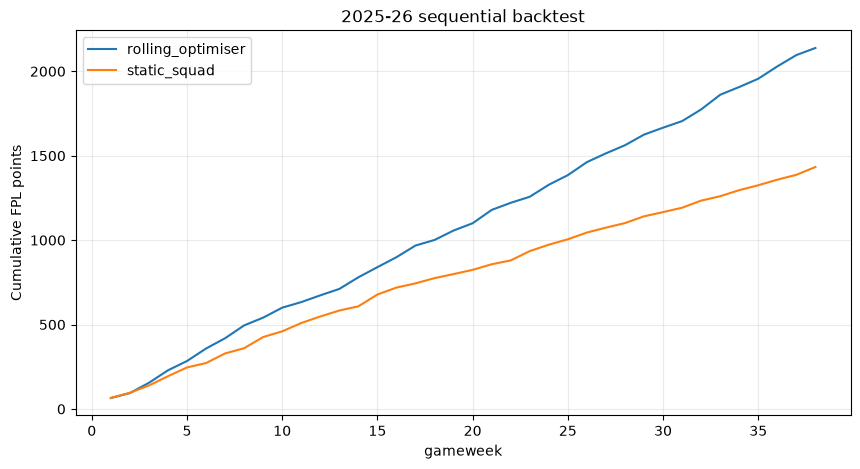

In [71]:
deadline_frozen_forecast_cache.clear()
deadline_frozen_forecast_audit.clear()

backtest_result = run_sequential_fpl_backtest(
    historical_backtest_table,
    backtest_gameweeks,
)

backtest_weekly_results = backtest_result["weekly_results"]
backtest_static_benchmark = backtest_result["static_benchmark"]

backtest_summary = pd.DataFrame([
    {
        "strategy": "Rolling optimiser",
        "gameweeks": len(backtest_weekly_results),
        "total_points": backtest_weekly_results[
            "actual_score"
        ].sum(),
        "total_hits": backtest_weekly_results[
            "hit_cost"
        ].sum(),
        "transfers": backtest_weekly_results[
            "transfers"
        ].sum(),
        "chips_used": backtest_weekly_results[
            "chip"
        ].notna().sum(),
    },
    {
        "strategy": "Static opening squad",
        "gameweeks": len(backtest_static_benchmark),
        "total_points": backtest_static_benchmark[
            "actual_score"
        ].sum(),
        "total_hits": 0.0,
        "transfers": 0,
        "chips_used": 0,
    },
])

display(backtest_summary)
display(backtest_weekly_results)

comparison = (
    backtest_weekly_results[
        ["gameweek", "cumulative_points"]
    ]
    .rename(columns={
        "cumulative_points": "rolling_optimiser",
    })
    .merge(
        backtest_static_benchmark[
            ["gameweek", "cumulative_points"]
        ].rename(columns={
            "cumulative_points": "static_squad",
        }),
        on="gameweek",
        how="left",
        validate="one_to_one",
    )
)

ax = comparison.plot(
    x="gameweek",
    y=["rolling_optimiser", "static_squad"],
    figsize=(10, 5),
    title=f"{BACKTEST_SEASON} sequential backtest",
)
ax.set_ylabel("Cumulative FPL points")
ax.grid(alpha=0.25)

print("Initial backtest squad")
display(
    backtest_result["initial_squad"][
        [
            "web_name",
            "team_short_name",
            "position",
            "price",
        ]
    ].sort_values(["position", "price"], ascending=[True, False])
)

if BACKTEST_MAX_GAMEWEEKS is not None:
    print(
        "Smoke-test mode is active. Set BACKTEST_MAX_GAMEWEEKS = None "
        "and rerun the backtest section for the full season."
    )

print("Deadline-frozen forecast audit")
backtest_forecast_audit = (
    pd.DataFrame(deadline_frozen_forecast_audit)
    .drop_duplicates(
        [
            "forecast_origin_gameweek",
            "first_projected_gameweek",
            "last_projected_gameweek",
        ]
    )
    .sort_values(
        [
            "forecast_origin_gameweek",
            "last_projected_gameweek",
        ]
    )
    .reset_index(drop=True)
)
display(backtest_forecast_audit.head(10))

assert (
    backtest_forecast_audit[
        "player_history_available_through_gw"
    ]
    .lt(
        backtest_forecast_audit[
            "first_projected_gameweek"
        ]
    )
    .all()
), "Player-history leakage detected in the backtest forecast audit."

assert (
    backtest_forecast_audit[
        "team_results_available_through_gw"
    ]
    .lt(
        backtest_forecast_audit[
            "first_projected_gameweek"
        ]
    )
    .all()
), "Team-result leakage detected in the backtest forecast audit."


### Backtest interpretation and remaining limitations

This version freezes every multi-Gameweek forecast at the relevant deadline,
so future player form and future team results cannot enter earlier transfer or
chip decisions.

The backtest remains an initial systems test:

- model parameters are fitted once on 2022/23–2024/25 and are not refitted
  during 2025/26;
- fixture dates and opponents are treated as known according to the archived
  schedule;
- future player transfers are not anticipated: each horizon assumes the
  player remains at the club represented at its forecast origin;
- future prices are held constant within each horizon and refreshed at the
  next simulated deadline;
- the transfer search is approximate;
- blank-team players can be underrepresented in the historical candidate pool
  when the archive contains no player-fixture row for that Gameweek;
- chip thresholds are policy parameters rather than historically calibrated
  values;
- defensive-action coverage is concentrated in 2025/26, so early-season
  defensive-contribution estimates rely heavily on sparse priors.

After a successful strict run, the next validation step is a **walk-forward
multi-season backtest**. Each season should be held out in turn, with transfer
and chip thresholds selected only from earlier seasons.


# 11. Walk-forward multi-season validation

A single successful season is encouraging but not enough to establish that the
decision system generalises. This section evaluates the model in expanding
chronological folds:

| Holdout season | Training seasons |
|---|---|
| 2023/24 | 2022/23 |
| 2024/25 | 2022/23–2023/24 |
| 2025/26 | 2022/23–2024/25 |

Every fold refits the minutes, team-strength and player-event models using only
earlier seasons. The held-out season is never used for fitting or model
selection.

There is an important rules distinction:

- defensive-contribution points were introduced in 2025/26;
- five banked free transfers began in 2024/25;
- chip structures differed before 2025/26.

The cross-season strategy comparison therefore runs **without chips**. This
isolates opening-squad selection, line-ups, captaincy, transfers and hits under
the appropriate free-transfer cap. The full eight-chip strategy remains
evaluated separately on 2025/26, whose chip and defensive-contribution rules
most closely match 2026/27.


In [72]:
from contextlib import contextmanager

WALK_FORWARD_HOLDOUT_SEASONS = [
    "2023-24",
    "2024-25",
    "2025-26",
]

# Use 5 for a quick smoke test. Set to None for complete seasons.
WALK_FORWARD_MAX_GAMEWEEKS: int | None = None

# These profiles isolate the value of planning horizon and transfer hits.
#
# All profiles may use up to two transfers when enough free transfers are
# available. The no-hit profiles never make more transfers than the current
# free-transfer allowance.
WALK_FORWARD_POLICY_PROFILES = {
    "greedy_1gw_no_hits": {
        "horizon": 1,
        "max_transfers_per_gameweek": 2,
        "allow_hits": False,
    },
    "rolling_3gw_no_hits": {
        "horizon": 3,
        "max_transfers_per_gameweek": 2,
        "allow_hits": False,
    },
    "rolling_6gw_no_hits": {
        "horizon": 6,
        "max_transfers_per_gameweek": 2,
        "allow_hits": False,
    },
    "rolling_6gw_hits": {
        "horizon": 6,
        "max_transfers_per_gameweek": 2,
        "allow_hits": True,
    },
}

WALK_FORWARD_ACTIVE_PROFILES = [
    "greedy_1gw_no_hits",
    "rolling_3gw_no_hits",
    "rolling_6gw_no_hits",
    "rolling_6gw_hits",
]

# Cross-season tests disable chips because historical chip rules differ.
WALK_FORWARD_INCLUDE_CHIPS = False

walk_forward_fold_cache: dict[str, dict[str, object]] = {}


In [73]:
def season_start_year(season: str) -> int:
    """Return the first calendar year from an FPL season label."""
    return int(str(season).split("-")[0])


def earlier_historical_seasons(
    holdout_season: str,
) -> list[str]:
    """Return all configured seasons strictly earlier than the holdout."""
    holdout_start = season_start_year(holdout_season)
    return [
        season
        for season in HISTORICAL_SEASONS
        if season_start_year(season) < holdout_start
    ]


def build_walk_forward_fold_bundle(
    holdout_season: str,
) -> dict[str, object]:
    """
    Refit every forecast layer using only seasons before the holdout.

    The returned object contains the fold-specific models, priors, holdout
    rows and expected-point forecasts required by the strategy backtest.
    """
    if holdout_season in walk_forward_fold_cache:
        return walk_forward_fold_cache[holdout_season]

    development_seasons = earlier_historical_seasons(
        holdout_season
    )
    if not development_seasons:
        raise ValueError(
            f"No earlier training season is available for {holdout_season}."
        )

    fold_minutes_training = historical_model_data.loc[
        historical_model_data["season"].isin(
            development_seasons
        )
    ].copy()
    fold_minutes_holdout = historical_model_data.loc[
        historical_model_data["season"].eq(holdout_season)
    ].copy()

    fold_minutes_models = fit_minutes_model_bundle(
        fold_minutes_training
    )

    fold_team_training = historical_team_fixtures.loc[
        historical_team_fixtures["season"].isin(
            development_seasons
        )
    ].copy()
    fold_team_models = fit_team_goal_models(
        fold_team_training
    )

    fold_seasons = development_seasons + [holdout_season]
    fold_team_rows = historical_team_fixtures.loc[
        historical_team_fixtures["season"].isin(fold_seasons)
    ].copy()

    fold_team_predictions = pd.concat(
        [
            fold_team_rows[
                ["season", "fixture_id", "team_key"]
            ].reset_index(drop=True),
            predict_team_goal_components(
                fold_team_models,
                fold_team_rows,
            ).reset_index(drop=True),
        ],
        axis=1,
    )

    fold_points_data = (
        historical_model_data.loc[
            historical_model_data["season"].isin(fold_seasons)
        ]
        .merge(
            fold_team_predictions,
            on=["season", "fixture_id", "team_key"],
            how="left",
            validate="many_to_one",
        )
    )
    fold_points_data = add_player_per90_history_features(
        fold_points_data
    )
    fold_points_data = add_player_event_targets(
        fold_points_data
    )
    fold_points_data = fold_points_data.loc[
        fold_points_data["model_position"].isin(
            PLAYER_SCORING_POSITIONS
        )
    ].copy()

    fold_development_points = fold_points_data.loc[
        fold_points_data["season"].isin(
            development_seasons
        )
    ].copy()
    fold_holdout_points = fold_points_data.loc[
        fold_points_data["season"].eq(holdout_season)
    ].copy()

    fold_player_event_models = fit_player_event_rate_models(
        fold_development_points
    )

    fold_holdout_minutes = predict_minutes_components(
        fold_minutes_models,
        fold_holdout_points,
    )
    fold_holdout_event_rates = predict_player_event_rates(
        fold_player_event_models,
        fold_holdout_points,
    )

    fold_xp_inputs = pd.concat(
        [
            fold_holdout_points.reset_index(drop=True),
            fold_holdout_minutes.reset_index(drop=True),
            fold_holdout_event_rates.reset_index(drop=True),
        ],
        axis=1,
    )

    fold_defensive_action_priors = (
        defensive_action_position_priors(
            fold_development_points
        )
    )
    fold_defensive_return_priors = (
        defensive_return_position_priors(
            fold_development_points
        )
    )
    fold_rare_event_rates = rare_event_position_rates(
        fold_development_points
    )

    fold_xp_components = calculate_component_expected_points(
        fold_xp_inputs,
        fold_defensive_action_priors,
        fold_rare_event_rates,
        fold_defensive_return_priors,
    )

    # Defensive contributions were not part of FPL scoring before 2025/26.
    if season_start_year(holdout_season) < 2025:
        fold_xp_components["expected_points"] = (
            fold_xp_components["expected_points"]
            - fold_xp_components["xp_defensive_contribution"]
        )
        fold_xp_components["xp_defensive_contribution"] = 0.0

    fold_expected_points = pd.concat(
        [
            fold_xp_inputs.reset_index(drop=True),
            fold_xp_components.reset_index(drop=True),
        ],
        axis=1,
    )

    bundle = {
        "holdout_season": holdout_season,
        "development_seasons": development_seasons,
        "minutes_models": fold_minutes_models,
        "team_goal_models": fold_team_models,
        "player_event_models": fold_player_event_models,
        "defensive_action_priors": (
            fold_defensive_action_priors
        ),
        "defensive_return_priors": (
            fold_defensive_return_priors
        ),
        "rare_event_rates": fold_rare_event_rates,
        "holdout_points_data": fold_holdout_points,
        "holdout_expected_points": fold_expected_points,
    }
    walk_forward_fold_cache[holdout_season] = bundle
    return bundle


def walk_forward_prediction_metrics(
    bundle: dict[str, object],
) -> dict[str, object]:
    """Calculate prediction metrics for one untouched season."""
    holdout = bundle["holdout_expected_points"]
    development_seasons = bundle["development_seasons"]

    valid = holdout["target_fpl_points"].notna()
    actual = holdout.loc[valid, "target_fpl_points"]
    predicted = holdout.loc[valid, "expected_points"]

    development_rows = historical_points_data.loc[
        historical_points_data["season"].isin(
            development_seasons
        )
    ]
    position_prior = (
        development_rows.groupby("model_position")[
            "target_fpl_points"
        ].mean()
    )
    global_prior = float(
        development_rows["target_fpl_points"].mean()
    )
    baseline = (
        coalesced_history_baseline(
            holdout,
            [
                "points_per_fixture_last_5_gws",
                "points_per_fixture_last_10_gws",
                "career_points_per_fixture",
            ],
            position_prior,
        )
        .fillna(global_prior)
        .clip(lower=-3.0, upper=20.0)
    )

    minutes_actual = pd.to_numeric(
        holdout.loc[valid, "target_minutes"],
        errors="coerce",
    )
    minutes_predicted = pd.to_numeric(
        holdout.loc[valid, "expected_minutes"],
        errors="coerce",
    )

    return {
        "holdout_season": bundle["holdout_season"],
        "training_seasons": ", ".join(development_seasons),
        "rows": int(valid.sum()),
        "xp_mae": mean_absolute_error(actual, predicted),
        "baseline_mae": mean_absolute_error(actual, baseline.loc[valid]),
        "xp_rmse": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "xp_spearman": spearmanr(
            actual,
            predicted,
            nan_policy="omit",
        ).statistic,
        "baseline_spearman": spearmanr(
            actual,
            baseline.loc[valid],
            nan_policy="omit",
        ).statistic,
        "xp_bias": float((predicted - actual).mean()),
        "minutes_mae": mean_absolute_error(
            minutes_actual,
            minutes_predicted,
        ),
    }


In [74]:
walk_forward_prediction_rows = []
for fold_season in WALK_FORWARD_HOLDOUT_SEASONS:
    print(f"Fitting walk-forward fold {fold_season}...")
    fold_bundle = build_walk_forward_fold_bundle(
        fold_season
    )
    walk_forward_prediction_rows.append(
        walk_forward_prediction_metrics(fold_bundle)
    )

walk_forward_prediction_scorecard = pd.DataFrame(
    walk_forward_prediction_rows
)

display(walk_forward_prediction_scorecard)

walk_forward_prediction_summary = pd.DataFrame([{
    "folds": len(walk_forward_prediction_scorecard),
    "mean_xp_mae": (
        walk_forward_prediction_scorecard["xp_mae"].mean()
    ),
    "mean_baseline_mae": (
        walk_forward_prediction_scorecard["baseline_mae"].mean()
    ),
    "mean_xp_spearman": (
        walk_forward_prediction_scorecard["xp_spearman"].mean()
    ),
    "mean_baseline_spearman": (
        walk_forward_prediction_scorecard[
            "baseline_spearman"
        ].mean()
    ),
}])
display(walk_forward_prediction_summary)


Fitting walk-forward fold 2023-24...
Fitting walk-forward fold 2024-25...
Fitting walk-forward fold 2025-26...


,holdout_season,training_seasons,rows,xp_mae,baseline_mae,xp_rmse,xp_spearman,baseline_spearman,xp_bias,minutes_mae
0,2023-24,2022-23,29725,0.936563,1.007553,1.944637,0.679664,0.672584,-0.117829,15.066765
1,2024-25,"2022-23, 2023-24",27283,1.006727,1.057135,1.924889,0.703347,0.683129,-0.020349,14.469616
2,2025-26,"2022-23, 2023-24, 2024-25",29747,0.976344,1.055518,1.928855,0.717790,0.705940,-0.066275,13.338312


,folds,mean_xp_mae,mean_baseline_mae,mean_xp_spearman,mean_baseline_spearman
0,3,0.973211,1.040069,0.700267,0.687218


In [75]:
@contextmanager
def activated_walk_forward_context(
    bundle: dict[str, object],
    policy_profile: dict[str, int],
):
    """Temporarily activate one fold without contaminating other folds."""
    holdout_season = str(bundle["holdout_season"])

    replacement_values = {
        "BACKTEST_SEASON": holdout_season,
        "BACKTEST_HORIZON": int(
            policy_profile["horizon"]
        ),
        "BACKTEST_MAX_GAMEWEEKS": (
            WALK_FORWARD_MAX_GAMEWEEKS
        ),
        "BACKTEST_INCLUDE_CHIPS": (
            WALK_FORWARD_INCLUDE_CHIPS
        ),
        "MAX_TRANSFERS_PER_GAMEWEEK": int(
            policy_profile[
                "max_transfers_per_gameweek"
            ]
        ),
        "ALLOW_TRANSFER_HITS": bool(
            policy_profile["allow_hits"]
        ),
        "MAX_BANKED_FREE_TRANSFERS": (
            2 if season_start_year(holdout_season) < 2024 else 5
        ),
        "minutes_models": bundle["minutes_models"],
        "team_goal_models": bundle["team_goal_models"],
        "player_event_models": (
            bundle["player_event_models"]
        ),
        "development_defensive_action_priors": (
            bundle["defensive_action_priors"]
        ),
        "development_defensive_return_priors": (
            bundle["defensive_return_priors"]
        ),
        "development_rare_event_rates": (
            bundle["rare_event_rates"]
        ),
        "holdout_points_data": (
            bundle["holdout_points_data"]
        ),
    }

    original_values = {
        name: globals()[name]
        for name in replacement_values
    }

    globals().update(replacement_values)
    deadline_frozen_forecast_cache.clear()
    deadline_frozen_forecast_audit.clear()

    try:
        yield
    finally:
        globals().update(original_values)
        deadline_frozen_forecast_cache.clear()
        deadline_frozen_forecast_audit.clear()


def run_walk_forward_strategy_fold(
    bundle: dict[str, object],
    profile_name: str,
) -> dict[str, object]:
    """Run one chipless, strict-deadline strategy fold."""
    profile = WALK_FORWARD_POLICY_PROFILES[
        profile_name
    ]

    with activated_walk_forward_context(
        bundle,
        profile,
    ):
        backtest_table = build_historical_backtest_table(
            bundle["holdout_expected_points"]
        )
        gameweeks = sorted(
            backtest_table["gameweek"].unique()
        )
        if WALK_FORWARD_MAX_GAMEWEEKS is not None:
            gameweeks = gameweeks[
                :int(WALK_FORWARD_MAX_GAMEWEEKS)
            ]

        result = run_sequential_fpl_backtest(
            backtest_table,
            gameweeks,
        )

        audit = pd.DataFrame(
            deadline_frozen_forecast_audit
        )
        if not audit.empty:
            assert (
                audit["player_history_available_through_gw"]
                .lt(audit["first_projected_gameweek"])
                .all()
            )
            assert (
                audit["team_results_available_through_gw"]
                .lt(audit["first_projected_gameweek"])
                .all()
            )

        weekly = result["weekly_results"]
        static = result["static_benchmark"]

        return {
            "holdout_season": bundle["holdout_season"],
            "profile": profile_name,
            "horizon": int(profile["horizon"]),
            "allow_hits": bool(profile["allow_hits"]),
            "gameweeks": len(weekly),
            "strategy_points": float(
                weekly["actual_score"].sum()
            ),
            "static_points": float(
                static["actual_score"].sum()
            ),
            "gain_vs_static": float(
                weekly["actual_score"].sum()
                - static["actual_score"].sum()
            ),
            "hit_points": float(weekly["hit_cost"].sum()),
            "paid_transfers": int(
                round(
                    float(weekly["hit_cost"].sum())
                    / float(TRANSFER_HIT_COST)
                )
            ),
            "transfers": int(
                weekly["transfers"].sum()
            ),
            "prediction_bias": float(
                (
                    weekly["predicted_score"]
                    - weekly["actual_score"]
                ).mean()
            ),
            "weekly_results": weekly,
            "initial_squad": result["initial_squad"],
        }


In [76]:
walk_forward_strategy_results = []
walk_forward_strategy_details = {}

for fold_season in WALK_FORWARD_HOLDOUT_SEASONS:
    bundle = build_walk_forward_fold_bundle(
        fold_season
    )
    for profile_name in WALK_FORWARD_ACTIVE_PROFILES:
        print(
            f"Running {fold_season} strategy fold "
            f"with profile '{profile_name}'..."
        )
        fold_result = run_walk_forward_strategy_fold(
            bundle,
            profile_name,
        )
        walk_forward_strategy_details[
            (fold_season, profile_name)
        ] = fold_result
        walk_forward_strategy_results.append({
            key: value
            for key, value in fold_result.items()
            if key not in {
                "weekly_results",
                "initial_squad",
            }
        })

walk_forward_strategy_scorecard = pd.DataFrame(
    walk_forward_strategy_results
).sort_values(
    ["holdout_season", "strategy_points"],
    ascending=[True, False],
).reset_index(drop=True)

display(walk_forward_strategy_scorecard)

if WALK_FORWARD_MAX_GAMEWEEKS is not None:
    print(
        "Walk-forward smoke-test mode is active. "
        "Set WALK_FORWARD_MAX_GAMEWEEKS = None and rerun "
        "Section 11 for complete seasons."
    )


Running 2023-24 strategy fold with profile 'greedy_1gw_no_hits'...
Running 2023-24 strategy fold with profile 'rolling_3gw_no_hits'...
Running 2023-24 strategy fold with profile 'rolling_6gw_no_hits'...
Running 2023-24 strategy fold with profile 'rolling_6gw_hits'...
Running 2024-25 strategy fold with profile 'greedy_1gw_no_hits'...
Running 2024-25 strategy fold with profile 'rolling_3gw_no_hits'...
Running 2024-25 strategy fold with profile 'rolling_6gw_no_hits'...
Running 2024-25 strategy fold with profile 'rolling_6gw_hits'...
Running 2025-26 strategy fold with profile 'greedy_1gw_no_hits'...
Running 2025-26 strategy fold with profile 'rolling_3gw_no_hits'...
Running 2025-26 strategy fold with profile 'rolling_6gw_no_hits'...
Running 2025-26 strategy fold with profile 'rolling_6gw_hits'...


,holdout_season,profile,horizon,allow_hits,gameweeks,strategy_points,static_points,gain_vs_static,hit_points,paid_transfers,transfers,prediction_bias
0,2023-24,rolling_3gw_no_hits,3,False,38,2240.0,1969.0,271.0,0.0,0,38,-14.285662
1,2023-24,rolling_6gw_no_hits,6,False,38,2158.0,1996.0,162.0,0.0,0,38,-13.172274
2,2023-24,rolling_6gw_hits,6,True,38,2150.0,1996.0,154.0,32.0,8,46,-12.714365
3,2023-24,greedy_1gw_no_hits,1,False,38,2058.0,1671.0,387.0,0.0,0,38,-11.289642
4,2024-25,greedy_1gw_no_hits,1,False,38,2333.0,2262.0,71.0,0.0,0,38,-13.112097
5,2024-25,rolling_3gw_no_hits,3,False,38,2141.0,1773.0,368.0,0.0,0,38,-8.371510
6,2024-25,rolling_6gw_hits,6,True,38,2112.0,1750.0,362.0,12.0,3,41,-7.185155
7,2024-25,rolling_6gw_no_hits,6,False,38,1990.0,1750.0,240.0,0.0,0,38,-4.877342
8,2025-26,greedy_1gw_no_hits,1,False,38,2044.0,1474.0,570.0,0.0,0,38,-5.394982
9,2025-26,rolling_6gw_no_hits,6,False,38,2014.0,1433.0,581.0,0.0,0,38,-3.740349


### Historical club-transfer edge case

If a real-world Premier League transfer temporarily creates more than three owned players from one club, FPL allows the squad to be held. The next transfer must reduce the excess. The transfer planner models this transitional state rather than rejecting the squad.


### Interpreting the policy comparison

This comparison separates four questions:

1. Does looking beyond the next Gameweek improve decisions?
2. Is a three-Gameweek horizon sufficient?
3. Does extending the horizon from three to six Gameweeks help?
4. Do paid transfers add enough realised points to justify their deductions?

The one-Gameweek no-hit profile is the strongest simple benchmark because it
uses the same forecasts, line-up logic and current squad state, but does not
attempt multi-Gameweek planning.

Profile selection should not rely on the highest score in one season. Prefer a
policy that performs consistently across folds, avoids a poor worst season and
does not depend heavily on transfer hits.


In [77]:
profile_season_pivot = (
    walk_forward_strategy_scorecard
    .pivot(
        index="holdout_season",
        columns="profile",
        values="strategy_points",
    )
)

print("Realised points by season and policy")
display(profile_season_pivot)

profile_summary = (
    walk_forward_strategy_scorecard
    .groupby(
        [
            "profile",
            "horizon",
            "allow_hits",
        ],
        as_index=False,
    )
    .agg(
        seasons=("holdout_season", "nunique"),
        mean_points=("strategy_points", "mean"),
        median_points=("strategy_points", "median"),
        minimum_points=("strategy_points", "min"),
        maximum_points=("strategy_points", "max"),
        points_std=("strategy_points", "std"),
        mean_gain_vs_static=("gain_vs_static", "mean"),
        total_hit_points=("hit_points", "sum"),
        total_paid_transfers=("paid_transfers", "sum"),
        mean_transfers=("transfers", "mean"),
        mean_prediction_bias=("prediction_bias", "mean"),
    )
)

# Rank each policy within each holdout season, then average the ranks.
season_rank = (
    walk_forward_strategy_scorecard
    .assign(
        season_rank=lambda frame: (
            frame.groupby("holdout_season")[
                "strategy_points"
            ]
            .rank(
                method="average",
                ascending=False,
            )
        )
    )
    .groupby("profile", as_index=False)
    .agg(
        mean_season_rank=("season_rank", "mean"),
        worst_season_rank=("season_rank", "max"),
    )
)

profile_summary = (
    profile_summary
    .merge(
        season_rank,
        on="profile",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "mean_season_rank",
            "minimum_points",
            "mean_points",
        ],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)

print("Cross-season policy summary")
display(profile_summary)

greedy_profile = "greedy_1gw_no_hits"
policy_increment_table = (
    profile_season_pivot
    .subtract(
        profile_season_pivot[greedy_profile],
        axis=0,
    )
    .rename_axis(
        index="holdout_season",
        columns="profile",
    )
)

print("Realised gain versus the one-Gameweek no-hit policy")
display(policy_increment_table)

recommended_policy_profile = str(
    profile_summary.iloc[0]["profile"]
)

print(
    "Provisional production policy:",
    recommended_policy_profile,
)
print(
    "This is selected by mean within-season rank, then worst-season "
    "performance and mean points. It should be treated as a historical "
    "policy choice, not as an unbiased estimate of future performance."
)

# Practical hit audit for the paid-transfer profile.
hit_profile_rows = walk_forward_strategy_scorecard.loc[
    walk_forward_strategy_scorecard["allow_hits"]
].copy()

if not hit_profile_rows.empty:
    hit_profile_name = str(
        hit_profile_rows.iloc[0]["profile"]
    )
    no_hit_comparator = "rolling_6gw_no_hits"

    if (
        no_hit_comparator
        in set(walk_forward_strategy_scorecard["profile"])
    ):
        hit_comparison = (
            walk_forward_strategy_scorecard.loc[
                walk_forward_strategy_scorecard["profile"].isin(
                    [hit_profile_name, no_hit_comparator]
                ),
                [
                    "holdout_season",
                    "profile",
                    "strategy_points",
                    "hit_points",
                    "paid_transfers",
                ],
            ]
            .pivot(
                index="holdout_season",
                columns="profile",
                values="strategy_points",
            )
            .reset_index()
        )
        hit_comparison["gain_from_allowing_hits"] = (
            hit_comparison[hit_profile_name]
            - hit_comparison[no_hit_comparator]
        )

        hit_costs = (
            hit_profile_rows[
                [
                    "holdout_season",
                    "hit_points",
                    "paid_transfers",
                ]
            ]
        )
        hit_comparison = hit_comparison.merge(
            hit_costs,
            on="holdout_season",
            how="left",
            validate="one_to_one",
        )

        print("Six-Gameweek hit-policy audit")
        display(hit_comparison)


Realised points by season and policy


profile,greedy_1gw_no_hits,rolling_3gw_no_hits,rolling_6gw_hits,rolling_6gw_no_hits
holdout_season,,,,
2023-24,2058.0,2240.0,2150.0,2158.0
2024-25,2333.0,2141.0,2112.0,1990.0
2025-26,2044.0,1991.0,2014.0,2014.0


Cross-season policy summary


,profile,horizon,allow_hits,seasons,mean_points,median_points,minimum_points,maximum_points,points_std,mean_gain_vs_static,total_hit_points,total_paid_transfers,mean_transfers,mean_prediction_bias,mean_season_rank,worst_season_rank
0,greedy_1gw_no_hits,1,False,3,2145.0,2058.0,2044.0,2333.0,162.963186,342.666667,0.0,0,38.000000,-9.932241,2.000000,4.0
1,rolling_3gw_no_hits,3,False,3,2124.0,2141.0,1991.0,2240.0,125.367460,363.000000,0.0,0,38.000000,-8.816681,2.333333,4.0
2,rolling_6gw_hits,6,True,3,2092.0,2112.0,2014.0,2150.0,70.171219,365.666667,56.0,14,42.666667,-8.005920,2.833333,3.0
3,rolling_6gw_no_hits,6,False,3,2054.0,2014.0,1990.0,2158.0,90.862534,327.666667,0.0,0,38.000000,-7.263322,2.833333,4.0


Realised gain versus the one-Gameweek no-hit policy


profile,greedy_1gw_no_hits,rolling_3gw_no_hits,rolling_6gw_hits,rolling_6gw_no_hits
holdout_season,,,,
2023-24,0.0,182.0,92.0,100.0
2024-25,0.0,-192.0,-221.0,-343.0
2025-26,0.0,-53.0,-30.0,-30.0


Provisional production policy: greedy_1gw_no_hits
This is selected by mean within-season rank, then worst-season performance and mean points. It should be treated as a historical policy choice, not as an unbiased estimate of future performance.
Six-Gameweek hit-policy audit


,holdout_season,rolling_6gw_hits,rolling_6gw_no_hits,gain_from_allowing_hits,hit_points,paid_transfers
0,2023-24,2150.0,2158.0,-8.0,32.0,8
1,2024-25,2112.0,1990.0,122.0,12.0,3
2,2025-26,2014.0,2014.0,0.0,12.0,3


### Readiness decision

The system is ready for the final weekly interface when:

- the expected-points model beats its rolling baseline across folds;
- one planning policy performs robustly across seasons;
- longer horizons outperform or at least match the one-Gameweek benchmark;
- paid transfers improve realised points after their deductions, rather than
  merely increasing activity;
- no single season determines the selected policy.

After selecting the production policy, the final notebook stage will turn the
model outputs into one concise weekly recommendation:

- transfers or roll;
- starting XI and formation;
- bench order;
- captain and vice-captain;
- chip recommendation;
- expected score and uncertainty;
- alternative actions and their projected cost.


# 12. Weekly live recommendation dashboard

This is the production interface to run before each FPL deadline.

### Weekly routine

1. Restart the kernel.
2. Run the notebook through **Section 10: Chip evaluation and timing** so the
   current FPL data, projections and fitted model objects are available.
   Sections 10A–11 are validation sections and do not need to be rerun weekly.
3. Update the state inputs below.
4. Run the remaining cells in Section 12.

The section:

- checks that the in-memory projections still match the latest official FPL API;
- accepts player IDs or exact player names;
- reconstructs current selling prices from purchase prices when possible;
- applies optional late-news projection overrides;
- reruns the selected rolling transfer policy;
- compares rolling, transfers and paid transfers;
- evaluates all available chips;
- outputs the recommended transfer action, XI, bench, captain, vice-captain,
  chip decision and the provisional plan for later Gameweeks;
- writes one overwriteable JSON output file, rather than creating many files.

Only the current Gameweek action should be executed. The later plan is context
for the current decision and will be recalculated at the next deadline.

### Production safeguards

- `WEEKLY_POLICY_PROFILE = "auto"` uses the policy selected by Section 11 when it is present in memory and otherwise falls back to the conservative six-Gameweek no-hit policy.
- Chip use is subject to an additional structural gate. A chip that looks best inside six weeks is not automatically used unless the schedule, expiry pressure or an exceptional uplift supports acting now.
- Gameweek 1 is treated as initial-squad selection rather than a transfer roll.


In [78]:
# Weekly state inputs ---------------------------------------------------------
#
# Player references can be official FPL player IDs or exact `web_name` /
# `full_name` values from the current player table.

WEEKLY_CURRENT_SQUAD = [
    # Enter exactly 15 players after Gameweek 1.
    # Example:
    # 123,
    # "Salah",
]

WEEKLY_MONEY_IN_BANK = 0.0
WEEKLY_FREE_TRANSFERS = 1

# Enter the purchase price or current FPL selling price only when needed.
# Explicit selling prices take precedence over calculated selling prices.
# Keys may be player IDs or exact player names.
WEEKLY_PURCHASE_PRICES = {
    # "Salah": 12.5,
}
WEEKLY_SELLING_PRICES = {
    # "Salah": 12.7,
}

# Update these after using a chip. These values refer to the active half-season
# chip set.
WEEKLY_AVAILABLE_CHIPS = {
    "triple_captain": True,
    "bench_boost": True,
    "free_hit": True,
    "wildcard": True,
}
WEEKLY_LAST_FREE_HIT_GAMEWEEK = None

# Production policy. Change this after Section 11 identifies a better policy.
WEEKLY_POLICY_PROFILES = {
    "greedy_1gw_no_hits": {
        "horizon": 1,
        "max_transfers_per_gameweek": 2,
        "allow_hits": False,
    },
    "rolling_3gw_no_hits": {
        "horizon": 3,
        "max_transfers_per_gameweek": 2,
        "allow_hits": False,
    },
    "rolling_6gw_no_hits": {
        "horizon": 6,
        "max_transfers_per_gameweek": 2,
        "allow_hits": False,
    },
    "rolling_6gw_hits": {
        "horizon": 6,
        "max_transfers_per_gameweek": 2,
        "allow_hits": True,
    },
}

# "auto" uses Section 11's historically preferred profile when available.
# The fallback is deliberately conservative for a fresh weekly kernel.
WEEKLY_POLICY_PROFILE = "auto"
WEEKLY_POLICY_FALLBACK = "rolling_6gw_no_hits"

# Optional manual adjustments for reliable late information not yet reflected
# by the FPL API. Values are multiplicative factors between 0 and 1.
#
# Current-GW multipliers affect only the imminent deadline.
# Horizon multipliers affect every projected Gameweek.
WEEKLY_CURRENT_GW_PROJECTION_MULTIPLIERS = {
    # "Player name": 0.0,  # confirmed out this Gameweek
}
WEEKLY_HORIZON_PROJECTION_MULTIPLIERS = {
    # "Player name": 0.5,  # expected reduced availability across the horizon
}

# Stop when the official API has changed since the live projection cells ran.
# This prevents decisions from being produced from stale prices, injuries or
# rearranged fixtures.
WEEKLY_STRICT_FRESHNESS_CHECK = True

# Conservative chip thresholds and production readiness gate.
WEEKLY_CHIP_MINIMUM_UPLIFT = {
    "triple_captain": 7.0,
    "bench_boost": 9.0,
    "free_hit": 8.0,
    "wildcard": 10.0,
}
WEEKLY_CHIP_CURRENT_VS_HORIZON_RATIO = 0.95

# A six-Gameweek horizon is not sufficient evidence by itself to spend a chip.
# In conservative mode, use-now recommendations also require a blank/double,
# chip-expiry pressure, a transfer-structure reason for Wildcard, or an
# exceptional current uplift.
WEEKLY_CHIP_DECISION_MODE = "conservative"
WEEKLY_CHIP_REQUIRE_STRUCTURAL_TRIGGER = True
WEEKLY_CHIP_EXCEPTIONAL_UPLIFT = {
    "triple_captain": 10.0,
    "bench_boost": 15.0,
    "free_hit": 12.0,
    "wildcard": 15.0,
}

# Keep one current output file, overwritten on every run.
WEEKLY_SAVE_OUTPUT = True
WEEKLY_OUTPUT_PATH = Path(
    "outputs/latest_weekly_recommendation.json"
)


In [79]:
from contextlib import contextmanager
from datetime import datetime, timezone


def weekly_resolve_player_reference(
    reference,
    player_table: pd.DataFrame,
) -> int:
    """Resolve one official player ID or exact current player name."""
    valid_ids = set(
        pd.to_numeric(
            player_table["id"],
            errors="coerce",
        ).dropna().astype(int)
    )

    if isinstance(reference, (int, np.integer)):
        player_id = int(reference)
        if player_id not in valid_ids:
            raise ValueError(
                f"Player ID {player_id} is not in the current FPL data."
            )
        return player_id

    text = str(reference).strip()
    if text.isdigit():
        player_id = int(text)
        if player_id in valid_ids:
            return player_id

    normalised = text.casefold()
    matches = player_table.loc[
        player_table["web_name"].fillna("").astype(str)
        .str.strip().str.casefold().eq(normalised)
        |
        player_table["full_name"].fillna("").astype(str)
        .str.strip().str.casefold().eq(normalised)
    ]

    if matches.empty:
        raise ValueError(
            f"Could not resolve player reference {reference!r}. "
            "Use an official player ID or an exact current player name."
        )
    if matches["id"].nunique() != 1:
        options = (
            matches[
                ["id", "web_name", "team_short_name", "position"]
            ]
            .drop_duplicates()
            .to_dict("records")
        )
        raise ValueError(
            f"Player reference {reference!r} is ambiguous: {options}"
        )
    return int(matches.iloc[0]["id"])


def weekly_resolve_squad(
    squad_references,
    player_table: pd.DataFrame,
    next_gameweek: int,
) -> list[int]:
    """Resolve and validate the configured live squad."""
    references = list(squad_references)
    if not references:
        if int(next_gameweek) == 1:
            return []
        raise ValueError(
            "WEEKLY_CURRENT_SQUAD must contain the 15 current players "
            "after Gameweek 1."
        )

    squad_ids = [
        weekly_resolve_player_reference(reference, player_table)
        for reference in references
    ]
    if len(squad_ids) != 15 or len(set(squad_ids)) != 15:
        raise ValueError(
            "WEEKLY_CURRENT_SQUAD must resolve to exactly 15 unique players."
        )
    return squad_ids


def weekly_resolve_price_mapping(
    configured_mapping: dict,
    player_table: pd.DataFrame,
) -> dict[int, float]:
    """Resolve a name/ID keyed price mapping to official player IDs."""
    resolved = {}
    for reference, price in dict(configured_mapping).items():
        player_id = weekly_resolve_player_reference(
            reference,
            player_table,
        )
        numeric_price = float(price)
        if not np.isfinite(numeric_price) or numeric_price <= 0:
            raise ValueError(
                f"Invalid price {price!r} for player {reference!r}."
            )
        resolved[player_id] = numeric_price
    return resolved


def weekly_calculate_selling_price(
    purchase_price: float,
    current_price: float,
) -> float:
    """Apply FPL's half-profit selling-price rule in integer tenths."""
    purchase_tenths = price_to_tenths(purchase_price)
    current_tenths = price_to_tenths(current_price)

    if current_tenths <= purchase_tenths:
        selling_tenths = current_tenths
    else:
        selling_tenths = (
            purchase_tenths
            + (current_tenths - purchase_tenths) // 2
        )
    return tenths_to_price(selling_tenths)


def weekly_build_selling_prices(
    squad_ids: list[int],
    candidates: pd.DataFrame,
    purchase_prices: dict[int, float],
    explicit_selling_prices: dict[int, float],
) -> tuple[dict[int, float], list[str]]:
    """Return current selling prices and any assumptions that were required."""
    market_lookup = (
        candidates
        .set_index("player_id")["price"]
        .astype(float)
        .to_dict()
    )

    selling_prices = {}
    warnings = []
    for player_id in squad_ids:
        current_price = float(market_lookup[player_id])

        if player_id in explicit_selling_prices:
            selling_price = float(
                explicit_selling_prices[player_id]
            )
        elif player_id in purchase_prices:
            selling_price = weekly_calculate_selling_price(
                purchase_prices[player_id],
                current_price,
            )
        else:
            selling_price = current_price
            warnings.append(
                f"No purchase/selling price was supplied for player ID "
                f"{player_id}; current market price was used."
            )

        selling_prices[player_id] = selling_price

    return selling_prices, warnings


def weekly_apply_projection_multipliers(
    gameweek_projections: pd.DataFrame,
    player_table: pd.DataFrame,
    next_gameweek: int,
    current_gameweek_multipliers: dict,
    horizon_multipliers: dict,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Apply transparent manual late-news adjustments."""
    adjusted = gameweek_projections.copy()
    audit_rows = []

    def apply_one(reference, factor, gameweek_scope):
        player_id = weekly_resolve_player_reference(
            reference,
            player_table,
        )
        factor = float(factor)
        if not np.isfinite(factor) or not 0.0 <= factor <= 1.0:
            raise ValueError(
                f"Projection multiplier for {reference!r} must be "
                "between 0 and 1."
            )

        mask = adjusted["player_id"].eq(player_id)
        if gameweek_scope is not None:
            mask &= adjusted["gameweek"].eq(
                int(gameweek_scope)
            )

        affected_rows = int(mask.sum())
        if affected_rows == 0:
            raise ValueError(
                f"Projection override for {reference!r} matched no "
                "player–Gameweek rows."
            )

        old_appearance = pd.to_numeric(
            adjusted.loc[mask, "appearance_probability"],
            errors="coerce",
        ).fillna(0.0)

        for column in [
            "expected_points",
            "expected_minutes",
            "projected_goals",
            "projected_assists",
        ] + [
            column
            for column in XP_COMPONENT_COLUMNS
            if column in adjusted.columns
        ]:
            if column in adjusted.columns:
                adjusted.loc[mask, column] = (
                    pd.to_numeric(
                        adjusted.loc[mask, column],
                        errors="coerce",
                    ).fillna(0.0)
                    * factor
                )

        adjusted_appearance = (
            old_appearance * factor
        ).clip(0.0, 1.0)
        adjusted.loc[
            mask,
            "appearance_probability",
        ] = adjusted_appearance
        adjusted.loc[
            mask,
            "no_appearance_probability",
        ] = 1.0 - adjusted_appearance

        player_row = player_table.loc[
            player_table["id"].eq(player_id)
        ].iloc[0]
        audit_rows.append({
            "player_id": player_id,
            "player": player_row["web_name"],
            "scope": (
                f"GW{int(gameweek_scope)}"
                if gameweek_scope is not None
                else "Full horizon"
            ),
            "multiplier": factor,
            "affected_rows": affected_rows,
        })

    for reference, factor in dict(
        horizon_multipliers
    ).items():
        apply_one(reference, factor, None)

    for reference, factor in dict(
        current_gameweek_multipliers
    ).items():
        apply_one(reference, factor, int(next_gameweek))

    return adjusted, pd.DataFrame(audit_rows)


def weekly_projection_freshness_audit(
    in_memory_players: pd.DataFrame,
    in_memory_fixtures: pd.DataFrame,
    in_memory_gameweeks: pd.DataFrame,
    in_memory_gameweek_xp: pd.DataFrame,
) -> dict[str, object]:
    """Compare the live API with the data used to create the projections."""
    latest_bootstrap = get_fpl_data("bootstrap-static/")
    latest_fixtures_raw = get_fpl_data("fixtures/")

    latest_events = pd.DataFrame(
        latest_bootstrap["events"]
    )
    latest_next_gameweek = get_first_planning_gameweek(
        latest_events,
    )

    projected_gameweeks = sorted(
        pd.to_numeric(
            in_memory_gameweek_xp["gameweek"],
            errors="coerce",
        ).dropna().astype(int).unique()
    )
    projected_next_gameweek = (
        int(projected_gameweeks[0])
        if projected_gameweeks
        else None
    )

    latest_players = pd.DataFrame(
        latest_bootstrap["elements"]
    )
    latest_player_state = latest_players[
        [
            "id",
            "now_cost",
            "status",
            "chance_of_playing_next_round",
            "news",
        ]
    ].copy()
    latest_player_state["latest_price"] = (
        pd.to_numeric(
            latest_player_state["now_cost"],
            errors="coerce",
        ) / 10.0
    )

    memory_player_state = in_memory_players[
        [
            "id",
            "price",
            "status",
            "chance_of_playing_next_round",
            "news",
        ]
    ].copy().rename(columns={
        "price": "memory_price",
        "status": "memory_status",
        "chance_of_playing_next_round": "memory_chance",
        "news": "memory_news",
    })

    player_comparison = latest_player_state.merge(
        memory_player_state,
        on="id",
        how="outer",
    )

    price_changes = (
        pd.to_numeric(
            player_comparison["latest_price"],
            errors="coerce",
        ).round(1)
        !=
        pd.to_numeric(
            player_comparison["memory_price"],
            errors="coerce",
        ).round(1)
    )
    status_changes = (
        player_comparison["status"].fillna("").astype(str)
        !=
        player_comparison["memory_status"].fillna("").astype(str)
    )
    chance_changes = (
        pd.to_numeric(
            player_comparison[
                "chance_of_playing_next_round"
            ],
            errors="coerce",
        ).fillna(-1)
        !=
        pd.to_numeric(
            player_comparison["memory_chance"],
            errors="coerce",
        ).fillna(-1)
    )
    news_changes = (
        player_comparison["news"].fillna("").astype(str).str.strip()
        !=
        player_comparison["memory_news"].fillna("").astype(str).str.strip()
    )
    changed_player_rows = int(
        (
            price_changes
            | status_changes
            | chance_changes
            | news_changes
        ).sum()
    )

    latest_fixture_state = pd.DataFrame(
        latest_fixtures_raw
    )[
        ["id", "event", "team_h", "team_a", "kickoff_time"]
    ].copy()
    latest_fixture_state["kickoff_time"] = pd.to_datetime(
        latest_fixture_state["kickoff_time"],
        utc=True,
        errors="coerce",
    )

    memory_fixture_state = in_memory_fixtures[
        ["id", "event", "team_h", "team_a", "kickoff_time"]
    ].copy()
    memory_fixture_state["kickoff_time"] = pd.to_datetime(
        memory_fixture_state["kickoff_time"],
        utc=True,
        errors="coerce",
    )

    fixture_comparison = latest_fixture_state.merge(
        memory_fixture_state,
        on="id",
        how="outer",
        suffixes=("_latest", "_memory"),
    )
    fixture_changed = (
        fixture_comparison["event_latest"].fillna(-1)
        != fixture_comparison["event_memory"].fillna(-1)
    ) | (
        fixture_comparison["team_h_latest"].fillna(-1)
        != fixture_comparison["team_h_memory"].fillna(-1)
    ) | (
        fixture_comparison["team_a_latest"].fillna(-1)
        != fixture_comparison["team_a_memory"].fillna(-1)
    ) | (
        fixture_comparison["kickoff_time_latest"].fillna(
            pd.Timestamp("1970-01-01", tz="UTC")
        )
        !=
        fixture_comparison["kickoff_time_memory"].fillna(
            pd.Timestamp("1970-01-01", tz="UTC")
        )
    )
    changed_fixture_rows = int(fixture_changed.sum())

    is_fresh = (
        latest_next_gameweek == projected_next_gameweek
        and changed_player_rows == 0
        and changed_fixture_rows == 0
    )

    return {
        "checked_at_utc": datetime.now(
            timezone.utc
        ).isoformat(),
        "latest_next_gameweek": latest_next_gameweek,
        "projected_next_gameweek": projected_next_gameweek,
        "changed_player_rows": changed_player_rows,
        "changed_fixture_rows": changed_fixture_rows,
        "is_fresh": bool(is_fresh),
    }


_WEEKLY_MISSING = object()


@contextmanager
def weekly_runtime_context(
    policy_profile: dict[str, object],
    available_chips: dict[str, bool],
    last_free_hit_gameweek,
):
    """Temporarily activate weekly policy and chip settings."""
    replacements = {
        "MAX_TRANSFERS_PER_GAMEWEEK": int(
            policy_profile["max_transfers_per_gameweek"]
        ),
        "MAX_BANKED_FREE_TRANSFERS": 5,
        "CURRENT_AVAILABLE_CHIPS": dict(available_chips),
        "LAST_FREE_HIT_GAMEWEEK": last_free_hit_gameweek,
    }
    originals = {
        key: globals().get(key, _WEEKLY_MISSING)
        for key in replacements
    }
    globals().update(replacements)

    try:
        yield
    finally:
        for key, value in originals.items():
            if value is _WEEKLY_MISSING:
                globals().pop(key, None)
            else:
                globals()[key] = value


In [80]:
def weekly_choose_transfer_state(
    transfer_result: dict[str, object],
    allow_hits: bool,
) -> dict[str, object]:
    """Choose the best final state under the selected hit policy."""
    if allow_hits:
        return transfer_result["best_state"]

    no_hit_states = [
        state
        for state in transfer_result["final_beam"]
        if float(state["cumulative_hits"]) <= 1e-9
    ]
    if not no_hit_states:
        raise RuntimeError(
            "The transfer beam retained no zero-hit path. "
            "Increase TRANSFER_BEAM_WIDTH or allow paid transfers."
        )
    return max(
        no_hit_states,
        key=lambda state: state["final_objective"],
    )


def weekly_build_opening_state(
    candidates: pd.DataFrame,
    projections: pd.DataFrame,
    gameweeks_to_use: list[int],
) -> tuple[dict[str, object], list[int], float]:
    """Create a no-transfer path from the optimised Gameweek 1 squad."""
    opening_result = optimise_squad_lineups_and_captains(
        candidates,
        projections,
        gameweeks_to_use,
        fixed_squad_player_ids=None,
        budget=INITIAL_SQUAD_BUDGET,
    )
    opening_squad = opening_result["squad"].copy()
    squad_ids = opening_squad[
        "player_id"
    ].astype(int).tolist()
    bank = max(
        0.0,
        INITIAL_SQUAD_BUDGET
        - float(opening_squad["price"].sum()),
    )

    candidate_lookup = {
        int(row.player_id): row._asdict()
        for row in candidates.itertuples(index=False)
    }
    projection_lookup = build_projection_lookup(
        projections
    )

    path = []
    free_transfers = 1
    cumulative_points = 0.0
    discounted_objective = 0.0

    for horizon_index, gameweek in enumerate(
        gameweeks_to_use
    ):
        decision = fast_squad_gameweek_decision(
            squad_ids,
            int(gameweek),
            candidate_lookup,
            projection_lookup,
        )
        free_transfers_after = update_free_transfers(
            free_transfers,
            0,
        )
        row = {
            "gameweek": int(gameweek),
            "squad_ids_before": tuple(sorted(squad_ids)),
            "squad_ids_after": tuple(sorted(squad_ids)),
            "transfers": (),
            "transfer_count": 0,
            "free_transfers_before": int(free_transfers),
            "free_transfers_after": int(
                free_transfers_after
            ),
            "hit_cost": 0.0,
            "bank_before_tenths": price_to_tenths(bank),
            "bank_after_tenths": price_to_tenths(bank),
            "expected_score_before_hits": float(
                decision["search_score"]
            ),
            "expected_score_after_hits": float(
                decision["search_score"]
            ),
            "lineup_decision": decision,
        }
        path.append(row)
        cumulative_points += float(
            decision["search_score"]
        )
        discounted_objective += (
            GAMEWEEK_DISCOUNT ** horizon_index
            * float(decision["search_score"])
        )
        free_transfers = free_transfers_after

    state = {
        "squad_ids": tuple(sorted(squad_ids)),
        "bank_tenths": price_to_tenths(bank),
        "selling_prices_tenths": {
            int(row.player_id): price_to_tenths(
                float(row.price)
            )
            for row in opening_squad.itertuples(index=False)
        },
        "free_transfers": int(free_transfers),
        "cumulative_expected_points": cumulative_points,
        "cumulative_hits": 0.0,
        "discounted_objective": discounted_objective,
        "terminal_value": 0.0,
        "final_objective": discounted_objective,
        "path": path,
    }
    return state, squad_ids, bank


def weekly_state_plan_table(
    state: dict[str, object],
    candidates: pd.DataFrame,
) -> pd.DataFrame:
    """Format the rolling transfer path for display."""
    name_lookup = (
        candidates
        .set_index("player_id")["web_name"]
        .astype(str)
        .to_dict()
    )
    rows = []
    for path_row in state["path"]:
        labels = [
            (
                f"{name_lookup.get(outgoing_id, outgoing_id)}"
                f" → "
                f"{name_lookup.get(incoming_id, incoming_id)}"
            )
            for outgoing_id, incoming_id
            in path_row["transfers"]
        ]
        lineup_decision = path_row["lineup_decision"]
        rows.append({
            "gameweek": int(path_row["gameweek"]),
            "transfers": (
                "; ".join(labels) if labels else "Roll"
            ),
            "transfer_count": int(
                path_row["transfer_count"]
            ),
            "free_transfers_before": int(
                path_row["free_transfers_before"]
            ),
            "free_transfers_after": int(
                path_row["free_transfers_after"]
            ),
            "hit_cost": float(path_row["hit_cost"]),
            "bank_after": tenths_to_price(
                int(path_row["bank_after_tenths"])
            ),
            "captain": name_lookup.get(
                int(lineup_decision["captain_id"]),
                lineup_decision["captain_id"],
            ),
            "projected_score_after_hits": float(
                path_row["expected_score_after_hits"]
            ),
        })
    return pd.DataFrame(rows)


def weekly_transfer_action_comparison(
    transfer_result: dict[str, object],
    candidates: pd.DataFrame,
    allow_hits: bool,
) -> pd.DataFrame:
    """Compare distinct immediate actions after later planning."""
    name_lookup = (
        candidates
        .set_index("player_id")["web_name"]
        .astype(str)
        .to_dict()
    )
    rows = []
    for state in transfer_result["final_beam"]:
        if not allow_hits and float(
            state["cumulative_hits"]
        ) > 1e-9:
            continue
        first_row = state["path"][0]
        first_transfers = tuple(
            first_row["transfers"]
        )
        labels = [
            (
                f"{name_lookup.get(outgoing_id, outgoing_id)}"
                f" → "
                f"{name_lookup.get(incoming_id, incoming_id)}"
            )
            for outgoing_id, incoming_id
            in first_transfers
        ]
        rows.append({
            "first_action_key": first_transfers,
            "current_action": (
                "; ".join(labels) if labels else "Roll"
            ),
            "transfer_count": int(
                first_row["transfer_count"]
            ),
            "current_hit_cost": float(
                first_row["hit_cost"]
            ),
            "bank_after": tenths_to_price(
                int(first_row["bank_after_tenths"])
            ),
            "path_objective": float(
                state["final_objective"]
            ),
        })

    if not rows:
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .sort_values("path_objective", ascending=False)
        .drop_duplicates("first_action_key")
        .drop(columns="first_action_key")
        .head(10)
        .reset_index(drop=True)
    )


def weekly_exact_current_decision(
    state: dict[str, object],
    candidates: pd.DataFrame,
    projections: pd.DataFrame,
) -> tuple[pd.DataFrame, dict[str, object]]:
    """Return the exact current squad and detailed current-GW decision."""
    first_row = state["path"][0]
    squad_ids = [
        int(player_id)
        for player_id in first_row["squad_ids_after"]
    ]
    squad = candidates.loc[
        candidates["player_id"].isin(squad_ids)
    ].copy()
    decision = exact_squad_gameweek_decision(
        squad_ids,
        int(first_row["gameweek"]),
        candidates,
        projections,
    )
    return squad, decision


def weekly_evaluate_chips(
    best_state: dict[str, object],
    initial_squad_ids: list[int],
    initial_bank: float,
    candidates: pd.DataFrame,
    projections: pd.DataFrame,
    gameweeks_to_use: list[int],
    selling_prices: dict[int, float],
    fixture_level_predictions: pd.DataFrame,
    teams_table: pd.DataFrame,
) -> dict[str, object]:
    """Evaluate available chips against the preferred no-chip path."""
    baseline_contexts = reconstruct_transfer_path_finances(
        best_state,
        initial_squad_ids,
        initial_bank,
        candidates,
        configured_selling_prices=selling_prices,
    )

    baseline_rows = []
    for context in baseline_contexts:
        path_row = context["path_row"]
        decision = exact_squad_gameweek_decision(
            path_row["squad_ids_after"],
            context["gameweek"],
            candidates,
            projections,
        )
        baseline_rows.append({
            **context,
            "baseline_decision": decision,
            "baseline_score_before_hits": float(
                decision["expected_total_score"]
            ),
            "baseline_hit_cost": float(
                path_row["hit_cost"]
            ),
            "baseline_score_after_hits": float(
                decision["expected_total_score"]
                - path_row["hit_cost"]
            ),
        })

    fixture_summary = build_fixture_shape_summary(
        fixture_level_predictions,
        teams_table,
        gameweeks_to_use,
    )
    details = {}
    rows = []

    for horizon_index, context in enumerate(
        baseline_rows
    ):
        gameweek = int(context["gameweek"])
        baseline_decision = context[
            "baseline_decision"
        ]
        baseline_score = float(
            context["baseline_score_after_hits"]
        )
        baseline_squad_ids = tuple(
            int(player_id)
            for player_id
            in context["path_row"]["squad_ids_after"]
        )

        triple_uplift = (
            triple_captain_uplift(
                baseline_decision
            )
            if chip_is_eligible(
                "triple_captain",
                gameweek,
            )
            else np.nan
        )
        bench_uplift = (
            bench_boost_uplift(
                baseline_decision
            )
            if chip_is_eligible(
                "bench_boost",
                gameweek,
            )
            else np.nan
        )

        free_hit_score = np.nan
        free_hit_uplift = np.nan
        free_hit_captain_id = None

        if chip_is_eligible("free_hit", gameweek):
            free_hit_result = optimise_chip_squad(
                candidates,
                projections,
                [gameweek],
                budget=context["available_budget"],
                required_player_ids=baseline_squad_ids,
            )
            free_hit_squad = free_hit_result[
                "squad"
            ].copy()
            free_hit_ids = (
                free_hit_squad["player_id"]
                .astype(int)
                .tolist()
            )
            free_hit_decision = (
                exact_squad_gameweek_decision(
                    free_hit_ids,
                    gameweek,
                    free_hit_result[
                        "subset_candidates"
                    ],
                    free_hit_result[
                        "subset_projections"
                    ],
                )
            )
            free_hit_score = float(
                free_hit_decision[
                    "expected_total_score"
                ]
            )
            free_hit_uplift = (
                free_hit_score - baseline_score
            )
            free_hit_captain_id = int(
                free_hit_decision["captain_id"]
            )
            details[("free_hit", gameweek)] = {
                "squad": free_hit_squad,
                "decision": free_hit_decision,
                "budget": context["available_budget"],
            }

        wildcard_horizon_score = np.nan
        wildcard_baseline_score = np.nan
        wildcard_uplift = np.nan
        wildcard_current_score = np.nan

        if chip_is_eligible("wildcard", gameweek):
            remaining_gameweeks = gameweeks_to_use[
                horizon_index:
            ]
            wildcard_result = optimise_chip_squad(
                candidates,
                projections,
                remaining_gameweeks,
                budget=context["available_budget"],
                required_player_ids=baseline_squad_ids,
            )
            wildcard_squad = wildcard_result[
                "squad"
            ].copy()
            wildcard_ids = (
                wildcard_squad["player_id"]
                .astype(int)
                .tolist()
            )

            wildcard_score_rows = []
            wildcard_current_decision = None
            for relative_index, remaining_gameweek in enumerate(
                remaining_gameweeks
            ):
                wildcard_decision = (
                    exact_squad_gameweek_decision(
                        wildcard_ids,
                        int(remaining_gameweek),
                        wildcard_result[
                            "subset_candidates"
                        ],
                        wildcard_result[
                            "subset_projections"
                        ],
                    )
                )
                if relative_index == 0:
                    wildcard_current_decision = (
                        wildcard_decision
                    )
                wildcard_score_rows.append({
                    "gameweek": int(
                        remaining_gameweek
                    ),
                    "score": float(
                        wildcard_decision[
                            "expected_total_score"
                        ]
                    ),
                    "discount": (
                        GAMEWEEK_DISCOUNT
                        ** relative_index
                    ),
                })

            wildcard_horizon_score = float(sum(
                row["score"] * row["discount"]
                for row in wildcard_score_rows
            ))
            wildcard_current_score = float(
                wildcard_score_rows[0]["score"]
            )
            baseline_remaining = baseline_rows[
                horizon_index:
            ]
            wildcard_baseline_score = float(sum(
                row["baseline_score_after_hits"]
                * GAMEWEEK_DISCOUNT
                ** relative_index
                for relative_index, row
                in enumerate(baseline_remaining)
            ))
            wildcard_uplift = (
                wildcard_horizon_score
                - wildcard_baseline_score
            )
            details[("wildcard", gameweek)] = {
                "squad": wildcard_squad,
                "decision": wildcard_current_decision,
                "scores": pd.DataFrame(
                    wildcard_score_rows
                ),
                "budget": context["available_budget"],
            }

        shape_match = fixture_summary.loc[
            fixture_summary["gameweek"].eq(
                gameweek
            )
        ]
        shape = (
            shape_match.iloc[0].to_dict()
            if not shape_match.empty
            else {}
        )

        rows.append({
            "gameweek": gameweek,
            "baseline_score_after_hits": baseline_score,
            "captain_id": int(
                baseline_decision["captain_id"]
            ),
            "vice_captain_id": int(
                baseline_decision[
                    "vice_captain_id"
                ]
            ),
            "triple_captain_uplift": triple_uplift,
            "bench_boost_uplift": bench_uplift,
            "free_hit_uplift": free_hit_uplift,
            "free_hit_score": free_hit_score,
            "free_hit_captain_id": free_hit_captain_id,
            "wildcard_horizon_uplift": wildcard_uplift,
            "wildcard_current_score": wildcard_current_score,
            "wildcard_horizon_score": wildcard_horizon_score,
            "baseline_remaining_horizon_score": (
                wildcard_baseline_score
            ),
            "blank_teams": shape.get(
                "blank_teams",
                np.nan,
            ),
            "double_or_more_teams": shape.get(
                "double_or_more_teams",
                np.nan,
            ),
            "blank_team_names": shape.get(
                "blank_team_names",
                "",
            ),
            "double_team_names": shape.get(
                "double_team_names",
                "",
            ),
        })

    opportunities = pd.DataFrame(rows)
    name_lookup = (
        candidates
        .set_index("player_id")["web_name"]
        .astype(str)
        .to_dict()
    )
    opportunities["captain"] = (
        opportunities["captain_id"]
        .map(name_lookup)
    )
    opportunities["free_hit_captain"] = (
        opportunities["free_hit_captain_id"]
        .map(name_lookup)
    )

    uplift_columns = {
        "triple_captain": (
            "triple_captain_uplift"
        ),
        "bench_boost": "bench_boost_uplift",
        "free_hit": "free_hit_uplift",
        "wildcard": "wildcard_horizon_uplift",
    }

    best_rows = []
    for chip_name, column in uplift_columns.items():
        valid = opportunities.loc[
            opportunities[column].notna()
        ]
        if valid.empty:
            continue
        best = valid.loc[valid[column].idxmax()]
        best_rows.append({
            "chip": chip_name,
            "best_gameweek_in_horizon": int(
                best["gameweek"]
            ),
            "best_uplift_in_horizon": float(
                best[column]
            ),
        })
    best_opportunities = pd.DataFrame(
        best_rows,
        columns=[
            "chip",
            "best_gameweek_in_horizon",
            "best_uplift_in_horizon",
        ],
    )

    next_gameweek = int(gameweeks_to_use[0])
    current = opportunities.loc[
        opportunities["gameweek"].eq(
            next_gameweek
        )
    ].iloc[0]

    comparison_rows = []
    for chip_name, column in uplift_columns.items():
        best_match = best_opportunities.loc[
            best_opportunities["chip"].eq(
                chip_name
            )
        ]
        best_uplift = (
            float(
                best_match.iloc[0][
                    "best_uplift_in_horizon"
                ]
            )
            if not best_match.empty
            else np.nan
        )
        current_uplift = float(current[column])
        threshold = float(
            WEEKLY_CHIP_MINIMUM_UPLIFT[
                chip_name
            ]
        )
        ratio = (
            current_uplift / best_uplift
            if np.isfinite(current_uplift)
            and np.isfinite(best_uplift)
            and best_uplift > 1e-9
            else np.nan
        )
        passes = (
            chip_is_eligible(
                chip_name,
                next_gameweek,
            )
            and np.isfinite(current_uplift)
            and current_uplift >= threshold
            and np.isfinite(ratio)
            and ratio >= (
                WEEKLY_CHIP_CURRENT_VS_HORIZON_RATIO
            )
        )
        comparison_rows.append({
            "chip": chip_name,
            "eligible_now": chip_is_eligible(
                chip_name,
                next_gameweek,
            ),
            "current_uplift": current_uplift,
            "minimum_uplift": threshold,
            "best_horizon_uplift": best_uplift,
            "current_vs_horizon_best": ratio,
            "passes_use_now_rule": passes,
            "normalised_strength": (
                current_uplift / threshold
                if np.isfinite(current_uplift)
                and threshold > 0
                else np.nan
            ),
        })

    current_comparison = pd.DataFrame(
        comparison_rows
    )
    candidates_now = current_comparison.loc[
        current_comparison[
            "passes_use_now_rule"
        ]
    ].sort_values(
        "normalised_strength",
        ascending=False,
    )

    if candidates_now.empty:
        recommendation = {
            "gameweek": next_gameweek,
            "action": "Save all chips",
            "chip": None,
            "reason": (
                "No available chip clears both the "
                "configured uplift threshold and the "
                "within-horizon timing test."
            ),
        }
    else:
        selected = candidates_now.iloc[0]
        recommendation = {
            "gameweek": next_gameweek,
            "action": (
                "Play "
                + str(selected["chip"])
                .replace("_", " ")
                .title()
            ),
            "chip": str(selected["chip"]),
            "expected_uplift": float(
                selected["current_uplift"]
            ),
            "reason": (
                "The chip clears its uplift threshold "
                "and is sufficiently close to its best "
                "opportunity in the current horizon."
            ),
        }

    return {
        "opportunities": opportunities,
        "best_opportunities": best_opportunities,
        "current_comparison": current_comparison,
        "recommendation": recommendation,
        "details": details,
        "baseline_rows": baseline_rows,
        "fixture_summary": fixture_summary,
    }


def weekly_format_lineup(
    decision: dict[str, object],
    fixture_level_predictions: pd.DataFrame,
    gameweek: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Format starters and substitutes with fixtures and roles."""
    squad_projection = decision[
        "squad_projection"
    ].copy()
    squad_projection["player_id"] = (
        squad_projection["player_id"].astype(int)
    )

    fixture_rows = fixture_level_predictions.loc[
        fixture_level_predictions["gameweek"].eq(
            int(gameweek)
        ),
        [
            "player_id",
            "opponent_short_name",
            "venue",
        ],
    ].copy()
    fixture_rows["fixture_label"] = (
        fixture_rows[
            "opponent_short_name"
        ].fillna("BLANK").astype(str)
        + " ("
        + fixture_rows["venue"].fillna("-").astype(str)
        + ")"
    )
    fixture_labels = (
        fixture_rows
        .groupby("player_id")["fixture_label"]
        .agg(", ".join)
        .rename("fixtures")
        .reset_index()
    )
    squad_projection = squad_projection.merge(
        fixture_labels,
        on="player_id",
        how="left",
    )
    squad_projection["fixtures"] = (
        squad_projection["fixtures"]
        .fillna("BLANK")
    )

    squad_projection["role"] = ""
    squad_projection.loc[
        squad_projection["player_id"].eq(
            int(decision["captain_id"])
        ),
        "role",
    ] = "C"
    squad_projection.loc[
        squad_projection["player_id"].eq(
            int(decision["vice_captain_id"])
        ),
        "role",
    ] = "VC"

    position_order = {
        "GK": 0,
        "DEF": 1,
        "MID": 2,
        "FWD": 3,
    }
    squad_projection["_position_order"] = (
        squad_projection["position"]
        .map(position_order)
        .fillna(9)
    )

    starters = (
        squad_projection.loc[
            squad_projection["is_starter"]
        ]
        .sort_values(
            [
                "_position_order",
                "expected_points",
            ],
            ascending=[True, False],
        )
        [
            [
                "position",
                "web_name",
                "team_short_name",
                "fixtures",
                "expected_minutes",
                "appearance_probability",
                "expected_points",
                "role",
            ]
        ]
        .reset_index(drop=True)
    )

    bench_rows = []
    player_lookup = (
        squad_projection
        .set_index("player_id")
        .to_dict("index")
    )
    for order, player_id in enumerate(
        decision["bench_order"],
        start=1,
    ):
        row = dict(player_lookup[int(player_id)])
        row["bench_slot"] = order
        bench_rows.append(row)

    goalkeeper_bench = squad_projection.loc[
        ~squad_projection["is_starter"]
        & squad_projection["position"].eq("GK")
    ]
    if not goalkeeper_bench.empty:
        row = goalkeeper_bench.iloc[0].to_dict()
        row["bench_slot"] = "GK"
        bench_rows.append(row)

    bench = pd.DataFrame(bench_rows)
    if not bench.empty:
        bench = bench[
            [
                "bench_slot",
                "position",
                "web_name",
                "team_short_name",
                "fixtures",
                "expected_minutes",
                "appearance_probability",
                "expected_points",
            ]
        ].reset_index(drop=True)

    return starters, bench



def weekly_validate_state_inputs() -> None:
    """Validate manually configured production inputs before optimisation."""
    if not np.isfinite(float(WEEKLY_MONEY_IN_BANK)) or float(WEEKLY_MONEY_IN_BANK) < 0:
        raise ValueError("WEEKLY_MONEY_IN_BANK must be a finite non-negative number.")

    free_transfers = int(WEEKLY_FREE_TRANSFERS)
    if free_transfers < 1 or free_transfers > int(MAX_BANKED_FREE_TRANSFERS):
        raise ValueError(
            "WEEKLY_FREE_TRANSFERS must be between 1 and "
            f"{MAX_BANKED_FREE_TRANSFERS}."
        )

    required_chips = {
        "triple_captain",
        "bench_boost",
        "free_hit",
        "wildcard",
    }
    if set(WEEKLY_AVAILABLE_CHIPS) != required_chips:
        raise ValueError(
            "WEEKLY_AVAILABLE_CHIPS must contain exactly: "
            f"{sorted(required_chips)}"
        )
    if not all(isinstance(value, (bool, np.bool_)) for value in WEEKLY_AVAILABLE_CHIPS.values()):
        raise TypeError("Every WEEKLY_AVAILABLE_CHIPS value must be True or False.")

    if WEEKLY_CHIP_DECISION_MODE not in {"conservative", "raw"}:
        raise ValueError(
            "WEEKLY_CHIP_DECISION_MODE must be 'conservative' or 'raw'."
        )


def weekly_resolve_policy_profile() -> tuple[str, str]:
    """Resolve explicit, validated or fallback production policy."""
    configured = str(WEEKLY_POLICY_PROFILE)
    if configured != "auto":
        if configured not in WEEKLY_POLICY_PROFILES:
            raise ValueError(f"Unknown WEEKLY_POLICY_PROFILE: {configured!r}")
        return configured, "explicit configuration"

    validated = globals().get("recommended_policy_profile")
    if validated in WEEKLY_POLICY_PROFILES:
        return str(validated), "Section 11 walk-forward selection"

    fallback = str(WEEKLY_POLICY_FALLBACK)
    if fallback not in WEEKLY_POLICY_PROFILES:
        raise ValueError(f"Unknown WEEKLY_POLICY_FALLBACK: {fallback!r}")
    return fallback, "conservative fallback"


def weekly_apply_chip_readiness_gate(
    chip_results: dict[str, object],
    next_gameweek: int,
    gameweeks_to_use: list[int],
    normal_transfer_count: int,
    normal_hit_cost: float,
) -> dict[str, object]:
    """
    Prevent a short explicit horizon from spending a chip prematurely.

    The raw chip tables are retained. Only the use-now recommendation is
    changed when the current opportunity lacks a structural or exceptional
    reason to act.
    """
    raw = dict(chip_results["recommendation"])
    result = dict(chip_results)
    result["raw_recommendation"] = raw

    chip_name = raw.get("chip")
    if chip_name is None or WEEKLY_CHIP_DECISION_MODE == "raw":
        result["recommendation"] = raw
        result["readiness_gate"] = {
            "passed": chip_name is not None,
            "reason": "Raw chip policy was used." if chip_name else raw.get("reason"),
        }
        return result

    opportunities = chip_results["opportunities"]
    current_match = opportunities.loc[
        opportunities["gameweek"].eq(int(next_gameweek))
    ]
    current_shape = current_match.iloc[0] if not current_match.empty else pd.Series(dtype=float)

    blank_value = pd.to_numeric(
        current_shape.get("blank_teams", 0),
        errors="coerce",
    )
    double_value = pd.to_numeric(
        current_shape.get("double_or_more_teams", 0),
        errors="coerce",
    )
    blank_teams = int(blank_value) if pd.notna(blank_value) else 0
    double_teams = int(double_value) if pd.notna(double_value) else 0

    expiry = (
        FIRST_CHIP_SET_EXPIRY_GAMEWEEK
        if int(next_gameweek) <= FIRST_CHIP_SET_EXPIRY_GAMEWEEK
        else SECOND_CHIP_SET_EXPIRY_GAMEWEEK
    )
    expiry_pressure = expiry in {int(gameweek) for gameweek in gameweeks_to_use}

    comparison = chip_results["current_comparison"]
    chip_row = comparison.loc[comparison["chip"].eq(chip_name)]
    current_uplift = (
        float(chip_row.iloc[0]["current_uplift"])
        if not chip_row.empty
        else float("nan")
    )
    exceptional = (
        np.isfinite(current_uplift)
        and current_uplift >= float(WEEKLY_CHIP_EXCEPTIONAL_UPLIFT[chip_name])
    )

    structural = False
    structural_reason = ""
    if chip_name == "triple_captain":
        structural = double_teams > 0 or expiry_pressure or exceptional
        structural_reason = "double Gameweek, expiry pressure or exceptional captain uplift"
    elif chip_name == "bench_boost":
        structural = double_teams > 0 or expiry_pressure or exceptional
        structural_reason = "double Gameweek, expiry pressure or exceptional bench uplift"
    elif chip_name == "free_hit":
        structural = blank_teams > 0 or double_teams > 0 or expiry_pressure or exceptional
        structural_reason = "blank/double Gameweek, expiry pressure or exceptional uplift"
    elif chip_name == "wildcard":
        structural = (
            expiry_pressure
            or exceptional
            or int(normal_transfer_count) >= 2
            or float(normal_hit_cost) > 0
        )
        structural_reason = "expiry pressure, major squad surgery or exceptional uplift"

    if WEEKLY_CHIP_REQUIRE_STRUCTURAL_TRIGGER and not structural:
        result["recommendation"] = {
            "gameweek": int(next_gameweek),
            "action": "Save all chips",
            "chip": None,
            "candidate_chip": chip_name,
            "candidate_uplift": current_uplift,
            "reason": (
                f"{chip_name.replace('_', ' ').title()} is the strongest current "
                "six-Gameweek candidate, but the explicit horizon does not show "
                f"the required {structural_reason}. Preserve the chip and rerun "
                "before the next deadline."
            ),
        }
        result["readiness_gate"] = {
            "passed": False,
            "reason": result["recommendation"]["reason"],
        }
    else:
        result["recommendation"] = raw
        result["readiness_gate"] = {
            "passed": True,
            "reason": structural_reason,
        }

    return result


def weekly_decision_confidence(
    alternatives: pd.DataFrame,
    initial_squad_mode: bool,
) -> tuple[str, float | None]:
    """Return an interpretable confidence label from the objective gap."""
    if initial_squad_mode or alternatives.empty or len(alternatives) < 2:
        return "Not assessed", None

    ordered = alternatives.sort_values("path_objective", ascending=False)
    gap = float(ordered.iloc[0]["path_objective"] - ordered.iloc[1]["path_objective"])
    if gap >= 2.0:
        label = "High"
    elif gap >= 0.75:
        label = "Medium"
    else:
        label = "Low"
    return label, gap


In [81]:
# Run the weekly live decision ------------------------------------------------
required_weekly_objects = [
    "players",
    "fixtures",
    "gameweeks",
    "live_expected_points",
    "live_gameweek_expected_points",
    "prepare_optimisation_inputs",
    "optimise_transfer_path",
    "exact_squad_gameweek_decision",
    "optimise_chip_squad",
]
missing_weekly_objects = [
    name
    for name in required_weekly_objects
    if name not in globals()
]
if missing_weekly_objects:
    raise RuntimeError(
        "Run the notebook through Section 10 before Section 12. "
        f"Missing objects: {missing_weekly_objects}"
    )

weekly_validate_state_inputs()
weekly_policy_name, weekly_policy_source = weekly_resolve_policy_profile()
weekly_policy = dict(
    WEEKLY_POLICY_PROFILES[weekly_policy_name]
)

weekly_freshness = weekly_projection_freshness_audit(
    players,
    fixtures,
    gameweeks,
    live_gameweek_expected_points,
)
if (
    WEEKLY_STRICT_FRESHNESS_CHECK
    and not weekly_freshness["is_fresh"]
):
    raise RuntimeError(
        "The official FPL API has changed since the live "
        "projection cells were run. Rerun the notebook through "
        "Section 10, then run Section 12 again. "
        f"Freshness audit: {weekly_freshness}"
    )

available_live_gameweeks = sorted(
    live_gameweek_expected_points[
        "gameweek"
    ].astype(int).unique()
)
weekly_horizon = min(
    int(weekly_policy["horizon"]),
    len(available_live_gameweeks),
)
weekly_gameweeks = available_live_gameweeks[
    :weekly_horizon
]
if not weekly_gameweeks:
    raise RuntimeError(
        "No upcoming projected Gameweeks are available."
    )
weekly_next_gameweek = int(
    weekly_gameweeks[0]
)

weekly_adjusted_gameweek_xp, weekly_override_audit = (
    weekly_apply_projection_multipliers(
        live_gameweek_expected_points,
        players,
        weekly_next_gameweek,
        WEEKLY_CURRENT_GW_PROJECTION_MULTIPLIERS,
        WEEKLY_HORIZON_PROJECTION_MULTIPLIERS,
    )
)

weekly_candidates, weekly_projections = (
    prepare_optimisation_inputs(
        weekly_adjusted_gameweek_xp,
        players,
        weekly_gameweeks,
    )
)

weekly_squad_ids = weekly_resolve_squad(
    WEEKLY_CURRENT_SQUAD,
    players,
    weekly_next_gameweek,
)
weekly_purchase_prices = (
    weekly_resolve_price_mapping(
        WEEKLY_PURCHASE_PRICES,
        players,
    )
)
weekly_explicit_selling_prices = (
    weekly_resolve_price_mapping(
        WEEKLY_SELLING_PRICES,
        players,
    )
)

with weekly_runtime_context(
    weekly_policy,
    WEEKLY_AVAILABLE_CHIPS,
    WEEKLY_LAST_FREE_HIT_GAMEWEEK,
):
    if not weekly_squad_ids:
        (
            weekly_best_state,
            weekly_initial_squad_ids,
            weekly_initial_bank,
        ) = weekly_build_opening_state(
            weekly_candidates,
            weekly_projections,
            weekly_gameweeks,
        )
        weekly_mode = "Initial squad selection"
        weekly_selling_prices = {
            int(row.player_id): float(row.price)
            for row in weekly_candidates.loc[
                weekly_candidates["player_id"].isin(
                    weekly_initial_squad_ids
                )
            ].itertuples(index=False)
        }
        weekly_price_warnings = []
        weekly_transfer_result = None
        weekly_transfer_alternatives = (
            pd.DataFrame([{
                "current_action": "Select optimised initial squad",
                "transfer_count": 0,
                "current_hit_cost": 0.0,
                "bank_after": weekly_initial_bank,
                "path_objective": weekly_best_state[
                    "final_objective"
                ],
            }])
        )
    else:
        weekly_mode = "Live in-season squad"
        (
            weekly_selling_prices,
            weekly_price_warnings,
        ) = weekly_build_selling_prices(
            weekly_squad_ids,
            weekly_candidates,
            weekly_purchase_prices,
            weekly_explicit_selling_prices,
        )
        weekly_initial_squad_ids = list(
            weekly_squad_ids
        )
        weekly_initial_bank = float(
            WEEKLY_MONEY_IN_BANK
        )

        weekly_transfer_result = optimise_transfer_path(
            current_squad_ids=weekly_squad_ids,
            candidates=weekly_candidates,
            projections=weekly_projections,
            gameweeks_to_use=weekly_gameweeks,
            money_in_bank=WEEKLY_MONEY_IN_BANK,
            free_transfers=WEEKLY_FREE_TRANSFERS,
            current_selling_prices=weekly_selling_prices,
        )
        weekly_best_state = (
            weekly_choose_transfer_state(
                weekly_transfer_result,
                bool(weekly_policy["allow_hits"]),
            )
        )
        weekly_transfer_alternatives = (
            weekly_transfer_action_comparison(
                weekly_transfer_result,
                weekly_candidates,
                bool(weekly_policy["allow_hits"]),
            )
        )

    weekly_transfer_plan = weekly_state_plan_table(
        weekly_best_state,
        weekly_candidates,
    )
    (
        weekly_normal_squad,
        weekly_normal_decision,
    ) = weekly_exact_current_decision(
        weekly_best_state,
        weekly_candidates,
        weekly_projections,
    )

    weekly_chip_results = weekly_evaluate_chips(
        weekly_best_state,
        weekly_initial_squad_ids,
        weekly_initial_bank,
        weekly_candidates,
        weekly_projections,
        weekly_gameweeks,
        weekly_selling_prices,
        live_expected_points,
        teams,
    )

weekly_first_path_row = (
    weekly_best_state["path"][0]
)
weekly_chip_results = weekly_apply_chip_readiness_gate(
    weekly_chip_results,
    weekly_next_gameweek,
    weekly_gameweeks,
    int(weekly_first_path_row["transfer_count"]),
    float(weekly_first_path_row["hit_cost"]),
)
weekly_chip_recommendation = (
    weekly_chip_results["recommendation"]
)
weekly_selected_chip = (
    weekly_chip_recommendation.get("chip")
)
weekly_normal_score_after_hits = float(
    weekly_normal_decision[
        "expected_total_score"
    ]
    - weekly_first_path_row["hit_cost"]
)

weekly_final_squad = weekly_normal_squad
weekly_final_decision = weekly_normal_decision
weekly_expected_score = (
    weekly_normal_score_after_hits
)

if weekly_selected_chip in {
    "free_hit",
    "wildcard",
}:
    weekly_chip_detail = (
        weekly_chip_results["details"][
            (
                weekly_selected_chip,
                weekly_next_gameweek,
            )
        ]
    )
    weekly_final_squad = (
        weekly_chip_detail["squad"].copy()
    )
    weekly_final_decision = (
        weekly_chip_detail["decision"]
    )
    weekly_expected_score = float(
        weekly_final_decision[
            "expected_total_score"
        ]
    )
elif weekly_selected_chip in {
    "triple_captain",
    "bench_boost",
}:
    current_chip_row = (
        weekly_chip_results[
            "current_comparison"
        ].loc[
            weekly_chip_results[
                "current_comparison"
            ]["chip"].eq(
                weekly_selected_chip
            )
        ].iloc[0]
    )
    weekly_expected_score = (
        weekly_normal_score_after_hits
        + float(
            current_chip_row[
                "current_uplift"
            ]
        )
    )

(
    weekly_starting_xi,
    weekly_bench,
) = weekly_format_lineup(
    weekly_final_decision,
    live_expected_points,
    weekly_next_gameweek,
)

weekly_name_lookup = (
    weekly_candidates
    .set_index("player_id")["web_name"]
    .astype(str)
    .to_dict()
)
weekly_captain = weekly_name_lookup.get(
    int(weekly_final_decision["captain_id"]),
    weekly_final_decision["captain_id"],
)
weekly_vice_captain = weekly_name_lookup.get(
    int(
        weekly_final_decision[
            "vice_captain_id"
        ]
    ),
    weekly_final_decision[
        "vice_captain_id"
    ],
)

if weekly_mode == "Initial squad selection":
    weekly_primary_transfer_action = "Select optimised initial squad"
    weekly_transfer_plan = weekly_transfer_plan.copy()
    weekly_transfer_plan.loc[
        weekly_transfer_plan.index[0],
        "transfers",
    ] = "Initial squad selected"
else:
    weekly_primary_transfer_action = str(
        weekly_transfer_plan.iloc[0]["transfers"]
    )
if weekly_selected_chip in {
    "free_hit",
    "wildcard",
}:
    weekly_primary_action = (
        weekly_chip_recommendation["action"]
        + "; do not execute the normal-transfer path."
    )
elif weekly_selected_chip is not None:
    weekly_primary_action = (
        weekly_primary_transfer_action
        + "; "
        + weekly_chip_recommendation["action"]
    )
else:
    weekly_primary_action = (
        weekly_primary_transfer_action
    )

roll_match = weekly_transfer_alternatives.loc[
    weekly_transfer_alternatives[
        "current_action"
    ].eq("Roll")
] if not weekly_transfer_alternatives.empty else pd.DataFrame()
best_objective = float(
    weekly_best_state["final_objective"]
)
weekly_gain_vs_roll = (
    best_objective
    - float(roll_match.iloc[0]["path_objective"])
    if weekly_mode != "Initial squad selection" and not roll_match.empty
    else np.nan
)
weekly_confidence, weekly_objective_gap = weekly_decision_confidence(
    weekly_transfer_alternatives,
    weekly_mode == "Initial squad selection",
)

deadline_matches = gameweeks.loc[
    gameweeks["id"].eq(
        weekly_next_gameweek
    )
]
weekly_deadline = (
    deadline_matches.iloc[0][
        "deadline_time_spain"
    ]
    if not deadline_matches.empty
    else pd.NaT
)

weekly_model_warnings = []
next_week_top = (
    weekly_adjusted_gameweek_xp.loc[
        weekly_adjusted_gameweek_xp[
            "gameweek"
        ].eq(weekly_next_gameweek)
    ]
    .nlargest(20, "expected_points")
)
if not next_week_top.empty:
    defender_share = float(
        next_week_top["position"].eq(
            "DEF"
        ).mean()
    )
    if defender_share >= 0.60:
        weekly_model_warnings.append(
            "At least 60% of the top-20 projections are defenders."
        )
    if str(
        next_week_top.iloc[0]["position"]
    ) in {"GK", "DEF"}:
        weekly_model_warnings.append(
            "The highest projected player is a goalkeeper or defender."
        )
if weekly_price_warnings:
    weekly_model_warnings.append(
        "Some selling prices defaulted to market price; "
        "enter purchase or selling prices for exact affordability."
    )
if not weekly_freshness["is_fresh"]:
    weekly_model_warnings.append(
        "The live API differs from the in-memory projection data."
    )
if weekly_override_audit.empty is False:
    weekly_model_warnings.append(
        "Manual projection multipliers were applied."
    )
if weekly_policy_source == "conservative fallback":
    weekly_model_warnings.append(
        "Section 11 policy comparison was not present in memory; the "
        "conservative six-Gameweek no-hit fallback was used."
    )
if not weekly_chip_results.get("readiness_gate", {}).get("passed", True):
    weekly_model_warnings.append(
        "The strongest raw chip candidate was blocked by the production "
        "readiness gate."
    )

weekly_recommendation_summary = {
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "mode": weekly_mode,
    "gameweek": weekly_next_gameweek,
    "deadline_spain": (
        weekly_deadline.isoformat()
        if pd.notna(weekly_deadline)
        else None
    ),
    "policy": weekly_policy_name,
    "policy_source": weekly_policy_source,
    "planning_horizon": weekly_horizon,
    "primary_action": weekly_primary_action,
    "normal_transfer_action": (
        weekly_primary_transfer_action
    ),
    "chip_action": (
        weekly_chip_recommendation[
            "action"
        ]
    ),
    "captain": weekly_captain,
    "vice_captain": weekly_vice_captain,
    "expected_current_score": (
        weekly_expected_score
    ),
    "current_hit_cost": float(
        weekly_first_path_row["hit_cost"]
    ),
    "bank_after_normal_action": float(
        weekly_transfer_plan.iloc[0][
            "bank_after"
        ]
    ),
    "gain_vs_roll_objective": (
        float(weekly_gain_vs_roll)
        if np.isfinite(weekly_gain_vs_roll)
        else None
    ),
    "decision_confidence": weekly_confidence,
    "objective_gap_to_second_action": weekly_objective_gap,
    "data_fresh": bool(
        weekly_freshness["is_fresh"]
    ),
    "warnings": weekly_model_warnings,
}

weekly_summary_table = pd.DataFrame(
    [
        {
            "field": key,
            "value": value,
        }
        for key, value
        in weekly_recommendation_summary.items()
        if key != "warnings"
    ]
)

print("=" * 72)
print(
    f"FPL GAMEWEEK {weekly_next_gameweek} RECOMMENDATION"
)
print("=" * 72)
print("Primary action:", weekly_primary_action)
print(
    "Expected current score:",
    f"{weekly_expected_score:.2f}",
)
print(
    "Captain / vice:",
    f"{weekly_captain} / {weekly_vice_captain}",
)
print(
    "Policy:",
    f"{weekly_policy_name} ({weekly_policy_source})",
)
print(
    "Decision confidence:",
    weekly_confidence,
)
if np.isfinite(weekly_gain_vs_roll):
    print(
        "Selected path advantage over rolling:",
        f"{weekly_gain_vs_roll:+.2f} objective points",
    )
print(
    "Chip conclusion:",
    weekly_chip_recommendation[
        "reason"
    ],
)

display(weekly_summary_table)
print("Starting XI")
display(
    weekly_starting_xi.round({
        "expected_minutes": 1,
        "appearance_probability": 3,
        "expected_points": 2,
    })
)
print("Bench order")
display(
    weekly_bench.round({
        "expected_minutes": 1,
        "appearance_probability": 3,
        "expected_points": 2,
    })
)
print("Current transfer alternatives")
display(
    weekly_transfer_alternatives.round(3)
)
print("Provisional rolling plan — rerun before every deadline")
display(
    weekly_transfer_plan.round(3)
)
print("Current chip comparison")
display(
    weekly_chip_results[
        "current_comparison"
    ].round(3)
)
print("Best chip opportunities inside the explicit horizon")
display(
    weekly_chip_results[
        "best_opportunities"
    ].round(3)
)

if not weekly_override_audit.empty:
    print("Manual projection overrides")
    display(weekly_override_audit)

if weekly_model_warnings:
    print("Warnings")
    for warning in weekly_model_warnings:
        print("-", warning)

if WEEKLY_SAVE_OUTPUT:
    WEEKLY_OUTPUT_PATH.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    weekly_output_payload = {
        "summary": weekly_recommendation_summary,
        "starting_xi": (
            weekly_starting_xi.to_dict(
                "records"
            )
        ),
        "bench": weekly_bench.to_dict(
            "records"
        ),
        "transfer_alternatives": (
            weekly_transfer_alternatives
            .to_dict("records")
        ),
        "rolling_plan": (
            weekly_transfer_plan
            .to_dict("records")
        ),
        "chip_comparison": (
            weekly_chip_results[
                "current_comparison"
            ].to_dict("records")
        ),
        "raw_chip_recommendation": weekly_chip_results.get(
            "raw_recommendation"
        ),
        "chip_readiness_gate": weekly_chip_results.get(
            "readiness_gate"
        ),
        "best_chip_opportunities": (
            weekly_chip_results[
                "best_opportunities"
            ].to_dict("records")
        ),
        "freshness_audit": weekly_freshness,
        "projection_overrides": (
            weekly_override_audit
            .to_dict("records")
        ),
    }
    with WEEKLY_OUTPUT_PATH.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            weekly_output_payload,
            file,
            indent=2,
            default=str,
        )
    print(
        "Saved latest weekly recommendation to:",
        WEEKLY_OUTPUT_PATH,
    )


FPL GAMEWEEK 1 RECOMMENDATION
Primary action: Select optimised initial squad
Expected current score: 45.50
Captain / vice: B.Fernandes / Gabriel
Policy: greedy_1gw_no_hits (Section 11 walk-forward selection)
Decision confidence: Not assessed
Chip conclusion: Bench Boost is the strongest current six-Gameweek candidate, but the explicit horizon does not show the required double Gameweek, expiry pressure or exceptional bench uplift. Preserve the chip and rerun before the next deadline.


,field,value
0,generated_at_utc,2026-07-26T23:02:52.927940+00:00
1,mode,Initial squad selection
2,gameweek,1
3,deadline_spain,2026-08-21T19:30:00+02:00
4,policy,greedy_1gw_no_hits
5,policy_source,Section 11 walk-forward selection
6,planning_horizon,1
7,primary_action,Select optimised initial squad
8,normal_transfer_action,Select optimised initial squad
9,chip_action,Save all chips


Starting XI


,position,web_name,team_short_name,fixtures,expected_minutes,appearance_probability,expected_points,role
0,GK,Lammens,MUN,HUL (A),87.0,0.972,3.53,
1,DEF,Gabriel,ARS,COV (H),84.8,0.976,3.95,VC
2,DEF,Maguire,MUN,HUL (A),84.0,0.963,3.63,
3,DEF,Milenković,NFO,LEE (H),87.4,0.983,3.58,
4,MID,B.Fernandes,MUN,HUL (A),86.3,0.984,4.10,C
5,MID,E.Le Fée,SUN,IPS (A),83.2,0.982,3.56,
6,MID,Gibbs-White,NFO,LEE (H),82.1,0.974,3.54,
7,MID,Groß,BHA,AVL (H),85.1,0.977,3.54,
8,FWD,Havertz,ARS,COV (H),73.5,0.978,3.75,
9,FWD,Watkins,AVL,BHA (A),83.8,0.987,3.72,


Bench order


...

Current chip comparison


,chip,eligible_now,current_uplift,minimum_uplift,best_horizon_uplift,current_vs_horizon_best,passes_use_now_rule,normalised_strength
0,triple_captain,True,4.163,7.0,4.163,1.0,False,0.595
1,bench_boost,True,12.850,9.0,12.850,1.0,True,1.428
2,free_hit,False,NaN,8.0,NaN,NaN,False,NaN
3,wildcard,False,NaN,10.0,NaN,NaN,False,NaN


Best chip opportunities inside the explicit horizon


,chip,best_gameweek_in_horizon,best_uplift_in_horizon
0,triple_captain,1,4.163
1,bench_boost,1,12.850


Warnings
- The strongest raw chip candidate was blocked by the production readiness gate.
Saved latest weekly recommendation to: outputs\latest_weekly_recommendation.json


### Interpreting Section 12

- **Primary action** is the only action intended for the imminent deadline.
- The later transfer plan is provisional and should not be followed without
  rerunning the model next week.
- A Free Hit or Wildcard recommendation supersedes the normal transfer path.
- Triple Captain and Bench Boost are combined with the normal transfer action.
- `gain_vs_roll_objective` is a discounted planning-objective difference, not a
  guarantee of realised points.
- Missing purchase or selling prices can make transfer affordability slightly
  optimistic. Enter the exact selling prices shown by FPL when available.
- The freshness check deliberately stops the run if prices, availability news
  or fixture scheduling changed after the projections were built.
- Manual projection multipliers should be used only for reliable late team news
  and should be reset after the deadline.

- In initial-squad mode, transfer gain versus rolling is reported as not applicable.
- A blocked raw chip candidate is still shown in the chip tables, but the primary action preserves the chip until the structural readiness gate passes.
- `decision_confidence` reflects the planning-objective gap between the two best immediate transfer paths; it is not a probability of being correct.


## Production checklist

Before acting on the recommendation, confirm:

- the freshness audit passes;
- the 15-player squad, money in the bank and free transfers are current;
- purchase or selling prices are supplied for players whose market price rose;
- used chips are marked unavailable;
- reliable late team news is represented through transparent multipliers;
- only the primary current-Gameweek action is executed.
